italicized text# CEO Letters Annual Reports — Refactored Working Notebook

Working notebook for the CEO-letter annual-report analysis.


# 1. Setup: Packages and Global Parameters


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# Install the required packages
# ============================================================
!pip install --quiet --upgrade pip

# ------------------------------------------------------------
# Core scientific libraries
# ------------------------------------------------------------
!pip install --quiet numpy pandas scipy scikit-learn

# ------------------------------------------------------------
# NLP and transformer libraries
# ------------------------------------------------------------
!pip install --quiet "transformers" "datasets" "accelerate" "torch" "sentencepiece"
!pip install --quiet "sentence-transformers"
!pip install --quiet spacy

# ------------------------------------------------------------
# Utility NLP packages
# ------------------------------------------------------------
!pip install --quiet "yake" "keybert" "tqdm" "sentence-splitter"

# ------------------------------------------------------------
# File handling, PDF, Sheets
# ------------------------------------------------------------
!pip install --quiet PyMuPDF gspread

# ------------------------------------------------------------
# Optional misc
# ------------------------------------------------------------
!pip install --quiet ace_tools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.1 MB/s eta 0:00:00


In [ ]:
import re
import pandas as pd
import ast
import os

# Remove non-English characters
def remove_non_english(text):
    # Keep English letters, digits, whitespace, and selected punctuation
    pattern = r'[^a-zA-Z0-9\s.,!?()"\':;]'

    # Remove non-English characters
    cleaned_text = re.sub(pattern, '', text)
    return cleaned_text

# Extract text and font size from one PDF document
def extract_text_and_font_size(document):
    data = []
    for page_num in range(len(document)):
        page = document.load_page(page_num)
        blocks = page.get_text("dict")["blocks"]
        for block in blocks:
            if "lines" in block:
                for line in block["lines"]:
                    for span in line["spans"]:
                        text = span["text"]
                        # Remove non-English characters from the extracted text
                        text = remove_non_english(text)
                        # Add a space at the end if the line does not already end with one
                        if not text.endswith(" "):
                            text += " "
                        font_size = span["size"]
                        data.append({"page": page_num, "text": text, "font_size": font_size})
    return pd.DataFrame(data)


# Cluster text into sections based on font size and keep superscripts in the same section
# Cluster text into sections based on font size
def cluster_text_by_headers(df, header_threshold=2.0):
    clusters = []
    current_chunk = []
    current_font_size = None
    current_header = ""

    for index, row in df.iterrows():
        if current_font_size is None:
            current_font_size = row["font_size"]

        # Check if the font size indicates a new section (larger font size)
        if abs(row["font_size"] - current_font_size) > header_threshold and len(current_chunk) > 1:
            # Check the next row to see if it forms a very short cluster
            if index + 1 < len(df) and abs(df.iloc[index + 1]["font_size"] - row["font_size"]) > header_threshold and len(current_chunk) > 1:
                current_chunk.append(row["text"])
                continue

            # Save the current chunk as a cluster if it's valid
            if current_chunk:
                clusters.append({
                    "header": current_header,
                    "text": "".join(current_chunk),
                    "font_size": current_font_size,
                    "filename": row["filename"],
                    "Company": row["Company"],
                    "Region": row["Region"],
                    "Year": row["Year"]
                })
            current_chunk = [row["text"]]
            current_font_size = row["font_size"]
            current_header = row["text"]
        else:
            current_chunk.append(row["text"])

    # Add the last chunk
    if current_chunk:
        clusters.append({
            "header": current_header,
            "text": " ".join(current_chunk),
            "font_size": current_font_size,
            "filename": row["filename"],
            "Company": row["Company"],
            "Region": row["Region"],
            "Year": row["Year"]
        })

    return clusters

In [ ]:
# Define the ESG keyword list
esg_keywords = {
    "Environment": [
        "clean", "environmental", "epa", "sustainability", "climate", "warming", "biofuel", "biofuels",
        "green", "renewable", "solar", "stewardship", "wind", "atmosphere", "emission", "emissions",
        "emit", "ghg", "ghgs", "greenhouse", "agriculture", "deforestation", "pesticide", "pesticides",
        "wetlands", "zoning", "biodiversity", "species", "wilderness", "wildlife", "freshwater", "groundwater",
        "water", "cleaner", "cleanup", "coal", "contamination", "fossil", "resource", "air", "carbon",
        "nitrogen", "pollution", "superfund", "biphenyls", "hazardous", "householding", "pollutants",
        "printing", "recycle", "recycling", "toxic", "waste", "wastes", "weee", "climate change",
        "conservation", "environmentally", "footprint", "global warming", "pollutant", "recycled",
        "sustainable", "sustainably"
    ],
    "Governance": [
        "align", "aligned", "aligning", "alignment", "aligns", "bylaw", "bylaws", "charter", "charters",
        "culture", "death", "duly", "independent", "parents", "cobc", "ethic", "ethical", "ethically",
        "ethics", "honesty", "bribery", "corrupt", "corruption", "crimes", "embezzlement", "grassroots",
        "influence", "influences", "influencing", "lobbied", "lobbies", "lobby", "lobbying", "lobbyist",
        "lobbyists", "whistleblower", "compliance", "conduct", "conformity", "governance", "misconduct",
        "parachute", "parachutes", "perquisites", "plane", "planes", "poison", "retirement", "approval",
        "approvals", "approve", "approved", "approves", "approving", "assess", "assessed", "assesses",
        "assessing", "assessment", "assessments", "audit", "audited", "auditing", "auditor", "auditors",
        "audits", "control", "controls", "coso", "detect", "detected", "detecting", "detection", "evaluate",
        "evaluated", "evaluates", "evaluating", "evaluation", "evaluations", "examination", "examinations",
        "examine", "examined", "examines", "examining", "irs", "oversee", "overseeing", "oversees",
        "oversight", "review", "reviewed", "reviewing", "reviews", "rotation", "test", "tested", "testing",
        "tests", "treadway", "backgrounds", "independence", "leadership", "nomination", "nominations",
        "nominee", "nominees", "perspectives", "qualifications", "refreshment", "skill", "skills",
        "succession", "tenure", "vacancies", "vacancy", "appreciation", "award", "awarded", "awarding",
        "awards", "bonus", "bonuses", "cd", "compensate", "compensated", "compensates", "compensating",
        "compensation", "eip", "iso", "isos", "payout", "payouts", "pension", "prsu", "prsus", "recoupment",
        "remuneration", "reward", "rewarding", "rewards", "rsu", "rsus", "salaries", "salary", "severance",
        "vest", "vested", "vesting", "vests", "ballot", "ballots", "cast", "consent", "elect", "elected",
        "electing", "election", "elections", "elects", "nominate", "nominated", "plurality", "proponent",
        "proponents", "proposal", "proposals", "proxies", "quorum", "vote", "voted", "voites", "voting",
        "attract", "attracting", "attracts", "incentive", "incentives", "interview", "interviews",
        "motivate", "motivated", "motivates", "motivating", "motivation", "recruit", "recruiting",
        "recruitment", "retain", "retainer", "retainers", "retaining", "retention", "talent", "talented",
        "talents", "brother", "clicking", "conflict", "conflicts", "family", "grandchildren", "grandparent",
        "grandparents", "inform", "insider", "insiders", "inspector", "inspectors", "interlocks", "nephews",
        "nieces", "posting", "relativecs", "siblings", "sister", "son", "spousal", "spouse", "spouses",
        "stepchildren", "stepparents", "transparency", "transparent", "visit", "visiting", "visits",
        "webpage", "website", "announce", "announced", "announcement", "announcements", "announces",
        "announcing", "cesommunicate", "communicated", "communicates", "communicating", "erm", "fairly",
        "integrity", "liaison", "presentation", "presentations", "sustainable", "asc", "disclose",
        "disclosed", "discloses", "disclosing", "disclosure", "disclosures", "fasb", "gaap", "objectivity",
        "press", "sarbanes", "engagement", "engagements", "feedback", "hotline", "investor", "invite",
        "invited", "mail", "mailed", "mailing", "mailings", "notice", "relations", "stakeholder",
        "stakeholders", "compact", "ungc","investment","gri",'iirc', 'sasb', 'cdsb', 'cdp', 'tcfd', 'wri', 'wwf', 'sdg', 'ipcc', 'iea','csrd'
    ],
    "Social": [
        "citizen", "citizens", "csr", "disabilities", "disability", "disabled", "human", "nations",
        "social", "un", "veteran", "veterans", "vulnerable", "dignity", "discriminate", "discriminated",
        "discriminating", "discrimination", "equality", "freedom", "humanity", "nondiscrimination",
        "sexual", "communities", "community", "expression", "marriage", "privacy", "peace", "bargaining",
        "eeo", "fairness", "fla", "harassment", "injury", "labor", "overtime", "ruggie", "sick", "wage",
        "wages", "workplace", "bisexual", "diversity", "ethnic", "ethnically", "ethnicities", "ethnicity",
        "female", "females", "gay", "gays", "gender", "genders", "homosexual", "immigration", "lesbian",
        "lesbians", "lgbt", "minorities", "minority", "ms", "race", "racial", "religion", "religious",
        "sex", "transgender", "woman", "women", "occupational", "safe", "safely", "safety", "ilo", "labour",
        "eicc", "children", "epidemic", "health", "healthy", "ill", "illness", "pandemic", "childbirth",
        "drug", "medicaid", "medicare", "medicine", "medicines", "hiv", "alcohol", "drinking", "bugs",
        "conformance", "defects", "fda", "inspection", "inspections", "minerals", "standardization", "warranty",
        "endowment", "endowments", "people", "philanthropic", "philanthropy", "socially", "societal", "society",
        "welfare", "charitable", "charities", "charity", "donate", "donated", "donates", "donating", "donation",
        "donations", "donors", "foundation", "foundations", "gift", "gifts", "nonprofit", "poverty", "courses",
        "educate", "educated", "educates", "educating", "education", "educational", "learning", "mentoring",
        "scholarships", "teach", "teacher", "teachers", "teaching", "training", "employ", "employment",
        "headcount", "hire", "hired", "hires", "hiring", "staffing", "unemployment"
    ]
}

# Quick check that the ESG keyword list works
print(esg_keywords["Environment"][:10])  # Show first 10 keywords for Environmental
print(esg_keywords["Social"][:10])  # Show first 10 keywords for Social
print(esg_keywords["Governance"][:10])  # Show first 10 keywords for Governance

['clean', 'environmental', 'epa', 'sustainability', 'climate', 'warming', 'biofuel', 'biofuels', 'green', 'renewable']
['citizen', 'citizens', 'csr', 'disabilities', 'disability', 'disabled', 'human', 'nations', 'social', 'un']
['align', 'aligned', 'aligning', 'alignment', 'aligns', 'bylaw', 'bylaws', 'charter', 'charters', 'culture']


In [ ]:
# Define the ESG themes
esg_themes = ['esg', 'csr', 'sustainability', 'environment', 'environmental', 'climate','social', 'societal','responsible','responsibility', 'governance', 'sustainable']

In [ ]:
# Import libraries for preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import words
import spacy

# Required NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('words')

# spaCy English model for named-entity recognition
nlp = spacy.load('en_core_web_sm')

# Increase the maximum text length so larger documents can be processed
nlp.max_length = 1500000  # Set to a higher limit (e.g., 2 million characters)

# Lemmatizer setup for word normalization
lemmatizer = WordNetLemmatizer()

# English-word dictionary from NLTK
english_words = set(words.words())

# Project-specific stopwords
custom_stopwords = [
    'dagb', 'caa', 'cbg', 'agf', 'gcfm', 'hcfg', 'cadcg', 'futamiya', 'bhf',
    'shizume', 'sompo', 'nakajima', 'rmb', 'kume', 'hdi', 'iii', 'pgp', 'hhh',
    'hih', 'iad', 'aaccbb', 'cah', 'bfc', 'cddcfhib', 'cfh', 'cbf', 'ccbb', 'seguros',
    'munich', 'hannover', 'ebhc', 'urxs', 'pgp', 'ffaa', 'fcj', 'hannover', 'versicherung',
    'der', 'fr', 'und', 'gmbh', 'deutschland', 'ggeehhffgg', 'versicherungen', 'idaho',
    'hawaiian', 'tokio', 'guillaume', 'egaku', 'daiichi', 'hangingh', 'dierentiating', 'swiss',
     "jeer", "me", "pee", "eer", "lee", "ne", "yee", "oer", "mese", "peeve",
    "ama", "ame", "ohm", "ady", "ava", "bozo", "ham", "ism", "cyma", "sma",
    "nan"
]

# Combine custom stopwords with NLTK's built-in English stopwords
stop_words = set(stopwords.words('english'))
stop_words.update(custom_stopwords)

# Cast esg keywords as a list
esg_keywords_list = [term for terms in esg_keywords.values() for term in terms] + list(esg_themes)

# Function to preprocess text, remove numbers, non-English words, and lemmatize only nouns and verbs
def preprocess(text):
    # Process the text with spaCy for tokenization
    doc = nlp(text)

    # List to store processed tokens
    tokens = []

    # Iterate through the tokens in the spaCy document
    for token in doc:

        # Check if the token is found in the esg_keywords_list
        if token.text.lower() in esg_keywords_list:
            # If found, include it without lemmatization
            tokens.append(token.text.lower())
            continue  # Skip the lemmatization and move to the next token

        # Check if the token is alphabetic, not a number, and longer than 2 characters
        if token.is_alpha and len(token) > 2 and token.text.lower() not in stop_words:
            # Lemmatize the token only if it's a noun or a verb
            if token.pos_ == 'VERB':
                lemma = token.lemma_.lower()  # Lemmatize as verb
            elif token.pos_ == 'NOUN':
                lemma = token.lemma_.lower()  # Lemmatize as noun
            else:
                lemma = token.text.lower()  # Keep as is for other POS

            # Check if the lemmatized word is a valid English word
            if lemma in english_words:
                tokens.append(lemma)  # Add the valid English lemmatized token to the list

    # Join the tokens into a string and return the processed text
    processed_text = " ".join(tokens)  # Join the tokens into a single string with spaces
    return processed_text  # Return the processed text as a string

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


In [ ]:
# Quick helper-function check
print(preprocess("Identifying at least 4 sustainability and sustainable topics As set out in the GRI Standards and SDG goals, the first step in defining the report content was to draw up a comprehensive list of sustainability topics for potential inclusion in Talanxs sustainability strategy and sustainability report."))
print(preprocess("Assignatories, we have undertaken to integrate ESG criteria throughout the entire value chain of our business. It will take time, but it is a significant step forward."))

identify least sustainability sustainable topic set gri sdg goal first step define report content draw comprehensive list sustainability topic potential inclusion sustainability strategy sustainability report
undertake integrate esg criterion throughout entire value chain business take time significant step forward


In [ ]:
# Quick helper-function check
def is_non_english(word):
    # Skip words that are too short to be meaningful
    if len(word) < 2:
        return True

    # Convert the word to lowercase for consistent comparison
    word_lower = word.lower()

    # Check if the word is in the English dictionary
    # Use the 'english_words' set loaded from nltk.corpus.words in an earlier cell.
    if word_lower not in english_words:
        return True  # Return True if it's not a valid English word

    return False
print(is_non_english("teacher"))

False


In [ ]:
# Map each company to a region based on the folder names
company_region_mapping = {
    "India Life Insurance": "Asia",
    "People Insurance China": "Asia",
    "New China Life": "Asia",
    "MSAD": "Asia",
    "Ping An": "Asia",
    "Japan Post": "Asia",
    "Daichi": "Asia",
    "Sompo": "Asia",
    "China Life": "Asia",
    "Tokio Marine": "Asia",
    "Zurich": "Europe",
    "Swiss RE": "Europe",
    "Chubb": "Europe",
    "Allianz": "Europe",
    "Munich RE": "Europe",
    "Assicurazioni Generali": "Europe",
    "Talanx": "Europe",
    "AXA": "Europe",
    "Power Corp Canada": "N. America",
    "Prudentials": "N. America",
    "AIG": "N. America",
    "Allstate": "N. America",
    "Progressive": "N. America",
    "Travelers": "N. America",
    "MetLife": "N. America"
}

# 2. Load CEO-Letter Data from Google Sheets


In [ ]:
# Install gspread if needed


from google.colab import auth
import gspread
from google.auth import default
import pandas as pd

# Authenticate with Google
auth.authenticate_user()
creds, _ = default()

# Authorize gspread
gc = gspread.authorize(creds)

# Open the spreadsheet by URL
spreadsheet = gc.open_by_url("https://docs.google.com/spreadsheets/d/10cSi_QUyZm5jSbkHdLSJjwVJYbec6F18rdslWIl2faU/edit?usp=sharing")

# Get the first worksheet, or specify the sheet name if needed
worksheet = spreadsheet.sheet1  # or use spreadsheet.worksheet('Sheet1')

# Retrieve all values from the worksheet
data = worksheet.get_all_values()

# Convert the sheet to a DataFrame, using the first row as headers
df_ceo_letters = pd.DataFrame(data[1:], columns=data[0])

# Preview the first few rows
display(df_ceo_letters)

# (Optional) Save to CSV
# df_ceo_letters.to_csv('ceo_letters.csv', index=False)

,Timestamp,Company Name,Year,Region,Text,Note
0,02/08/2026 23:04:50,AIG,2012,N. America,OBERT H. BENMOSCHE President and Chief Executi...,
1,02/08/2026 23:01:03,Daichi,2014,Asia,I would like to take this opportunity to expre...,
2,02/08/2026 22:57:44,Talanx,2019,Europe,"In 2019, Talanx accelerated its growth traject...",
3,02/08/2026 21:58:17,Power Corp Canada,2021,N. America,After over two years of all\nof us coping with...,
4,02/08/2026 21:55:50,MSAD,2013,Asia,I first would like to express my sincere grati...,
...,...,...,...,...,...,...
297,14/09/2025 14:33:22,AIG,2017,N. America,"DEAR AIG SHAREHOLDER,\nIn May 2017, I was hono...",
298,14/09/2025 14:32:02,AIG,2016,N. America,"Dear Fellow\nShareholders,\nIt has been an inc...",
299,14/09/2025 14:30:23,AIG,2015,N. America,"To Our Shareholders,\nIf one word will define ...",
300,12/09/2025 16:17:33,AIG,2014,N. America,"To Our Shareholders,\nTransition and transform...",


In [ ]:
# 1. Keep only the relevant columns and ignore Text Part 2 and Text Part 3
df_tmp = df_ceo_letters[['Company Name', 'Year', 'Text', 'Region', 'Note', 'Timestamp']].copy()

# 2. Sort the rows so the text is merged in chronological order
df_tmp = df_tmp.sort_values(by=['Company Name', 'Year', 'Timestamp'])

# 3. Group and merge the rows, which automatically removes extra rows
df_ceo_letters2 = (
    df_tmp
    .groupby(['Company Name', 'Year'], as_index=False)
    .agg({
        'Text': lambda x: ' '.join(x.dropna().astype(str)),   # merge text
        'Region': 'first',                                    # keep earliest
        'Note': 'first',
        'Timestamp': 'first'
    })
)

# At this point, df_ceo_letters2 should no longer contain duplicate rows
display(df_ceo_letters2.head())

print("Number of rows:", len(df_ceo_letters2))

,Company Name,Year,Text,Region,Note,Timestamp
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,,02/08/2026 23:04:50
1,AIG,2013,"To Our Shareholders,\nWhen we look back on 201...",N. America,,12/09/2025 16:13:50
2,AIG,2014,"To Our Shareholders,\nTransition and transform...",N. America,,12/09/2025 16:17:33
3,AIG,2015,"To Our Shareholders,\nIf one word will define ...",N. America,,14/09/2025 14:30:23
4,AIG,2016,"Dear Fellow\nShareholders,\nIt has been an inc...",N. America,,14/09/2025 14:32:02


Number of rows: 262


In [ ]:
display(df_ceo_letters2[df_ceo_letters2['Company Name'] == 'Chubb'].sort_values('Year'))

,Company Name,Year,Text,Region,Note,Timestamp
60,Chubb,2012,In spite of slow global economic growth and co...,Europe,To My Fellow ACE Shareholders,21/10/2025 11:25:20
61,Chubb,2013,TO MY FELLOW ACE SHAREHOLDERS\nACE had an exce...,Europe,,21/10/2025 11:49:04
62,Chubb,2014,"ACE had another record year in 2014, highlight...",Europe,,21/10/2025 11:53:03
63,Chubb,2015,To My Fellow Shareholders\n\nWe will remember ...,Europe,Chairman and CEO Letter to Shareholders,25/10/2025 22:18:29
64,Chubb,2016,To My Fellow Shareholders\n\n2016 was a year o...,Europe,Letter to Shareholders,25/10/2025 22:26:45
65,Chubb,2017,To My Fellow Shareholders\n\nChubb is the worl...,Europe,Chairman and CEO Letter to Shareholders,25/10/2025 22:37:24
66,Chubb,2018,To My Fellow Shareholders\nChubb performed wel...,N. America,Chairman and CEO Letter to Shareholders,25/10/2025 23:20:28
67,Chubb,2019,To My Fellow Shareholders\nAs this letter goes...,N. America,Chairman and CEO Letter to Shareholders,25/10/2025 23:25:07
68,Chubb,2020,To My Fellow Shareholders\nThis was an unprece...,N. America,Chairman and CEO Letter to Shareholders,25/10/2025 23:34:19
69,Chubb,2021,To My Fellow Shareholders\n 2021 was a record ...,N. America,Chairman and CEO Letter to Shareholders,25/10/2025 23:43:43


In [ ]:
display(df_ceo_letters2[df_ceo_letters2['Text'] == 'NA'].sort_values('Year'))

,Company Name,Year,Text,Region,Note,Timestamp
12,AXA,2012,NA,Europe,,16/10/2025 21:51:06
180,Prudential Financials,2012,NA,N. America,,20/10/2025 22:28:51
168,Progressive,2012,NA,N. America,,25/10/2025 14:42:28
204,Swiss RE,2012,NA,Europe,,24/10/2025 18:49:50
181,Prudential Financials,2013,NA,N. America,,21/10/2025 09:10:19
13,AXA,2013,NA,Europe,,16/10/2025 21:51:39
169,Progressive,2013,NA,N. America,,25/10/2025 14:42:51
14,AXA,2014,NA,Europe,,16/10/2025 21:54:15
170,Progressive,2014,NA,N. America,,25/10/2025 15:32:11
182,Prudential Financials,2014,NA,N. America,10K Form,21/10/2025 09:16:10


In [ ]:
# Export dataframe
df_ceo_letters2.to_csv('/content/drive/MyDrive/phd/Data/df_ar_ceo_letters.csv', index=False)

# 3. Prepare the Text Column for Analysis


In [ ]:
import time

# Start timer
start_time = time.time()

# Keep the full dataset here instead of using a 10% random sample
df_sample = df_ceo_letters2  # .sample(frac=0.50, random_state=42)  # 10% test sample

# Split the texts into sentences with spaCy
def spacy_sentence_split(text):
    if not isinstance(text, str):
        return []

    # Replace multiple whitespaces and newlines with a single space
    cleaned = " ".join(text.split())

    doc = nlp(cleaned)

    sentences = [sent.text.strip() for sent in doc.sents if sent.text.strip()]
    return sentences

# Apply the cleaning step to the dataframe
df_sample['sentences'] = df_sample['Text'].apply(spacy_sentence_split)

# Create the sentence-level dataframe
df_ceo_sentences = (
    df_sample
    .explode('sentences')
    .rename(columns={'sentences': 'Sentence'})
    .copy()
)

# Clean whitespace once more as a final check
df_ceo_sentences['Sentence'] = df_ceo_sentences['Sentence'].astype(str).str.strip()

# Review the result
display(df_ceo_sentences)

# Export
df_ceo_sentences.to_csv('/content/drive/MyDrive/phd/Data/df_ar_ceo_letters_sentence_split.csv', index=False)

# End timer
end_time = time.time()
runtime_minutes = (end_time - start_time) / 60

print(f"Sentence-splitting runtime: {runtime_minutes:.2f} minutes")

,Company Name,Year,Text,Region,Note,Timestamp,Sentence
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,,02/08/2026 23:04:50,"When I joined AIG in August 2009, we were sell..."
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ..."
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse..."
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,,02/08/2026 23:04:50,As we identified the insurance businesses that...
...,...,...,...,...,...,...,...
261,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,In light of these record results and strong ca...
261,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,Zurich plans to supplement the ordinary divide...
261,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,"Looking ahead Customer focus, simplification a..."
261,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,It was this strategy which enabled Zurich to s...


Sentence-splitting runtime: 2.02 minutes


In [ ]:
import pandas as pd

print("=== SENTENCE-LEVEL DESCRIPTIVE ANALYSIS ===\n")

# ------------------------------------------------------------
# 1. Basic sentence statistics
# ------------------------------------------------------------
total_sentences = df_ceo_sentences['Sentence'].count()
unique_sentences = df_ceo_sentences['Sentence'].nunique()

print("Total number of sentences:", total_sentences)
print("Unique sentences:", unique_sentences)
print("Duplicate sentences:", total_sentences - unique_sentences)

# Check for missing or empty sentences
missing_sentences = df_ceo_sentences['Sentence'].isna().sum()
empty_sentences = (df_ceo_sentences['Sentence'].astype(str).str.strip() == "").sum()

print("Missing sentences:", missing_sentences)
print("Empty text entries:", empty_sentences)


# ------------------------------------------------------------
# 2. Word count per sentence
# ------------------------------------------------------------
df_ceo_sentences['word_count'] = df_ceo_sentences['Sentence'].apply(
    lambda x: len(str(x).split()) if isinstance(x, str) else 0
)

print("\n=== Word Count per Sentence ===")
print("Mean word count:", df_ceo_sentences['word_count'].mean())
print("Median word count:", df_ceo_sentences['word_count'].median())
print("Std dev word count:", df_ceo_sentences['word_count'].std())
print("Max word count:", df_ceo_sentences['word_count'].max())
print("Min word count:", df_ceo_sentences['word_count'].min())

# Calculate the quartiles
q1 = df_ceo_sentences['word_count'].quantile(0.25)
q2 = df_ceo_sentences['word_count'].quantile(0.50)
q3 = df_ceo_sentences['word_count'].quantile(0.75)

print("1st Quartile (25%):", q1)
print("2nd Quartile (50%, Median):", q2)
print("3rd Quartile (75%):", q3)


# ------------------------------------------------------------
# 3. Full describe() table (for publication)
# ------------------------------------------------------------
print("\n=== Full Statistical Summary (describe) ===")
print(df_ceo_sentences['word_count'].describe(percentiles=[0.25, 0.5, 0.75]))


# ------------------------------------------------------------
# 4. OPTIONAL — Sentence statistics by Region, Company, or Year
# (only if these columns exist in the sentence-level dataframe)
# ------------------------------------------------------------
group_cols = ['Region', 'Company Name', 'Year']
for col in group_cols:
    if col in df_ceo_sentences.columns:
        print(f"\n=== Word Count per Sentence by {col} ===")
        print(df_ceo_sentences.groupby(col)['word_count'].describe())

=== SENTENCE-LEVEL DESCRIPTIVE ANALYSIS ===

Total number of sentences: 23995
Unique sentences: 23061
Duplicate sentences: 934
Missing sentences: 0
Empty text entries: 0

=== Word Count per Sentence ===
Mean word count: 23.86205459470723
Median word count: 22.0
Std dev word count: 12.60965804050596
Max word count: 215
Min word count: 1
1st Quartile (25%): 15.0
2nd Quartile (50%, Median): 22.0
3rd Quartile (75%): 30.0

=== Full Statistical Summary (describe) ===
count    23995.000000
mean        23.862055
std         12.609658
min          1.000000
25%         15.000000
50%         22.000000
75%         30.000000
max        215.000000
Name: word_count, dtype: float64

=== Word Count per Sentence by Region ===
              count       mean        std  min   25%   50%   75%    max
Region                                                                 
Asia         7710.0  25.079377  13.640081  1.0  16.0  23.0  32.0  147.0
Europe       6252.0  23.419546  11.679576  1.0  15.0  22.0  30.0  

In [ ]:
import pandas as pd

print("=== FIRM-YEAR SENTENCE COUNT STATISTICS ===\n")

# ------------------------------------------------------------
# 1. Aggregate sentence count to firm-year level
# (adjust "Company Name" if the column name differs)
# ------------------------------------------------------------
df_fy_sent = (
    df_ceo_sentences
    .groupby(["Company Name", "Year"])
    .agg(sentence_count=("Sentence", "count"))
    .reset_index()
)

print("Sample of firm-year aggregated sentence data:")
print(df_fy_sent.head())

# ------------------------------------------------------------
# 2. Descriptive statistics for firm-year sentence_count
# ------------------------------------------------------------
total_firm_years = df_fy_sent.shape[0]
total_sentences = df_fy_sent["sentence_count"].sum()

print("\nTotal firm-year observations:", total_firm_years)
print("Total sentences across all firm-years:", total_sentences)

desc_sent = df_fy_sent["sentence_count"].describe(percentiles=[0.25, 0.5, 0.75])

print("\n=== Descriptive statistics: sentence_count per firm-year ===")
print(desc_sent)

print("\nMean sentences per firm-year:", df_fy_sent["sentence_count"].mean())
print("Std dev sentences per firm-year:", df_fy_sent["sentence_count"].std())
print("Median sentences per firm-year:", df_fy_sent["sentence_count"].median())
print("Min sentences:", df_fy_sent["sentence_count"].min())
print("Max sentences:", df_fy_sent["sentence_count"].max())
print("1st Quartile (25%):", df_fy_sent["sentence_count"].quantile(0.25))
print("2nd Quartile (50%, Median):", df_fy_sent["sentence_count"].quantile(0.50))
print("3rd Quartile (75%):", df_fy_sent["sentence_count"].quantile(0.75))

=== FIRM-YEAR SENTENCE COUNT STATISTICS ===

Sample of firm-year aggregated sentence data:
  Company Name  Year  sentence_count
0          AIG  2012              46
1          AIG  2013              25
2          AIG  2014             112
3          AIG  2015             122
4          AIG  2016              93

Total firm-year observations: 262
Total sentences across all firm-years: 23995

=== Descriptive statistics: sentence_count per firm-year ===
count    262.000000
mean      91.583969
std       88.983481
min        1.000000
25%       41.250000
50%       66.500000
75%      118.750000
max      538.000000
Name: sentence_count, dtype: float64

Mean sentences per firm-year: 91.58396946564885
Std dev sentences per firm-year: 88.98348145539394
Median sentences per firm-year: 66.5
Min sentences: 1
Max sentences: 538
1st Quartile (25%): 41.25
2nd Quartile (50%, Median): 66.5
3rd Quartile (75%): 118.75


In [ ]:
df_short_sentences = df_ceo_sentences[df_ceo_sentences['word_count'] < 8].copy()
display(df_short_sentences)

,Company Name,Year,Text,Region,Note,Timestamp,Sentence,word_count
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,,02/08/2026 23:04:50,We said we would pay for performance.,7
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,,02/08/2026 23:04:50,We said we would manage risk better.,7
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,,02/08/2026 23:04:50,We have more promises to keep.,6
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,,02/08/2026 23:04:50,Bring on tomorrow.,3
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,,02/08/2026 23:04:50,"Robert H. Benmosche February 21, 2013",6
...,...,...,...,...,...,...,...,...
260,Zurich,2022,\nBig strides toward our ambitious vision.\n\n...,Europe,Message from our Group CEO,25/10/2025 22:10:10,That's where innovation comes in.,5
260,Zurich,2022,\nBig strides toward our ambitious vision.\n\n...,Europe,Message from our Group CEO,25/10/2025 22:10:10,What are we looking to achieve next?,7
260,Zurich,2022,\nBig strides toward our ambitious vision.\n\n...,Europe,Message from our Group CEO,25/10/2025 22:10:10,2020–2022,1
261,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,Delivering excellent results.,3


# 4. Descriptive Analysis of Annual-Report CEO Letters


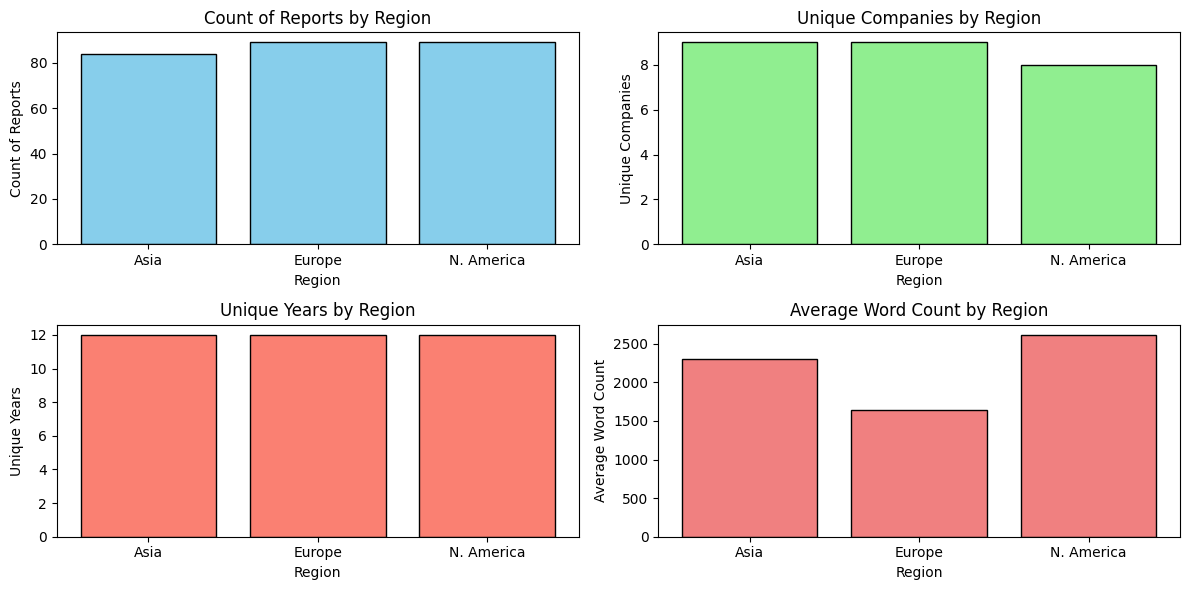

,Region,count_reports,unique_companies,unique_years,avg_word_count
0,Asia,84,9,12,2301.892857
1,Europe,89,9,12,1645.157303
2,N. America,89,8,12,2615.505618


word_count                                                   \
                count         mean          std    min     25%     50%   
Region                                                                   
Asia             84.0  2301.892857  1188.259059  384.0  1423.0  2063.0   
Europe           89.0  1645.157303  1956.650680    1.0   908.0  1084.0   
N. America       89.0  2615.505618  2732.360918    1.0   678.0  2163.0   

                             
               75%      max  
Region                       
Asia        3223.0   5177.0  
Europe      1466.0  11399.0  
N. America  3439.0  12419.0

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Set file path and file name
# base_path = '/content/drive/MyDrive/phd/Data/'
# file_name = 'CEO Letter collection.csv'
# file_path = f'{base_path}/{file_name}'

# Load dataset
data_new = df_ceo_letters2

# Filter out rows where the company name is 'Chubb' if needed
# data_new = data_new[data_new['Company Name'] != 'Chubb']

# Exclude the 'Timestamp' column from the analysis dataset
data_cleaned = data_new.drop(columns=['Timestamp'])

# Create a word count column for each report (excluding numbers)
data_cleaned['word_count'] = data_cleaned['Text'].apply(lambda x: len(str(x).split()) if isinstance(x, str) else 0)

# Aggregate by 'Region' and calculate descriptive statistics for numeric columns
region_agg = data_cleaned.groupby('Region').agg(
    count_reports=('Company Name', 'count'),
    unique_companies=('Company Name', 'nunique'),
    unique_years=('Year', 'nunique'),
    avg_word_count=('word_count', 'mean')
).reset_index()

# Descriptive statistics for numerical data (excluding non-numeric columns)
numeric_columns = data_cleaned.select_dtypes(include=['number'])
desc_stats_region = numeric_columns.groupby(data_cleaned['Region']).describe()

# Visualize aggregated data by Region
plt.figure(figsize=(12, 6))

# Plot the count of reports by Region
plt.subplot(2, 2, 1)
plt.bar(region_agg['Region'], region_agg['count_reports'], color='skyblue', edgecolor='black')
plt.title('Count of Reports by Region')
plt.xlabel('Region')
plt.ylabel('Count of Reports')

# Plot the unique companies by Region
plt.subplot(2, 2, 2)
plt.bar(region_agg['Region'], region_agg['unique_companies'], color='lightgreen', edgecolor='black')
plt.title('Unique Companies by Region')
plt.xlabel('Region')
plt.ylabel('Unique Companies')

# Plot the unique years by Region
plt.subplot(2, 2, 3)
plt.bar(region_agg['Region'], region_agg['unique_years'], color='salmon', edgecolor='black')
plt.title('Unique Years by Region')
plt.xlabel('Region')
plt.ylabel('Unique Years')

# Plot the average word count by Region
plt.subplot(2, 2, 4)
plt.bar(region_agg['Region'], region_agg['avg_word_count'], color='lightcoral', edgecolor='black')
plt.title('Average Word Count by Region')
plt.xlabel('Region')
plt.ylabel('Average Word Count')

# Adjust layout for better display
plt.tight_layout()
plt.show()

# Displaying the aggregated and descriptive statistics for regions using Google Colab's display function
display(region_agg)
display(desc_stats_region)

Missing CEO Letters by Company:


,Company Name,missing_ceo_letters_count
0,AIG,12
1,AXA,12
2,Allianz,12
3,Allstate,12
4,China Life,12
5,Chubb,12
6,Daichi,12
7,Generali,12
8,MET,12
9,MSAD,12


Missing CEO Letters by Region:


,Region,missing_ceo_letters_count
0,Asia,84
1,Europe,89
2,N. America,89


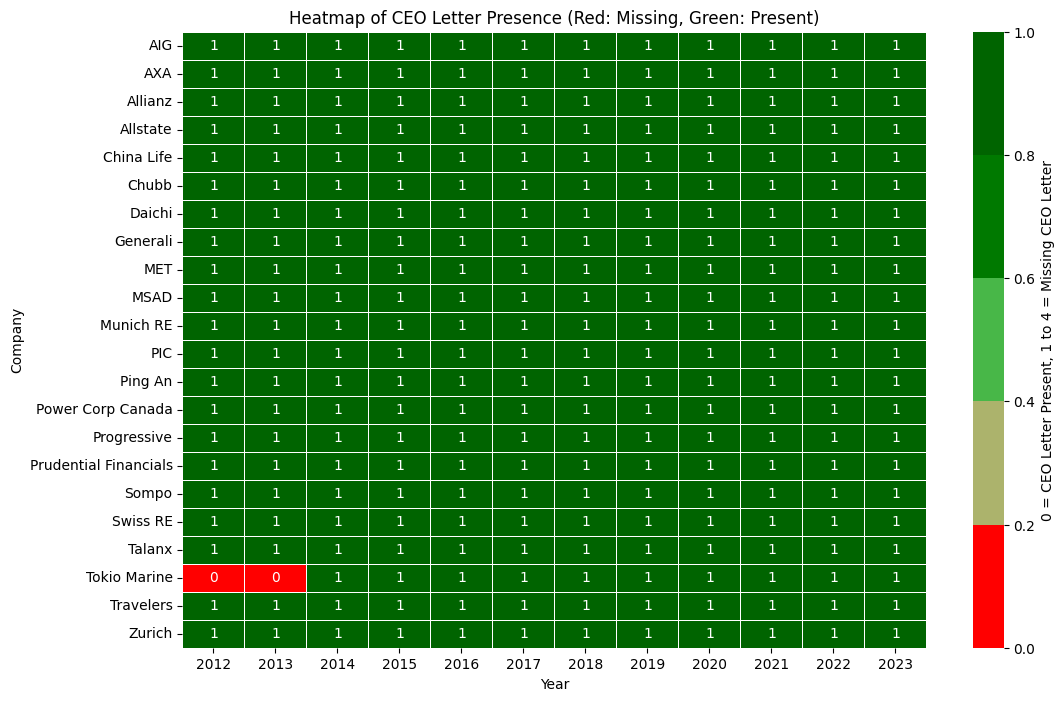

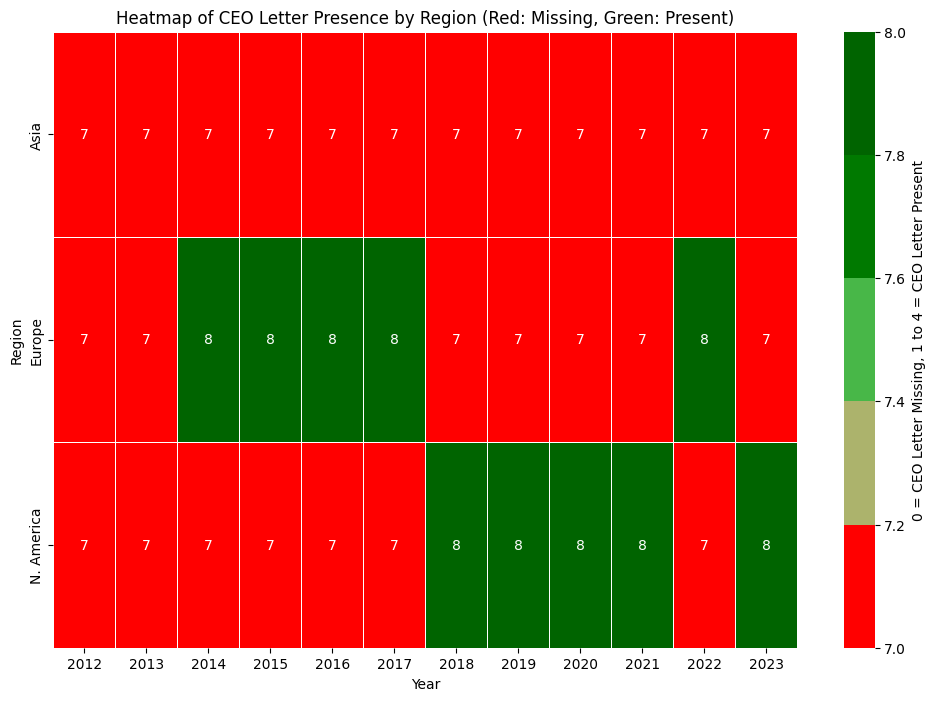

In [ ]:
# Check the presence of CEO letters
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Check for 'NA' values in the text column
df_ceo_letters2['no_ceo_letter'] = df_ceo_letters2['Text'].apply(lambda x: 1 if 'NA' in str(x).upper() else 0)

# Aggregate the results by company
company_agg = df_ceo_letters2.groupby('Company Name')['no_ceo_letter'].sum().reset_index()
company_agg = company_agg.rename(columns={'no_ceo_letter': 'missing_ceo_letters_count'})

# Aggregate the results by region
region_agg = df_ceo_letters2.groupby('Region')['no_ceo_letter'].sum().reset_index()
region_agg = region_agg.rename(columns={'no_ceo_letter': 'missing_ceo_letters_count'})

# Review the results
print("Missing CEO Letters by Company:")
display(company_agg)

print("Missing CEO Letters by Region:")
display(region_agg)

# Create a pivot table for the heatmap, with company as rows and year as columns
heatmap_data = df_ceo_letters2.pivot_table(index='Company Name', columns='Year', values='no_ceo_letter', aggfunc='sum', fill_value=0)
# Define a custom color map, from red for 0 to green shades for 1–4
colors = ['red', 'lightgreen', 'green', 'darkgreen']  # Red to green gradient
cmap = LinearSegmentedColormap.from_list("red_to_green", colors, N=5)

# Create the heatmap with the custom colormap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap=cmap, cbar_kws={'label': '0 = CEO Letter Present, 1 to 4 = Missing CEO Letter'}, annot=True, fmt='d', linewidths=0.5)

plt.title('Heatmap of CEO Letter Presence (Red: Missing, Green: Present)')
plt.xlabel('Year')
plt.ylabel('Company')
plt.show()

# Aggregate by Region and Year for CEO letter presence
region_agg = df_ceo_letters2.groupby(['Region', 'Year'])['no_ceo_letter'].sum().unstack(fill_value=0)

# Create the heatmap with the custom colormap for regions (Red for Missing, Green for Present)
plt.figure(figsize=(12, 8))
sns.heatmap(region_agg, cmap=cmap, cbar_kws={'label': '0 = CEO Letter Missing, 1 to 4 = CEO Letter Present'}, annot=True, fmt='d', linewidths=0.5)
plt.title('Heatmap of CEO Letter Presence by Region (Red: Missing, Green: Present)')
plt.xlabel('Year')
plt.ylabel('Region')
plt.show()

df_ceo_letters2.to_csv('/content/drive/MyDrive/phd/Data/df_ceoletters2.csv', index=False)

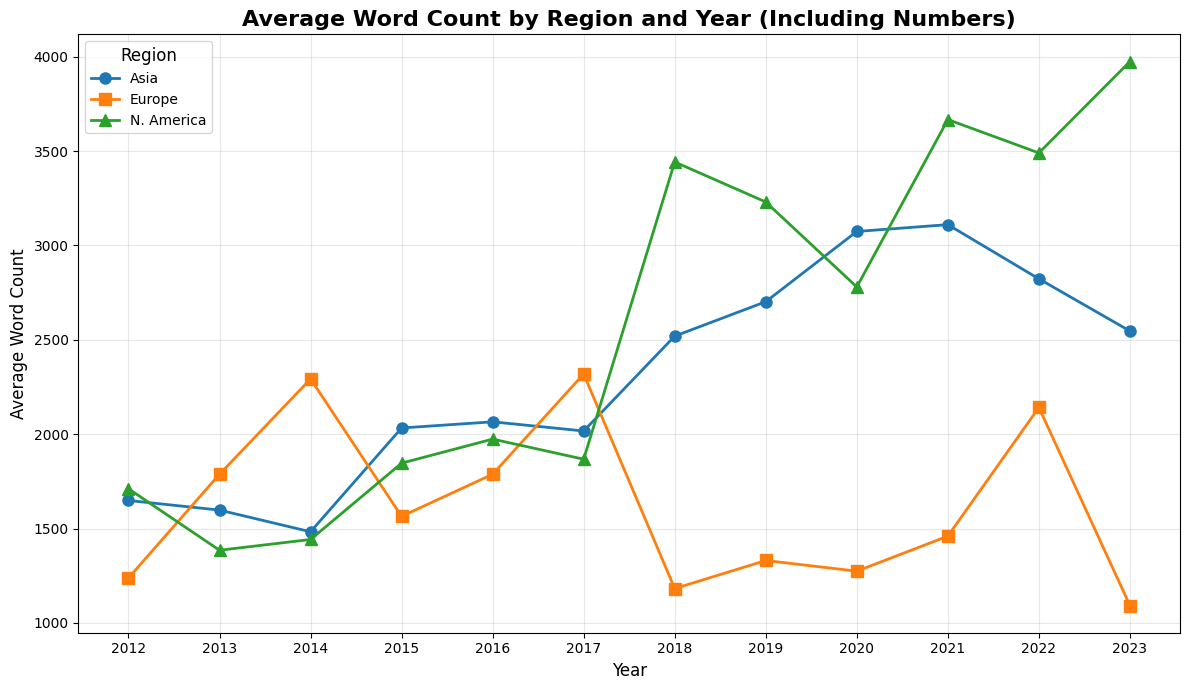


Summary Statistics:
        Region  Year  avg_word_count  total_word_count  count
0         Asia  2012     1649.000000             11543      7
1         Asia  2013     1598.000000             11186      7
2         Asia  2014     1483.142857             10382      7
3         Asia  2015     2033.142857             14232      7
4         Asia  2016     2065.714286             14460      7
5         Asia  2017     2017.142857             14120      7
6         Asia  2018     2519.714286             17638      7
7         Asia  2019     2702.142857             18915      7
8         Asia  2020     3074.285714             21520      7
9         Asia  2021     3110.428571             21773      7
10        Asia  2022     2823.285714             19763      7
11        Asia  2023     2546.714286             17827      7
12      Europe  2012     1238.285714              8668      7
13      Europe  2013     1788.000000             12516      7
14      Europe  2014     2293.000000             

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data_csv = df_ceo_letters2

# Function to count all words, including numbers
def count_all_words(text):
    words = str(text).split()
    # Count all words, including numbers
    return len(words)

# Add a word-count column that includes numbers
data_csv['word_count'] = data_csv['Text'].apply(count_all_words)

# Aggregate the data by region and year to calculate the average word count
region_year_agg = data_csv.groupby(['Region', 'Year']).agg(
    avg_word_count=('word_count', 'mean'),
    total_word_count=('word_count', 'sum'),
    count=('word_count', 'count')
).reset_index()

# Marker styles for each region
region_markers = {
    'Asia': 'o',  # Circle for Asia
    'Europe': 's',  # Square for Europe
    'N. America': '^',  # Triangle for North America
}

# Visualize the average word count by region and year with different markers
plt.figure(figsize=(12, 7))
for region in region_year_agg['Region'].unique():
    region_data = region_year_agg[region_year_agg['Region'] == region]
    marker = region_markers.get(region, 'o')  # Default to circle if region is not found
    plt.plot(region_data['Year'], region_data['avg_word_count'],
             label=region,
             linestyle='-', marker=marker, markersize=8, linewidth=2)

plt.title('Average Word Count by Region and Year (Including Numbers)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Word Count', fontsize=12)
plt.legend(title='Region', fontsize=10, title_fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

# Optional: Print summary statistics
print("\nSummary Statistics:")
print(region_year_agg)

print("\nTotal word count by Region:")
print(region_year_agg.groupby('Region')['total_word_count'].sum().sort_values(ascending=False))


=== Descriptive statistics: word_count ceo letters annual reports ===
count      262.000000
mean      2167.816794
std       2089.655404
min          1.000000
25%        990.500000
50%       1618.000000
75%       2824.000000
max      12310.000000
Name: word_count, dtype: float64

=== Descriptive statistics: word_count by Region ===
            count         mean          std    min     25%     50%     75%  \
Region                                                                       
Asia         84.0  2287.250000  1181.889022  382.0  1412.5  2051.0  3216.0   
Europe       89.0  1629.033708  1947.630229    1.0   898.0  1067.0  1459.0   
N. America   89.0  2593.876404  2711.008345    1.0   675.0  2132.0  3416.0   

                max  
Region               
Asia         5151.0  
Europe      11327.0  
N. America  12310.0  

=== Descriptive statistics: word_count by Year ===
      count         mean          std  min      25%     50%      75%      max
Year                               

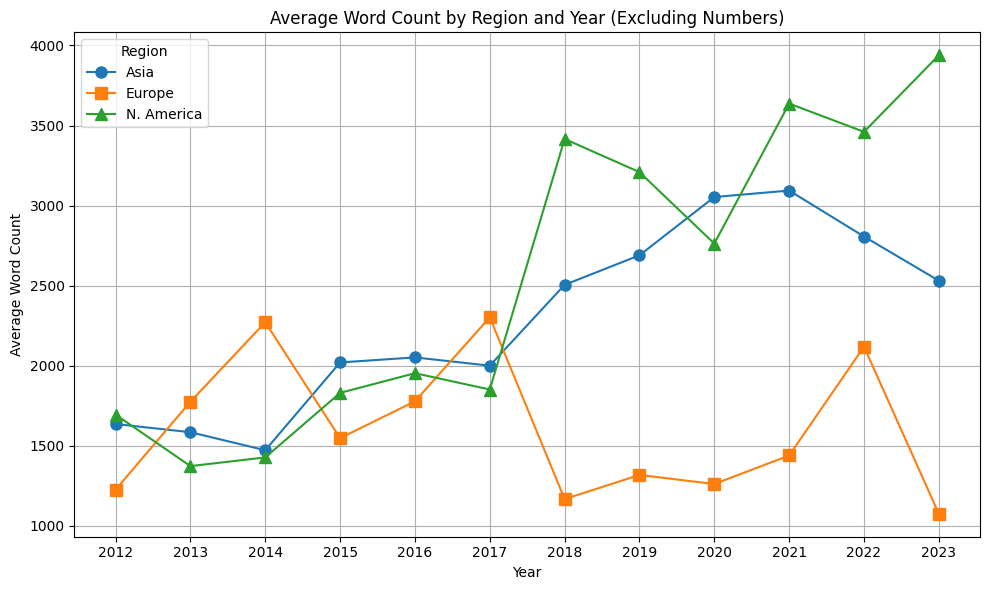

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data_csv = df_ceo_letters2

# ------------------------------------------------------------
# 1. Create word_count variable
# ------------------------------------------------------------
# Function to count words while excluding numbers
def count_words_excluding_numbers(text):
    words = str(text).split()
    # Exclude numbers and count only alphabetic words
    return len([word for word in words if not word.isdigit()])

# Add a word-count column that excludes numbers
data_csv['word_count'] = data_csv['Text'].apply(count_words_excluding_numbers)

# ------------------------------------------------------------
# 2. Descriptive analysis: word_count
# ------------------------------------------------------------
# Overall descriptive stats for word_count
print("\n=== Descriptive statistics: word_count ceo letters annual reports ===")
desc_overall = data_csv['word_count'].describe(percentiles=[0.25, 0.5, 0.75])
print(desc_overall)

# Descriptive stats by Region
print("\n=== Descriptive statistics: word_count by Region ===")
desc_by_region = data_csv.groupby('Region')['word_count'].describe(percentiles=[0.25, 0.5, 0.75])
print(desc_by_region)

# Descriptive stats by Year
print("\n=== Descriptive statistics: word_count by Year ===")
desc_by_year = data_csv.groupby('Year')['word_count'].describe(percentiles=[0.25, 0.5, 0.75])
print(desc_by_year)

# (Optional) If a dataset has a column for report type, can also do:
if 'ReportType' in data_csv.columns:
    print("\n=== Descriptive statistics: word_count by ReportType ===")
    desc_by_type = data_csv.groupby('ReportType')['word_count'].describe(percentiles=[0.25, 0.5, 0.75])
    print(desc_by_type)

# ------------------------------------------------------------
# 3. Aggregate by Region & Year (the original aggregation step)
# ------------------------------------------------------------
# Aggregate the data by region and year to calculate the average word count
region_year_agg = data_csv.groupby(['Region', 'Year']).agg(
    avg_word_count=('word_count', 'mean')
).reset_index()

# Marker styles for each region
region_markers = {
    'Asia': 'o',        # Circle for Asia
    'Europe': 's',      # Square for Europe
    'N. America': '^',  # Triangle for North America
}

# Visualize the average word count by region and year with different markers
plt.figure(figsize=(10, 6))
for region in region_year_agg['Region'].unique():
    region_data = region_year_agg[region_year_agg['Region'] == region]
    marker = region_markers.get(region, 'o')  # Default to circle if region is not found
    plt.plot(region_data['Year'], region_data['avg_word_count'], label=region,
             linestyle='-', marker=marker, markersize=8)

plt.title('Average Word Count by Region and Year (Excluding Numbers)')
plt.xlabel('Year')
plt.ylabel('Average Word Count')
plt.legend(title='Region')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

# 5. Descriptive Analysis of Annual and Sustainability Reports


In [ ]:
import os
import re
import pandas as pd

base_path = '/content/drive/MyDrive/phd/Data'
years = list(range(2012, 2024))  # 2012 to 2023 inclusive

company_results = []

# List all entries in base_path
for company in os.listdir(base_path):
    company_path = os.path.join(base_path, company)

    # Skip the excluded companies Berkshire_Hathaway and CPIG
    if company in ['Berkshire_Hathaway', 'CPIG', 'India Life Insurance','ARSRumap_plots']:
        continue

    # Check whether the entry is a folder and starts with a capital letter A–Z
    if os.path.isdir(company_path) and re.match(r'^[A-Z]', company):

        # Collect AR and SR files for each company
        ar_files = []
        sr_files = []

        for file in os.listdir(company_path):
            # Check for the _AR_YYYY.pdf pattern
            ar_match = re.search(r'_AR_(\d{4})\.pdf$', file)
            if ar_match:
                year = int(ar_match.group(1))
                if year in years:
                    ar_files.append(year)

            # Check for the _SR_YYYY.pdf pattern
            sr_match = re.search(r'_SR_(\d{4})\.pdf$', file)
            if sr_match:
                year = int(sr_match.group(1))
                if year in years:
                    sr_files.append(year)

        # Calculate missing years for AR and SR reports
        missing_ar_years = sorted(set(years) - set(ar_files))
        missing_sr_years = sorted(set(years) - set(sr_files))

        company_results.append({
            'Company': company,
            'AR_File_Count': len(ar_files),
            'Missing_AR_Years': missing_ar_years,
            'SR_File_Count': len(sr_files),
            'Missing_SR_Years': missing_sr_years,
            'SR_File_Per_Year': sr_files  # Store the SR files per year
        })

# Convert the results to a DataFrame
df_results = pd.DataFrame(company_results)

# Add a region column by mapping company names
df_results['Region'] = df_results['Company'].map(company_region_mapping)

# Reorder columns so that Region is the second column
df_results = df_results[['Company', 'Region', 'AR_File_Count', 'Missing_AR_Years', 'SR_File_Count', 'Missing_SR_Years', 'SR_File_Per_Year']]

# Add a row for total counts across all companies
total_ar_count = df_results['AR_File_Count'].sum()
total_sr_count = df_results['SR_File_Count'].sum()

total_row = pd.DataFrame({
    'Company': ['Total'],
    'AR_File_Count': [total_ar_count],
    'Missing_AR_Years': [[''] * len(years)],  # No missing years for the total row
    'SR_File_Count': [total_sr_count],
    'Missing_SR_Years': [[''] * len(years)],  # No missing years for the total row
    'Region': [''],  # No region for the total row
    'SR_File_Per_Year': [None]  # No specific per-year data for the total row
})

# Append the total row to the DataFrame
df_results = pd.concat([df_results, total_row], ignore_index=True)

# Reset the index to start from 1
df_results.reset_index(drop=True, inplace=True)
df_results.index += 1  # Start index from 1 instead of 0

# Show the results
display(df_results)

# --- Summing counts by Region and Year ---
# We now need to count the SR files per year, grouped by region
sr_count_by_region_year = df_results.explode('SR_File_Per_Year')  # Flatten the 'SR_File_Per_Year' lists
sr_count_by_region_year = sr_count_by_region_year.groupby(['Region', 'SR_File_Per_Year']).size().reset_index(name='SR_Count')

# --- Summing counts by Region ---
region_summary = df_results.groupby('Region').agg(
    AR_File_Count=('AR_File_Count', 'sum'),
    SR_File_Count=('SR_File_Count', 'sum'),
).reset_index()

# Add a new column for combined counts (AR + SR)
region_summary['Total_AR_SR'] = region_summary['AR_File_Count'] + region_summary['SR_File_Count']

# Display the region summary (AR, SR, AR + SR counts by region)
print("\nSummary of AR, SR, and AR + SR Counts by Region:")
display(region_summary)

# --- Summing counts per region and year for SR files ---
sr_count_summary = sr_count_by_region_year.groupby(['Region', 'SR_File_Per_Year']).agg(
    SR_Count=('SR_Count', 'sum')
).reset_index()

# Display the SR count summary (SR file count by region and year)
print("\nSummary of SR File Count per Year by Region:")
display(sr_count_summary)

# --- Summing counts by Region and Year for AR files ---

# Step 1: remove rows where Region is empty or NaN
df_results_cleaned = df_results[df_results['Region'].notna() & (df_results['Region'] != '')]

# Step 2: create the AR_File_Per_Year column
df_results_cleaned['AR_File_Per_Year'] = df_results_cleaned.apply(
    lambda row: [year for year in years if year not in row['Missing_AR_Years']], axis=1
)

# Step 3: Explode AR_File_Per_Year to get each year with corresponding AR counts
ar_count_by_region_year = df_results_cleaned.explode('AR_File_Per_Year')

# Step 4: Group by Region and Year to calculate the AR file count per year
ar_count_by_region_year_summary = ar_count_by_region_year.groupby(['Region', 'AR_File_Per_Year']).size().reset_index(name='AR_Count')

# Step 5: display the AR file count summary (AR file count by region and year)
print("\nSummary of AR File Count per Year by Region:")
display(ar_count_by_region_year_summary)

,Company,Region,AR_File_Count,Missing_AR_Years,SR_File_Count,Missing_SR_Years,SR_File_Per_Year
1,Sompo,Asia,12,[],12,[],"[2012, 2013, 2014, 2015, 2016, 2017, 2018, 201..."
2,Assicurazioni Generali,Europe,12,[],12,[],"[2012, 2014, 2013, 2015, 2016, 2017, 2018, 201..."
3,MSAD,Asia,12,[],12,[],"[2012, 2013, 2014, 2015, 2016, 2018, 2019, 202..."
4,AIG,N. America,12,[],9,"[2012, 2013, 2014]","[2015, 2016, 2017, 2018, 2019, 2020, 2021, 202..."
5,Tokio Marine,Asia,10,"[2012, 2013]",10,"[2012, 2013]","[2014, 2016, 2015, 2017, 2018, 2019, 2020, 202..."
6,MetLife,N. America,12,[],11,[2013],"[2012, 2014, 2015, 2016, 2017, 2018, 2019, 202..."
7,New China Life,Asia,12,[],0,"[2012, 2013, 2014, 2015, 2016, 2017, 2018, 201...",[]
8,People Insurance China,Asia,12,[],4,"[2012, 2013, 2014, 2015, 2016, 2017, 2018, 2020]","[2019, 2021, 2023, 2022]"
9,Talanx,Europe,12,[],9,"[2012, 2013, 2014]","[2015, 2016, 2017, 2019, 2018, 2020, 2021, 202..."
10,AXA,Europe,12,[],12,[],"[2012, 2013, 2014, 2015, 2016, 2017, 2018, 201..."



Summary of AR, SR, and AR + SR Counts by Region:


,Region,AR_File_Count,SR_File_Count,Total_AR_SR
0,,274,201,475
1,Asia,94,63,157
2,Europe,96,79,175
3,N. America,84,59,143



Summary of SR File Count per Year by Region:


,Region,SR_File_Per_Year,SR_Count
0,Asia,2012,3
1,Asia,2013,3
2,Asia,2014,5
3,Asia,2015,5
4,Asia,2016,5
5,Asia,2017,5
6,Asia,2018,6
7,Asia,2019,7
8,Asia,2020,6
9,Asia,2021,6



Summary of AR File Count per Year by Region:


/tmp/ipykernel_1250/3093237188.py:119: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_results_cleaned['AR_File_Per_Year'] = df_results_cleaned.apply(


,Region,AR_File_Per_Year,AR_Count
0,Asia,2012,7
1,Asia,2013,7
2,Asia,2014,8
3,Asia,2015,8
4,Asia,2016,8
5,Asia,2017,8
6,Asia,2018,8
7,Asia,2019,8
8,Asia,2020,8
9,Asia,2021,8


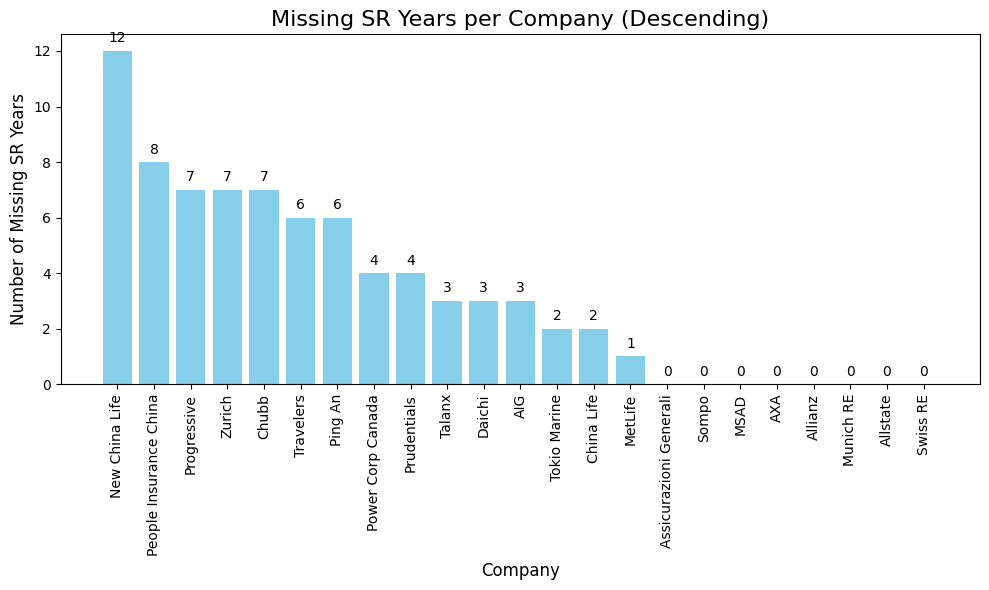

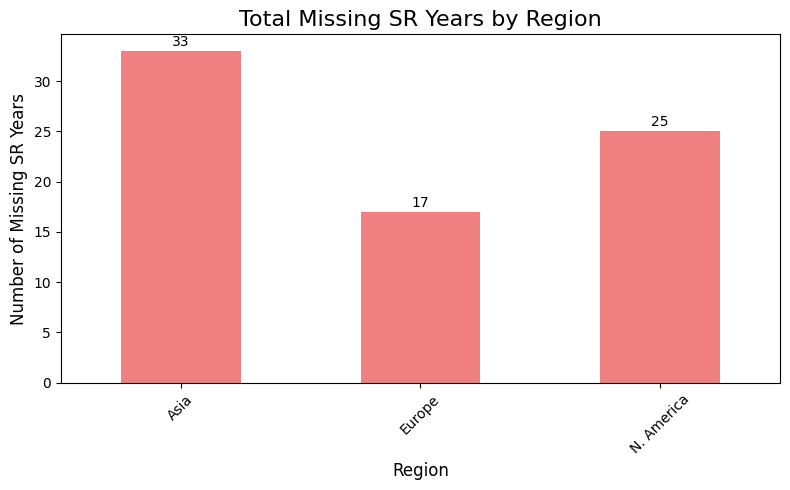

In [ ]:
import matplotlib.pyplot as plt

# Step 1: extract the count of missing SR years for each company
df_results['Missing_SR_Count'] = df_results['Missing_SR_Years'].apply(len)

# Step 2: exclude the "Total" row for plotting
df_results_sorted = df_results[df_results['Company'] != 'Total']

# Step 3: sort the DataFrame by Missing_SR_Count in descending order
df_results_sorted = df_results_sorted.sort_values(by='Missing_SR_Count', ascending=False)

# Step 4: plot the missing SR years for each company, excluding "Total"
plt.figure(figsize=(10, 6))
bars = plt.bar(df_results_sorted['Company'], df_results_sorted['Missing_SR_Count'], color='skyblue')

# Add labels above each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,  # Position of the label
             f'{bar.get_height()}', ha='center', va='bottom', fontsize=10)

# Step 5: customize the plot
plt.title('Missing SR Years per Company (Descending)', fontsize=16)
plt.xlabel('Company', fontsize=12)
plt.ylabel('Number of Missing SR Years', fontsize=12)
plt.xticks(rotation=90)  # Rotate company names to make them readable
plt.tight_layout()

# Step 6: show the plot
plt.show()

# Step 7: create a new plot for missing SR years grouped by region
# Group by region and sum missing SR counts
region_missing_sr = df_results_sorted.groupby('Region')['Missing_SR_Count'].sum()

# Step 8: Plotting missing SR years by region
plt.figure(figsize=(8, 5))
bars = region_missing_sr.plot(kind='bar', color='lightcoral')

# Add labels above each bar
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,  # Position of the label
             f'{bar.get_height()}', ha='center', va='bottom', fontsize=10)

# Step 9: Customize the plot
plt.title('Total Missing SR Years by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Missing SR Years', fontsize=12)
plt.xticks(rotation=45)  # Rotate region names for better readability
plt.tight_layout()

# Step 10: show the plot
plt.show()

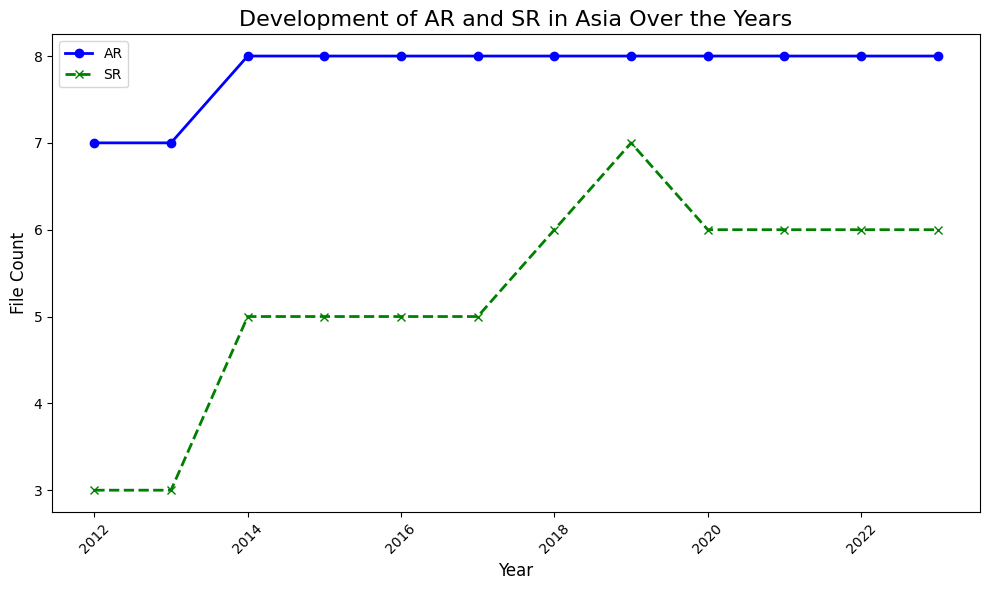

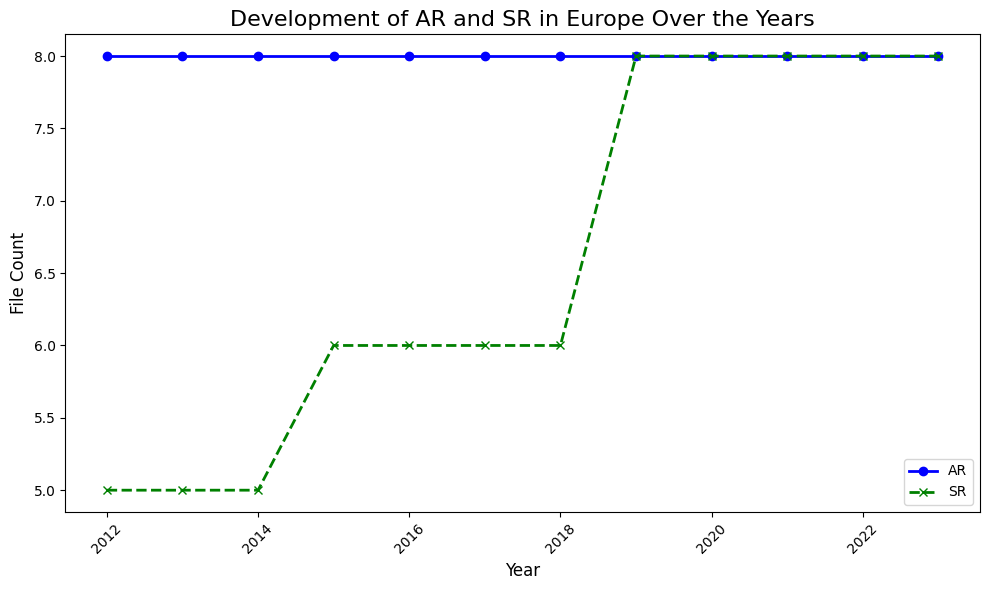

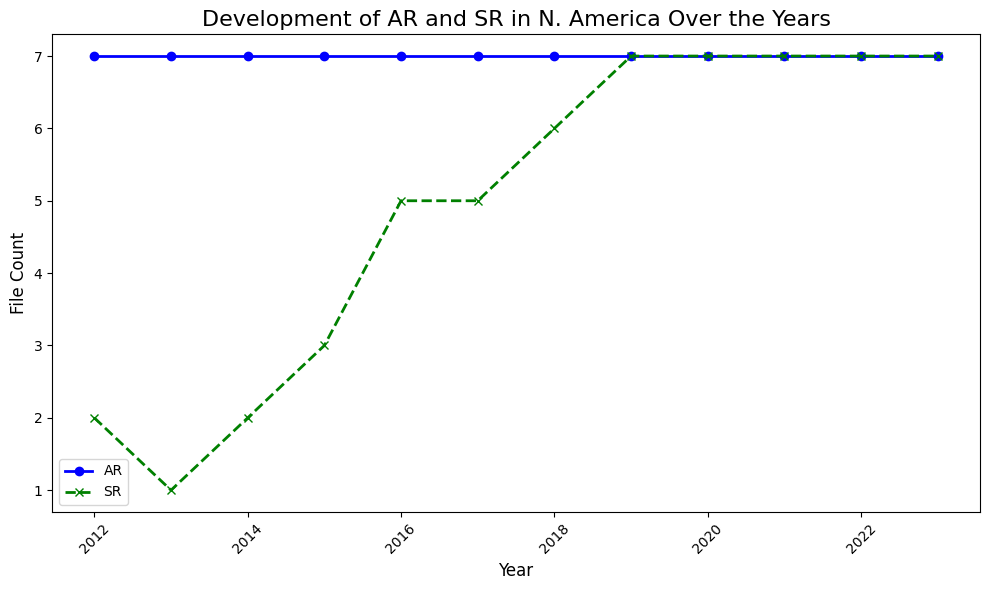

In [ ]:
import matplotlib.pyplot as plt

# Step 1: remove empty or NaN regions from the data
valid_regions = df_results['Region'].notna() & (df_results['Region'] != '')
df_results_cleaned = df_results[valid_regions]

# Step 2: group AR file counts by region and year
# Step 3: group SR file counts by region and year

# Step 4: create a plot for each region
regions = df_results_cleaned['Region'].unique()

for region in regions:
    # Filter the AR and SR summaries for the current region
    region_ar_counts = ar_count_by_region_year_summary[ar_count_by_region_year_summary['Region'] == region]
    region_sr_counts = sr_count_summary[sr_count_summary['Region'] == region]

    # Create a figure for this region
    plt.figure(figsize=(10, 6))

    # Plot AR development over the years
    plt.plot(region_ar_counts['AR_File_Per_Year'], region_ar_counts['AR_Count'], label='AR', marker='o', color='blue', linestyle='-', linewidth=2)

    # Plot SR development over the years
    plt.plot(region_sr_counts['SR_File_Per_Year'], region_sr_counts['SR_Count'], label='SR', marker='x', color='green', linestyle='--', linewidth=2)

    # Add labels and title
    plt.title(f"Development of AR and SR in {region} Over the Years", fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('File Count', fontsize=12)
    plt.legend()

    # Rotate x-axis labels if needed
    plt.xticks(rotation=45)

    # Display the plot
    plt.tight_layout()
    plt.show()

# 6. BERT-ESG Classification


## 6.1 Code ESG Sentences


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Automatically use the GPU in Colab if available
device = 0 if torch.cuda.is_available() else -1
print("Using device:", "GPU" if device == 0 else "CPU")

# ------------------------------------------------------------
# Load the ENVIRONMENTAL model
# ------------------------------------------------------------
env_model_name = "ESGBERT/EnvRoBERTa-environmental"
env_tokenizer = AutoTokenizer.from_pretrained(env_model_name)
env_model = AutoModelForSequenceClassification.from_pretrained(env_model_name)

env_pipe = pipeline(
    task="text-classification",
    model=env_model,
    tokenizer=env_tokenizer,
    device=device,
    truncation=True
)

# ------------------------------------------------------------
# Load the SOCIAL model
# ------------------------------------------------------------
soc_model_name = "ESGBERT/SocRoBERTa-social"
soc_tokenizer = AutoTokenizer.from_pretrained(soc_model_name)
soc_model = AutoModelForSequenceClassification.from_pretrained(soc_model_name)

soc_pipe = pipeline(
    task="text-classification",
    model=soc_model,
    tokenizer=soc_tokenizer,
    device=device,
    truncation=True
)

# ------------------------------------------------------------
# Load the GOVERNANCE model
# ------------------------------------------------------------
gov_model_name = "ESGBERT/GovRoBERTa-governance"
gov_tokenizer = AutoTokenizer.from_pretrained(gov_model_name)
gov_model = AutoModelForSequenceClassification.from_pretrained(gov_model_name)

gov_pipe = pipeline(
    task="text-classification",
    model=gov_model,
    tokenizer=gov_tokenizer,
    device=device,
    truncation=True
)

Using device: GPU


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
import pandas as pd

# Load the sentence-split CEO letters
df_ceo_sentences = pd.read_csv(
    "/content/drive/MyDrive/phd/Data/df_ar_ceo_letters_sentence_split.csv",
    engine='python'
)

# Run sanity checks
print("Shape:", df_ceo_sentences.shape)
display(df_ceo_sentences.head())



Shape: (23995, 7)


,Company Name,Year,Text,Region,Note,Timestamp,Sentence
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...
1,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"When I joined AIG in August 2009, we were sell..."
2,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ..."
3,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse..."
4,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,As we identified the insurance businesses that...


In [ ]:
#count firm-year pair after processing ceo letter text
df_ceo_sentences.set_index(["Company Name", "Year"]).index.nunique()

262

In [ ]:
df_ceo_sentences['word_count'] = df_ceo_sentences['Sentence'].apply(
    lambda x: len(str(x).split())
)

# Choose the filtering threshold; here, use at least 8 words
df_ceo_esg_score = df_ceo_sentences[df_ceo_sentences['word_count'] >= 8].copy()

# Alternatively, can run the analysis without filtering
# df_ceo_esg_score = df_ceo_sentences.copy()

In [ ]:
from tqdm.auto import tqdm

def batch_predict_binary(sentences, pipe, positive_label, batch_size=32):
    """
    Run a binary ESG-BERT pipeline in batches and return
    P(positive_label) for each sentence in order.

    positive_label examples:
      - "environmental"
      - "social"
      - "governance"
    """
    probs = []
    n = len(sentences)

    for start in tqdm(range(0, n, batch_size)):
        end = start + batch_size
        batch = sentences[start:end]

        # Pass the list of texts directly to the pipeline
        results = pipe(batch, batch_size=batch_size, truncation=True)

        for r in results:
            if r['label'] == positive_label:
                probs.append(r['score'])
            else:
                probs.append(1 - r['score'])

    return probs

In [ ]:
import time

# Start the total timer
start_total = time.time()

sentences = df_ceo_esg_score['Sentence'].tolist()

# Run all three models using the selected batch size
df_ceo_esg_score['prob_env'] = batch_predict_binary(sentences, env_pipe, positive_label="environmental", batch_size=32)
df_ceo_esg_score['prob_soc'] = batch_predict_binary(sentences, soc_pipe, positive_label="social", batch_size=32)
df_ceo_esg_score['prob_gov'] = batch_predict_binary(sentences, gov_pipe, positive_label="governance", batch_size=32)

# End the total timer
end_total = time.time()

runtime_minutes = (end_total - start_total) / 60
print(f"Total ESG-BERT runtime: {runtime_minutes:.2f} minutes")

  0%|          | 0/713 [00:00<?, ?it/s]

  0%|          | 0/713 [00:00<?, ?it/s]

  0%|          | 0/713 [00:00<?, ?it/s]

Total ESG-BERT runtime: 5.58 minutes


In [ ]:
threshold = 0.5   # change to 0.4 or 0.6 for robustness test

df_ceo_esg_score['env_flag'] = (df_ceo_esg_score['prob_env'] >= threshold).astype(int)
df_ceo_esg_score['soc_flag'] = (df_ceo_esg_score['prob_soc'] >= threshold).astype(int)
df_ceo_esg_score['gov_flag'] = (df_ceo_esg_score['prob_gov'] >= threshold).astype(int)

In [ ]:
def esg_multilabel(row):
    labels = []
    if row['env_flag'] == 1:
        labels.append('E')
    if row['soc_flag'] == 1:
        labels.append('S')
    if row['gov_flag'] == 1:
        labels.append('G')
    return ','.join(labels) if labels else 'None'

df_ceo_esg_score['ESG_multilabel'] = df_ceo_esg_score.apply(esg_multilabel, axis=1)

display(df_ceo_esg_score[df_ceo_esg_score[['env_flag', 'soc_flag', 'gov_flag']].any(axis=1)])

,Company Name,Year,Text,Region,Note,Timestamp,Sentence,word_count,prob_env,prob_soc,prob_gov,env_flag,soc_flag,gov_flag,ESG_multilabel
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...,46,0.012819,0.847576,0.003518,0,1,0,S
2,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ...",51,0.006075,0.954349,0.012917,0,1,0,S
3,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse...",15,0.001983,0.999662,0.000886,0,1,0,S
5,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,Only by reenergizing and empowering the people...,19,0.007930,0.999175,0.002745,0,1,0,S
15,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,2012 marks three years that we have adhered to...,35,0.002158,0.991119,0.005241,0,1,0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23947,Zurich,2022,\nBig strides toward our ambitious vision.\n\n...,Europe,Message from our Group CEO,25/10/2025 22:10:10,"For 2023, we refreshed our sustainability fram...",22,0.975853,0.999428,0.980782,1,1,1,"E,S,G"
23948,Zurich,2022,\nBig strides toward our ambitious vision.\n\n...,Europe,Message from our Group CEO,25/10/2025 22:10:10,We are growing our range of sustainable produc...,20,0.997668,0.999323,0.003319,1,1,0,"E,S"
23950,Zurich,2022,\nBig strides toward our ambitious vision.\n\n...,Europe,Message from our Group CEO,25/10/2025 22:10:10,And we will continue to embed our values and p...,18,0.002928,0.999469,0.154195,0,1,0,S
23963,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,Mario Greco Group Chief Executive Officer Zuri...,34,0.912179,0.000138,0.001928,1,0,0,E


In [ ]:
df_ceo_esg_score.drop(columns=['Text']).to_csv('/content/drive/MyDrive/phd/Data/df_ar_ceo_sentences_esgbert_scored.csv', index=False)

## 6.2 Review the ESG Classification Results


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/phd/Data/df_ar_ceo_sentences_esgbert_scored.csv'

df_ceo_esg_score = pd.read_csv(file_path)

print(df_ceo_esg_score.shape)

(22806, 14)


In [ ]:
import pandas as pd

# ------------------------------------------------------------
# 0. Inspect the dataset if needed
# ------------------------------------------------------------
display(df_ceo_esg_score)

# ------------------------------------------------------------
# 1. copy the dataset so the original remains unchanged
# ------------------------------------------------------------
df = df_ceo_esg_score.copy()

# ------------------------------------------------------------
# 2. Define the ESG flag using a robust definition
# ------------------------------------------------------------
df["ESG_flag"] = (
    df[["env_flag", "soc_flag", "gov_flag"]]
    .any(axis=1)
    .astype(int)
)

# ------------------------------------------------------------
# 3. Aggregate to firm-year level
# ------------------------------------------------------------
df_fy = df.groupby(["Company Name", "Year"]).agg(
    sentence_count=("Sentence", "count"),
    word_count=("word_count", "sum"),
    ESG_sentences=("ESG_flag", "sum"),
    env_sentences=("env_flag", "sum"),
    soc_sentences=("soc_flag", "sum"),
    gov_sentences=("gov_flag", "sum")
).reset_index()

# ------------------------------------------------------------
# 4. Compute ESG ratios
# ------------------------------------------------------------
df_fy["ESG_ratio"] = df_fy["ESG_sentences"] / df_fy["sentence_count"]
df_fy["E_ratio"] = df_fy["env_sentences"] / df_fy["sentence_count"]
df_fy["S_ratio"] = df_fy["soc_sentences"] / df_fy["sentence_count"]
df_fy["G_ratio"] = df_fy["gov_sentences"] / df_fy["sentence_count"]

# ------------------------------------------------------------
# 5. Keep observations with ESG content (optional)
# ------------------------------------------------------------
df_esg = df_fy[df_fy["ESG_sentences"] > 0].copy()

# ------------------------------------------------------------
# 6. Summary statistics function
# ------------------------------------------------------------
def summary_stats(series):
    return pd.Series({
        "Mean": series.mean(),
        "Std. dev": series.std(),
        "1st Quartile": series.quantile(0.25),
        "Median": series.median(),
        "3rd Quartile": series.quantile(0.75)
    })

# ------------------------------------------------------------
# 7. Create summary table
# ------------------------------------------------------------
summary_table = pd.DataFrame({
    "Word count": summary_stats(df_esg["word_count"]),
    "Sentence count": summary_stats(df_esg["sentence_count"]),
    "ESG sentences": summary_stats(df_esg["ESG_sentences"]),
    "ESG ratio": summary_stats(df_esg["ESG_ratio"]),
    "E ratio": summary_stats(df_esg["E_ratio"]),
    "S ratio": summary_stats(df_esg["S_ratio"]),
    "G ratio": summary_stats(df_esg["G_ratio"]),
}).T

# ------------------------------------------------------------
# 8. Display results
# ------------------------------------------------------------
print("\n=== Summary Statistics (Firm-Year Level) ===\n")
print(summary_table.round(4))

,Company Name,Year,Region,Note,Timestamp,Sentence,word_count,prob_env,prob_soc,prob_gov,env_flag,soc_flag,gov_flag,ESG_multilabel
0,AIG,2012,N. America,NaN,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...,46,0.012819,0.847576,0.003518,0,1,0,S
1,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"When I joined AIG in August 2009, we were sell...",20,0.003059,0.000127,0.001016,0,0,0,NaN
2,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ...",51,0.006075,0.954349,0.012917,0,1,0,S
3,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse...",15,0.001983,0.999662,0.000886,0,1,0,S
4,AIG,2012,N. America,NaN,02/08/2026 23:04:50,As we identified the insurance businesses that...,51,0.002387,0.000258,0.002312,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22801,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,This compares favorably with the 9 percent ann...,18,0.005388,0.000128,0.001116,0,0,0,NaN
22802,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,In light of these record results and strong ca...,27,0.002576,0.000125,0.000827,0,0,0,NaN
22803,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,Zurich plans to supplement the ordinary divide...,17,0.002459,0.000118,0.001169,0,0,0,NaN
22804,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,"Looking ahead Customer focus, simplification a...",28,0.002752,0.000141,0.001780,0,0,0,NaN



=== Summary Statistics (Firm-Year Level) ===

                     Mean   Std. dev  1st Quartile     Median  3rd Quartile
Word count      2390.9746  2068.3499     1069.0000  1752.0000     3095.7500
Sentence count    96.1398    83.7031       43.7500    69.0000      121.2500
ESG sentences     23.2288    22.5211        8.0000    16.0000       29.0000
ESG ratio          0.2463     0.1283        0.1429     0.2250        0.3519
E ratio            0.0831     0.0657        0.0342     0.0697        0.1206
S ratio            0.1864     0.1237        0.0789     0.1636        0.2793
G ratio            0.0182     0.0245        0.0000     0.0081        0.0286


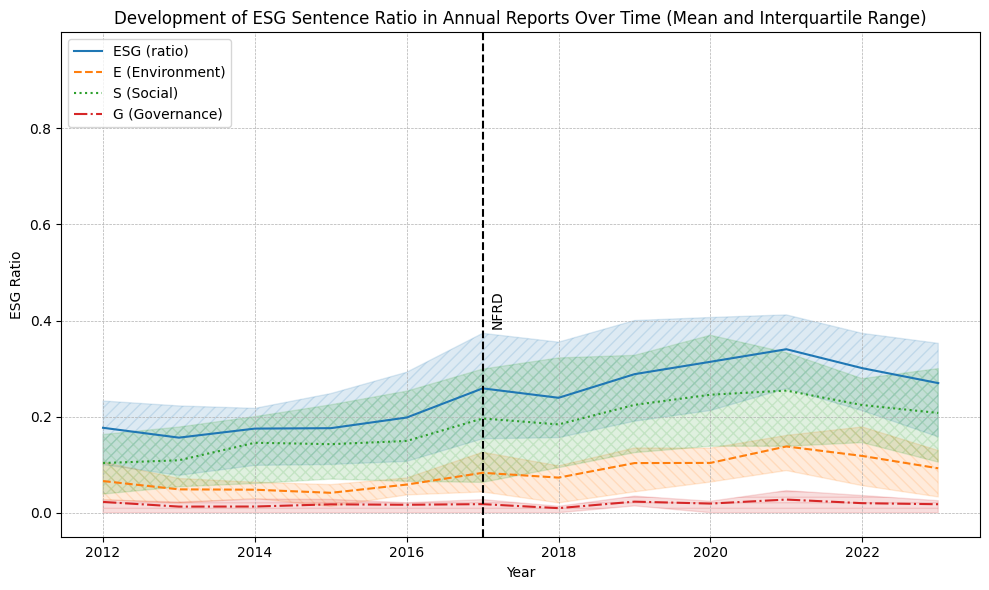

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. copy the data
# ------------------------------------------------------------
df = df_ceo_esg_score.copy()

# ------------------------------------------------------------
# 2. Define the ESG flag using a robust definition
# ------------------------------------------------------------
df["ESG_flag"] = (
    df[["env_flag", "soc_flag", "gov_flag"]]
    .any(axis=1)
    .astype(int)
)

# ------------------------------------------------------------
# 3. Aggregate the data to firm-year level
# ------------------------------------------------------------
df_fy = df.groupby(["Company Name", "Year"]).agg(
    sentence_count=("Sentence", "count"),
    ESG_sentences=("ESG_flag", "sum"),
    env_sentences=("env_flag", "sum"),
    soc_sentences=("soc_flag", "sum"),
    gov_sentences=("gov_flag", "sum")
).reset_index()

# ------------------------------------------------------------
# 4. COMPUTE RATIOS
# ------------------------------------------------------------
df_fy["ESG_ratio"] = df_fy["ESG_sentences"] / df_fy["sentence_count"]
df_fy["E_ratio"] = df_fy["env_sentences"] / df_fy["sentence_count"]
df_fy["S_ratio"] = df_fy["soc_sentences"] / df_fy["sentence_count"]
df_fy["G_ratio"] = df_fy["gov_sentences"] / df_fy["sentence_count"]

# ------------------------------------------------------------
# 5. FUNCTION: MEAN + QUANTILES
# ------------------------------------------------------------
def compute_stats(df, col):
    stats = df.groupby("Year")[col].agg([
        "mean",
        lambda x: x.quantile(0.25),
        lambda x: x.quantile(0.75)
    ])
    stats.columns = ["mean", "q25", "q75"]
    return stats

stats_esg = compute_stats(df_fy, "ESG_ratio")
stats_e = compute_stats(df_fy, "E_ratio")
stats_s = compute_stats(df_fy, "S_ratio")
stats_g = compute_stats(df_fy, "G_ratio")

# ------------------------------------------------------------
# 6. COLORS
# ------------------------------------------------------------
colors = {
    "ESG": "#1f77b4",  # blue
    "E": "#ff7f0e",    # orange
    "S": "#2ca02c",    # green
    "G": "#d62728"     # red
}

# ------------------------------------------------------------
# 7. PLOT (COLOR + PATTERN SHADING)
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

# ESG
plt.plot(stats_esg.index, stats_esg["mean"],
         color=colors["ESG"], label="ESG (ratio)")
plt.fill_between(stats_esg.index, stats_esg["q25"], stats_esg["q75"],
                 facecolor=colors["ESG"], alpha=0.15,
                 hatch='///', edgecolor=colors["ESG"])

# E
plt.plot(stats_e.index, stats_e["mean"],
         color=colors["E"], linestyle='--', label="E (Environment)")
plt.fill_between(stats_e.index, stats_e["q25"], stats_e["q75"],
                 facecolor=colors["E"], alpha=0.15,
                 hatch='\\\\\\', edgecolor=colors["E"])

# S
plt.plot(stats_s.index, stats_s["mean"],
         color=colors["S"], linestyle=':', label="S (Social)")
plt.fill_between(stats_s.index, stats_s["q25"], stats_s["q75"],
                 facecolor=colors["S"], alpha=0.15,
                 hatch='xxx', edgecolor=colors["S"])

# G
plt.plot(stats_g.index, stats_g["mean"],
         color=colors["G"], linestyle='-.', label="G (Governance)")
plt.fill_between(stats_g.index, stats_g["q25"], stats_g["q75"],
                 facecolor=colors["G"], alpha=0.15,
                 hatch='---', edgecolor=colors["G"])

# ------------------------------------------------------------
# 8. NFRD MARKER
# ------------------------------------------------------------
plt.axvline(x=2017, linestyle='--', color='black')
plt.text(2017 + 0.1, plt.ylim()[1]*0.9, "NFRD", rotation=90)

# ------------------------------------------------------------
# 9. FINAL FORMATTING
# ------------------------------------------------------------
plt.title("Development of ESG Sentence Ratio in Annual Reports Over Time (Mean and Interquartile Range)")
plt.xlabel("Year")
plt.ylabel("ESG Ratio")
plt.ylim(-0.05, 1)
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8])
plt.legend(loc="upper left")
plt.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Keep sentences with at least one ESG flag
df_esg_sentences = df_ceo_esg_score[
    df_ceo_esg_score[['env_flag', 'soc_flag', 'gov_flag']].any(axis=1)
].copy()

print("ESG sentence-level rows:", df_esg_sentences.shape[0])

# Aggregate the data to firm-year level
df_fy_esg_only = (
    df_esg_sentences
    .groupby(['Company Name', 'Year'])
    .agg(
        esg_sentences=('Sentence', 'count'),
        Region=('Region', 'first')
    )
    .reset_index()
)

print("Firm-year observations with ≥1 ESG sentence:", df_fy_esg_only.shape[0])

ESG sentence-level rows: 5482
Firm-year observations with ≥1 ESG sentence: 236


,Company Name,Year,Region,E_count,S_count,G_count,Total_ESG,E_share,S_share,G_share
0,AIG,2012,N. America,1,8,0,9,0.111111,0.888889,0.000000
1,AIG,2013,N. America,2,5,0,7,0.285714,0.714286,0.000000
2,AIG,2014,N. America,3,7,0,10,0.300000,0.700000,0.000000
3,AIG,2015,N. America,1,26,1,28,0.035714,0.928571,0.035714
4,AIG,2016,N. America,1,6,1,8,0.125000,0.750000,0.125000
...,...,...,...,...,...,...,...,...,...,...
233,Zurich,2019,Europe,8,25,1,34,0.235294,0.735294,0.029412
234,Zurich,2020,Europe,9,26,0,35,0.257143,0.742857,0.000000
235,Zurich,2021,Europe,15,20,0,35,0.428571,0.571429,0.000000
236,Zurich,2022,Europe,12,15,3,30,0.400000,0.500000,0.100000


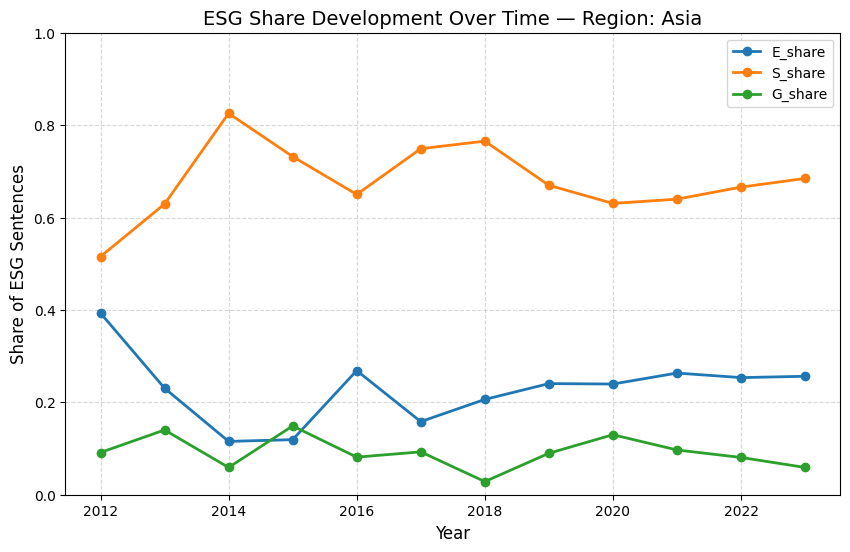

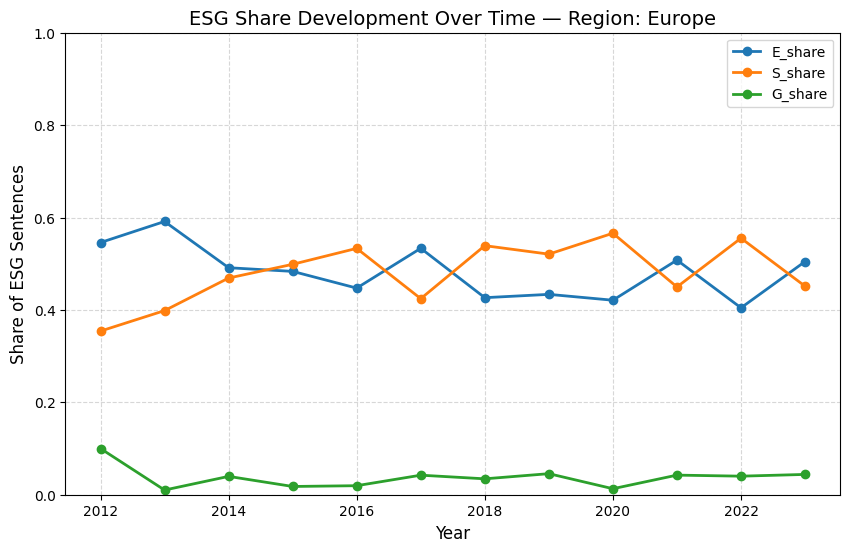

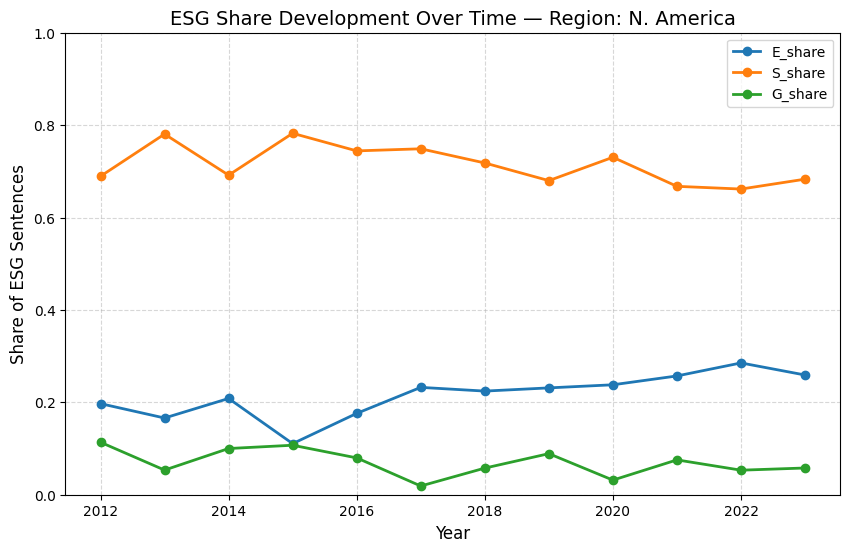

In [ ]:
# Calculate the ESG ratio
df_year = df_ceo_esg_score.groupby(['Company Name', 'Year']).agg(
    Region=('Region', 'first'),
    E_count=('env_flag', 'sum'),
    S_count=('soc_flag', 'sum'),
    G_count=('gov_flag', 'sum')
).reset_index()

df_year['Total_ESG'] = df_year[['E_count', 'S_count', 'G_count']].sum(axis=1)
df_year['E_share'] = df_year['E_count'] / df_year['Total_ESG']
df_year['S_share'] = df_year['S_count'] / df_year['Total_ESG']
df_year['G_share'] = df_year['G_count'] / df_year['Total_ESG']

display(df_year)

import matplotlib.pyplot as plt

df_region_year = df_year.groupby(['Region', 'Year']).agg(
    E_share_mean=('E_share', 'mean'),
    S_share_mean=('S_share', 'mean'),
    G_share_mean=('G_share', 'mean')
).reset_index()

regions = df_region_year['Region'].unique()

for region in regions:
    df_r = df_region_year[df_region_year['Region'] == region].sort_values('Year')

    plt.figure(figsize=(10, 6))

    plt.plot(df_r['Year'], df_r['E_share_mean'], marker='o', label='E_share', linewidth=2)
    plt.plot(df_r['Year'], df_r['S_share_mean'], marker='o', label='S_share', linewidth=2)
    plt.plot(df_r['Year'], df_r['G_share_mean'], marker='o', label='G_share', linewidth=2)

    plt.title(f"ESG Share Development Over Time — Region: {region}", fontsize=14)
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Share of ESG Sentences", fontsize=12)
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.show()

,Region,Year,total_sentences,esg_sentences,esg_ratio
0,Asia,2012,418,84,0.200957
1,Asia,2013,413,86,0.208232
2,Asia,2014,360,86,0.238889
3,Asia,2015,544,109,0.200368
4,Asia,2016,490,124,0.253061
5,Asia,2017,548,177,0.322993
6,Asia,2018,692,223,0.322254
7,Asia,2019,717,240,0.334728
8,Asia,2020,867,280,0.322953
9,Asia,2021,851,306,0.359577


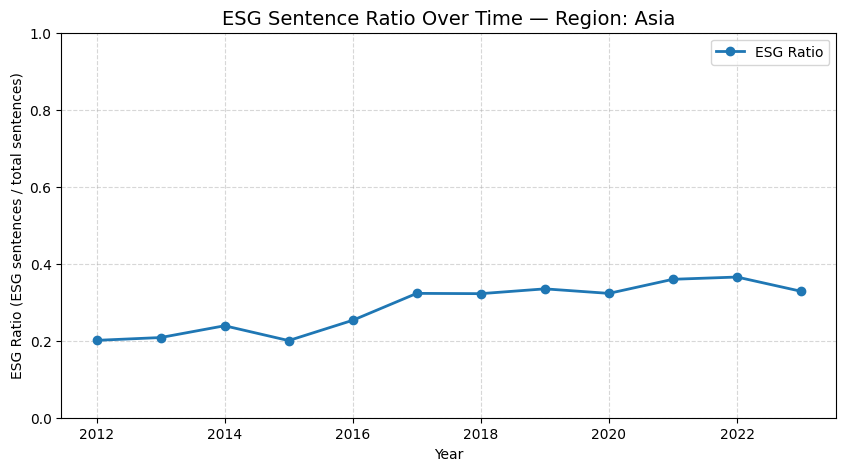

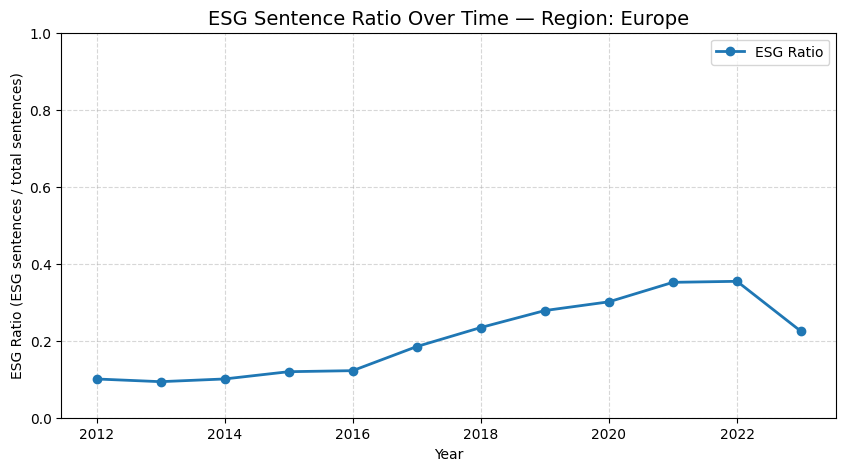

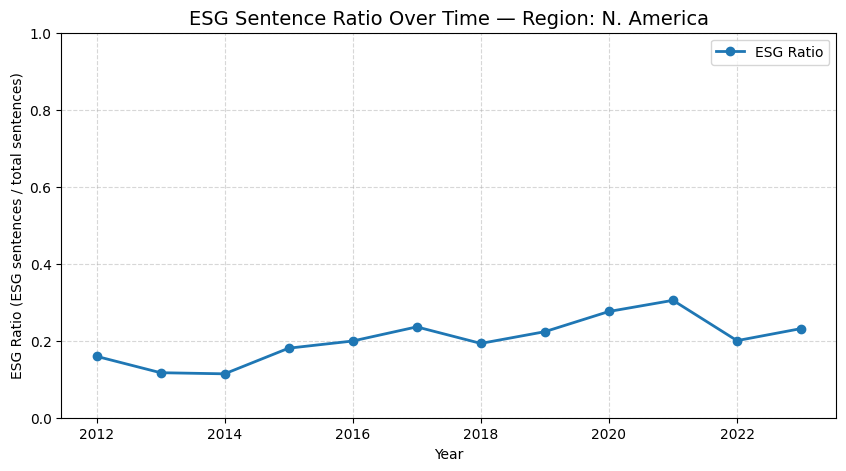

In [ ]:
# Calculate ESG-flagged sentences relative to the total number of sentences
df_ceo_esg_score['ESG_flag'] = (
    df_ceo_esg_score[['env_flag','soc_flag','gov_flag']].any(axis=1).astype(int)
)

df_esg_ratio_sentence = df_ceo_esg_score.groupby(['Region','Year']).agg(
    total_sentences=('Sentence', 'count'),
    esg_sentences=('ESG_flag', 'sum')
).reset_index()

df_esg_ratio_sentence['esg_ratio'] = df_esg_ratio_sentence['esg_sentences'] / df_esg_ratio_sentence['total_sentences']

display(df_esg_ratio_sentence)

import matplotlib.pyplot as plt

regions = df_esg_ratio_sentence['Region'].unique()

for region in regions:
    df_r = df_esg_ratio_sentence[df_esg_ratio_sentence['Region'] == region].sort_values('Year')

    plt.figure(figsize=(10, 5))
    plt.plot(df_r['Year'], df_r['esg_ratio'], marker='o', linewidth=2, label='ESG Ratio')

    plt.title(f"ESG Sentence Ratio Over Time — Region: {region}", fontsize=14)
    plt.xlabel("Year")
    plt.ylabel("ESG Ratio (ESG sentences / total sentences)")
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.show()

In [ ]:
import pandas as pd

# Rename columns for clarity
df_sent = df_ceo_esg_score  # your sentence-level df

print("=== FIRM-YEAR LEVEL ESG SENTENCE STATISTICS ===\n")

# ------------------------------------------------------------
# 1. Create ESG_flag for each sentence
# ------------------------------------------------------------
df_sent['ESG_flag'] = (
    df_sent[['env_flag', 'soc_flag', 'gov_flag']]
    .any(axis=1)
    .astype(int)
)

# ------------------------------------------------------------
# 2. Aggregate the data to firm-year level
# ------------------------------------------------------------
df_fy_esg = df_sent.groupby(['Company Name', 'Year']).agg(
    total_sentences=('Sentence', 'count'),
    esg_sentences=('ESG_flag', 'sum'),
    Region=('Region', 'first')  # keep region optionally
).reset_index()

df_fy_esg['esg_ratio'] = df_fy_esg['esg_sentences'] / df_fy_esg['total_sentences']

print(df_fy_esg.head())

# ------------------------------------------------------------
# 3. OVERALL STATISTICS (across all firm-years)
# ------------------------------------------------------------
print("\nTotal firm-year observations:", df_fy_esg.shape[0])
print("Total sentences:", df_fy_esg['total_sentences'].sum())
print("Total ESG sentences:", df_fy_esg['esg_sentences'].sum())

overall_ratio = (
    df_fy_esg['esg_sentences'].sum() /
    df_fy_esg['total_sentences'].sum()
)

print("Overall ESG ratio (all sentences pooled):", overall_ratio)

# ------------------------------------------------------------
# 4. DESCRIPTIVE STATISTICS — FIRM-YEAR
# ------------------------------------------------------------
print("\n=== DESCRIPTIVE STATISTICS: TOTAL SENTENCES PER FIRM-YEAR ===")
print(df_fy_esg['total_sentences'].describe(percentiles=[0.25, 0.5, 0.75]))

print("\n=== DESCRIPTIVE STATISTICS: ESG SENTENCES PER FIRM-YEAR ===")
print(df_fy_esg['esg_sentences'].describe(percentiles=[0.25, 0.5, 0.75]))

print("\n=== DESCRIPTIVE STATISTICS: ESG RATIO PER FIRM-YEAR ===")
print(df_fy_esg['esg_ratio'].describe(percentiles=[0.25, 0.5, 0.75]))

print("\nMean ESG ratio:", df_fy_esg['esg_ratio'].mean())
print("Std dev ESG ratio:", df_fy_esg['esg_ratio'].std())
print("Median ESG ratio:", df_fy_esg['esg_ratio'].median())
print("1st Quartile:", df_fy_esg['esg_ratio'].quantile(0.25))
print("3rd Quartile:", df_fy_esg['esg_ratio'].quantile(0.75))


# ------------------------------------------------------------
# 5. OPTIONAL — Statistics by Region (firm-year)
# ------------------------------------------------------------
print("\n=== ESG STATISTICS BY REGION (Firm-Year Level) ===")

for region in df_fy_esg['Region'].unique():
    df_r = df_fy_esg[df_fy_esg['Region'] == region]

    print(f"\n--- Region: {region} ---")

    print("Total firm-years:", df_r.shape[0])
    print("Total sentences:", df_r['total_sentences'].sum())
    print("Total ESG sentences:", df_r['esg_sentences'].sum())
    print("Overall ESG ratio:", df_r['esg_sentences'].sum() / df_r['total_sentences'].sum())

    print("\nSentence Count Stats:")
    print(df_r['total_sentences'].describe(percentiles=[0.25, 0.5, 0.75]))

    print("\nESG Sentence Stats:")
    print(df_r['esg_sentences'].describe(percentiles=[0.25, 0.5, 0.75]))

    print("\nESG Ratio Stats:")
    print(df_r['esg_ratio'].describe(percentiles=[0.25, 0.5, 0.75]))

=== FIRM-YEAR LEVEL ESG SENTENCE STATISTICS ===

  Company Name  Year  total_sentences  esg_sentences      Region  esg_ratio
0          AIG  2012               41              9  N. America   0.219512
1          AIG  2013               22              6  N. America   0.272727
2          AIG  2014               90              8  N. America   0.088889
3          AIG  2015              102             27  N. America   0.264706
4          AIG  2016               85              8  N. America   0.094118

Total firm-year observations: 238
Total sentences: 22806
Total ESG sentences: 5482
Overall ESG ratio (all sentences pooled): 0.24037533982285364

=== DESCRIPTIVE STATISTICS: TOTAL SENTENCES PER FIRM-YEAR ===
count    238.000000
mean      95.823529
std       83.461317
min       12.000000
25%       43.250000
50%       69.000000
75%      121.000000
max      512.000000
Name: total_sentences, dtype: float64

=== DESCRIPTIVE STATISTICS: ESG SENTENCES PER FIRM-YEAR ===
count    238.000000
mean   

In [ ]:
# Identify all firm-years with observed CEO-letter sentences
n_all = df_fy_esg.shape[0]

# Identify firm-years with at least one ESG sentence
n_esg_positive = (df_fy_esg["esg_sentences"] > 0).sum()

# Identify firm-years with zero ESG sentences
n_zero_esg = (df_fy_esg["esg_sentences"] == 0).sum()

print("Firm-years (all CEO letters):", n_all)
print("Firm-years with ≥1 ESG sentence:", n_esg_positive)
print("Firm-years with 0 ESG sentences:", n_zero_esg)

# Show which firm-years have zero ESG sentences
zero_esg_fy = df_fy_esg[df_fy_esg["esg_sentences"] == 0][["Company Name", "Year", "total_sentences", "esg_sentences", "esg_ratio"]]
display(zero_esg_fy.sort_values(["Company Name", "Year"]).head(20))

Firm-years (all CEO letters): 238
Firm-years with ≥1 ESG sentence: 236
Firm-years with 0 ESG sentences: 2


,Company Name,Year,total_sentences,esg_sentences,esg_ratio
94,MET,2014,87,0,0.0
198,Talanx,2018,30,0,0.0


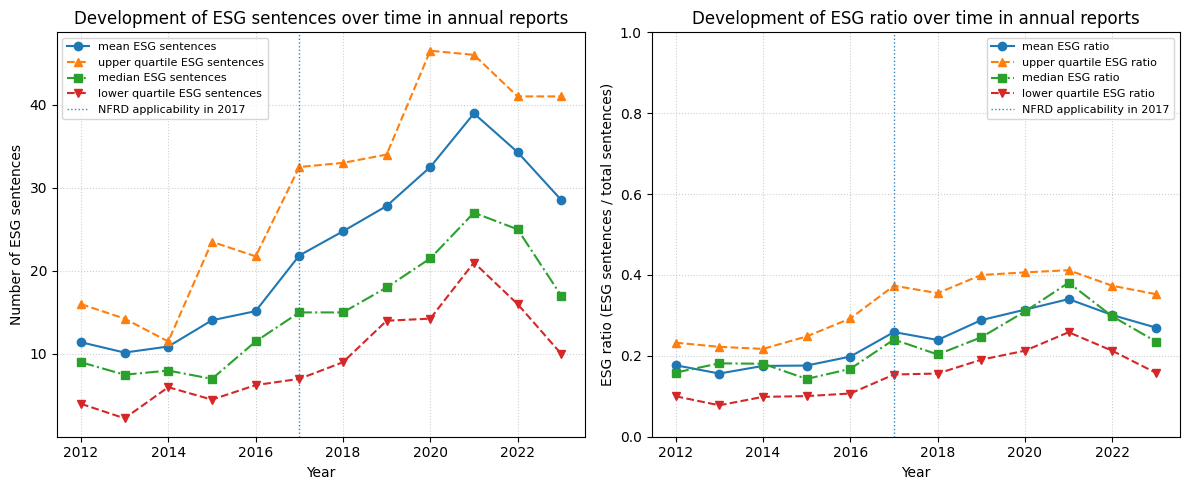

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# df_fy_esg is my firm-year level df with:
# ['Company Name', 'Year', 'total_sentences', 'esg_sentences', 'Region', 'esg_ratio']

# ------------------------------------------------------------
# 1. Calculate yearly statistics for ESG sentences and the ESG ratio
# ------------------------------------------------------------
year_stats = (
    df_fy_esg
    .groupby('Year')
    .agg(
        mean_esg_sentences=('esg_sentences', 'mean'),
        q1_esg_sentences=('esg_sentences', lambda x: x.quantile(0.25)),
        median_esg_sentences=('esg_sentences', 'median'),
        q3_esg_sentences=('esg_sentences', lambda x: x.quantile(0.75)),
        mean_esg_ratio=('esg_ratio', 'mean'),
        q1_esg_ratio=('esg_ratio', lambda x: x.quantile(0.25)),
        median_esg_ratio=('esg_ratio', 'median'),
        q3_esg_ratio=('esg_ratio', lambda x: x.quantile(0.75)),
    )
    .reset_index()
    .sort_values('Year')
)

years = year_stats['Year']

# ------------------------------------------------------------
# 2. Plot ESG sentences on the left and ESG ratio on the right
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# ---------- (a) Absolute ESG sentences ----------
ax = axes[0]

ax.plot(years, year_stats['mean_esg_sentences'], marker='o', linestyle='-',
        label='mean ESG sentences')
ax.plot(years, year_stats['q3_esg_sentences'], marker='^', linestyle='--',
        label='upper quartile ESG sentences')
ax.plot(years, year_stats['median_esg_sentences'], marker='s', linestyle='-.',
        label='median ESG sentences')
ax.plot(years, year_stats['q1_esg_sentences'], marker='v', linestyle='--',
        label='lower quartile ESG sentences')

# NFRD marker
ax.axvline(
    2017, linestyle=':', linewidth=1, alpha=0.9,
    label='NFRD applicability in 2017'
)

ax.set_title('Development of ESG sentences over time in annual reports')
ax.set_xlabel('Year')
ax.set_ylabel('Number of ESG sentences')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(fontsize=8)


# ---------- (b) ESG ratio ----------
ax2 = axes[1]

ax2.plot(years, year_stats['mean_esg_ratio'], marker='o', linestyle='-',
         label='mean ESG ratio')
ax2.plot(years, year_stats['q3_esg_ratio'], marker='^', linestyle='--',
         label='upper quartile ESG ratio')
ax2.plot(years, year_stats['median_esg_ratio'], marker='s', linestyle='-.',
         label='median ESG ratio')
ax2.plot(years, year_stats['q1_esg_ratio'], marker='v', linestyle='--',
         label='lower quartile ESG ratio')

# NFRD marker (same year, no duplicate label needed)
ax2.axvline(
    2017, linestyle=':', linewidth=1, alpha=0.9,
    label='NFRD applicability in 2017'
)

ax2.set_title('Development of ESG ratio over time in annual reports')
ax2.set_xlabel('Year')
ax2.set_ylabel('ESG ratio (ESG sentences / total sentences)')
ax2.set_ylim(0, 1)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Optional export as high-quality figure files
# ------------------------------------------------------------
data_dir = Path("/content/drive/MyDrive/phd/Data")
fig_dir = data_dir / "figures"
fig_dir.mkdir(exist_ok=True)

fig.savefig(
    fig_dir / "figure1_dev_esg_sentences_ar.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    fig_dir / "figure1_dev_esg_sentences_ar.pdf",
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    fig_dir / "figure1_dev_esg_sentences_ar.svg",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## 6.3 Run the Robustness Check: ESG Threshold 0.4


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Automatically use the GPU in Colab if available
device = 0 if torch.cuda.is_available() else -1
print("Using device:", "GPU" if device == 0 else "CPU")

# ------------------------------------------------------------
# Load the ENVIRONMENTAL model
# ------------------------------------------------------------
env_model_name = "ESGBERT/EnvRoBERTa-environmental"
env_tokenizer = AutoTokenizer.from_pretrained(env_model_name)
env_model = AutoModelForSequenceClassification.from_pretrained(env_model_name)

env_pipe = pipeline(
    task="text-classification",
    model=env_model,
    tokenizer=env_tokenizer,
    device=device,
    truncation=True
)

# ------------------------------------------------------------
# Load the SOCIAL model
# ------------------------------------------------------------
soc_model_name = "ESGBERT/SocRoBERTa-social"
soc_tokenizer = AutoTokenizer.from_pretrained(soc_model_name)
soc_model = AutoModelForSequenceClassification.from_pretrained(soc_model_name)

soc_pipe = pipeline(
    task="text-classification",
    model=soc_model,
    tokenizer=soc_tokenizer,
    device=device,
    truncation=True
)

# ------------------------------------------------------------
# Load the GOVERNANCE model
# ------------------------------------------------------------
gov_model_name = "ESGBERT/GovRoBERTa-governance"
gov_tokenizer = AutoTokenizer.from_pretrained(gov_model_name)
gov_model = AutoModelForSequenceClassification.from_pretrained(gov_model_name)

gov_pipe = pipeline(
    task="text-classification",
    model=gov_model,
    tokenizer=gov_tokenizer,
    device=device,
    truncation=True
)

Using device: GPU


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
import pandas as pd

# Load the sentence-split CEO letters
df_ceo_sentences = pd.read_csv(
    "/content/drive/MyDrive/phd/Data/df_ar_ceo_letters_sentence_split.csv"
)

# Run sanity checks
print("Shape:", df_ceo_sentences.shape)
display(df_ceo_sentences.head())

Shape: (23995, 7)


,Company Name,Year,Text,Region,Note,Timestamp,Sentence
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...
1,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"When I joined AIG in August 2009, we were sell..."
2,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ..."
3,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse..."
4,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,As we identified the insurance businesses that...


In [ ]:
df_ceo_sentences['word_count'] = df_ceo_sentences['Sentence'].apply(
    lambda x: len(str(x).split())
)

# Choose the filtering threshold; here, use at least 8 words
df_ceo_esg_score = df_ceo_sentences[df_ceo_sentences['word_count'] >= 8].copy()

# Alternatively, can run the analysis without filtering
# df_ceo_esg_score = df_ceo_sentences.copy()

In [ ]:
from tqdm.auto import tqdm

def batch_predict_binary(sentences, pipe, positive_label, batch_size=32):
    """
    Run a binary ESG-BERT pipeline in batches and return
    P(positive_label) for each sentence in order.

    positive_label examples:
      - "environmental"
      - "social"
      - "governance"
    """
    probs = []
    n = len(sentences)

    for start in tqdm(range(0, n, batch_size)):
        end = start + batch_size
        batch = sentences[start:end]

        # Pass the list of texts directly to the pipeline
        results = pipe(batch, batch_size=batch_size, truncation=True)

        for r in results:
            if r['label'] == positive_label:
                probs.append(r['score'])
            else:
                probs.append(1 - r['score'])

    return probs

In [ ]:
import time

# Start the total timer
start_total = time.time()

sentences = df_ceo_esg_score['Sentence'].tolist()

# Run all three models using the selected batch size
df_ceo_esg_score['prob_env'] = batch_predict_binary(sentences, env_pipe, positive_label="environmental", batch_size=32)
df_ceo_esg_score['prob_soc'] = batch_predict_binary(sentences, soc_pipe, positive_label="social", batch_size=32)
df_ceo_esg_score['prob_gov'] = batch_predict_binary(sentences, gov_pipe, positive_label="governance", batch_size=32)

# End the total timer
end_total = time.time()

runtime_minutes = (end_total - start_total) / 60
print(f"Total ESG-BERT runtime: {runtime_minutes:.2f} minutes")

  0%|          | 0/713 [00:00<?, ?it/s]

  0%|          | 0/713 [00:00<?, ?it/s]

  0%|          | 0/713 [00:00<?, ?it/s]

Total ESG-BERT runtime: 5.55 minutes


In [ ]:
threshold = 0.4   # change to 0.4 or 0.6 for robustness test

df_ceo_esg_score['env_flag'] = (df_ceo_esg_score['prob_env'] >= threshold).astype(int)
df_ceo_esg_score['soc_flag'] = (df_ceo_esg_score['prob_soc'] >= threshold).astype(int)
df_ceo_esg_score['gov_flag'] = (df_ceo_esg_score['prob_gov'] >= threshold).astype(int)

In [ ]:
def esg_multilabel(row):
    labels = []
    if row['env_flag'] == 1:
        labels.append('E')
    if row['soc_flag'] == 1:
        labels.append('S')
    if row['gov_flag'] == 1:
        labels.append('G')
    return ','.join(labels) if labels else 'None'

df_ceo_esg_score['ESG_multilabel'] = df_ceo_esg_score.apply(esg_multilabel, axis=1)

display(df_ceo_esg_score[df_ceo_esg_score[['env_flag', 'soc_flag', 'gov_flag']].any(axis=1)])

,Company Name,Year,Text,Region,Note,Timestamp,Sentence,word_count,prob_env,prob_soc,prob_gov,env_flag,soc_flag,gov_flag,ESG_multilabel
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...,46,0.012819,0.847576,0.003518,0,1,0,S
2,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ...",51,0.006075,0.954349,0.012917,0,1,0,S
3,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse...",15,0.001983,0.999662,0.000886,0,1,0,S
5,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,Only by reenergizing and empowering the people...,19,0.007930,0.999175,0.002745,0,1,0,S
15,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,2012 marks three years that we have adhered to...,35,0.002158,0.991119,0.005241,0,1,0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23947,Zurich,2022,\nBig strides toward our ambitious vision.\n\n...,Europe,Message from our Group CEO,25/10/2025 22:10:10,"For 2023, we refreshed our sustainability fram...",22,0.975853,0.999428,0.980782,1,1,1,"E,S,G"
23948,Zurich,2022,\nBig strides toward our ambitious vision.\n\n...,Europe,Message from our Group CEO,25/10/2025 22:10:10,We are growing our range of sustainable produc...,20,0.997668,0.999323,0.003319,1,1,0,"E,S"
23950,Zurich,2022,\nBig strides toward our ambitious vision.\n\n...,Europe,Message from our Group CEO,25/10/2025 22:10:10,And we will continue to embed our values and p...,18,0.002928,0.999469,0.154195,0,1,0,S
23963,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,Mario Greco Group Chief Executive Officer Zuri...,34,0.912179,0.000138,0.001928,1,0,0,E


In [ ]:
df_ceo_esg_score.drop(columns=['Text']).to_csv('/content/drive/MyDrive/phd/Data/df_ar_ceo_sentences_esgbert_scored_robust0.4.csv', index=False)

In [ ]:
import pandas as pd

# ------------------------------------------------------------
# 0. Inspect the dataset if needed
# ------------------------------------------------------------
display(df_ceo_esg_score)

# ------------------------------------------------------------
# 1. copy the dataset so the original remains unchanged
# ------------------------------------------------------------
df = df_ceo_esg_score.copy()

# ------------------------------------------------------------
# 2. Define the ESG flag using a robust definition
# ------------------------------------------------------------
df["ESG_flag"] = (
    df[["env_flag", "soc_flag", "gov_flag"]]
    .any(axis=1)
    .astype(int)
)

# ------------------------------------------------------------
# 3. Aggregate to firm-year level
# ------------------------------------------------------------
df_fy = df.groupby(["Company Name", "Year"]).agg(
    sentence_count=("Sentence", "count"),
    word_count=("word_count", "sum"),
    ESG_sentences=("ESG_flag", "sum"),
    env_sentences=("env_flag", "sum"),
    soc_sentences=("soc_flag", "sum"),
    gov_sentences=("gov_flag", "sum")
).reset_index()

# ------------------------------------------------------------
# 4. Compute ESG ratios
# ------------------------------------------------------------
df_fy["ESG_ratio"] = df_fy["ESG_sentences"] / df_fy["sentence_count"]
df_fy["E_ratio"] = df_fy["env_sentences"] / df_fy["sentence_count"]
df_fy["S_ratio"] = df_fy["soc_sentences"] / df_fy["sentence_count"]
df_fy["G_ratio"] = df_fy["gov_sentences"] / df_fy["sentence_count"]

# ------------------------------------------------------------
# 5. Keep observations with ESG content (optional)
# ------------------------------------------------------------
df_esg = df_fy[df_fy["ESG_sentences"] > 0].copy()

# ------------------------------------------------------------
# 6. Summary statistics function
# ------------------------------------------------------------
def summary_stats(series):
    return pd.Series({
        "Mean": series.mean(),
        "Std. dev": series.std(),
        "1st Quartile": series.quantile(0.25),
        "Median": series.median(),
        "3rd Quartile": series.quantile(0.75)
    })

# ------------------------------------------------------------
# 7. Create summary table
# ------------------------------------------------------------
summary_table = pd.DataFrame({
    "Word count": summary_stats(df_esg["word_count"]),
    "Sentence count": summary_stats(df_esg["sentence_count"]),
    "ESG sentences": summary_stats(df_esg["ESG_sentences"]),
    "ESG ratio": summary_stats(df_esg["ESG_ratio"]),
    "E ratio": summary_stats(df_esg["E_ratio"]),
    "S ratio": summary_stats(df_esg["S_ratio"]),
    "G ratio": summary_stats(df_esg["G_ratio"]),
}).T

# ------------------------------------------------------------
# 8. Display results
# ------------------------------------------------------------
print("\n=== Summary Statistics (Firm-Year Level) for 0.4 robustness check ===\n")
print(summary_table.round(4))

,Company Name,Year,Text,Region,Note,Timestamp,Sentence,word_count,prob_env,prob_soc,prob_gov,env_flag,soc_flag,gov_flag,ESG_multilabel
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...,46,0.012819,0.847576,0.003518,0,1,0,S
1,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"When I joined AIG in August 2009, we were sell...",20,0.003059,0.000127,0.001016,0,0,0,None
2,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ...",51,0.006075,0.954349,0.012917,0,1,0,S
3,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse...",15,0.001983,0.999662,0.000886,0,1,0,S
4,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,As we identified the insurance businesses that...,51,0.002387,0.000258,0.002312,0,0,0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23989,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,This compares favorably with the 9 percent ann...,18,0.005388,0.000128,0.001116,0,0,0,None
23990,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,In light of these record results and strong ca...,27,0.002576,0.000125,0.000827,0,0,0,None
23991,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,Zurich plans to supplement the ordinary divide...,17,0.002459,0.000118,0.001169,0,0,0,None
23992,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,"Looking ahead Customer focus, simplification a...",28,0.002752,0.000141,0.001780,0,0,0,None



=== Summary Statistics (Firm-Year Level) for 0.4 robustness check ===

                     Mean   Std. dev  1st Quartile     Median  3rd Quartile
Word count      2390.9746  2068.3499     1069.0000  1752.0000     3095.7500
Sentence count    96.1398    83.7031       43.7500    69.0000      121.2500
ESG sentences     23.5763    22.9168        8.0000    16.0000       29.0000
ESG ratio          0.2493     0.1293        0.1490     0.2252        0.3534
E ratio            0.0846     0.0664        0.0347     0.0705        0.1250
S ratio            0.1884     0.1245        0.0815     0.1641        0.2801
G ratio            0.0188     0.0246        0.0000     0.0103        0.0293


## 6.4 Run the Robustness Check: ESG Threshold 0.6


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Automatically use the GPU in Colab if available
device = 0 if torch.cuda.is_available() else -1
print("Using device:", "GPU" if device == 0 else "CPU")

# ------------------------------------------------------------
# Load the ENVIRONMENTAL model
# ------------------------------------------------------------
env_model_name = "ESGBERT/EnvRoBERTa-environmental"
env_tokenizer = AutoTokenizer.from_pretrained(env_model_name)
env_model = AutoModelForSequenceClassification.from_pretrained(env_model_name)

env_pipe = pipeline(
    task="text-classification",
    model=env_model,
    tokenizer=env_tokenizer,
    device=device,
    truncation=True
)

# ------------------------------------------------------------
# Load the SOCIAL model
# ------------------------------------------------------------
soc_model_name = "ESGBERT/SocRoBERTa-social"
soc_tokenizer = AutoTokenizer.from_pretrained(soc_model_name)
soc_model = AutoModelForSequenceClassification.from_pretrained(soc_model_name)

soc_pipe = pipeline(
    task="text-classification",
    model=soc_model,
    tokenizer=soc_tokenizer,
    device=device,
    truncation=True
)

# ------------------------------------------------------------
# Load the GOVERNANCE model
# ------------------------------------------------------------
gov_model_name = "ESGBERT/GovRoBERTa-governance"
gov_tokenizer = AutoTokenizer.from_pretrained(gov_model_name)
gov_model = AutoModelForSequenceClassification.from_pretrained(gov_model_name)

gov_pipe = pipeline(
    task="text-classification",
    model=gov_model,
    tokenizer=gov_tokenizer,
    device=device,
    truncation=True
)

Using device: GPU


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
import pandas as pd

# Load the sentence-split CEO letters
df_ceo_sentences = pd.read_csv(
    "/content/drive/MyDrive/phd/Data/df_ar_ceo_letters_sentence_split.csv"
)

# Run sanity checks
print("Shape:", df_ceo_sentences.shape)
display(df_ceo_sentences.head())

Shape: (23995, 7)


,Company Name,Year,Text,Region,Note,Timestamp,Sentence
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...
1,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"When I joined AIG in August 2009, we were sell..."
2,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ..."
3,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse..."
4,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,As we identified the insurance businesses that...


In [ ]:
df_ceo_sentences['word_count'] = df_ceo_sentences['Sentence'].apply(
    lambda x: len(str(x).split())
)

# Choose the filtering threshold; here, use at least 8 words
df_ceo_esg_score = df_ceo_sentences[df_ceo_sentences['word_count'] >= 8].copy()

# Alternatively, can run the analysis without filtering
# df_ceo_esg_score = df_ceo_sentences.copy()

In [ ]:
from tqdm.auto import tqdm

def batch_predict_binary(sentences, pipe, positive_label, batch_size=32):
    """
    Run a binary ESG-BERT pipeline in batches and return
    P(positive_label) for each sentence in order.

    positive_label examples:
      - "environmental"
      - "social"
      - "governance"
    """
    probs = []
    n = len(sentences)

    for start in tqdm(range(0, n, batch_size)):
        end = start + batch_size
        batch = sentences[start:end]

        # Pass the list of texts directly to the pipeline
        results = pipe(batch, batch_size=batch_size, truncation=True)

        for r in results:
            if r['label'] == positive_label:
                probs.append(r['score'])
            else:
                probs.append(1 - r['score'])

    return probs

In [ ]:
import time

# Start the total timer
start_total = time.time()

sentences = df_ceo_esg_score['Sentence'].tolist()

# Run all three models using the selected batch size
df_ceo_esg_score['prob_env'] = batch_predict_binary(sentences, env_pipe, positive_label="environmental", batch_size=32)
df_ceo_esg_score['prob_soc'] = batch_predict_binary(sentences, soc_pipe, positive_label="social", batch_size=32)
df_ceo_esg_score['prob_gov'] = batch_predict_binary(sentences, gov_pipe, positive_label="governance", batch_size=32)

# End the total timer
end_total = time.time()

runtime_minutes = (end_total - start_total) / 60
print(f"Total ESG-BERT runtime: {runtime_minutes:.2f} minutes")

  0%|          | 0/713 [00:00<?, ?it/s]

  0%|          | 0/713 [00:00<?, ?it/s]

  0%|          | 0/713 [00:00<?, ?it/s]

Total ESG-BERT runtime: 5.57 minutes


In [ ]:
threshold = 0.6   # change to 0.4 or 0.6 for robustness test

df_ceo_esg_score['env_flag'] = (df_ceo_esg_score['prob_env'] >= threshold).astype(int)
df_ceo_esg_score['soc_flag'] = (df_ceo_esg_score['prob_soc'] >= threshold).astype(int)
df_ceo_esg_score['gov_flag'] = (df_ceo_esg_score['prob_gov'] >= threshold).astype(int)

In [ ]:
def esg_multilabel(row):
    labels = []
    if row['env_flag'] == 1:
        labels.append('E')
    if row['soc_flag'] == 1:
        labels.append('S')
    if row['gov_flag'] == 1:
        labels.append('G')
    return ','.join(labels) if labels else 'None'

df_ceo_esg_score['ESG_multilabel'] = df_ceo_esg_score.apply(esg_multilabel, axis=1)

display(df_ceo_esg_score[df_ceo_esg_score[['env_flag', 'soc_flag', 'gov_flag']].any(axis=1)])

,Company Name,Year,Text,Region,Note,Timestamp,Sentence,word_count,prob_env,prob_soc,prob_gov,env_flag,soc_flag,gov_flag,ESG_multilabel
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...,46,0.012819,0.847576,0.003518,0,1,0,S
2,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ...",51,0.006075,0.954349,0.012917,0,1,0,S
3,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse...",15,0.001983,0.999662,0.000886,0,1,0,S
5,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,Only by reenergizing and empowering the people...,19,0.007930,0.999175,0.002745,0,1,0,S
15,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,2012 marks three years that we have adhered to...,35,0.002158,0.991119,0.005241,0,1,0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23947,Zurich,2022,\nBig strides toward our ambitious vision.\n\n...,Europe,Message from our Group CEO,25/10/2025 22:10:10,"For 2023, we refreshed our sustainability fram...",22,0.975853,0.999428,0.980782,1,1,1,"E,S,G"
23948,Zurich,2022,\nBig strides toward our ambitious vision.\n\n...,Europe,Message from our Group CEO,25/10/2025 22:10:10,We are growing our range of sustainable produc...,20,0.997668,0.999323,0.003319,1,1,0,"E,S"
23950,Zurich,2022,\nBig strides toward our ambitious vision.\n\n...,Europe,Message from our Group CEO,25/10/2025 22:10:10,And we will continue to embed our values and p...,18,0.002928,0.999469,0.154195,0,1,0,S
23963,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,Mario Greco Group Chief Executive Officer Zuri...,34,0.912179,0.000138,0.001928,1,0,0,E


In [ ]:
df_ceo_esg_score.drop(columns=['Text']).to_csv('/content/drive/MyDrive/phd/Data/df_ar_ceo_sentences_esgbert_scored_robust0.6.csv', index=False)

In [ ]:
import pandas as pd

# ------------------------------------------------------------
# 0. Inspect the dataset if needed
# ------------------------------------------------------------
display(df_ceo_esg_score)

# ------------------------------------------------------------
# 1. copy the dataset so the original remains unchanged
# ------------------------------------------------------------
df = df_ceo_esg_score.copy()

# ------------------------------------------------------------
# 2. Define the ESG flag using a robust definition
# ------------------------------------------------------------
df["ESG_flag"] = (
    df[["env_flag", "soc_flag", "gov_flag"]]
    .any(axis=1)
    .astype(int)
)

# ------------------------------------------------------------
# 3. Aggregate to firm-year level
# ------------------------------------------------------------
df_fy = df.groupby(["Company Name", "Year"]).agg(
    sentence_count=("Sentence", "count"),
    word_count=("word_count", "sum"),
    ESG_sentences=("ESG_flag", "sum"),
    env_sentences=("env_flag", "sum"),
    soc_sentences=("soc_flag", "sum"),
    gov_sentences=("gov_flag", "sum")
).reset_index()

# ------------------------------------------------------------
# 4. Compute ESG ratios
# ------------------------------------------------------------
df_fy["ESG_ratio"] = df_fy["ESG_sentences"] / df_fy["sentence_count"]
df_fy["E_ratio"] = df_fy["env_sentences"] / df_fy["sentence_count"]
df_fy["S_ratio"] = df_fy["soc_sentences"] / df_fy["sentence_count"]
df_fy["G_ratio"] = df_fy["gov_sentences"] / df_fy["sentence_count"]

# ------------------------------------------------------------
# 5. Keep observations with ESG content (optional)
# ------------------------------------------------------------
df_esg = df_fy[df_fy["ESG_sentences"] > 0].copy()

# ------------------------------------------------------------
# 6. Summary statistics function
# ------------------------------------------------------------
def summary_stats(series):
    return pd.Series({
        "Mean": series.mean(),
        "Std. dev": series.std(),
        "1st Quartile": series.quantile(0.25),
        "Median": series.median(),
        "3rd Quartile": series.quantile(0.75)
    })

# ------------------------------------------------------------
# 7. Create summary table
# ------------------------------------------------------------
summary_table = pd.DataFrame({
    "Word count": summary_stats(df_esg["word_count"]),
    "Sentence count": summary_stats(df_esg["sentence_count"]),
    "ESG sentences": summary_stats(df_esg["ESG_sentences"]),
    "ESG ratio": summary_stats(df_esg["ESG_ratio"]),
    "E ratio": summary_stats(df_esg["E_ratio"]),
    "S ratio": summary_stats(df_esg["S_ratio"]),
    "G ratio": summary_stats(df_esg["G_ratio"]),
}).T

# ------------------------------------------------------------
# 8. Display results
# ------------------------------------------------------------
print("\n=== Summary Statistics (Firm-Year Level) for 0.6 robustness check ===\n")
print(summary_table.round(4))

,Company Name,Year,Text,Region,Note,Timestamp,Sentence,word_count,prob_env,prob_soc,prob_gov,env_flag,soc_flag,gov_flag,ESG_multilabel
0,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...,46,0.012819,0.847576,0.003518,0,1,0,S
1,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"When I joined AIG in August 2009, we were sell...",20,0.003059,0.000127,0.001016,0,0,0,None
2,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ...",51,0.006075,0.954349,0.012917,0,1,0,S
3,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse...",15,0.001983,0.999662,0.000886,0,1,0,S
4,AIG,2012,OBERT H. BENMOSCHE President and Chief Executi...,N. America,NaN,02/08/2026 23:04:50,As we identified the insurance businesses that...,51,0.002387,0.000258,0.002312,0,0,0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23989,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,This compares favorably with the 9 percent ann...,18,0.005388,0.000128,0.001116,0,0,0,None
23990,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,In light of these record results and strong ca...,27,0.002576,0.000125,0.000827,0,0,0,None
23991,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,Zurich plans to supplement the ordinary divide...,17,0.002459,0.000118,0.001169,0,0,0,None
23992,Zurich,2023,Delivering excellent results. \n\nThe first ye...,Europe,Message from our Group CEO,25/10/2025 22:13:23,"Looking ahead Customer focus, simplification a...",28,0.002752,0.000141,0.001780,0,0,0,None



=== Summary Statistics (Firm-Year Level) for 0.6 robustness check ===

                     Mean   Std. dev  1st Quartile     Median  3rd Quartile
Word count      2390.9746  2068.3499     1069.0000  1752.0000     3095.7500
Sentence count    96.1398    83.7031       43.7500    69.0000      121.2500
ESG sentences     22.8517    22.1839        8.0000    15.5000       28.0000
ESG ratio          0.2424     0.1279        0.1429     0.2236        0.3491
E ratio            0.0817     0.0649        0.0331     0.0690        0.1196
S ratio            0.1836     0.1230        0.0787     0.1603        0.2679
G ratio            0.0175     0.0243        0.0000     0.0063        0.0281


## 6.5 Run the Additional Topic Analysis


In [ ]:
# # Extra Topic Analysis (answers Q1 + Q2)
# # Q1: which issues/themes are most discussed (by Region)
# # Q2: does it change over time? -> compare 2012–2016 vs 2017–2023 (by Region)

import pandas as pd
import numpy as np

file_path = '/content/drive/MyDrive/phd/Data/df_ar_ceo_sentences_esgbert_scored.csv'
df = pd.read_csv(file_path)

# ------------------------------------------------------------
# 0) Install and import the required packages
# ------------------------------------------------------------
!pip -q install bertopic sentence-transformers umap-learn hdbscan

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text

In [ ]:
# ------------------------------------------------------------
# 1) Define stopwords and the vectorizer to remove common words such as “we”, “and”, “to”, and “the”
# ------------------------------------------------------------

custom_stop_words = {
    # Company and brand names
    "axa",
    "chubb",
    "chubbs",
    "sompo",
    "sompos",
    "swiss",
    "prudential",
    "prudentials",

    # Executive names
    "buberl",
    "thomas",
    "mumenthaler",

    # Organisational boilerplate
    "group",
    "holdings",
    "company",
    "companies",
    "ceo",
    "director",
    "executive",
    "representative",


    # Unclear acronym/noisy token
    "gi",
    "di"
}

stop_words = set(text.ENGLISH_STOP_WORDS).union(custom_stop_words)

from sklearn.feature_extraction.text import CountVectorizer

def make_vectorizer(n_docs, stop_words):
    """
    BERTopic vectorizer that:
    - removes English and custom stop words;
    - produces unigrams and bigrams;
    - excludes purely numerical tokens;
    - retains alphanumeric terms such as CO2.
    """
    return CountVectorizer(
        stop_words=list(stop_words),
        ngram_range=(1, 2),
        min_df=1,
        max_df=1.0,
        lowercase=True,
        token_pattern=r"(?u)\b(?=\w*[^\W\d_])\w{2,}\b"
    )

In [ ]:
# ------------------------------------------------------------
# 2) Filter to ESG sentences so Q1 and Q2 focus on the ESG narrative
#
# ------------------------------------------------------------
df_esg = df[(df['env_flag'].eq(1)) | (df['soc_flag'].eq(1)) | (df['gov_flag'].eq(1))].copy()

# Clean the text
df_esg["Sentence"] = (
    df_esg["Sentence"].astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
df_esg = df_esg[df_esg["Sentence"].str.len() >= 20].copy()

In [ ]:
# ------------------------------------------------------------
# 3) Create time windows for Q2
# ------------------------------------------------------------
# Ensure that Year is numeric
df_esg["Year"] = pd.to_numeric(df_esg["Year"], errors="coerce")

# Create the period variable safely to avoid dtype-promotion issues
df_esg["period"] = pd.Series(pd.NA, index=df_esg.index, dtype="string")
df_esg.loc[df_esg["Year"].between(2012, 2016), "period"] = "2012-2016"
df_esg.loc[df_esg["Year"].between(2017, 2023), "period"] = "2017-2023"

# Keep only the two comparison windows
df_esg = df_esg.dropna(subset=["period"]).copy()

In [ ]:
# ------------------------------------------------------------
# 4) Fit BERTopic for each region-period combination
# Print the top themes with keywords and examples
# ------------------------------------------------------------
def show_topic_examples(df_subset, topic_model, topics, topic_id, n=5):
    idx = np.where(np.array(topics) == topic_id)[0]
    examples = df_subset.iloc[idx]["Sentence"].head(n).tolist()
    words = topic_model.get_topic(topic_id)  # list of (word, weight)
    top_terms = [w for w, _ in (words or [])[:12]]
    return top_terms, examples

results = {}  # store models/results if you want later tables/plots

regions = df_esg["Region"].dropna().unique()
periods = ["2012-2016", "2017-2023"]

for r in regions:
    for p in periods:
        df_rp = df_esg[(df_esg["Region"].eq(r)) & (df_esg["period"].eq(p))].reset_index(drop=True)
        docs = df_rp["Sentence"].tolist()

        if len(docs) < 250:
            print(f"\nSkip Region={r}, period={p}: only {len(docs)} ESG sentences")
            continue

        vectorizer_model = make_vectorizer(len(docs), stop_words)

        topic_model = BERTopic(
            vectorizer_model=vectorizer_model,
            language="english",
            calculate_probabilities=False,
            verbose=False
        )


        topics, _ = topic_model.fit_transform(docs)
        info = topic_model.get_topic_info()

        results[(r, p)] = {"model": topic_model, "topics": topics, "info": info, "df": df_rp}

        print("\n=================================================")
        print(f"Region: {r} | Period: {p} | N={len(docs)}")
        print(f"Topics found (excl. -1 outlier): {info.shape[0]-1}")

        # Keep the top five non-outlier topics
        top_topic_ids = info.loc[info["Topic"] != -1, "Topic"].head(5).tolist()

        for tid in top_topic_ids:
            size = int(info.loc[info["Topic"] == tid, "Count"].values[0])
            top_terms, ex = show_topic_examples(df_rp, topic_model, topics, tid, n=5)

            print(f"\nTopic {tid} | Size={size}")
            print("Top terms:", top_terms)
            print("Examples:")
            for s in ex:
                print("-", s[:220])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Region: N. America | Period: 2012-2016 | N=375
Topics found (excl. -1 outlier): 13

Topic 0 | Size=45
Top terms: ['military', 'talent', 'years', 'culture', 'best', 'diversity', 'inclusion', 'diversity inclusion', 'jobs', 'veterans']
Examples:
- We are committed to developing and retaining our best talent, promoting diversity, and encouraging and empowering employ- ees to work together.
- •We value the diversity of perspectives that comes from all places and people.
- our clients without attracting and retaining world-class employees whose diversity gives us unique insights into the global marketplace.
- I spent much of the past year meeting with employees around the globe to hear their views on where we are, where we want to be, and how we can get there.
- Over time, we embedded leadership practices and a culture that will guide decisions throughout this large and diverse company for years to come.

Topic 1 | Size=28
Top terms: ['weather', 'storm', 'sandy', 'equity', 'losses', 'rates'

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Region: N. America | Period: 2017-2023 | N=1701
Topics found (excl. -1 outlier): 37

Topic 0 | Size=149
Top terms: ['world', 'economic', 'country', 'political', 'democracy', 'values', 'society', 'prosperity', 'rule law', 'law']
Examples:
- We are their allies from now to next.
- Capital, people, intelligence and processes are combined to make the world a better place.
- Quite simply, the world is a better place because of one of society’s greatest organizational creations: business.
- To continue creating prosperity businesses must take on a bigger role in society.
- Let’s be clear, a business needs to make an acceptable profit since this is a measure of how effectively it uses society’s resources.

Topic 1 | Size=75
Top terms: ['diversity', 'inclusion', 'equity', 'inclusive', 'diversity equity', 'gender', 'equity inclusion', 'compensation', 'dei', 'diversity inclusion']
Examples:
- We also aim to make a difference through our commitment to sustainability and corporate citizenship, wh

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...


Region: Europe | Period: 2017-2023 | N=897
Topics found (excl. -1 outlier): 23

Topic 0 | Size=131
Top terms: ['natural', 'losses', 'natural catastrophes', 'catastrophes', 'year', 'disasters', 'events', 'catastrophe', 'flood', 'natural disasters']
Examples:
- Based on data from satellites, weather stations and other high-quality data sources, they are now available in over 40 countries, covering a range of risks, mainly climatic and natural disasters, in many areas, including
- All of us were affected, changing the way we work and live, all too often suffering or seeing loved ones suffer.
- Individuals, organizations, and communities were affected to varying extents, but without exception.
- As highlighted in the yearly edition of our Future Risk Report, the climate crisis continues to be a major concern, and 2021 was an important year for climate action ahead of and at COP26.
- In addition, 2022 was once again a year of numerous, high-intensity natural disasters, reflecting the situa

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Region: Asia | Period: 2012-2016 | N=489
Topics found (excl. -1 outlier): 9

Topic 0 | Size=99
Top terms: ['insurance', 'business', 'life', 'security', 'customers', 'life insurance', 'health', 'medical', 'support', 'products']
Examples:
- While fulfilling its obligations under insurance policies, the Company actively undertook its corporate social responsibility.
- Relying on its competitive advantages in professionalism and business scale, the Company continued to develop policy businesses including New Village Cooperative Medical Insurance, New Rural Pension Insurance, Basic Medi
- Taking a long-term perspective, the goal of building a moderately prosperous society and deepening the “Reform and Opening up” in all respects laid and strengthened the economic and institutional foundation for the devel
- While fulfilling its obligations under insurance policies, the Company continued to actively maintain its devotion to corporate social responsibility.
- Relying on its competitive advan

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Region: Asia | Period: 2017-2023 | N=1730
Topics found (excl. -1 outlier): 32

Topic 0 | Size=98
Top terms: ['insurance', 'services', 'business', 'life insurance', 'insurance business', 'life', 'social', 'role', 'customers', 'development']
Examples:
- Upholding social responsibilities and caring for people’s well-being: We focused on our principal business and enhanced our expertise to exert the function of insurance in long-term risk management and protection.
- Life insurance is a business of responsibility and care.
- After the outbreak of COVID-19 in early 2020, the Company took immediate actions in providing insurance protection, donating epidemic prevention supplies, and offering health-related insurance services, etc.
- We will seize the new changes of current opportunities and challenges, further mobilize the advantage of risk management expertise in our principal businesses, implement the new development concept, actively explore to b
- In this new promising era, we will stic

In [ ]:
# ------------------------------------------------------------
# 5) Optional: create a quick “change over time” summary by region
# Print the top 10 keywords from the top 3 topics for each period side by side
# ------------------------------------------------------------
print("\n\n==================== CHANGE OVER TIME SUMMARY ====================")
for r in regions:
    if (r, "2012-2016") not in results or (r, "2017-2023") not in results:
        continue

    info_old = results[(r, "2012-2016")]["info"]
    info_new = results[(r, "2017-2023")]["info"]

    tm_old = results[(r, "2012-2016")]["model"]
    tm_new = results[(r, "2017-2023")]["model"]

    top_old = info_old.loc[info_old["Topic"] != -1, "Topic"].head(3).tolist()
    top_new = info_new.loc[info_new["Topic"] != -1, "Topic"].head(3).tolist()

    print("\n-------------------------------------------------")
    print(f"Region: {r}")

    print("2012–2016 top themes:")
    for tid in top_old:
        terms = [w for w, _ in (tm_old.get_topic(tid) or [])[:11]]
        print(f"  - Topic {tid}: {terms}")

    print("2017–2023 top themes:")
    for tid in top_new:
        terms = [w for w, _ in (tm_new.get_topic(tid) or [])[:11]]
        print(f"  - Topic {tid}: {terms}")



==================== CHANGE OVER TIME SUMMARY ====================

-------------------------------------------------
Region: N. America
2012–2016 top themes:
  - Topic 0: ['military', 'talent', 'years', 'culture', 'best', 'diversity', 'inclusion', 'diversity inclusion', 'jobs', 'veterans']
  - Topic 1: ['weather', 'storm', 'sandy', 'equity', 'losses', 'rates', 'wind', 'severe', 'low rates', 'catastrophes']
  - Topic 2: ['allstate', 'agency', 'local', 'communities', 'employees agency', 'allstates', 'different', 'proactive', 'future', 'agency owners']
2017–2023 top themes:
  - Topic 0: ['world', 'economic', 'country', 'political', 'democracy', 'values', 'society', 'prosperity', 'rule law', 'law']
  - Topic 1: ['diversity', 'inclusion', 'equity', 'inclusive', 'diversity equity', 'gender', 'equity inclusion', 'compensation', 'dei', 'diversity inclusion']
  - Topic 2: ['crop', 'foundation', 'fund', 'insurance', 'climate', 'business', 'project', 'america', 'support', 'projects']

--------

In [ ]:
# ------------------------------------------------------------
# Create the Sankey diagram for topic evolution from 2012–2016 to 2017–2023
# ------------------------------------------------------------
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import plotly.graph_objects as go

print("\n\n==================== SANKEY DIAGRAMS ====================")

for r in regions:
    if (r, "2012-2016") not in results or (r, "2017-2023") not in results:
        continue

    print(f"\nBuilding Sankey for: {r}")

    tm_old = results[(r, "2012-2016")]["model"]
    tm_new = results[(r, "2017-2023")]["model"]

    info_old = results[(r, "2012-2016")]["info"]
    info_new = results[(r, "2017-2023")]["info"]

    # ----------------------------
    # 1) Select topics, exclude topic -1, and optionally limit to the top N topics
    # ----------------------------
    topics_old = info_old.loc[info_old["Topic"] != -1, "Topic"].head(9).tolist()
    topics_new = info_new.loc[info_new["Topic"] != -1, "Topic"].head(9).tolist()

    # ----------------------------
    # 2) Extract embeddings
    # ----------------------------
    emb_old = tm_old.topic_embeddings_[topics_old]
    emb_new = tm_new.topic_embeddings_[topics_new]

    # ----------------------------
    # 3) Compute similarity
    # ----------------------------
    sim_matrix = cosine_similarity(emb_old, emb_new)

    # ----------------------------
    # 4) Match topics (with threshold)
    # ----------------------------
    threshold = 0.8
    matches = []

    for i, t_old in enumerate(topics_old):
        j = np.argmax(sim_matrix[i])
        t_new = topics_new[j]
        sim = sim_matrix[i, j]

        if sim >= threshold:
            matches.append((t_old, t_new, sim))

    # ----------------------------
    # 5) Topic sizes
    # ----------------------------
    size_old = dict(zip(info_old.Topic, info_old.Count))

    # ----------------------------
    # 6) Label function
    # ----------------------------
    def get_label(model, topic_id):
        words = [w for w, _ in (model.get_topic(topic_id) or [])[:3]]
        return " / ".join(words)

    # ----------------------------
    # 7) Build Sankey inputs
    # ----------------------------
    sources = []
    targets = []
    values = []

    for t_old, t_new, sim in matches:
        label_old = f"2012–16: {get_label(tm_old, t_old)}"
        label_new = f"2017–23: {get_label(tm_new, t_new)}"

        sources.append(label_old)
        targets.append(label_new)

        values.append(size_old.get(t_old, 0) * sim)

    # ----------------------------
    # 8) Convert to indices
    # ----------------------------
    labels = list(set(sources + targets))
    label_index = {label: i for i, label in enumerate(labels)}

    source_idx = [label_index[s] for s in sources]
    target_idx = [label_index[t] for t in targets]

    # ----------------------------
    # 9) Plot Sankey
    # ----------------------------
    fig = go.Figure(go.Sankey(
        node=dict(
            label=labels,
            pad=15,
            thickness=15
        ),
        link=dict(
            source=source_idx,
            target=target_idx,
            value=values
        )
    ))

    fig.update_layout(
        title_text=f"Topic Evolution (BERTopic) – {r}",
        font_size=10
    )

    fig.show()



==================== SANKEY DIAGRAMS ====================

Building Sankey for: N. America



Building Sankey for: Europe



Building Sankey for: Asia


## 6.6 Create the Heatmap Visuals for the DVfVW Plot


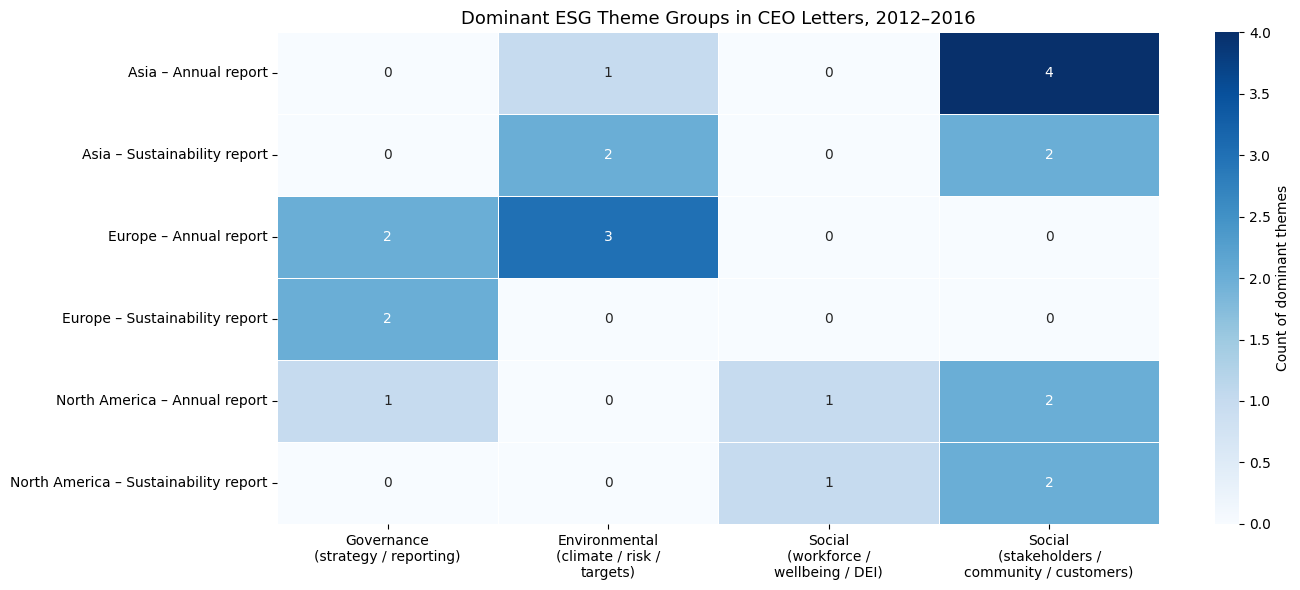

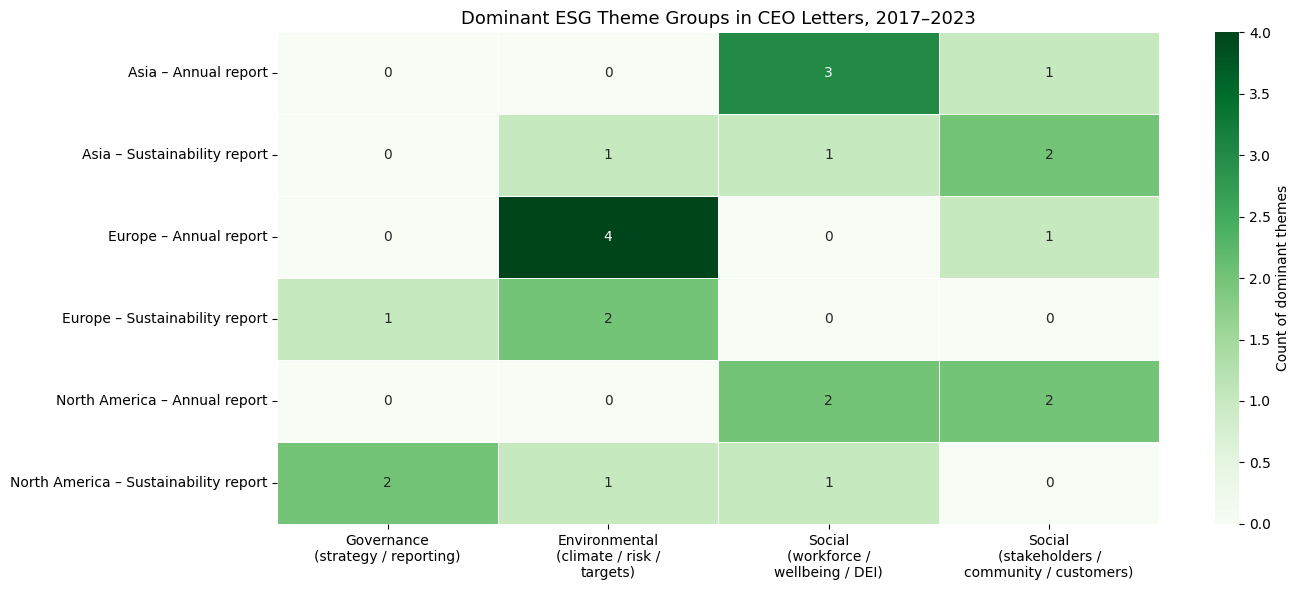

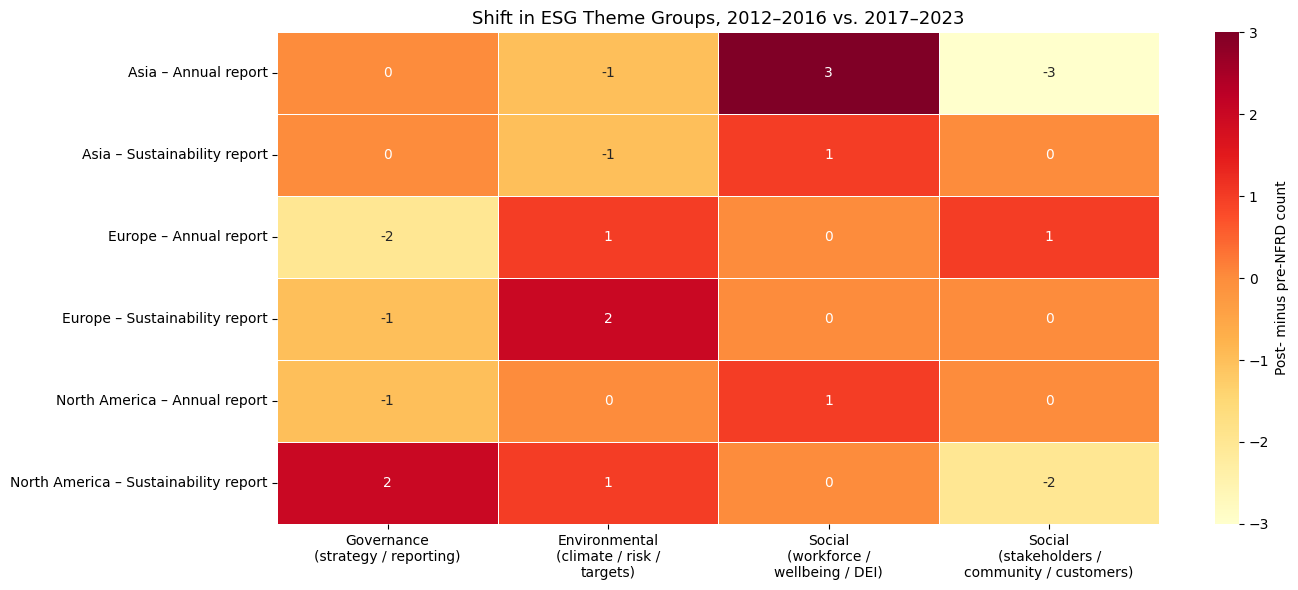

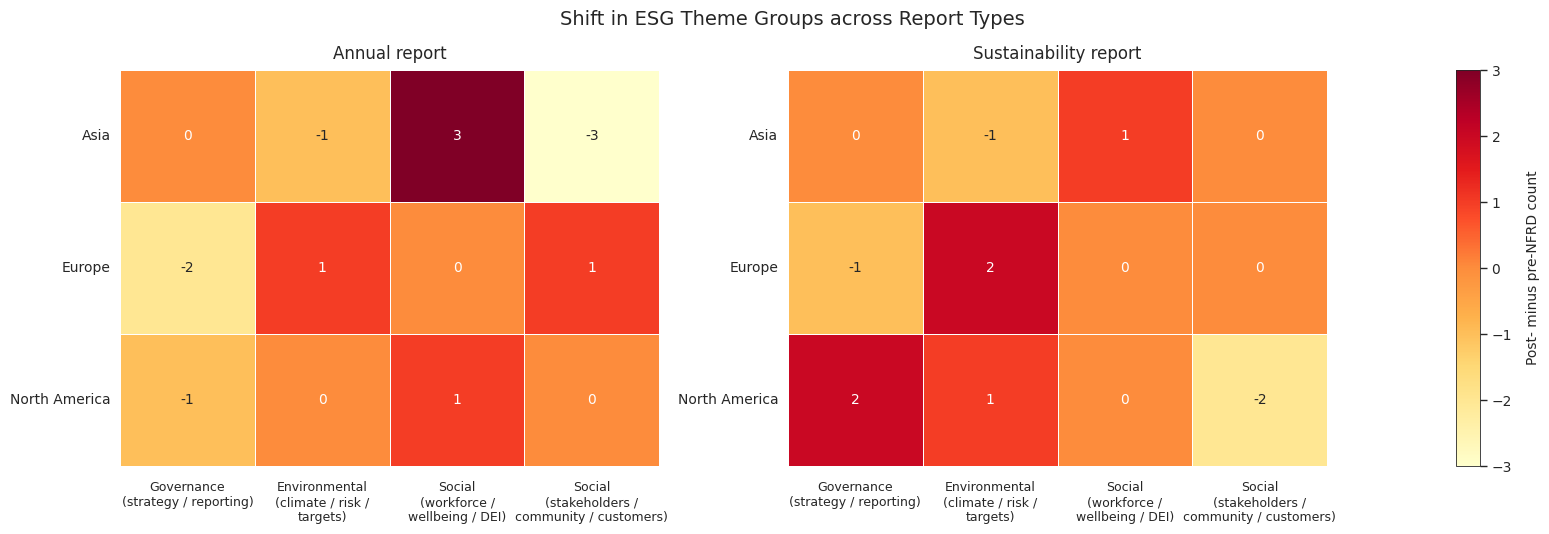

In [ ]:
# ============================================================
# Create a heatmap using E/S/G-based grouped GRI categories
# Use the updated version with cleaner wrapped labels
# Run this cell in Google Colab
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. enter my topics with GRI mappings from Tables 2 and 3
# Each row represents one topic
# ------------------------------------------------------------
topics = [
    # =========================
    # TABLE 2: ANNUAL REPORTS
    # =========================

    ["Asia", "Annual report", "2012-2016",
     "insurance, security, support, services, health, products, insurance business, life, including",
     ["GRI 416", "GRI 413"]],
    ["Asia", "Annual report", "2012-2016",
     "stakeholders, customers, value, people, continue, vision, action, mission, work, highest",
     ["GRI 413", "GRI 414"]],
    ["Asia", "Annual report", "2012-2016",
     "risk, increase, region, japan, fiscal, global, measures, model, overseas, billion",
     ["GRI 201-2"]],

    ["Asia", "Annual report", "2017-2023",
     "insurance, services, support, people, new, providing, company, health, management, life",
     ["GRI 416"]],
    ["Asia", "Annual report", "2017-2023",
     "challenges, wellbeing, health, employees, create, corporate, new, culture, management, make",
     ["GRI 403", "GRI 401"]],
    ["Asia", "Annual report", "2017-2023",
     "diversity, diverse, groups, human, promoting, important, believe, culture, values, realize",
     ["GRI 405"]],

    ["Europe", "Annual report", "2012-2016",
     "corporate, new, responsibility, group, value, culture, people, work, management, commitment",
     ["GRI 2", "GRI 3"]],
    ["Europe", "Annual report", "2012-2016",
     "country, interests, lead, opportunity, security, challenges, economic, people, global, open",
     ["GRI 201-2"]],
    ["Europe", "Annual report", "2012-2016",
     "losses, natural, disasters, natural disasters, catastrophe, major, sandy, million, storm, year",
     ["GRI 201-2", "GRI 305"]],

    ["Europe", "Annual report", "2017-2023",
     "economic, group, society, including, social, global, time, support, businesses, year",
     ["GRI 413"]],
    ["Europe", "Annual report", "2017-2023",
     "natural, year, climate change, years, change, climate, risk, impact, insurance, time",
     ["GRI 305", "GRI 201-2"]],
    ["Europe", "Annual report", "2017-2023",
     "support, insurance, world, help, new, protection, climate, risk, environment, businesses",
     ["GRI 305", "GRI 306"]],

    ["North America", "Annual report", "2012-2016",
     "culture, years, diversity, best, companies, success, efforts, important, competitive, recognition",
     ["GRI 405"]],
    ["North America", "Annual report", "2012-2016",
     "value, stakeholders, company, customers, make, integrity, organization, commitment, core, aspect",
     ["GRI 413", "GRI 414"]],
    ["North America", "Annual report", "2012-2016",
     "sustainable, prudential, sustainability, invest, responsible, assets, companies, long term, number, structure",
     ["GRI 2"]],

    ["North America", "Annual report", "2017-2023",
     "change, long, years, year, impact, new, create, results, equity, customers",
     ["GRI 413"]],
    ["North America", "Annual report", "2017-2023",
     "diversity, equity, efforts, environment, growth, improve, leadership, work, business, employee",
     ["GRI 401", "GRI 405"]],
    ["North America", "Annual report", "2017-2023",
     "companies, best, purpose, team, communities, success, diversity, shareholders, provide, people",
     ["GRI 413"]],

    # ================================
    # TABLE 3: SUSTAINABILITY REPORTS
    # ================================

    ["Asia", "Sustainability report", "2012-2016",
     "society, sustainable, issues, social, social issues, value, group, development, initiatives, stakeholders",
     ["GRI 413"]],
    ["Asia", "Sustainability report", "2012-2016",
     "group, mangrove, environmental, planting, activities, mangrove planting, project, support, csr, society",
     ["GRI 304", "GRI 413"]],
    ["Asia", "Sustainability report", "2012-2016",
     "disaster, disasters, risk, natural, research, earthquake, natural disasters, east japan, great east, japan earthquake",
     ["GRI 201-2"]],

    ["Asia", "Sustainability report", "2017-2023",
     "social, social issues, society, issues, value, sustainable, people, stakeholders, employees, company",
     ["GRI 401", "GRI 413"]],
    ["Asia", "Sustainability report", "2017-2023",
     "insurance, health, people, healthy, business, care, social, insurance business, peoples, services",
     ["GRI 416"]],
    ["Asia", "Sustainability report", "2017-2023",
     "disasters, natural, natural disasters, risks, disaster, damage, climate, change, major, risk",
     ["GRI 305"]],

    ["Europe", "Sustainability report", "2012-2016",
     "sustainability, business, corporate, report, responsibility, climate, social, society, sustainable, company",
     ["GRI 2"]],
    ["Europe", "Sustainability report", "2012-2016",
     "principles, psi, compact, global compact, global, sustainable insurance, principles sustainable, insurance psi, sustainable, united nations",
     ["GRI 2"]],

    ["Europe", "Sustainability report", "2017-2023",
     "sustainability, strategy, social, sustainable, report, society, sustainability strategy, employees, group, future",
     ["GRI 3"]],
    ["Europe", "Sustainability report", "2017-2023",
     "climate, climate change, change, natural, risks, risk, paris, global, agreement, disasters",
     ["GRI 305"]],
    ["Europe", "Sustainability report", "2017-2023",
     "carbon, emissions, 2019, reduction, compared, reduce, 2025, intensity, compared 2019, carbon intensity",
     ["GRI 305"]],

    ["North America", "Sustainability report", "2012-2016",
     "corporate, business, people, responsibility, good, communities, commitment, employees, million, corporate responsibility",
     ["GRI 401", "GRI 413"]],
    ["North America", "Sustainability report", "2012-2016",
     "violence, domestic, domestic violence, approaches, reducing, helping victims, driving fatalities, fatalities, teen driving, taken",
     ["GRI 413"]],

    ["North America", "Sustainability report", "2017-2023",
     "people, help, great, employees, dei, diversity, equity, work, customers, health",
     ["GRI 405"]],
    ["North America", "Sustainability report", "2017-2023",
     "esg, change, sustainability, climate change, climate, global, esg report, report, data, esg data",
     ["GRI 2", "GRI 305"]],
    ["North America", "Sustainability report", "2017-2023",
     "cdp, financial, data, index, ftse4good, year, reporting, environmental data, code conduct, tcfd",
     ["GRI 2"]],
]

df = pd.DataFrame(topics, columns=["Region", "ReportType", "Period", "Keywords", "GRI_List"])

# ------------------------------------------------------------
# 2. Use the SAME labels everywhere
# ------------------------------------------------------------
gri_groups = [
    "Governance\n(strategy / reporting)",
    "Environmental\n(climate / risk /\ntargets)",
    "Social\n(workforce /\nwellbeing / DEI)",
    "Social\n(stakeholders /\ncommunity / customers)"
]

gri_group_map = {
    "GRI 2": "Governance\n(strategy / reporting)",
    "GRI 3": "Governance\n(strategy / reporting)",

    "GRI 201-2": "Environmental\n(climate / risk /\ntargets)",
    "GRI 304": "Environmental\n(climate / risk /\ntargets)",
    "GRI 305": "Environmental\n(climate / risk /\ntargets)",
    "GRI 306": "Environmental\n(climate / risk /\ntargets)",

    "GRI 401": "Social\n(workforce /\nwellbeing / DEI)",
    "GRI 403": "Social\n(workforce /\nwellbeing / DEI)",
    "GRI 405": "Social\n(workforce /\nwellbeing / DEI)",

    "GRI 413": "Social\n(stakeholders /\ncommunity / customers)",
    "GRI 414": "Social\n(stakeholders /\ncommunity / customers)",
    "GRI 416": "Social\n(stakeholders /\ncommunity / customers)",
}

# ------------------------------------------------------------
# 3. Expand one row per GRI code
# ------------------------------------------------------------
expanded_rows = []

for _, row in df.iterrows():
    for gri_code in row["GRI_List"]:
        expanded_rows.append([
            row["Region"],
            row["ReportType"],
            row["Period"],
            row["Keywords"],
            gri_code,
            gri_group_map.get(gri_code, "Other")
        ])

df_expanded = pd.DataFrame(
    expanded_rows,
    columns=["Region", "ReportType", "Period", "Keywords", "GRI_Code", "GRI_Group"]
)

# ------------------------------------------------------------
# 4. Count grouped categories by region/report/period
# ------------------------------------------------------------
counts = (
    df_expanded.groupby(["Region", "ReportType", "Period", "GRI_Group"])
    .size()
    .reset_index(name="Count")
)

# ------------------------------------------------------------
# 5. Pivot pre/post and compute change
# ------------------------------------------------------------
pivot_counts = (
    counts.pivot_table(
        index=["Region", "ReportType", "GRI_Group"],
        columns="Period",
        values="Count",
        fill_value=0
    )
    .reset_index()
)

for col in ["2012-2016", "2017-2023"]:
    if col not in pivot_counts.columns:
        pivot_counts[col] = 0

pivot_counts["Change"] = pivot_counts["2017-2023"] - pivot_counts["2012-2016"]

# ------------------------------------------------------------
# 6. Create full grid
# ------------------------------------------------------------
regions = ["Asia", "Europe", "North America"]
report_types = ["Annual report", "Sustainability report"]

full_index = pd.MultiIndex.from_product(
    [regions, report_types, gri_groups],
    names=["Region", "ReportType", "GRI_Group"]
)

pivot_counts = (
    pivot_counts.set_index(["Region", "ReportType", "GRI_Group"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

pivot_counts["Row"] = pivot_counts["Region"] + " – " + pivot_counts["ReportType"]

# ------------------------------------------------------------
# 7. PRE heatmap
# ------------------------------------------------------------
pre_heatmap = pivot_counts.pivot(
    index="Row",
    columns="GRI_Group",
    values="2012-2016"
)[gri_groups]

plt.figure(figsize=(14, 6))
sns.heatmap(
    pre_heatmap,
    annot=True,
    fmt="g",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Count of dominant themes"}
)
plt.title("Dominant ESG Theme Groups in CEO Letters, 2012–2016", fontsize=13)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. POST heatmap
# ------------------------------------------------------------
post_heatmap = pivot_counts.pivot(
    index="Row",
    columns="GRI_Group",
    values="2017-2023"
)[gri_groups]

plt.figure(figsize=(14, 6))
sns.heatmap(
    post_heatmap,
    annot=True,
    fmt="g",
    cmap="Greens",
    linewidths=0.5,
    cbar_kws={"label": "Count of dominant themes"}
)
plt.title("Dominant ESG Theme Groups in CEO Letters, 2017–2023", fontsize=13)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. CHANGE heatmap
# ------------------------------------------------------------
change_heatmap = pivot_counts.pivot(
    index="Row",
    columns="GRI_Group",
    values="Change"
)[gri_groups]

plt.figure(figsize=(14, 6))
sns.heatmap(
    change_heatmap,
    annot=True,
    fmt="g",
    cmap="YlOrRd",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Post- minus pre-NFRD count"}
)
plt.title("Shift in ESG Theme Groups, 2012–2016 vs. 2017–2023", fontsize=13)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Two-panel change heatmap by report type
# Journal-ready version with:
# - consistent font sizes
# - tighter spacing
# - one aligned colorbar outside both plots
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Clean publication-style defaults
sns.set_theme(style="white", context="paper")
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 10,
    "figure.titlesize": 14,
})

pretty_labels = [
    "Governance\n(strategy / reporting)",
    "Environmental\n(climate / risk /\ntargets)",
    "Social\n(workforce /\nwellbeing / DEI)",
    "Social\n(stakeholders /\ncommunity / customers)"
]

# Use a shared color scale across both panels
vmin = pivot_counts["Change"].min()
vmax = pivot_counts["Change"].max()
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap("YlOrRd")

# Create figure with an explicit colorbar axis on the far right
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1, 1, 0.045],   # last column reserved for colorbar
    wspace=0.35
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

axes = [ax1, ax2]

for ax, report_type in zip(axes, report_types):
    temp = pivot_counts[pivot_counts["ReportType"] == report_type].copy()
    hm = temp.pivot(index="Region", columns="GRI_Group", values="Change")[gri_groups]

    sns.heatmap(
        hm,
        annot=True,
        fmt="g",
        cmap=cmap,
        norm=norm,
        linewidths=0.6,
        linecolor="white",
        cbar=False,   # no separate colorbar inside subplots
        square=False,
        ax=ax
    )

    ax.set_title(report_type, pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(pretty_labels, rotation=0, ha="center")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # cleaner axes
    ax.tick_params(axis="x", pad=6)
    ax.tick_params(axis="y", pad=2)
    for spine in ax.spines.values():
        spine.set_visible(False)

# Add one aligned colorbar outside both plots
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Post- minus pre-NFRD count", rotation=90, labelpad=10)
cbar.outline.set_linewidth(0.6)

fig.suptitle("Shift in ESG Theme Groups across Report Types", y=0.98)

# tighter but safe spacing for multi-line x labels
fig.subplots_adjust(bottom=0.22, top=0.88, left=0.08, right=0.93)

plt.show()

## 6.7 Create the Robustness Heatmap Visuals for the DVfVW Plot



=== BASELINE: all topics included ===
              ReportType     Period  Number_of_topics
0          Annual report  2012-2016                 9
1          Annual report  2017-2023                 9
2  Sustainability report  2012-2016                 7
3  Sustainability report  2017-2023                 9
Total topics: 34
Ambiguous topics removed: 0


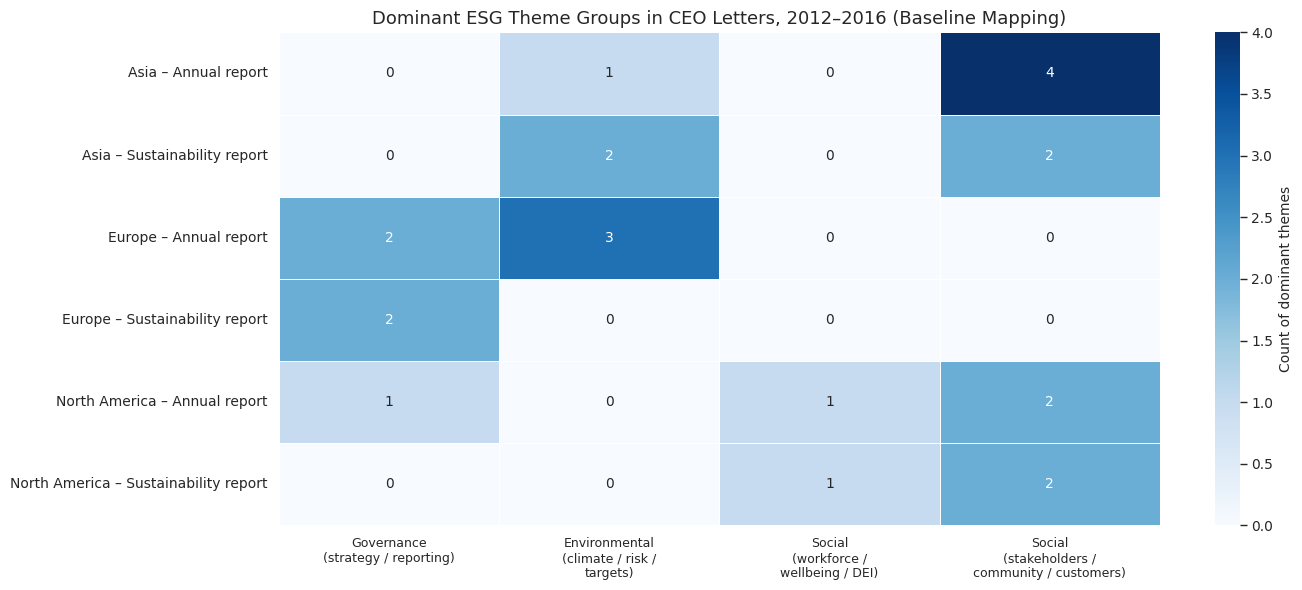

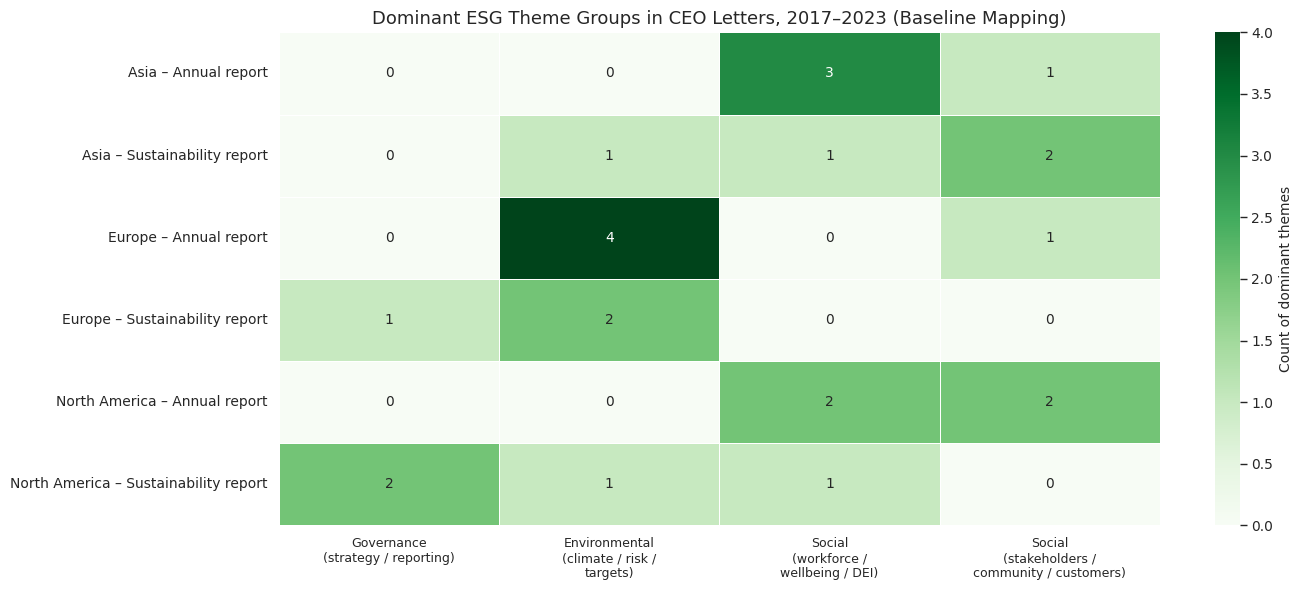

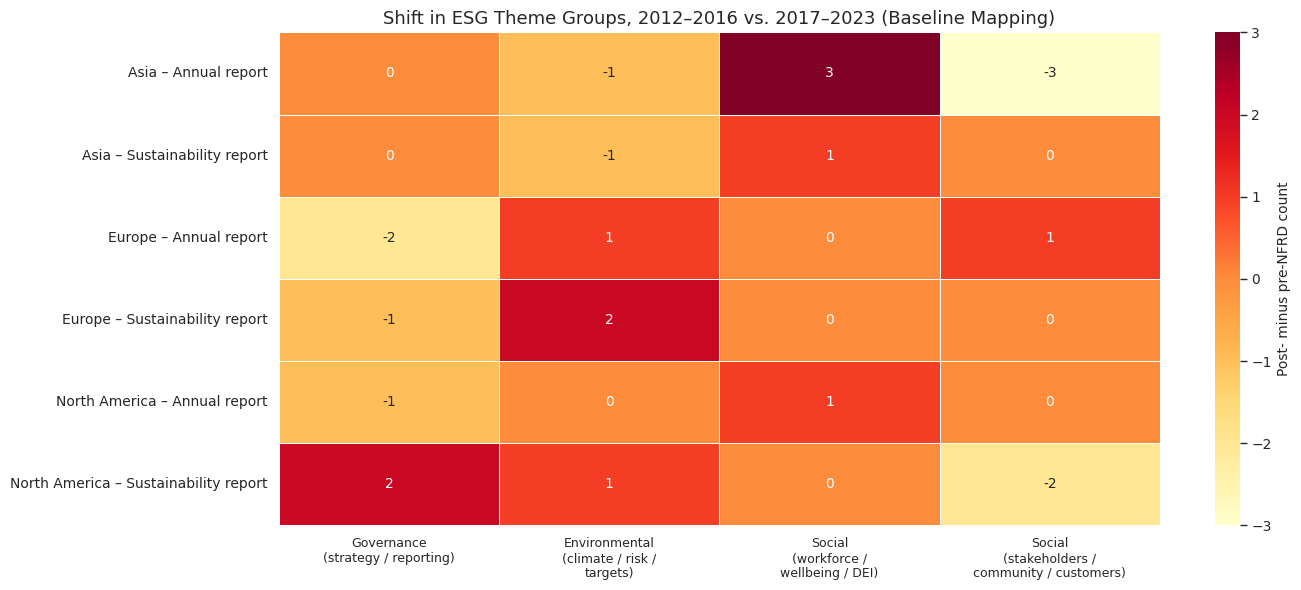

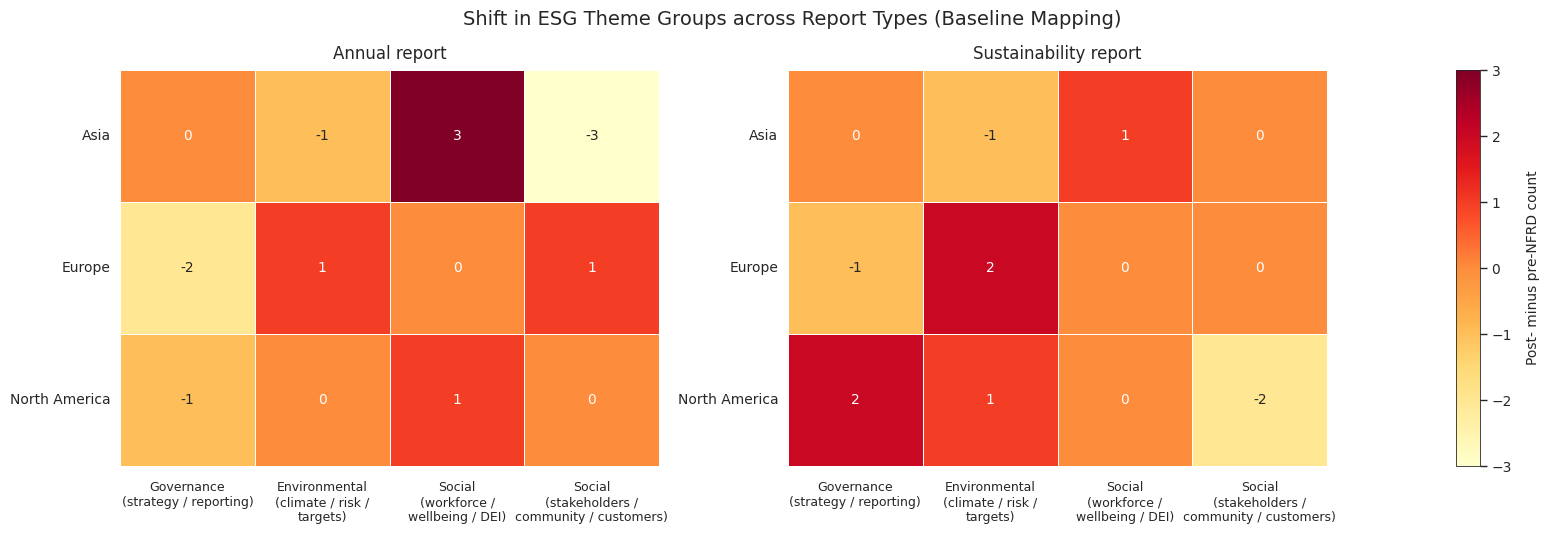


=== ROBUSTNESS: ambiguous topics excluded ===
              ReportType     Period  Number_of_topics
0          Annual report  2012-2016                 4
1          Annual report  2017-2023                 5
2  Sustainability report  2012-2016                 5
3  Sustainability report  2017-2023                 7
Total topics: 21
Ambiguous topics removed: 13


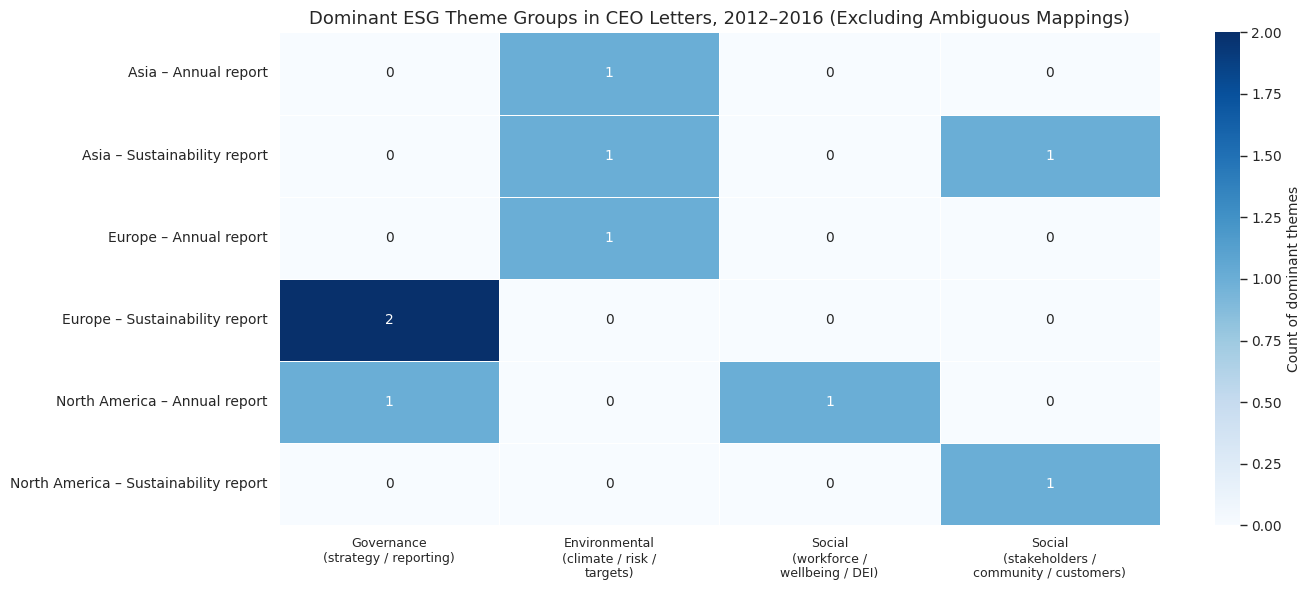

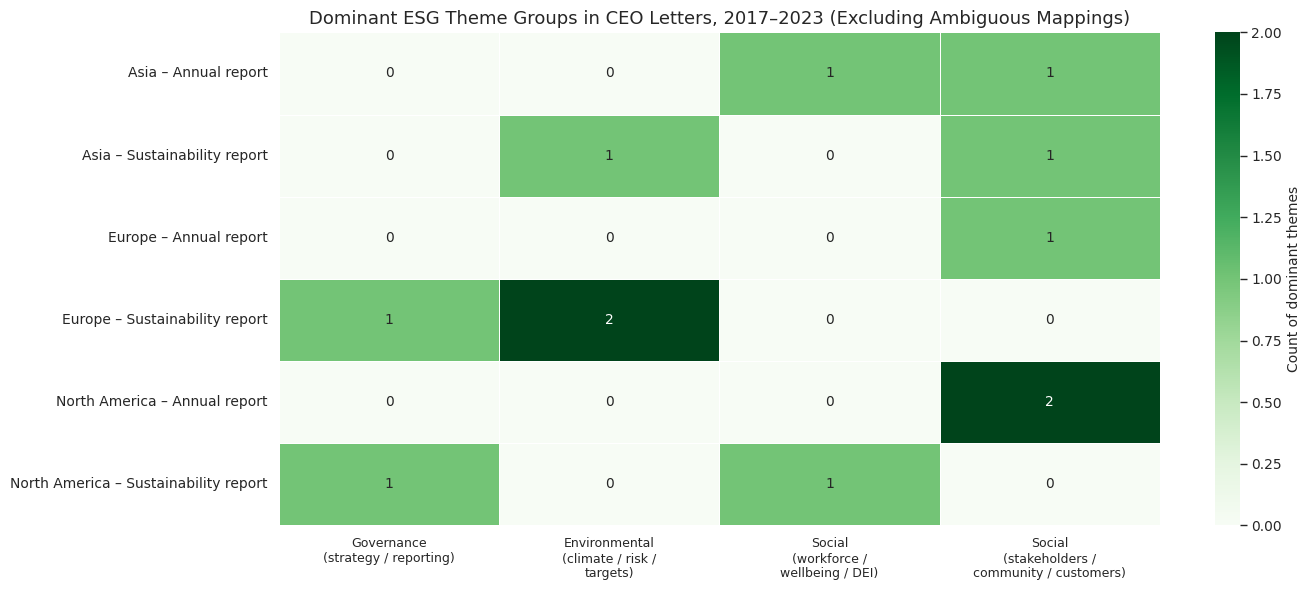

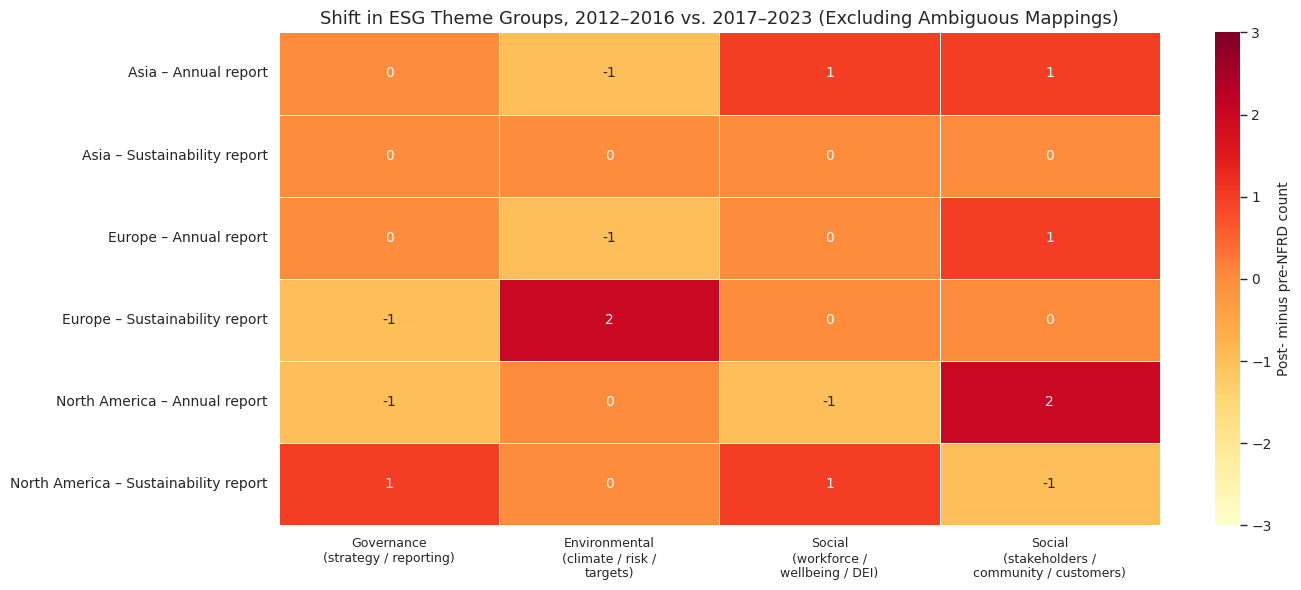

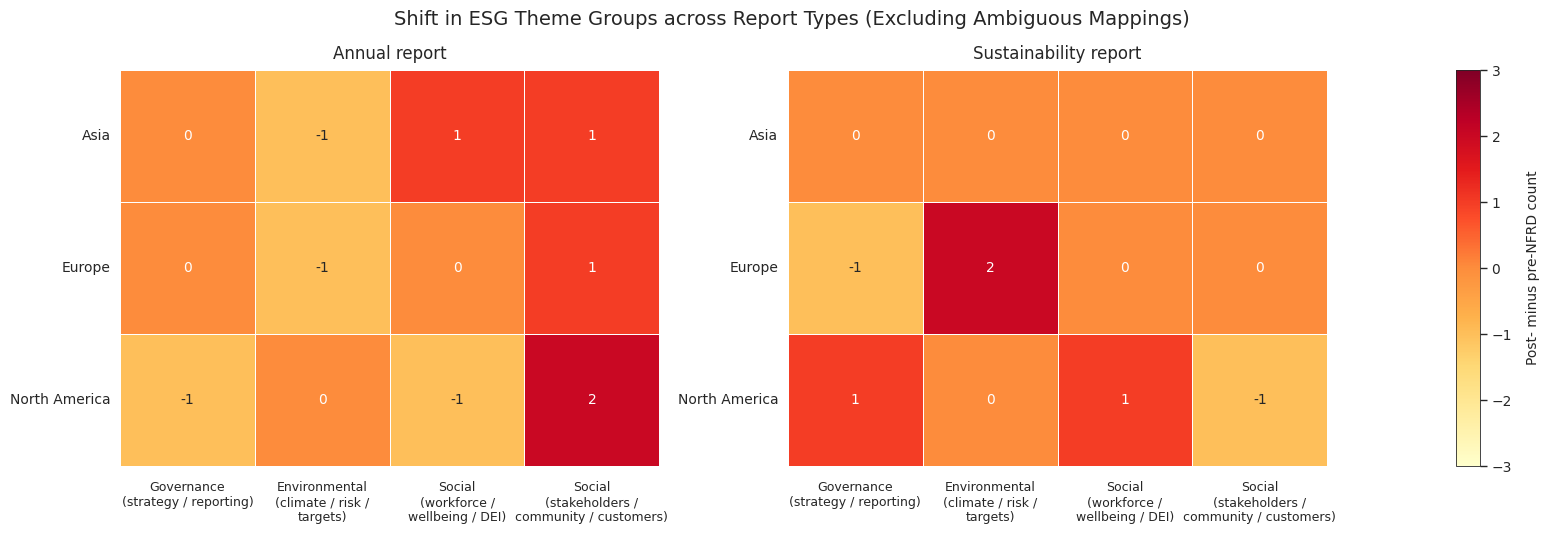


=== Comparison: robustness minus baseline ===
Period         Region             ReportType  \
1                Asia          Annual report   
0                Asia          Annual report   
3                Asia          Annual report   
2                Asia          Annual report   
9              Europe          Annual report   
8              Europe          Annual report   
11             Europe          Annual report   
10             Europe          Annual report   
17      North America          Annual report   
16      North America          Annual report   
19      North America          Annual report   
18      North America          Annual report   
5                Asia  Sustainability report   
4                Asia  Sustainability report   
7                Asia  Sustainability report   
6                Asia  Sustainability report   
13             Europe  Sustainability report   
12             Europe  Sustainability report   
15             Europe  Sustainability rep

In [ ]:
# ============================================================
# Create a heatmap using E/S/G-based grouped GRI categories
# Add the robustness check that excludes ambiguous topics
# Keep the same color coding as the baseline for direct comparison
# Run this cell in Google Colab
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# ------------------------------------------------------------
# 1. enter my topics with GRI mappings from Tables 2 and 3
# Each row represents one topic
# ------------------------------------------------------------
topics = [
    # =========================
    # TABLE 2: ANNUAL REPORTS
    # =========================

    ["Asia", "Annual report", "2012-2016",
     "insurance, security, support, services, health, products, insurance business, life, including",
     ["GRI 416", "GRI 413"]],
    ["Asia", "Annual report", "2012-2016",
     "stakeholders, customers, value, people, continue, vision, action, mission, work, highest",
     ["GRI 413", "GRI 414"]],
    ["Asia", "Annual report", "2012-2016",
     "risk, increase, region, japan, fiscal, global, measures, model, overseas, billion",
     ["GRI 201-2"]],

    ["Asia", "Annual report", "2017-2023",
     "insurance, services, support, people, new, providing, company, health, management, life",
     ["GRI 416"]],
    ["Asia", "Annual report", "2017-2023",
     "challenges, wellbeing, health, employees, create, corporate, new, culture, management, make",
     ["GRI 403", "GRI 401"]],
    ["Asia", "Annual report", "2017-2023",
     "diversity, diverse, groups, human, promoting, important, believe, culture, values, realize",
     ["GRI 405"]],

    ["Europe", "Annual report", "2012-2016",
     "corporate, new, responsibility, group, value, culture, people, work, management, commitment",
     ["GRI 2", "GRI 3"]],
    ["Europe", "Annual report", "2012-2016",
     "country, interests, lead, opportunity, security, challenges, economic, people, global, open",
     ["GRI 201-2"]],
    ["Europe", "Annual report", "2012-2016",
     "losses, natural, disasters, natural disasters, catastrophe, major, sandy, million, storm, year",
     ["GRI 201-2", "GRI 305"]],

    ["Europe", "Annual report", "2017-2023",
     "economic, group, society, including, social, global, time, support, businesses, year",
     ["GRI 413"]],
    ["Europe", "Annual report", "2017-2023",
     "natural, year, climate change, years, change, climate, risk, impact, insurance, time",
     ["GRI 305", "GRI 201-2"]],
    ["Europe", "Annual report", "2017-2023",
     "support, insurance, world, help, new, protection, climate, risk, environment, businesses",
     ["GRI 305", "GRI 306"]],

    ["North America", "Annual report", "2012-2016",
     "culture, years, diversity, best, companies, success, efforts, important, competitive, recognition",
     ["GRI 405"]],
    ["North America", "Annual report", "2012-2016",
     "value, stakeholders, company, customers, make, integrity, organization, commitment, core, aspect",
     ["GRI 413", "GRI 414"]],
    ["North America", "Annual report", "2012-2016",
     "sustainable, prudential, sustainability, invest, responsible, assets, companies, long term, number, structure",
     ["GRI 2"]],

    ["North America", "Annual report", "2017-2023",
     "change, long, years, year, impact, new, create, results, equity, customers",
     ["GRI 413"]],
    ["North America", "Annual report", "2017-2023",
     "diversity, equity, efforts, environment, growth, improve, leadership, work, business, employee",
     ["GRI 401", "GRI 405"]],
    ["North America", "Annual report", "2017-2023",
     "companies, best, purpose, team, communities, success, diversity, shareholders, provide, people",
     ["GRI 413"]],

    # ================================
    # TABLE 3: SUSTAINABILITY REPORTS
    # ================================

    ["Asia", "Sustainability report", "2012-2016",
     "society, sustainable, issues, social, social issues, value, group, development, initiatives, stakeholders",
     ["GRI 413"]],
    ["Asia", "Sustainability report", "2012-2016",
     "group, mangrove, environmental, planting, activities, mangrove planting, project, support, csr, society",
     ["GRI 304", "GRI 413"]],
    ["Asia", "Sustainability report", "2012-2016",
     "disaster, disasters, risk, natural, research, earthquake, natural disasters, east japan, great east, japan earthquake",
     ["GRI 201-2"]],

    ["Asia", "Sustainability report", "2017-2023",
     "social, social issues, society, issues, value, sustainable, people, stakeholders, employees, company",
     ["GRI 401", "GRI 413"]],
    ["Asia", "Sustainability report", "2017-2023",
     "insurance, health, people, healthy, business, care, social, insurance business, peoples, services",
     ["GRI 416"]],
    ["Asia", "Sustainability report", "2017-2023",
     "disasters, natural, natural disasters, risks, disaster, damage, climate, change, major, risk",
     ["GRI 305"]],

    ["Europe", "Sustainability report", "2012-2016",
     "sustainability, business, corporate, report, responsibility, climate, social, society, sustainable, company",
     ["GRI 2"]],
    ["Europe", "Sustainability report", "2012-2016",
     "principles, psi, compact, global compact, global, sustainable insurance, principles sustainable, insurance psi, sustainable, united nations",
     ["GRI 2"]],

    ["Europe", "Sustainability report", "2017-2023",
     "sustainability, strategy, social, sustainable, report, society, sustainability strategy, employees, group, future",
     ["GRI 3"]],
    ["Europe", "Sustainability report", "2017-2023",
     "climate, climate change, change, natural, risks, risk, paris, global, agreement, disasters",
     ["GRI 305"]],
    ["Europe", "Sustainability report", "2017-2023",
     "carbon, emissions, 2019, reduction, compared, reduce, 2025, intensity, compared 2019, carbon intensity",
     ["GRI 305"]],

    ["North America", "Sustainability report", "2012-2016",
     "corporate, business, people, responsibility, good, communities, commitment, employees, million, corporate responsibility",
     ["GRI 401", "GRI 413"]],
    ["North America", "Sustainability report", "2012-2016",
     "violence, domestic, domestic violence, approaches, reducing, helping victims, driving fatalities, fatalities, teen driving, taken",
     ["GRI 413"]],

    ["North America", "Sustainability report", "2017-2023",
     "people, help, great, employees, dei, diversity, equity, work, customers, health",
     ["GRI 405"]],
    ["North America", "Sustainability report", "2017-2023",
     "esg, change, sustainability, climate change, climate, global, esg report, report, data, esg data",
     ["GRI 2", "GRI 305"]],
    ["North America", "Sustainability report", "2017-2023",
     "cdp, financial, data, index, ftse4good, year, reporting, environmental data, code conduct, tcfd",
     ["GRI 2"]],
]

df = pd.DataFrame(topics, columns=["Region", "ReportType", "Period", "Keywords", "GRI_List"])

# Flag ambiguous mappings
df["Ambiguous"] = df["GRI_List"].apply(lambda x: len(x) > 1)

# ------------------------------------------------------------
# 2. Use the SAME labels everywhere
# ------------------------------------------------------------
gri_groups = [
    "Governance\n(strategy / reporting)",
    "Environmental\n(climate / risk /\ntargets)",
    "Social\n(workforce /\nwellbeing / DEI)",
    "Social\n(stakeholders /\ncommunity / customers)"
]

gri_group_map = {
    "GRI 2": "Governance\n(strategy / reporting)",
    "GRI 3": "Governance\n(strategy / reporting)",

    "GRI 201-2": "Environmental\n(climate / risk /\ntargets)",
    "GRI 304": "Environmental\n(climate / risk /\ntargets)",
    "GRI 305": "Environmental\n(climate / risk /\ntargets)",
    "GRI 306": "Environmental\n(climate / risk /\ntargets)",

    "GRI 401": "Social\n(workforce /\nwellbeing / DEI)",
    "GRI 403": "Social\n(workforce /\nwellbeing / DEI)",
    "GRI 405": "Social\n(workforce /\nwellbeing / DEI)",

    "GRI 413": "Social\n(stakeholders /\ncommunity / customers)",
    "GRI 414": "Social\n(stakeholders /\ncommunity / customers)",
    "GRI 416": "Social\n(stakeholders /\ncommunity / customers)",
}

regions = ["Asia", "Europe", "North America"]
report_types = ["Annual report", "Sustainability report"]

# ------------------------------------------------------------
# 3. Helper function to build counts and heatmaps
# ------------------------------------------------------------
def build_pivot_counts(input_df):
    expanded_rows = []

    for _, row in input_df.iterrows():
        for gri_code in row["GRI_List"]:
            expanded_rows.append([
                row["Region"],
                row["ReportType"],
                row["Period"],
                row["Keywords"],
                gri_code,
                gri_group_map.get(gri_code, "Other")
            ])

    df_expanded = pd.DataFrame(
        expanded_rows,
        columns=["Region", "ReportType", "Period", "Keywords", "GRI_Code", "GRI_Group"]
    )

    counts = (
        df_expanded.groupby(["Region", "ReportType", "Period", "GRI_Group"])
        .size()
        .reset_index(name="Count")
    )

    pivot_counts = (
        counts.pivot_table(
            index=["Region", "ReportType", "GRI_Group"],
            columns="Period",
            values="Count",
            fill_value=0
        )
        .reset_index()
    )

    for col in ["2012-2016", "2017-2023"]:
        if col not in pivot_counts.columns:
            pivot_counts[col] = 0

    pivot_counts["Change"] = pivot_counts["2017-2023"] - pivot_counts["2012-2016"]

    full_index = pd.MultiIndex.from_product(
        [regions, report_types, gri_groups],
        names=["Region", "ReportType", "GRI_Group"]
    )

    pivot_counts = (
        pivot_counts.set_index(["Region", "ReportType", "GRI_Group"])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )

    pivot_counts["Row"] = pivot_counts["Region"] + " – " + pivot_counts["ReportType"]

    return pivot_counts


def plot_pre_heatmap(pivot_counts, title):
    pre_heatmap = pivot_counts.pivot(
        index="Row",
        columns="GRI_Group",
        values="2012-2016"
    )[gri_groups]

    plt.figure(figsize=(14, 6))
    sns.heatmap(
        pre_heatmap,
        annot=True,
        fmt="g",
        cmap="Blues",
        linewidths=0.5,
        cbar_kws={"label": "Count of dominant themes"}
    )
    plt.title(title, fontsize=13)
    plt.xlabel("")
    plt.ylabel("")
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


def plot_post_heatmap(pivot_counts, title):
    post_heatmap = pivot_counts.pivot(
        index="Row",
        columns="GRI_Group",
        values="2017-2023"
    )[gri_groups]

    plt.figure(figsize=(14, 6))
    sns.heatmap(
        post_heatmap,
        annot=True,
        fmt="g",
        cmap="Greens",
        linewidths=0.5,
        cbar_kws={"label": "Count of dominant themes"}
    )
    plt.title(title, fontsize=13)
    plt.xlabel("")
    plt.ylabel("")
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


def plot_change_heatmap(pivot_counts, title, vmin=None, vmax=None):
    change_heatmap = pivot_counts.pivot(
        index="Row",
        columns="GRI_Group",
        values="Change"
    )[gri_groups]

    plt.figure(figsize=(14, 6))
    sns.heatmap(
        change_heatmap,
        annot=True,
        fmt="g",
        cmap="YlOrRd",
        center=0 if (vmin is None or vmax is None) else None,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        cbar_kws={"label": "Post- minus pre-NFRD count"}
    )
    plt.title(title, fontsize=13)
    plt.xlabel("")
    plt.ylabel("")
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


def plot_two_panel_change_heatmap(pivot_counts, title, vmin, vmax, cmap_name="YlOrRd"):
    sns.set_theme(style="white", context="paper")
    plt.rcParams.update({
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 10,
        "figure.titlesize": 14,
    })

    pretty_labels = [
        "Governance\n(strategy / reporting)",
        "Environmental\n(climate / risk /\ntargets)",
        "Social\n(workforce /\nwellbeing / DEI)",
        "Social\n(stakeholders /\ncommunity / customers)"
    ]

    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)

    fig = plt.figure(figsize=(16, 6))
    gs = fig.add_gridspec(
        nrows=1,
        ncols=3,
        width_ratios=[1, 1, 0.045],
        wspace=0.35
    )

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    cax = fig.add_subplot(gs[0, 2])

    axes = [ax1, ax2]

    for ax, report_type in zip(axes, report_types):
        temp = pivot_counts[pivot_counts["ReportType"] == report_type].copy()
        hm = temp.pivot(index="Region", columns="GRI_Group", values="Change")[gri_groups]

        sns.heatmap(
            hm,
            annot=True,
            fmt="g",
            cmap=cmap,
            norm=norm,
            linewidths=0.6,
            linecolor="white",
            cbar=False,
            square=False,
            ax=ax
        )

        ax.set_title(report_type, pad=8)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(pretty_labels, rotation=0, ha="center")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

        ax.tick_params(axis="x", pad=6)
        ax.tick_params(axis="y", pad=2)
        for spine in ax.spines.values():
            spine.set_visible(False)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Post- minus pre-NFRD count", rotation=90, labelpad=10)
    cbar.outline.set_linewidth(0.6)

    fig.suptitle(title, y=0.98)
    fig.subplots_adjust(bottom=0.22, top=0.88, left=0.08, right=0.93)

    plt.show()


def print_summary(input_df, label):
    summary = (
        input_df.groupby(["ReportType", "Period"])
        .size()
        .reset_index(name="Number_of_topics")
    )
    print(f"\n=== {label} ===")
    print(summary)
    print(f"Total topics: {len(input_df)}")
    print(f"Ambiguous topics removed: {df['Ambiguous'].sum() - input_df['Ambiguous'].sum()}")


# ------------------------------------------------------------
# 4. BASELINE analysis (all mappings included)
# ------------------------------------------------------------
df_baseline = df.copy()
pivot_counts_baseline = build_pivot_counts(df_baseline)

print_summary(df_baseline, "BASELINE: all topics included")

plot_pre_heatmap(
    pivot_counts_baseline,
    "Dominant ESG Theme Groups in CEO Letters, 2012–2016 (Baseline Mapping)"
)

plot_post_heatmap(
    pivot_counts_baseline,
    "Dominant ESG Theme Groups in CEO Letters, 2017–2023 (Baseline Mapping)"
)

# Fix one shared color scale from baseline and reuse it
baseline_vmin = pivot_counts_baseline["Change"].min()
baseline_vmax = pivot_counts_baseline["Change"].max()

plot_change_heatmap(
    pivot_counts_baseline,
    "Shift in ESG Theme Groups, 2012–2016 vs. 2017–2023 (Baseline Mapping)",
    vmin=baseline_vmin,
    vmax=baseline_vmax
)

plot_two_panel_change_heatmap(
    pivot_counts_baseline,
    "Shift in ESG Theme Groups across Report Types (Baseline Mapping)",
    vmin=baseline_vmin,
    vmax=baseline_vmax,
    cmap_name="YlOrRd"
)

# ------------------------------------------------------------
# 5. ROBUSTNESS analysis (exclude ambiguous mappings)
# ------------------------------------------------------------
df_robust = df[~df["Ambiguous"]].copy()
pivot_counts_robust = build_pivot_counts(df_robust)

print_summary(df_robust, "ROBUSTNESS: ambiguous topics excluded")

plot_pre_heatmap(
    pivot_counts_robust,
    "Dominant ESG Theme Groups in CEO Letters, 2012–2016 (Excluding Ambiguous Mappings)"
)

plot_post_heatmap(
    pivot_counts_robust,
    "Dominant ESG Theme Groups in CEO Letters, 2017–2023 (Excluding Ambiguous Mappings)"
)

# Use the SAME baseline color scale here
plot_change_heatmap(
    pivot_counts_robust,
    "Shift in ESG Theme Groups, 2012–2016 vs. 2017–2023 (Excluding Ambiguous Mappings)",
    vmin=baseline_vmin,
    vmax=baseline_vmax
)

plot_two_panel_change_heatmap(
    pivot_counts_robust,
    "Shift in ESG Theme Groups across Report Types (Excluding Ambiguous Mappings)",
    vmin=baseline_vmin,
    vmax=baseline_vmax,
    cmap_name="YlOrRd"
)

# ------------------------------------------------------------
# 6. Optional: compare baseline vs robustness numerically
# ------------------------------------------------------------
comparison = pivot_counts_baseline.merge(
    pivot_counts_robust,
    on=["Region", "ReportType", "GRI_Group", "Row"],
    how="left",
    suffixes=("_baseline", "_robust")
).fillna(0)

comparison["Diff_2012_2016"] = comparison["2012-2016_robust"] - comparison["2012-2016_baseline"]
comparison["Diff_2017_2023"] = comparison["2017-2023_robust"] - comparison["2017-2023_baseline"]
comparison["Diff_Change"] = comparison["Change_robust"] - comparison["Change_baseline"]

print("\n=== Comparison: robustness minus baseline ===")
print(
    comparison[[
        "Region", "ReportType", "GRI_Group",
        "2012-2016_baseline", "2012-2016_robust", "Diff_2012_2016",
        "2017-2023_baseline", "2017-2023_robust", "Diff_2017_2023",
        "Change_baseline", "Change_robust", "Diff_Change"
    ]].sort_values(["ReportType", "Region", "GRI_Group"])
)

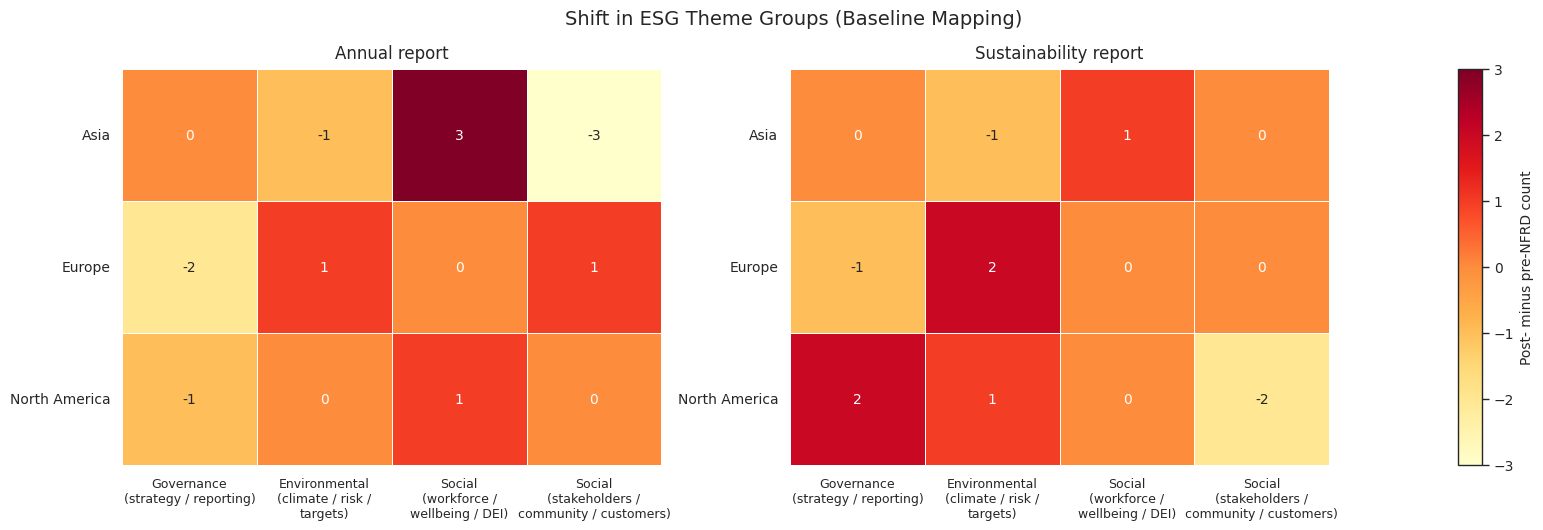

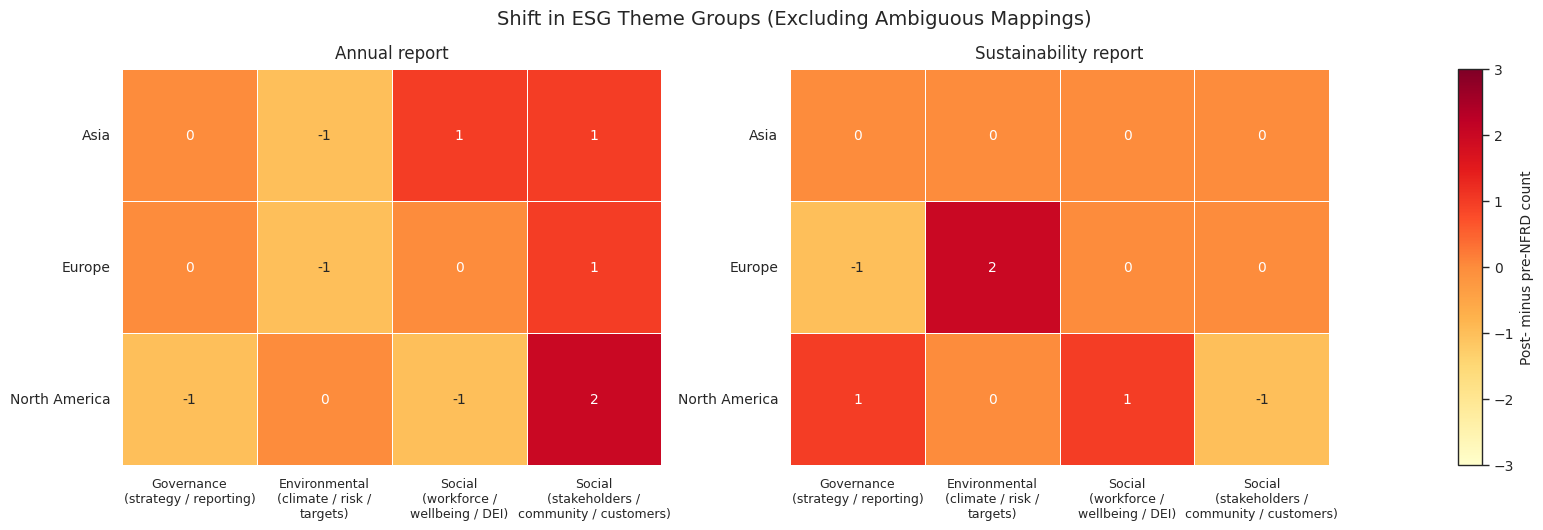

In [ ]:
# ------------------------------------------------------------
# Use a shared color scale from the baseline
# ------------------------------------------------------------
baseline_vmin = pivot_counts_baseline["Change"].min()
baseline_vmax = pivot_counts_baseline["Change"].max()

# ------------------------------------------------------------
# Use the same plot function as before
# ------------------------------------------------------------
def plot_two_panel_change_heatmap(pivot_counts, title, vmin, vmax, cmap_name="YlOrRd"):
    sns.set_theme(style="white", context="paper")
    plt.rcParams.update({
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 10,
        "figure.titlesize": 14,
    })

    pretty_labels = [
        "Governance\n(strategy / reporting)",
        "Environmental\n(climate / risk /\ntargets)",
        "Social\n(workforce /\nwellbeing / DEI)",
        "Social\n(stakeholders /\ncommunity / customers)"
    ]

    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)

    fig = plt.figure(figsize=(16, 6))
    gs = fig.add_gridspec(
        nrows=1,
        ncols=3,
        width_ratios=[1, 1, 0.045],
        wspace=0.35
    )

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    cax = fig.add_subplot(gs[0, 2])

    axes = [ax1, ax2]

    for ax, report_type in zip(axes, report_types):
        temp = pivot_counts[pivot_counts["ReportType"] == report_type].copy()
        hm = temp.pivot(index="Region", columns="GRI_Group", values="Change")[gri_groups]

        sns.heatmap(
            hm,
            annot=True,
            fmt="g",
            cmap=cmap,
            norm=norm,
            linewidths=0.6,
            linecolor="white",
            cbar=False,
            ax=ax
        )

        ax.set_title(report_type, pad=8)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(pretty_labels, rotation=0)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

        for spine in ax.spines.values():
            spine.set_visible(False)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Post- minus pre-NFRD count", rotation=90)

    fig.suptitle(title, y=0.98)
    fig.subplots_adjust(bottom=0.22, top=0.88, left=0.08, right=0.93)

    plt.show()

# ------------------------------------------------------------
# Generate the final output with only two figures
# ------------------------------------------------------------
# Baseline
plot_two_panel_change_heatmap(
    pivot_counts_baseline,
    "Shift in ESG Theme Groups (Baseline Mapping)",
    vmin=baseline_vmin,
    vmax=baseline_vmax
)

# Robustness (excluding ambiguous)
plot_two_panel_change_heatmap(
    pivot_counts_robust,
    "Shift in ESG Theme Groups (Excluding Ambiguous Mappings)",
    vmin=baseline_vmin,
    vmax=baseline_vmax
)

## 6.8 Run the Business-Type Topic Analysis


In [ ]:
# # Extra Topic Analysis (Business groups + ALIAS mapping)
# # Q1: which issues/themes are most discussed (by Business group)
# # Q2: does it change over time? -> compare 2012–2016 vs 2017–2023 (by Business group)

import pandas as pd
import numpy as np

file_path = '/content/drive/MyDrive/phd/Data/df_ar_ceo_sentences_esgbert_scored.csv'
df = pd.read_csv(file_path)

# ------------------------------------------------------------
# 0) Install and import the required packages
# ------------------------------------------------------------
!pip -q install bertopic sentence-transformers umap-learn hdbscan

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text

# ------------------------------------------------------------
# 1) Define my master company list and business classification
# ------------------------------------------------------------
companies = pd.DataFrame({
    "Company_master": [
        "People's Insurance Co. of China",
        "MS&AD Insurance Group Holdings",
        "Ping An Insurance",
        "Dai-ichi Life Holdings",
        "Sompo Holdings",
        "China Life Insurance",
        "Tokio Marine Holdings",
        "Zurich Insurance Group",
        "Swiss Re",
        "Chubb",
        "Allianz",
        "Munich Re Group",
        "Assicurazioni Generali",
        "Talanx",
        "AXA",
        "Power Corp. of Canada",
        "Prudential Financial (U.S.)",
        "American International Group",
        "Allstate",
        "Progressive",
        "Travelers Cos.",
        "MetLife"
    ],
    "Business": [
        "Mixed","P&C","Mixed","L&H","P&C","L&H","Mixed","Mixed","Reinsurance","P&C",
        "Mixed","Reinsurance","Mixed","Mixed","Mixed","L&H","L&H","Mixed","Mixed","Mixed","P&C","L&H"
    ]
})

# ------------------------------------------------------------
# 2) Identify firm column in df and apply ALIAS mapping (no fuzzy)
# ------------------------------------------------------------
firm_col_candidates = ["Company", "Company Name", "Company_Name", "Insurer", "Firm"]
firm_col = next((c for c in firm_col_candidates if c in df.columns), None)
if firm_col is None:
    raise ValueError(f"Could not find firm column. Available columns: {df.columns.tolist()}")

df = df.rename(columns={firm_col: "Company_raw"}).copy()

alias_to_master = {
    "AIG": "American International Group",
    "AXA": "AXA",
    "Allianz": "Allianz",
    "Allstate": "Allstate",
    "China Life": "China Life Insurance",
    "Chubb": "Chubb",
    "Daichi": "Dai-ichi Life Holdings",
    "Generali": "Assicurazioni Generali",
    "MET": "MetLife",
    "MSAD": "MS&AD Insurance Group Holdings",
    "Munich RE": "Munich Re Group",
    "PIC": "People's Insurance Co. of China",
    "Ping An": "Ping An Insurance",
    "Power Corp Canada": "Power Corp. of Canada",
    "Progressive": "Progressive",
    "Prudential Financials": "Prudential Financial (U.S.)",
    "Sompo": "Sompo Holdings",
    "Swiss RE": "Swiss Re",
    "Talanx": "Talanx",
    "Tokio Marine": "Tokio Marine Holdings",
    "Travelers": "Travelers Cos.",
    "Zurich": "Zurich Insurance Group"
}

# Deterministic harmonization
df["Company_master"] = df["Company_raw"].replace(alias_to_master)

# Attach Business based on the harmonized key
df = df.merge(companies[["Company_master", "Business"]], on="Company_master", how="left")

print("Business coverage:", df["Business"].notna().mean())

# Inspect unmapped companies (should be empty or only unexpected names)
unmapped = df.loc[df["Business"].isna(), "Company_raw"].dropna().unique()
print("\nUnmapped Company_raw (need alias or add to master list):")
print(sorted(unmapped))

# ------------------------------------------------------------
# 3) Create grouped business variable (3 groups)
# ------------------------------------------------------------
df["business_group"] = df["Business"].map({
    "L&H": "L&H",
    "P&C": "P&C",
    "Mixed": "Mixed/Reinsurance",
    "Reinsurance": "Mixed/Reinsurance"
})
df = df.dropna(subset=["business_group"]).copy()

# ------------------------------------------------------------
# 4) Define stopwords + adaptive vectorizer
# ------------------------------------------------------------
stop_words = set(text.ENGLISH_STOP_WORDS)

def make_vectorizer(n_docs, stop_words):
    min_df = max(2, int(0.01 * n_docs))     # at least 2 docs or 1%
    max_df = 0.8 if n_docs > 300 else 0.9   # relax max_df for small samples
    return CountVectorizer(
        stop_words=list(stop_words),
        ngram_range=(1, 2),
        min_df=min_df,
        max_df=max_df
    )

# ------------------------------------------------------------
# 5) Filter to ESG sentences
# ------------------------------------------------------------
df_esg = df[(df['env_flag'].eq(1)) | (df['soc_flag'].eq(1)) | (df['gov_flag'].eq(1))].copy()

df_esg["Sentence"] = (
    df_esg["Sentence"].astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
df_esg = df_esg[df_esg["Sentence"].str.len() >= 20].copy()

# ------------------------------------------------------------
# 6) Create time windows
# ------------------------------------------------------------
df_esg["Year"] = pd.to_numeric(df_esg["Year"], errors="coerce")

df_esg["period"] = pd.Series(pd.NA, index=df_esg.index, dtype="string")
df_esg.loc[df_esg["Year"].between(2012, 2016), "period"] = "2012-2016"
df_esg.loc[df_esg["Year"].between(2017, 2023), "period"] = "2017-2023"
df_esg = df_esg.dropna(subset=["period"]).copy()

# ------------------------------------------------------------
# 7) Fit BERTopic per (business_group, period)
# ------------------------------------------------------------
def show_topic_examples(df_subset, topic_model, topics, topic_id, n=5):
    idx = np.where(np.array(topics) == topic_id)[0]
    examples = df_subset.iloc[idx]["Sentence"].head(n).tolist()
    words = topic_model.get_topic(topic_id)
    top_terms = [w for w, _ in (words or [])[:12]]
    return top_terms, examples

results = {}

groups = ["L&H", "P&C", "Mixed/Reinsurance"]
periods = ["2012-2016", "2017-2023"]

MIN_DOCS = 250  # lower (e.g., 150) if some group-period cells are small

for g in groups:
    for p in periods:
        df_gp = df_esg[(df_esg["business_group"].eq(g)) & (df_esg["period"].eq(p))].reset_index(drop=True)
        docs = df_gp["Sentence"].tolist()

        if len(docs) < MIN_DOCS:
            print(f"\nSkip business_group={g}, period={p}: only {len(docs)} ESG sentences")
            continue

        vectorizer_model = make_vectorizer(len(docs), stop_words)

        topic_model = BERTopic(
            vectorizer_model=vectorizer_model,
            language="english",
            calculate_probabilities=False,
            verbose=False
        )

        topics, _ = topic_model.fit_transform(docs)
        info = topic_model.get_topic_info()

        results[(g, p)] = {"model": topic_model, "topics": topics, "info": info, "df": df_gp}

        print("\n=================================================")
        print(f"Business group: {g} | Period: {p} | N={len(docs)}")
        print(f"Topics found (excl. -1 outlier): {info.shape[0]-1}")

        top_topic_ids = info.loc[info["Topic"] != -1, "Topic"].head(5).tolist()

        for tid in top_topic_ids:
            size = int(info.loc[info["Topic"] == tid, "Count"].values[0])
            top_terms, ex = show_topic_examples(df_gp, topic_model, topics, tid, n=5)

            print(f"\nTopic {tid} | Size={size}")
            print("Top terms:", top_terms)
            print("Examples:")
            for s in ex:
                print("-", s[:220])

# ------------------------------------------------------------
# 8) OPTIONAL: quick “change over time” summary per business group
# ------------------------------------------------------------
print("\n\n==================== CHANGE OVER TIME SUMMARY (BUSINESS GROUP) ====================")
for g in groups:
    if (g, "2012-2016") not in results or (g, "2017-2023") not in results:
        continue

    info_old = results[(g, "2012-2016")]["info"]
    info_new = results[(g, "2017-2023")]["info"]

    tm_old = results[(g, "2012-2016")]["model"]
    tm_new = results[(g, "2017-2023")]["model"]

    top_old = info_old.loc[info_old["Topic"] != -1, "Topic"].head(3).tolist()
    top_new = info_new.loc[info_new["Topic"] != -1, "Topic"].head(3).tolist()

    print("\n-------------------------------------------------")
    print(f"Business group: {g}")

    print("2012–2016 top themes:")
    for tid in top_old:
        terms = [w for w, _ in (tm_old.get_topic(tid) or [])[:10]]
        print(f"  - Topic {tid}: {terms}")

    print("2017–2023 top themes:")
    for tid in top_new:
        terms = [w for w, _ in (tm_new.get_topic(tid) or [])[:10]]
        print(f"  - Topic {tid}: {terms}")

Business coverage: 1.0

Unmapped Company_raw (need alias or add to master list):
[]


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Business group: L&H | Period: 2012-2016 | N=306
Topics found (excl. -1 outlier): 4

Topic 0 | Size=233
Top terms: ['business', 'company', 'life', 'group', 'development', 'new', 'people', 'financial', 'continue', 'growth']
Examples:
- While fulfilling its obligations under insurance policies, the Company actively undertook its corporate social responsibility.
- Relying on its competitive advantages in professionalism and business scale, the Company continued to develop policy businesses including New Village Cooperative Medical Insurance, New Rural Pension Insurance, Basic Medi
- The Company actively participated in public welfare and charitable undertakings.
- During the Reporting Period, the Company continued to provide support for Wenchuan earthquake orphans, Yushu earthquake orphans, and Zhouqu mudslide orphans through the China Life Foundation, and organized the fourth ses
- The Company also donated to relevant foundations to provide women in impoverished areas with “Screening for

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Business group: L&H | Period: 2017-2023 | N=695
Topics found (excl. -1 outlier): 11

Topic 0 | Size=388
Top terms: ['customers', 'employees', 'society', 'communities', 'stakeholders', 'people', 'health', 'company', 'continue', 'support']
Examples:
- We worked hard to build a protection network for people’s well-being.
- Respecting market rules to ensure healthy business development and safeguard against various risks: We consciously acted in accordance with the highest international internal control standards, strictly complied with the
- This commitment aligns with our mission to protect lives and contribute to the community.
- The world flourishes and thrives as the spring breeze blows.
- We remained true to our original aspiration, assumed social responsibilities, and served the overall economic and social development.

Topic 1 | Size=36
Top terms: ['financial', 'businesses', 'needs', 'investment', 'opportunity', 'customers', 'individuals', 'insurance', 'management', 'global']
Exam

...


Business group: P&C | Period: 2017-2023 | N=1628
Topics found (excl. -1 outlier): 29

Topic 0 | Size=92
Top terms: ['world', 'time', 'people', 'need', 'global', 'growth', 'including', 'support', 'social', 'make']
Examples:
- The fundamental question is this: how does a market-oriented economy like the United States effectively engage with a party or state-directed economy such as China to create equal access and opportunity for American busi
- Legislation should be in keeping with our American social and cultural values — after all, the right of privacy and the protection of the individual are intrinsic to our democracy.
- Geopolitical conditions will remain volatile, fed by a number of powerful forces — rising nationalism and populism, inability of major democracies to effectively govern, trade tensions, Brexit, the U.S.–China relationshi
- Of late, I have added my voice to raise concern about the rise of populism.
- We are a growing source of instability and uncertainty for our alli

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Business group: Mixed/Reinsurance | Period: 2012-2016 | N=423
Topics found (excl. -1 outlier): 10

Topic 0 | Size=76
Top terms: ['value', 'company', 'responsibility', 'corporate', 'clients', 'customers', 'sustainable', 'people', 'business', 'growth']
Examples:
- Everywhere I turned, I found great people who were committed to serving their clients and to doing the right thing – but who were becoming increas- ingly demoralized as they witnessed their company being rapidly dismantl
- 2012 marks three years that we have adhered to comprehensive pay- for-performance processes and standards – ensuring that our people are properly motivated and appropriately rewarded for their efforts to balance profit, 
- The actions we took last year positioned us for an even stronger 2014, as we concentrate on four core priorities: • Intense focus on customers: We’ve invested a tremendous amount of time and effort into changing the comp
- We became a stronger, and more efficient and sustainable company, t

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Business group: Mixed/Reinsurance | Period: 2017-2023 | N=2005
Topics found (excl. -1 outlier): 39

Topic 0 | Size=115
Top terms: ['year', '2022', 'change', '2021', 'years', 'time', 'global', 'insurance', 'growth', 'future']
Examples:
- wars, fi nancial calamities, industry-changing Blackboard Insurance regulatory reform and natural disasters.
- Since 2012, there have been 12 CAT events with insured losses exceeding $10 billion and ten of those occurred between 2017 and 2021.i Total CAT losses were approximately $120 billion in 2021, which is the second highest 
- In North America, $17 billion of winter weather losses was the largest on record for this peril.
- And, $13 billion of insured losses for European flooding was the costliest disaster on record for the continent.iv
- Hurricane lan was a tragic event on a human level that also left devastating physical damage.

Topic 1 | Size=88
Top terms: ['customers', 'society', 'time', 'employees', 'purpose', 'people', 'focus', 'support', '

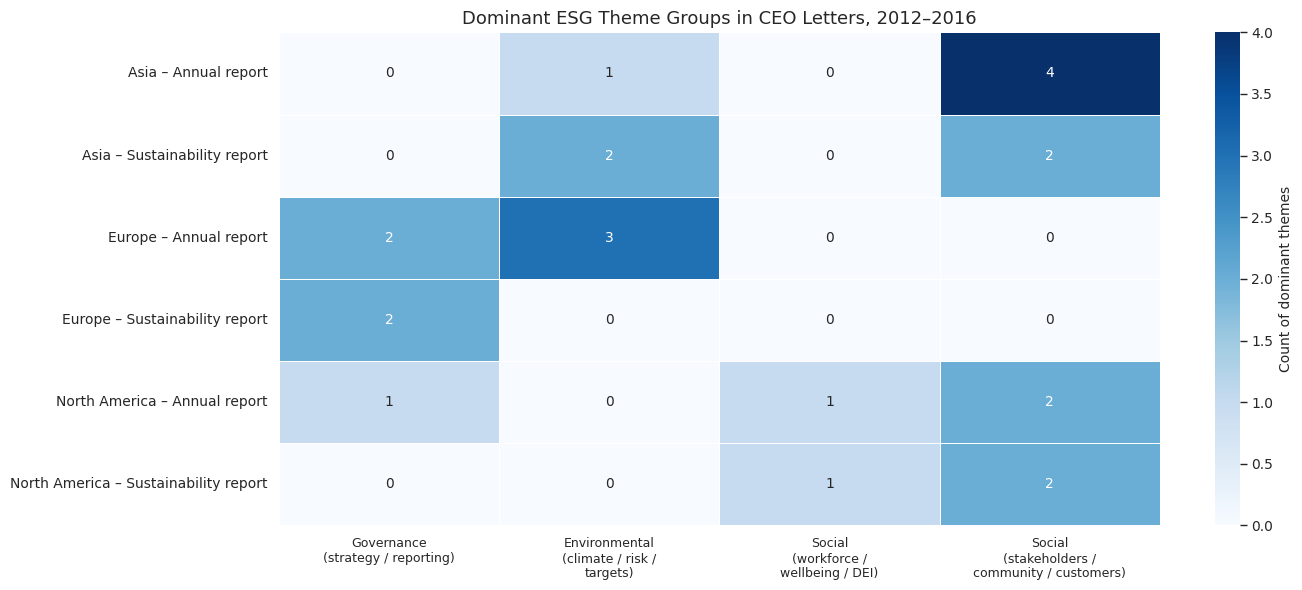

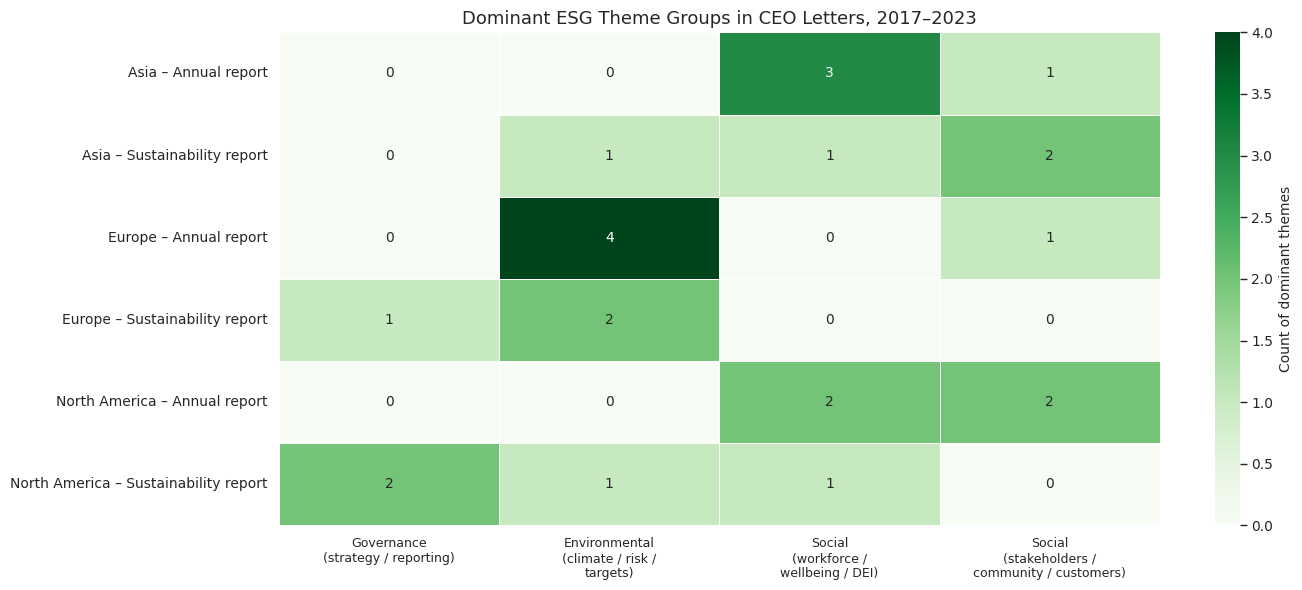

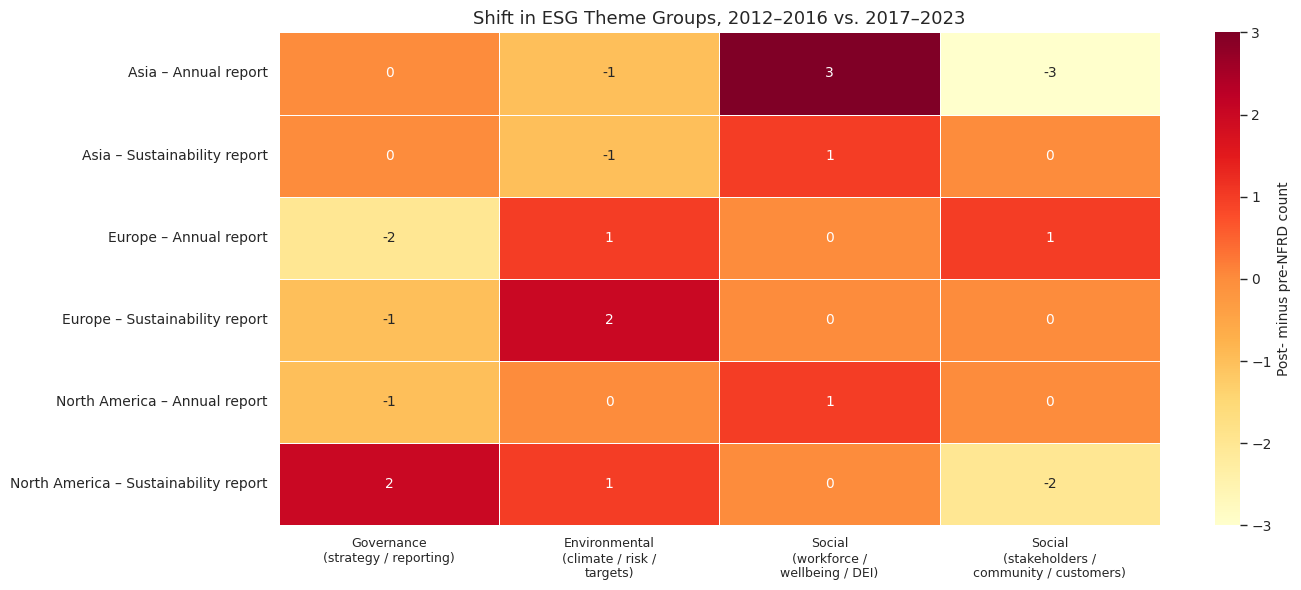

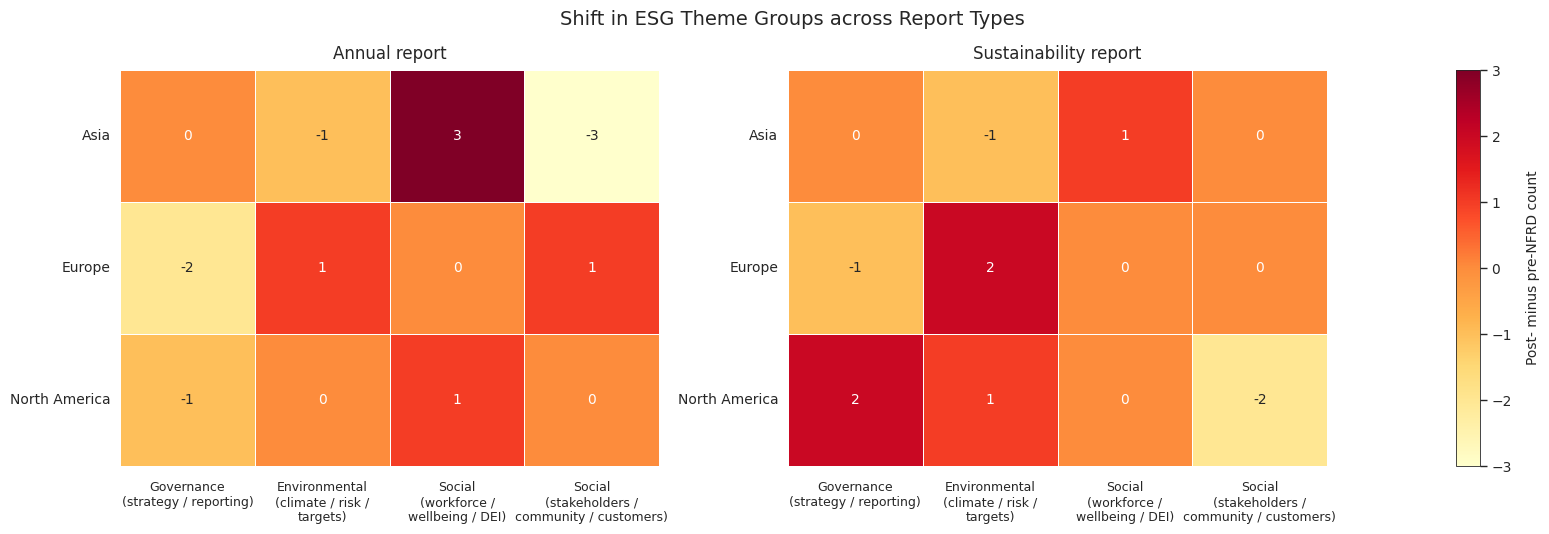

In [ ]:
# ============================================================
# Create a heatmap using E/S/G-based grouped GRI categories
# Use the updated version with cleaner wrapped labels
# Run this cell in Google Colab
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. enter my topics with GRI mappings from Tables 2 and 3
# Each row represents one topic
# ------------------------------------------------------------
topics = [
    # =========================
    # TABLE 2: ANNUAL REPORTS
    # =========================

    ["Asia", "Annual report", "2012-2016",
     "insurance, security, support, services, health, products, insurance business, life, including",
     ["GRI 416", "GRI 413"]],
    ["Asia", "Annual report", "2012-2016",
     "stakeholders, customers, value, people, continue, vision, action, mission, work, highest",
     ["GRI 413", "GRI 414"]],
    ["Asia", "Annual report", "2012-2016",
     "risk, increase, region, japan, fiscal, global, measures, model, overseas, billion",
     ["GRI 201-2"]],

    ["Asia", "Annual report", "2017-2023",
     "insurance, services, support, people, new, providing, company, health, management, life",
     ["GRI 416"]],
    ["Asia", "Annual report", "2017-2023",
     "challenges, wellbeing, health, employees, create, corporate, new, culture, management, make",
     ["GRI 403", "GRI 401"]],
    ["Asia", "Annual report", "2017-2023",
     "diversity, diverse, groups, human, promoting, important, believe, culture, values, realize",
     ["GRI 405"]],

    ["Europe", "Annual report", "2012-2016",
     "corporate, new, responsibility, group, value, culture, people, work, management, commitment",
     ["GRI 2", "GRI 3"]],
    ["Europe", "Annual report", "2012-2016",
     "country, interests, lead, opportunity, security, challenges, economic, people, global, open",
     ["GRI 201-2"]],
    ["Europe", "Annual report", "2012-2016",
     "losses, natural, disasters, natural disasters, catastrophe, major, sandy, million, storm, year",
     ["GRI 201-2", "GRI 305"]],

    ["Europe", "Annual report", "2017-2023",
     "economic, group, society, including, social, global, time, support, businesses, year",
     ["GRI 413"]],
    ["Europe", "Annual report", "2017-2023",
     "natural, year, climate change, years, change, climate, risk, impact, insurance, time",
     ["GRI 305", "GRI 201-2"]],
    ["Europe", "Annual report", "2017-2023",
     "support, insurance, world, help, new, protection, climate, risk, environment, businesses",
     ["GRI 305", "GRI 306"]],

    ["North America", "Annual report", "2012-2016",
     "culture, years, diversity, best, companies, success, efforts, important, competitive, recognition",
     ["GRI 405"]],
    ["North America", "Annual report", "2012-2016",
     "value, stakeholders, company, customers, make, integrity, organization, commitment, core, aspect",
     ["GRI 413", "GRI 414"]],
    ["North America", "Annual report", "2012-2016",
     "sustainable, prudential, sustainability, invest, responsible, assets, companies, long term, number, structure",
     ["GRI 2"]],

    ["North America", "Annual report", "2017-2023",
     "change, long, years, year, impact, new, create, results, equity, customers",
     ["GRI 413"]],
    ["North America", "Annual report", "2017-2023",
     "diversity, equity, efforts, environment, growth, improve, leadership, work, business, employee",
     ["GRI 401", "GRI 405"]],
    ["North America", "Annual report", "2017-2023",
     "companies, best, purpose, team, communities, success, diversity, shareholders, provide, people",
     ["GRI 413"]],

    # ================================
    # TABLE 3: SUSTAINABILITY REPORTS
    # ================================

    ["Asia", "Sustainability report", "2012-2016",
     "society, sustainable, issues, social, social issues, value, group, development, initiatives, stakeholders",
     ["GRI 413"]],
    ["Asia", "Sustainability report", "2012-2016",
     "group, mangrove, environmental, planting, activities, mangrove planting, project, support, csr, society",
     ["GRI 304", "GRI 413"]],
    ["Asia", "Sustainability report", "2012-2016",
     "disaster, disasters, risk, natural, research, earthquake, natural disasters, east japan, great east, japan earthquake",
     ["GRI 201-2"]],

    ["Asia", "Sustainability report", "2017-2023",
     "social, social issues, society, issues, value, sustainable, people, stakeholders, employees, company",
     ["GRI 401", "GRI 413"]],
    ["Asia", "Sustainability report", "2017-2023",
     "insurance, health, people, healthy, business, care, social, insurance business, peoples, services",
     ["GRI 416"]],
    ["Asia", "Sustainability report", "2017-2023",
     "disasters, natural, natural disasters, risks, disaster, damage, climate, change, major, risk",
     ["GRI 305"]],

    ["Europe", "Sustainability report", "2012-2016",
     "sustainability, business, corporate, report, responsibility, climate, social, society, sustainable, company",
     ["GRI 2"]],
    ["Europe", "Sustainability report", "2012-2016",
     "principles, psi, compact, global compact, global, sustainable insurance, principles sustainable, insurance psi, sustainable, united nations",
     ["GRI 2"]],

    ["Europe", "Sustainability report", "2017-2023",
     "sustainability, strategy, social, sustainable, report, society, sustainability strategy, employees, group, future",
     ["GRI 3"]],
    ["Europe", "Sustainability report", "2017-2023",
     "climate, climate change, change, natural, risks, risk, paris, global, agreement, disasters",
     ["GRI 305"]],
    ["Europe", "Sustainability report", "2017-2023",
     "carbon, emissions, 2019, reduction, compared, reduce, 2025, intensity, compared 2019, carbon intensity",
     ["GRI 305"]],

    ["North America", "Sustainability report", "2012-2016",
     "corporate, business, people, responsibility, good, communities, commitment, employees, million, corporate responsibility",
     ["GRI 401", "GRI 413"]],
    ["North America", "Sustainability report", "2012-2016",
     "violence, domestic, domestic violence, approaches, reducing, helping victims, driving fatalities, fatalities, teen driving, taken",
     ["GRI 413"]],

    ["North America", "Sustainability report", "2017-2023",
     "people, help, great, employees, dei, diversity, equity, work, customers, health",
     ["GRI 405"]],
    ["North America", "Sustainability report", "2017-2023",
     "esg, change, sustainability, climate change, climate, global, esg report, report, data, esg data",
     ["GRI 2", "GRI 305"]],
    ["North America", "Sustainability report", "2017-2023",
     "cdp, financial, data, index, ftse4good, year, reporting, environmental data, code conduct, tcfd",
     ["GRI 2"]],
]

df = pd.DataFrame(topics, columns=["Region", "ReportType", "Period", "Keywords", "GRI_List"])

# ------------------------------------------------------------
# 2. Use the SAME labels everywhere
# ------------------------------------------------------------
gri_groups = [
    "Governance\n(strategy / reporting)",
    "Environmental\n(climate / risk /\ntargets)",
    "Social\n(workforce /\nwellbeing / DEI)",
    "Social\n(stakeholders /\ncommunity / customers)"
]

gri_group_map = {
    "GRI 2": "Governance\n(strategy / reporting)",
    "GRI 3": "Governance\n(strategy / reporting)",

    "GRI 201-2": "Environmental\n(climate / risk /\ntargets)",
    "GRI 304": "Environmental\n(climate / risk /\ntargets)",
    "GRI 305": "Environmental\n(climate / risk /\ntargets)",
    "GRI 306": "Environmental\n(climate / risk /\ntargets)",

    "GRI 401": "Social\n(workforce /\nwellbeing / DEI)",
    "GRI 403": "Social\n(workforce /\nwellbeing / DEI)",
    "GRI 405": "Social\n(workforce /\nwellbeing / DEI)",

    "GRI 413": "Social\n(stakeholders /\ncommunity / customers)",
    "GRI 414": "Social\n(stakeholders /\ncommunity / customers)",
    "GRI 416": "Social\n(stakeholders /\ncommunity / customers)",
}

# ------------------------------------------------------------
# 3. Expand one row per GRI code
# ------------------------------------------------------------
expanded_rows = []

for _, row in df.iterrows():
    for gri_code in row["GRI_List"]:
        expanded_rows.append([
            row["Region"],
            row["ReportType"],
            row["Period"],
            row["Keywords"],
            gri_code,
            gri_group_map.get(gri_code, "Other")
        ])

df_expanded = pd.DataFrame(
    expanded_rows,
    columns=["Region", "ReportType", "Period", "Keywords", "GRI_Code", "GRI_Group"]
)

# ------------------------------------------------------------
# 4. Count grouped categories by region/report/period
# ------------------------------------------------------------
counts = (
    df_expanded.groupby(["Region", "ReportType", "Period", "GRI_Group"])
    .size()
    .reset_index(name="Count")
)

# ------------------------------------------------------------
# 5. Pivot pre/post and compute change
# ------------------------------------------------------------
pivot_counts = (
    counts.pivot_table(
        index=["Region", "ReportType", "GRI_Group"],
        columns="Period",
        values="Count",
        fill_value=0
    )
    .reset_index()
)

for col in ["2012-2016", "2017-2023"]:
    if col not in pivot_counts.columns:
        pivot_counts[col] = 0

pivot_counts["Change"] = pivot_counts["2017-2023"] - pivot_counts["2012-2016"]

# ------------------------------------------------------------
# 6. Create full grid
# ------------------------------------------------------------
regions = ["Asia", "Europe", "North America"]
report_types = ["Annual report", "Sustainability report"]

full_index = pd.MultiIndex.from_product(
    [regions, report_types, gri_groups],
    names=["Region", "ReportType", "GRI_Group"]
)

pivot_counts = (
    pivot_counts.set_index(["Region", "ReportType", "GRI_Group"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

pivot_counts["Row"] = pivot_counts["Region"] + " – " + pivot_counts["ReportType"]

# ------------------------------------------------------------
# 7. PRE heatmap
# ------------------------------------------------------------
pre_heatmap = pivot_counts.pivot(
    index="Row",
    columns="GRI_Group",
    values="2012-2016"
)[gri_groups]

plt.figure(figsize=(14, 6))
sns.heatmap(
    pre_heatmap,
    annot=True,
    fmt="g",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Count of dominant themes"}
)
plt.title("Dominant ESG Theme Groups in CEO Letters, 2012–2016", fontsize=13)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. POST heatmap
# ------------------------------------------------------------
post_heatmap = pivot_counts.pivot(
    index="Row",
    columns="GRI_Group",
    values="2017-2023"
)[gri_groups]

plt.figure(figsize=(14, 6))
sns.heatmap(
    post_heatmap,
    annot=True,
    fmt="g",
    cmap="Greens",
    linewidths=0.5,
    cbar_kws={"label": "Count of dominant themes"}
)
plt.title("Dominant ESG Theme Groups in CEO Letters, 2017–2023", fontsize=13)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. CHANGE heatmap
# ------------------------------------------------------------
change_heatmap = pivot_counts.pivot(
    index="Row",
    columns="GRI_Group",
    values="Change"
)[gri_groups]

plt.figure(figsize=(14, 6))
sns.heatmap(
    change_heatmap,
    annot=True,
    fmt="g",
    cmap="YlOrRd",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Post- minus pre-NFRD count"}
)
plt.title("Shift in ESG Theme Groups, 2012–2016 vs. 2017–2023", fontsize=13)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Two-panel change heatmap by report type
# Journal-ready version with:
# - consistent font sizes
# - tighter spacing
# - one aligned colorbar outside both plots
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Clean publication-style defaults
sns.set_theme(style="white", context="paper")
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 10,
    "figure.titlesize": 14,
})

pretty_labels = [
    "Governance\n(strategy / reporting)",
    "Environmental\n(climate / risk /\ntargets)",
    "Social\n(workforce /\nwellbeing / DEI)",
    "Social\n(stakeholders /\ncommunity / customers)"
]

# Use a shared color scale across both panels
vmin = pivot_counts["Change"].min()
vmax = pivot_counts["Change"].max()
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap("YlOrRd")

# Create figure with an explicit colorbar axis on the far right
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1, 1, 0.045],   # last column reserved for colorbar
    wspace=0.35
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

axes = [ax1, ax2]

for ax, report_type in zip(axes, report_types):
    temp = pivot_counts[pivot_counts["ReportType"] == report_type].copy()
    hm = temp.pivot(index="Region", columns="GRI_Group", values="Change")[gri_groups]

    sns.heatmap(
        hm,
        annot=True,
        fmt="g",
        cmap=cmap,
        norm=norm,
        linewidths=0.6,
        linecolor="white",
        cbar=False,   # no separate colorbar inside subplots
        square=False,
        ax=ax
    )

    ax.set_title(report_type, pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(pretty_labels, rotation=0, ha="center")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # cleaner axes
    ax.tick_params(axis="x", pad=6)
    ax.tick_params(axis="y", pad=2)
    for spine in ax.spines.values():
        spine.set_visible(False)

# Add one aligned colorbar outside both plots
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Post- minus pre-NFRD count", rotation=90, labelpad=10)
cbar.outline.set_linewidth(0.6)

fig.suptitle("Shift in ESG Theme Groups across Report Types", y=0.98)

# tighter but safe spacing for multi-line x labels
fig.subplots_adjust(bottom=0.22, top=0.88, left=0.08, right=0.93)

plt.show()

In [ ]:
# Diagnostics
file_path = '/content/drive/MyDrive/phd/Data/df_ar_ceo_sentences_esgbert_scored.csv'
df = pd.read_csv(file_path)

display(df)

for i, name in enumerate(sorted(df["Company Name"].dropna().unique())):
    print(f"{i}: {name}")

,Company Name,Year,Region,Note,Timestamp,Sentence,word_count,prob_env,prob_soc,prob_gov,env_flag,soc_flag,gov_flag,ESG_multilabel
0,AIG,2012,N. America,NaN,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...,46,0.012819,0.847576,0.003518,0,1,0,S
1,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"When I joined AIG in August 2009, we were sell...",20,0.003059,0.000127,0.001016,0,0,0,NaN
2,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ...",51,0.006075,0.954349,0.012917,0,1,0,S
3,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse...",15,0.001983,0.999662,0.000886,0,1,0,S
4,AIG,2012,N. America,NaN,02/08/2026 23:04:50,As we identified the insurance businesses that...,51,0.002387,0.000258,0.002312,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22801,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,This compares favorably with the 9 percent ann...,18,0.005388,0.000128,0.001116,0,0,0,NaN
22802,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,In light of these record results and strong ca...,27,0.002576,0.000125,0.000827,0,0,0,NaN
22803,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,Zurich plans to supplement the ordinary divide...,17,0.002459,0.000118,0.001169,0,0,0,NaN
22804,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,"Looking ahead Customer focus, simplification a...",28,0.002752,0.000141,0.001780,0,0,0,NaN


0: AIG
1: AXA
2: Allianz
3: Allstate
4: China Life
5: Chubb
6: Daichi
7: Generali
8: MET
9: MSAD
10: Munich RE
11: PIC
12: Ping An
13: Power Corp Canada
14: Progressive
15: Prudential Financials
16: Sompo
17: Swiss RE
18: Talanx
19: Tokio Marine
20: Travelers
21: Zurich


In [ ]:
print("sompo" in stop_words)
print("sompos" in stop_words)

test_vectorizer = make_vectorizer(1000, stop_words)

print("sompo" in test_vectorizer.get_stop_words())
print("sompos" in test_vectorizer.get_stop_words())

True
True
True
True


## 6.9 Diagnostics


In [ ]:
print("Unique company-year combinations in raw df:",
      df_ceo_letters2[['Company Name','Year']].drop_duplicates().shape[0])

print("Unique company-year combinations in sentence df:",
      df_sent[['Company Name','Year']].drop_duplicates().shape[0])

NameError: name 'df_ceo_letters2' is not defined

In [ ]:
raw_fy = df_ceo_letters2[['Company Name','Year']].drop_duplicates()
sent_fy = df_sent[['Company Name','Year']].drop_duplicates()

missing_fy = pd.merge(raw_fy, sent_fy,
                      how='left',
                      on=['Company Name','Year'],
                      indicator=True)

missing_fy = missing_fy[missing_fy['_merge']=='left_only']
print("Missing firm-year observations:")
print(missing_fy)

# 7. FinBERT Sentiment Analysis


## 7.1 Score Sentiment


In [ ]:
import pandas as pd
from google.colab import drive

# I Google Drive mount to access my files
drive.mount('/content/drive')

df_ceo_esg_score = pd.read_csv('/content/drive/MyDrive/phd/Data/df_ar_ceo_sentences_esgbert_scored.csv')
display(df_ceo_esg_score)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Company Name,Year,Region,Note,Timestamp,Sentence,word_count,prob_env,prob_soc,prob_gov,env_flag,soc_flag,gov_flag,ESG_multilabel
0,AIG,2012,N. America,NaN,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...,46,0.012819,0.847576,0.003518,0,1,0,S
1,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"When I joined AIG in August 2009, we were sell...",20,0.003059,0.000127,0.001016,0,0,0,NaN
2,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ...",51,0.006075,0.954349,0.012917,0,1,0,S
3,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse...",15,0.001983,0.999662,0.000886,0,1,0,S
4,AIG,2012,N. America,NaN,02/08/2026 23:04:50,As we identified the insurance businesses that...,51,0.002387,0.000258,0.002312,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22801,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,This compares favorably with the 9 percent ann...,18,0.005388,0.000128,0.001116,0,0,0,NaN
22802,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,In light of these record results and strong ca...,27,0.002576,0.000125,0.000827,0,0,0,NaN
22803,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,Zurich plans to supplement the ordinary divide...,17,0.002459,0.000118,0.001169,0,0,0,NaN
22804,Zurich,2023,Europe,Message from our Group CEO,25/10/2025 22:13:23,"Looking ahead Customer focus, simplification a...",28,0.002752,0.000141,0.001780,0,0,0,NaN


In [ ]:
df_senti = df_ceo_esg_score.copy()

# Flag sentences with at least one ESG dimension
df_senti["any_esg_flag"] = (
    (df_senti["env_flag"] + df_senti["soc_flag"] + df_senti["gov_flag"]) > 0
).astype(int)

display(df_senti.head())

,Company Name,Year,Region,Note,Timestamp,Sentence,word_count,prob_env,prob_soc,prob_gov,env_flag,soc_flag,gov_flag,ESG_multilabel,any_esg_flag
0,AIG,2012,N. America,NaN,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...,46,0.012819,0.847576,0.003518,0,1,0,S,1
1,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"When I joined AIG in August 2009, we were sell...",20,0.003059,0.000127,0.001016,0,0,0,NaN,0
2,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ...",51,0.006075,0.954349,0.012917,0,1,0,S,1
3,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse...",15,0.001983,0.999662,0.000886,0,1,0,S,1
4,AIG,2012,N. America,NaN,02/08/2026 23:04:50,As we identified the insurance businesses that...,51,0.002387,0.000258,0.002312,0,0,0,NaN,0


## 6.10 Specificity Classification — Pilot (Spec Section 1)

New stage, inserted after ESG-BERT dimension flagging (Section 6.1) and before firm-year
aggregation. Applies the four-way ordinal specificity taxonomy (False positive / Vague /
Named-unquantified / Quantified) plus the Corporate-vs-Contextual tag from
`P2_Specificity_Pipeline_Spec.md` Section 1.

**Pilot run only**: this classifies the ~100 already hand-coded sentences
(`pilot_groundtruth_combined.csv`) as a sanity check before scaling to the full
E-flagged corpus and the 300–500 sentence stratified validation (Spec Section 1.4,
Sequencing step 2). Full-corpus scaling should reuse the Section 9 Batch API
infrastructure below rather than the synchronous calls used here.

**Revision history**: first pilot run (prompt v1) scored relevance kappa 0.30 (20% recall
on false positives), Corporate/Contextual kappa 0.70, tier kappa 0.63 (weighted). Prompt v2
(this version) tightens Rules 3 and 5, adds 6 new Tier-0 few-shot examples (5 missing
patterns + a financial-table example), and reorders the structured-output schema to put
short_reason before the answer fields (6.10.3b diagnoses why -- a verbatim few-shot example
was still misclassified under the original answer-first field order).

In [ ]:
# Load the specificity-classification pilot ground truth (hand-coded, ~100 sentences)
# Same Drive-loading convention as the corpus file above (cell 95).
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

pilot_path = '/content/drive/MyDrive/phd/Data/pilot_groundtruth_combined.csv'
df_pilot = pd.read_csv(pilot_path)

print("Pilot ground truth shape:", df_pilot.shape)
display(df_pilot.head())

required_pilot_cols = [
    "pilot_id", "Company Name", "Year", "Sentence",
    "Corporate_or_Contextual", "Genuine_ESG_or_FalsePositive", "specificity_tier"
]
missing_pilot_cols = [c for c in required_pilot_cols if c not in df_pilot.columns]
if missing_pilot_cols:
    raise ValueError(f"Pilot file missing required columns: {missing_pilot_cols}")

# Updated pilot file: now carries a manually-reviewed specificity_tier (0-3) column
# (plus tier_reason_draft), so all three axes -- relevance, Corporate/Contextual, and
# specificity_tier -- can be scored against ground truth (see 6.10.5). The earlier
# version of this file only had the binary Genuine/FalsePositive and Corporate/Contextual
# tags; tier accuracy could not be computed against it.
print("\nGenuine_ESG_or_FalsePositive counts:")
print(df_pilot["Genuine_ESG_or_FalsePositive"].value_counts(dropna=False))
print("\nCorporate_or_Contextual counts:")
print(df_pilot["Corporate_or_Contextual"].value_counts(dropna=False))
print("\nspecificity_tier counts:")
print(df_pilot["specificity_tier"].value_counts(dropna=False).sort_index())


In [ ]:
# ============================================================
# 6.10.1 Setup: OpenAI client (same pattern as Section 9)
# ============================================================
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openai", "scikit-learn"])

import os
import json
import time
from getpass import getpass

import numpy as np
import pandas as pd
from openai import OpenAI
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, cohen_kappa_score
)

try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
except Exception:
    pass

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("Paste your OpenAI API key: ")

client = OpenAI()

# Same model as Section 9, for consistency across GPT-assisted stages in this notebook.
MODEL = "gpt-5.4-mini"

SPEC_BATCH_SIZE = 10  # sentences per synchronous call; pilot is a sanity check, not the full run


In [ ]:
# ============================================================
# 6.10.2 Classification prompt
# (second revision -- after reading the 12 relevance misses from the
#  first pilot run. Rules 3 and 5 tightened, five new Tier-0 few-shot
#  examples added covering missing patterns, and a Travelers-2012
#  financial-table example added to cover "dense numbers != ESG
#  content" cases. OUTPUT FORMAT is also reordered to put short_reason
#  first -- paired with the reason-first schema in cell 101; see the
#  diagnostic cell below for why.)
# ============================================================

SPECIFICITY_SYSTEM_PROMPT = """You are classifying sentences from insurance-company CEO letters on two independent axes.

## AXIS 1: Corporate vs. Contextual

CORPORATE: the sentence describes the firm's own action, policy, commitment, or performance.
CONTEXTUAL: the sentence describes external conditions (industry statistics, macro/climate trends,
catastrophe events) with no firm actor. Look for the grammatical subject -- if it's "we"/"our"/the
company's name acting, it's Corporate; if it's "the industry," "insurers," or an external event with
no company as the actor, it's Contextual, even if a corporate-sounding word like "result" appears.

## AXIS 2: Specificity tier (0-3, ordinal)

Tier 0 -- FALSE POSITIVE: not genuinely ESG content at all, despite an ESG-sounding word being present.
Tier 1 -- VAGUE/BOILERPLATE: genuinely ESG in topic and intentional in framing, but no metric, named
  program, or verifiable claim.
Tier 2 -- NAMED/UNQUANTIFIED: names a real program, partnership, framework, business line, or event,
  but no number attached.
Tier 3 -- QUANTIFIED: contains a specific, verifiable figure (%, currency, count, or a target year paired
  with a number).

A sentence's tier and its Corporate/Contextual tag are independent -- a Contextual sentence can be Tier 3
(a quantified industry loss statistic) just as easily as a Corporate one.

## DECISION RULES

1. Delete-the-trigger test (for Tier 0): remove the ESG buzzword (sustainable, stakeholder, society,
   resilient, green, environmentally friendly) from the sentence. If no ESG content remains, Tier 0.
   If real ESG content remains -- even vague -- it is genuine (Tier 1+), not Tier 0.
2. Author-intent test: is the ESG reading the one the author plainly intended, or does the word collide
   with a non-ESG meaning? ("sustainable pricing" = underwriting cycle, not ESG; "sustainability" defined
   in-sentence as shareholder value; "Renewal Agenda" != renewable energy.)
3. Generic stakeholder-inclusion rule: sentences naming "society"/"stakeholders" as an intended
   beneficiary default to Tier 1 genuine (not Tier 0) ONLY when that beneficiary language is the
   sentence's main clause or point (e.g. "we will contribute to realizing a safe and secure society").
   When it's appended to an unrelated business claim (e.g. a competitive-differentiation statement that
   happens to end in "creating value for all stakeholders"), it does not earn the default -- apply the
   delete-the-trigger test normally instead.
4. Mixed-clause sentences: this rule governs which tag (Corporate vs. Contextual) to assign when both
   a corporate clause and a contextual clause are present, not whether ESG content exists at all -- code
   the Corporate/Contextual tag by the sentence's dominant/main clause, not a subordinate one (e.g. a
   contextual disaster mention attached to a corporate metric -- tag by the metric's actor). If the
   sentence's dominant clause is NOT itself an ESG claim (e.g. a plain financial-performance statement)
   and the only ESG-relevant content is in a subordinate clause (e.g. a named or quantified catastrophe
   mention), that subordinate content should still be scored normally as Contextual -- do not default to
   Tier 0 just because the grammatically dominant clause is non-ESG. A quantified contextual figure (e.g.
   a named catastrophe's dollar loss) is still Tier 3 even when it sits in a subordinate clause of an
   otherwise non-ESG sentence. This applies even when the contextual ESG content is unnamed/generic
   (e.g. "several natural disasters" with no event name) or appears alongside other unrelated subordinate
   clauses in a list. The presence of ANY genuine contextual ESG content, however minor or generic
   relative to the dominant clause, means the sentence should be tagged Contextual with the appropriate
   (likely low) specificity tier -- not defaulted to Tier 0.
5. Proper-noun collisions: applies ONLY to literal proper-noun collisions -- an ESG word embedded in a
   company/subsidiary/product name (e.g. "Power Sustainable" as a division name). It does not apply to
   generic reputation claims, values statements, or vague self-praise -- those should go through the
   normal delete-the-trigger and specificity-tier logic instead, not get defaulted to Tier 0 via this
   rule. Where a genuine proper-noun collision is present: Tier 0 regardless of surrounding content,
   unless real ESG content independently survives the delete-test elsewhere in the sentence. The presence
   of an unrelated quantified figure elsewhere in the sentence does NOT rescue a proper-noun collision
   from Tier 0 -- the number must itself quantify a genuine ESG claim, not just any business metric (e.g.
   fundraising totals, revenue figures) that happens to share the sentence.
6. Named business lines count as Tier 2 even without a formal "initiative" or "alliance" label -- e.g.
   a sentence naming specific underwriting or investment activity (carbon capture, hydrogen, EV charging,
   renewable energy infrastructure) is Tier 2 even with no explicit program name, because the activity
   itself is specific and checkable.

## FEW-SHOT EXAMPLES

Tier 0 -- False positive:
- "Travelers' sustainability -- our ability to maintain our industry-leading position and maximize
  shareholder value over the long term -- depends on the successful execution of our financial strategy."
- "Our industry now finds itself at a turning point, as we are experiencing a return to an environment
  characterised by more sustainable pricing."
- "As we implement our Renewal Agenda 2.0, we will move up a gear."
- "Both Sagard and Power Sustainable launched new investment vehicles and accelerated external funding,
  raising a total of $4.2 billion." [Rule 5: the fundraising total is an unrelated business metric -- it
  does not rescue the proper-noun collision from Tier 0.]
- "We will speed up the integration of service platforms, and shape the Company's operation and services
  to be more integrated, intelligent and ecological." ["ecological" means service-ecosystem integration
  here, not environment -- no ESG content survives the delete-test.]
- "Imerys, a producer of mineral-based specialties for industry; Lafarge, which produces cement,
  aggregates and concrete; Total, in the oil, gas and alternative energy industry; SGS, engaged in
  testing, inspection and certification; Pernod Ricard, a leader in wines and spirits; and GDF Suez, a
  provider of electricity, natural gas, and energy and environmental services." [a portfolio-company/
  entity list; industry descriptors trigger the flag, not genuine ESG content.]
- "Depressed commodity prices China's slowing growth continues to impact all natural resource- and
  export-dependent countries around the world, particularly throughout Asia and Latin America." [macro/
  commodity commentary; "natural resource" is a sector term here, not environmental content.]
- "U.S. growth is on a more solid footing and more broad-based -- construction, manufacturing
  (particularly auto), energy and housing -- and there is less impact from recent government fiscal
  contraction." [macro-economic commentary listing sectors; "energy" is a sector category, not
  environmental content.]
- "To respond promptly to environmental flux, we ourselves have to become a resilient and sustainable
  group." ["environmental flux" means changing business conditions, not ecology; both trigger words
  carry the entire ESG signal with nothing surviving the delete-test.]
- "Jay S. Fishman Chairman and Chief Executive Officer INDUSTRY UNDERWRITING ENVIRONMENT -- IMPACT OF
  CATASTROPHES Metric 2012 2011 2010 2009 2008 Earned Premiums $22,357 $22,090 $21,432 $21,418 $21,579
  Total Revenues $25,740 $25,446 $25,112 $24,680 $24,477 Operating Income $2,441 $1,390 $3,043 $3,600
  $3,195 Net Income $2,473 $1,426 $3,216 $3,622 $2,924 Net Income Per Diluted Common Share $6.30 $3.36
  $6.62 $6.33 $4.81 Total Investments $73,838 $72,701 $72,722 $74,965 $70,738 Total Assets $104,938
  $104,575 $105,631 $110,013 $110,088 Shareholders' Equity $25,405 $24,477 $25,475 $27,415 $25,319 Return
  On Equity 9.8% 5.7% 12.1% 13.5% 11.4% Operating Return On Equity 11.0% 6.1% 12.5% 14.0% 12.4% Book
  Value Per Share $67.31 $62.32 $58.47 $52.54 $43.12 Dividends Per Share $1.79 $1.59 $1.41 $1.23 $1.19
  HISTORICAL MILESTONES AND COMPANY HERITAGE: 1853:" [a financial-results table under a header using
  "ENVIRONMENT" in its business sense; dense numeric content does not make it ESG disclosure -- treat
  tables/headers like this as Tier 0 regardless of number density.]

Tier 1 -- Vague/boilerplate (Corporate):
- "...enhanced social well-being in serving the overall national development plan... advanced steady
  operations to support modernization of corporate governance."
- "Chubb has outperformed while navigating a world of constant and challenging risk events, some due to
  nature, others man-made."
- "Being people-oriented, we embarked on building a reliable team."
- "We advanced meaningful ESG initiatives through our active ownership approach." [note: "initiatives"
  alone, with no named program, is still Tier 1 -- don't over-match on the word itself]

Tier 2 -- Named/unquantified (Corporate):
- "We are working to increase flood resilience in at-risk communities through our innovative flood
  resilience alliance."
- "The Group has joined the Net-Zero Insurance Alliance (NZIA)... as the first Japanese member."
- "The business presents opportunities to expand our underwriting in carbon capture, hydrogen, electric
  vehicle (EV) charging stations, and industrial battery storage systems." [named specific business
  activity, no metric -- Tier 2 per Rule 6]
- "Through tying up with a U.S. start-up firm, we have been utilizing AI to display flood risks
  worldwide on our website."

Tier 3 -- Quantified (Corporate):
- "At the end of 2019, we achieved the first of two goals by reducing emissions 22% from a 2016 baseline,
  exceeding our goal of 20% by 2025."
- "...by quadrupling our green investments targets, by divesting $3 billion of our assets from coal
  producers..."
- "We actively participated in Project Green Hope, establishing 10,000 acres of Ping An forest land in
  10 provinces and regions." [specific count + specific scope = Tier 3 even without a currency/percent]

Contextual -- concrete:
- "170 storms of $1 billion or greater over the last 10 years, worth $1.2T of economic loss."
- "$13 billion of insured losses for European flooding was the costliest disaster on record."

Contextual -- vague:
- "The industry's social status is expected to be further elevated, the market further expanded..."
- "With climate change very likely linked to rising sea levels and increased rainfall, the impact from
  flooding... could be even more severe in the future."

Boundary/mixed (code by dominant clause):
- "...the insurance market as a whole experienced historic high insurance claims due to hurricanes...
  our Group's ESR maintained about 200%..." -> dominant clause is the firm's own metric -> Corporate, Tier 3.

## OUTPUT FORMAT

Write short_reason FIRST: state which decision rule or pattern applies, then derive corporate_relevance
and specificity_tier from that reasoning. Do not decide the labels first and justify them afterward.

For each sentence, return:
{
  "short_reason": "<one clause, cite the specific word/number/name and rule driving the call>",
  "corporate_relevance": "Corporate" | "Contextual",
  "specificity_tier": 0 | 1 | 2 | 3
}"""

print(SPECIFICITY_SYSTEM_PROMPT[:500], "...\n[prompt length:", len(SPECIFICITY_SYSTEM_PROMPT), "chars]")


In [ ]:
# ============================================================
# 6.10.3 Structured-output schema and classification call
# (same Responses API + json_schema pattern as Section 9, cell 126,
#  but called synchronously since this is a ~100-row pilot, not the
#  300-500 row Batch API validation.)
#
# Schema field order changed: short_reason now comes BEFORE
# corporate_relevance/specificity_tier. OpenAI's strict json_schema
# structured-output mode fills fields in the order the schema declares
# them, so the original order (answer fields before short_reason) forced
# the model to commit to a label before writing any reasoning -- i.e.
# short_reason was a post-hoc rationalization, not the basis for the
# answer. See the diagnostic cell directly below for the investigation
# that led to this change (flagged after a verbatim few-shot example was
# still misclassified in the first pilot run).
# ============================================================

specificity_schema = {
    "type": "object",
    "properties": {
        "classifications": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "pilot_id": {"type": "string"},
                    "short_reason": {"type": "string"},
                    "corporate_relevance": {
                        "type": "string",
                        "enum": ["Corporate", "Contextual"]
                    },
                    "specificity_tier": {
                        "type": "integer",
                        "enum": [0, 1, 2, 3]
                    }
                },
                "required": ["pilot_id", "short_reason", "corporate_relevance", "specificity_tier"],
                "additionalProperties": False
            }
        }
    },
    "required": ["classifications"],
    "additionalProperties": False
}


def _extract_output_text(response_body):
    """Extract text from a Responses API response body (same helper as Section 9)."""
    if "output_text" in response_body:
        return response_body["output_text"]
    output = response_body.get("output", [])
    text_parts = []
    for item in output:
        for content_item in item.get("content", []):
            if "text" in content_item:
                text_parts.append(content_item["text"])
    return "\n".join(text_parts).strip()


def build_pilot_user_prompt(batch_df):
    lines = ["Classify each of the following sentences.\n"]
    for _, row in batch_df.iterrows():
        lines.append(f'id={row["pilot_id"]} | sentence: "{row["Sentence"]}"')
    return "\n".join(lines)


def classify_pilot_batch(batch_df):
    resp = client.responses.create(
        model=MODEL,
        temperature=0,
        top_p=1,
        input=[
            {"role": "system", "content": SPECIFICITY_SYSTEM_PROMPT},
            {"role": "user", "content": build_pilot_user_prompt(batch_df)}
        ],
        text={
            "format": {
                "type": "json_schema",
                "name": "specificity_pilot",
                "schema": specificity_schema,
                "strict": True
            }
        }
    )
    output_text = _extract_output_text(resp.model_dump())
    parsed = json.loads(output_text)
    return parsed.get("classifications", [])


In [ ]:
# ============================================================
# 6.10.3b DIAGNOSTIC -- investigate the repeated Travelers-2022 miss
#
# pilot_id "audit1_trigger_word_000" ("Travelers' sustainability...") is
# VERBATIM one of the Tier-0 few-shot examples already in the prompt, yet
# was misclassified as Tier 1 genuine in the first pilot run. That should
# not happen from prompt wording alone -- it's already a worked example.
#
# Two things are checked here, empirically, not assumed:
#   (1) Prompt integrity: is the few-shot line actually present and
#       unclipped in SPECIFICITY_SYSTEM_PROMPT as sent on the API call?
#   (2) Schema field order: the ORIGINAL schema (before this revision)
#       declared ["pilot_id", "corporate_relevance", "specificity_tier",
#       "short_reason"]. OpenAI's strict json_schema structured-output
#       mode fills fields in schema-declaration order, so the model had
#       to commit to corporate_relevance/specificity_tier BEFORE writing
#       short_reason -- i.e. answer-first, reasoning second (a post-hoc
#       rationalization), rather than reasoning-first. This cell reruns
#       the single Travelers-2022 sentence under BOTH the old
#       (answer-first) and new (reason-first, cell 101) field order, so
#       you can see directly whether reordering changes the outcome for
#       this exact case, rather than taking it on faith.
#
# NOTE: this cell was authored and reviewed without API access -- it has
# not been executed. Run it in Colab and report the printed comparison;
# the reason-first schema in cell 101 is the fix actually used for the
# main pilot re-run below, applied because this is a well-documented
# failure mode for structured outputs, but its effect on THIS specific
# case should still be confirmed empirically, not assumed.
# ============================================================

travelers_row = df_pilot[df_pilot["pilot_id"] == "audit1_trigger_word_000"]
if travelers_row.empty:
    print("pilot_id 'audit1_trigger_word_000' not found in df_pilot -- check the pilot file.")
else:
    row = travelers_row.iloc[0]
    print("Travelers-2022 sentence (from df_pilot):")
    print(row["Sentence"])
    print("\nGround truth: Genuine_ESG_or_FalsePositive =", row["Genuine_ESG_or_FalsePositive"],
          "-> specificity_tier =", row["specificity_tier"])

    # --- (1) Prompt integrity check ---
    print(f"\nSPECIFICITY_SYSTEM_PROMPT length: {len(SPECIFICITY_SYSTEM_PROMPT)} chars")
    marker = "Travelers' sustainability"
    idx = SPECIFICITY_SYSTEM_PROMPT.find(marker)
    print(f"Few-shot Travelers example present in prompt: {idx != -1} (found at char {idx})")
    if idx != -1:
        print("Context around the few-shot line, as it will actually be sent:")
        print(SPECIFICITY_SYSTEM_PROMPT[max(0, idx - 20):idx + 250])
    else:
        print("WARNING: the few-shot example is NOT present in the prompt as built -- this alone would")
        print("explain the miss and points to a bug in how SPECIFICITY_SYSTEM_PROMPT is assembled.")

    # --- (2) Schema field-order A/B test ---
    schema_answer_first = {
        "type": "object",
        "properties": {
            "pilot_id": {"type": "string"},
            "corporate_relevance": {"type": "string", "enum": ["Corporate", "Contextual"]},
            "specificity_tier": {"type": "integer", "enum": [0, 1, 2, 3]},
            "short_reason": {"type": "string"}
        },
        "required": ["pilot_id", "corporate_relevance", "specificity_tier", "short_reason"],
        "additionalProperties": False
    }
    schema_reason_first = {
        "type": "object",
        "properties": {
            "pilot_id": {"type": "string"},
            "short_reason": {"type": "string"},
            "corporate_relevance": {"type": "string", "enum": ["Corporate", "Contextual"]},
            "specificity_tier": {"type": "integer", "enum": [0, 1, 2, 3]}
        },
        "required": ["pilot_id", "short_reason", "corporate_relevance", "specificity_tier"],
        "additionalProperties": False
    }

    def classify_single(row, schema, schema_name):
        resp = client.responses.create(
            model=MODEL,
            temperature=0,
            top_p=1,
            input=[
                {"role": "system", "content": SPECIFICITY_SYSTEM_PROMPT},
                {"role": "user", "content": f'id={row["pilot_id"]} | sentence: "{row["Sentence"]}"'}
            ],
            text={
                "format": {
                    "type": "json_schema",
                    "name": schema_name,
                    "schema": schema,
                    "strict": True
                }
            }
        )
        body = resp.model_dump()
        output_text = _extract_output_text(body)
        print(f"\n--- {schema_name} raw output ---")
        print(output_text)
        print(f"Response status: {body.get('status', 'n/a')}")
        incomplete = body.get("incomplete_details")
        if incomplete:
            print(f"WARNING -- incomplete_details present (possible truncation): {incomplete}")
        return json.loads(output_text)

    print("\n=== A: original answer-first schema order (reproduces the first pilot run's behavior) ===")
    result_a = classify_single(row, schema_answer_first, "specificity_pilot_answer_first")
    print("\n=== B: reasoning-first schema order (the fix now used in cell 101) ===")
    result_b = classify_single(row, schema_reason_first, "specificity_pilot_reason_first")

    print("\n=== Comparison ===")
    print("Answer-first result:", result_a)
    print("Reason-first result:", result_b)
    print("\nIf A reproduces Tier 1 (matching the first pilot run's miss) and B correctly returns Tier 0,")
    print("that confirms the schema-ordering hypothesis for this case. If both give the same (wrong)")
    print("answer, the cause is elsewhere (e.g. rule wording, not field order) -- report back either way.")


In [ ]:
# ============================================================
# 6.10.4 Run the pilot classification (~100 sentences)
# ============================================================
all_predictions = []
n = len(df_pilot)

for start in range(0, n, SPEC_BATCH_SIZE):
    batch_df = df_pilot.iloc[start:start + SPEC_BATCH_SIZE]
    print(f"Classifying rows {start}-{start + len(batch_df) - 1} of {n}...")
    try:
        preds = classify_pilot_batch(batch_df)
        all_predictions.extend(preds)
    except Exception as e:
        print(f"  Batch {start}-{start + len(batch_df) - 1} failed: {e}")
    time.sleep(0.5)

df_preds = pd.DataFrame(all_predictions).rename(columns={
    "corporate_relevance": "corporate_relevance_pred",
    "specificity_tier": "specificity_tier_pred",
    "short_reason": "specificity_short_reason_pred"
})

print(f"\nReceived predictions for {len(df_preds)} of {n} pilot sentences.")

df_pilot_scored = df_pilot.merge(df_preds, on="pilot_id", how="left")

missing_preds = df_pilot_scored["specificity_tier_pred"].isna().sum()
if missing_preds:
    print(f"WARNING: {missing_preds} pilot sentences have no prediction (failed batch or id mismatch).")

display(df_pilot_scored.head())


In [ ]:
# ============================================================
# 6.10.5 Score the pilot against ground truth
#
# The updated pilot_groundtruth_combined.csv now carries a manually-reviewed
# specificity_tier (0-3) column, so all three axes are scoreable:
#   (a) relevance: Tier 0 (false positive) vs. genuine (Tier 1-3)
#   (b) Corporate vs. Contextual
#   (c) specificity_tier itself (0-3, ordinal) -- accuracy, Cohen's kappa
#       (unweighted and linear-weighted, since this is an ordinal scale),
#       and a full confusion matrix to see whether errors are adjacent-tier
#       (off-by-one) or wildly wrong.
# ============================================================
df_eval = df_pilot_scored.dropna(subset=["specificity_tier_pred", "corporate_relevance_pred"]).copy()
print(f"Scoring on {len(df_eval)} of {n} pilot sentences with a prediction.")

df_eval["specificity_tier"] = df_eval["specificity_tier"].astype(int)
df_eval["specificity_tier_pred"] = df_eval["specificity_tier_pred"].astype(int)

# --- (a) Relevance: Tier 0 vs. genuine ---
df_eval["gt_relevant"] = (df_eval["Genuine_ESG_or_FalsePositive"] != "FalsePositive").astype(int)
df_eval["pred_relevant"] = (df_eval["specificity_tier_pred"] > 0).astype(int)

print("\n=== (a) Relevance (Tier 0 vs. genuine) ===")
print("Accuracy:", accuracy_score(df_eval["gt_relevant"], df_eval["pred_relevant"]))
print("Cohen's kappa:", cohen_kappa_score(df_eval["gt_relevant"], df_eval["pred_relevant"]))
print(classification_report(df_eval["gt_relevant"], df_eval["pred_relevant"],
                             target_names=["FalsePositive", "Genuine"], digits=3))
print("Confusion matrix (rows=ground truth, cols=predicted; order=[FalsePositive, Genuine]):")
print(confusion_matrix(df_eval["gt_relevant"], df_eval["pred_relevant"]))

# --- (b) Corporate vs. Contextual ---
print("\n=== (b) Corporate vs. Contextual ===")
print("Accuracy:", accuracy_score(df_eval["Corporate_or_Contextual"], df_eval["corporate_relevance_pred"]))
print("Cohen's kappa:", cohen_kappa_score(df_eval["Corporate_or_Contextual"], df_eval["corporate_relevance_pred"]))
print(classification_report(df_eval["Corporate_or_Contextual"], df_eval["corporate_relevance_pred"], digits=3))
print("Confusion matrix (rows=ground truth, cols=predicted; order=[Corporate, Contextual]):")
print(confusion_matrix(df_eval["Corporate_or_Contextual"], df_eval["corporate_relevance_pred"],
                        labels=["Corporate", "Contextual"]))

# --- (c) specificity_tier (0-3, ordinal) ---
print("\n=== (c) specificity_tier (0-3) ===")
print("Accuracy:", accuracy_score(df_eval["specificity_tier"], df_eval["specificity_tier_pred"]))
print("Cohen's kappa (unweighted):",
      cohen_kappa_score(df_eval["specificity_tier"], df_eval["specificity_tier_pred"]))
print("Cohen's kappa (linear-weighted -- appropriate for an ordinal scale, penalizes",
      "off-by-one less than off-by-two-or-more):",
      cohen_kappa_score(df_eval["specificity_tier"], df_eval["specificity_tier_pred"], weights="linear"))
print(classification_report(df_eval["specificity_tier"], df_eval["specificity_tier_pred"], digits=3))

tier_cm = confusion_matrix(df_eval["specificity_tier"], df_eval["specificity_tier_pred"], labels=[0, 1, 2, 3])
tier_cm_df = pd.DataFrame(
    tier_cm,
    index=[f"true_{t}" for t in [0, 1, 2, 3]],
    columns=[f"pred_{t}" for t in [0, 1, 2, 3]]
)
print("\nConfusion matrix (rows=ground truth tier, cols=predicted tier):")
display(tier_cm_df)

# Off-by-one vs. wildly-wrong breakdown among misclassified rows
tier_diff = (df_eval["specificity_tier_pred"] - df_eval["specificity_tier"]).abs()
misclassified = tier_diff[tier_diff > 0]
if len(misclassified) > 0:
    print(f"\nOf {len(misclassified)} misclassified tier predictions:")
    print(f"  Off-by-one (adjacent tier): {(misclassified == 1).sum()} "
          f"({(misclassified == 1).mean():.1%})")
    print(f"  Off-by-two-or-more: {(misclassified >= 2).sum()} "
          f"({(misclassified >= 2).mean():.1%})")
else:
    print("\nNo tier misclassifications.")

# Save scored pilot for manual review
pilot_output_path = "/content/drive/MyDrive/phd/Data/pilot_specificity_scored.csv"
df_pilot_scored.to_csv(pilot_output_path, index=False)
print(f"\nSaved scored pilot to: {pilot_output_path}")


## 6.11 Full E-Flagged Corpus Classification (Locked Prompt, Batch API)

**Step 1 of the scale-up** (spec Sequencing step 3). Runs the locked `SPECIFICITY_SYSTEM_PROMPT` /
`specificity_schema` from 6.10.2/6.10.3 -- unchanged since the pilot passed at kappa 0.885
(relevance), 0.851 (Corporate/Contextual), 0.803 (specificity_tier, weighted) -- over every
`env_flag == 1` sentence in the corpus, via the OpenAI Batch API (async, up to 24h turnaround),
not the synchronous per-batch loop used for the 100-sentence pilot.

Source is `df_ar_ceo_sentences_esgbert_scored.csv` (the ESG-BERT output from Section 6.1/cell 41),
not the FinBERT-sentiment file -- this section runs before Section 7 in notebook order, and
classification only needs `Sentence` text, not sentiment. Sentiment gets joined in at the Step 2
aggregation stage instead.

Output is saved alongside the corpus file in Drive as
`df_ar_ceo_sentences_env_specificity_full.csv`.

**Note**: the classification schema's id field is renamed `pilot_id` -> `sentence_id` here, since
this is no longer the pilot set. That is a technical/plumbing change only -- the locked content
(taxonomy, decision rules, few-shot examples, output field semantics) in `SPECIFICITY_SYSTEM_PROMPT`
is unchanged and reused as-is from cell 100.

**Per your instruction: stop after this step and report before continuing to Step 2 (firm-year
aggregation).**

In [ ]:
# ============================================================
# 6.11.1 Load the E-flagged corpus
# ============================================================
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/phd/Data'
corpus_path = f'{data_dir}/df_ar_ceo_sentences_esgbert_scored.csv'
df_corpus = pd.read_csv(corpus_path)

print("Full corpus shape:", df_corpus.shape)

required_cols = ["Company Name", "Year", "Sentence", "env_flag"]
missing_cols = [c for c in required_cols if c not in df_corpus.columns]
if missing_cols:
    raise ValueError(f"Corpus file missing required columns: {missing_cols}")

df_env = df_corpus[df_corpus["env_flag"] == 1].copy().reset_index(drop=True)
df_env["sentence_id"] = [f"env_{i}" for i in range(len(df_env))]

print(f"env_flag == 1 sentences: {len(df_env)}")
print("(Expected ~1,823 per the spec sequencing step -- confirm this matches; if it does not,")
print(" stop and check whether the corpus file is stale before submitting the batch job.)")
display(df_env[["sentence_id", "Company Name", "Year", "Sentence"]].head())


In [ ]:
# ============================================================
# 6.11.2 Batch schema (sentence_id in place of pilot_id) and I/O paths
# Reuses SPECIFICITY_SYSTEM_PROMPT (cell 100, locked) and _extract_output_text
# (cell 101) unchanged.
# ============================================================
import os
import json as json_
from pathlib import Path

full_batch_schema = {
    "type": "object",
    "properties": {
        "classifications": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "sentence_id": {"type": "string"},
                    "short_reason": {"type": "string"},
                    "corporate_relevance": {
                        "type": "string",
                        "enum": ["Corporate", "Contextual"]
                    },
                    "specificity_tier": {
                        "type": "integer",
                        "enum": [0, 1, 2, 3]
                    }
                },
                "required": ["sentence_id", "short_reason", "corporate_relevance", "specificity_tier"],
                "additionalProperties": False
            }
        }
    },
    "required": ["classifications"],
    "additionalProperties": False
}

FULL_BATCH_SIZE = 20  # same as Section 9's BATCH_SIZE convention
FULL_TASK_NAME = "specificity_env_full"

full_output_dir = Path(data_dir) / "specificity_batch_full"
full_output_dir.mkdir(parents=True, exist_ok=True)
print("Batch working directory:", full_output_dir)


def build_full_user_prompt(batch_df):
    lines = ["Classify each of the following sentences.\n"]
    for _, row in batch_df.iterrows():
        lines.append(f'id={row["sentence_id"]} | sentence: "{row["Sentence"]}"')
    return "\n".join(lines)


In [ ]:
# ============================================================
# 6.11.3 Write the Batch API input JSONL
# (same request shape as Section 9 cell 126's write_batch_input_file,
#  self-contained here so this section does not depend on Section 9
#  having been run first.)
# ============================================================

def write_full_batch_input(df, task_name, schema, system_prompt, batch_size=FULL_BATCH_SIZE):
    input_path = full_output_dir / f"{task_name}_batch_input.jsonl"
    metadata_path = full_output_dir / f"{task_name}_batch_metadata.csv"
    metadata_rows = []

    with open(input_path, "w", encoding="utf-8") as f:
        for start in range(0, len(df), batch_size):
            batch_df = df.iloc[start:start + batch_size]
            custom_id = f"{task_name}_{start}_{start + len(batch_df) - 1}"

            request = {
                "custom_id": custom_id,
                "method": "POST",
                "url": "/v1/responses",
                "body": {
                    "model": MODEL,
                    "temperature": 0,
                    "top_p": 1,
                    "input": [
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": build_full_user_prompt(batch_df)}
                    ],
                    "text": {
                        "format": {
                            "type": "json_schema",
                            "name": f"{task_name}_classification",
                            "schema": schema,
                            "strict": True
                        }
                    }
                }
            }
            f.write(json_.dumps(request, ensure_ascii=False) + "\n")

            metadata_rows.append({
                "task_name": task_name,
                "custom_id": custom_id,
                "start_row": start,
                "end_row": start + len(batch_df) - 1,
                "n_sentences": len(batch_df),
                "sentence_ids": json_.dumps(batch_df["sentence_id"].tolist())
            })

    metadata = pd.DataFrame(metadata_rows)
    metadata.to_csv(metadata_path, index=False)
    print(f"Wrote {input_path} ({len(metadata)} batch requests, batch_size={batch_size})")
    print(f"Wrote {metadata_path}")
    return input_path, metadata_path


full_input_path, full_metadata_path = write_full_batch_input(
    df_env, FULL_TASK_NAME, full_batch_schema, SPECIFICITY_SYSTEM_PROMPT
)


In [ ]:
# ============================================================
# 6.11.4 Submit the batch job
# ============================================================

def submit_full_batch_job(task_name, input_path):
    uploaded_file = client.files.create(file=open(input_path, "rb"), purpose="batch")
    batch_job = client.batches.create(
        input_file_id=uploaded_file.id,
        endpoint="/v1/responses",
        completion_window="24h"
    )
    batch_id_path = full_output_dir / f"{task_name}_batch_id.txt"
    with open(batch_id_path, "w") as f:
        f.write(batch_job.id)
    print(f"Created batch job {batch_job.id}, status={batch_job.status}")
    print(f"Saved batch ID to {batch_id_path}")
    return batch_job


full_batch_job = submit_full_batch_job(FULL_TASK_NAME, full_input_path)


In [ ]:
# ============================================================
# 6.11.5 Check job status
# Batch jobs can take up to 24h. Re-run this cell periodically until
# status == "completed" before running 6.11.6.
# ============================================================

def check_full_batch_status(task_name=FULL_TASK_NAME):
    batch_id_path = full_output_dir / f"{task_name}_batch_id.txt"
    with open(batch_id_path, "r") as f:
        batch_id = f.read().strip()
    job = client.batches.retrieve(batch_id)
    print(f"status: {job.status}")
    print(f"request_counts: {job.request_counts}")
    print(f"output_file_id: {job.output_file_id}")
    print(f"error_file_id: {job.error_file_id}")
    return job


full_batch_job = check_full_batch_status()


In [ ]:
# ============================================================
# 6.11.6 Download and parse the completed batch output
# Only run once 6.11.5 reports status == "completed".
# ============================================================

def download_full_batch_output(task_name=FULL_TASK_NAME):
    job = check_full_batch_status(task_name)
    if job.status != "completed":
        print(f"Not completed yet (status={job.status}). Re-run 6.11.5 later.")
        return None, None

    output_path = full_output_dir / f"{task_name}_batch_output.jsonl"
    if job.output_file_id:
        client.files.content(job.output_file_id).write_to_file(output_path)
        print(f"Saved output to {output_path}")
    else:
        output_path = None
        print("No output_file_id present.")

    error_path = None
    if job.error_file_id:
        error_path = full_output_dir / f"{task_name}_batch_errors.jsonl"
        client.files.content(job.error_file_id).write_to_file(error_path)
        print(f"Saved batch-level errors to {error_path}")

    return output_path, error_path


def parse_full_batch_output(output_path, task_name=FULL_TASK_NAME):
    """Parse the Batch API output file into a results DataFrame plus a parse-errors DataFrame."""
    results = []
    parse_errors = []
    request_level_errors = []

    if output_path is None or not Path(output_path).exists():
        print(f"No output file to parse for {task_name}.")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    with open(output_path, "r", encoding="utf-8") as f:
        for line in f:
            item = json_.loads(line)
            custom_id = item.get("custom_id")

            if item.get("error") is not None:
                request_level_errors.append({"custom_id": custom_id, "error": item["error"]})
                continue

            try:
                response_body = item["response"]["body"]
                output_text = _extract_output_text(response_body)
                parsed = json_.loads(output_text)
                for row in parsed.get("classifications", []):
                    row["custom_id"] = custom_id
                    results.append(row)
            except Exception as e:
                parse_errors.append({"custom_id": custom_id, "error": str(e)})

    results_df = pd.DataFrame(results)
    parse_errors_df = pd.DataFrame(parse_errors)
    request_errors_df = pd.DataFrame(request_level_errors)

    results_df.to_csv(full_output_dir / f"{task_name}_gpt_results.csv", index=False)
    parse_errors_df.to_csv(full_output_dir / f"{task_name}_parse_errors.csv", index=False)
    request_errors_df.to_csv(full_output_dir / f"{task_name}_request_errors.csv", index=False)

    print(f"Parsed classifications: {len(results_df)}")
    print(f"Parse errors (bad JSON / schema mismatch within a returned response): {len(parse_errors_df)}")
    print(f"Request-level errors (the API call itself failed for that batch): {len(request_errors_df)}")

    return results_df, parse_errors_df, request_errors_df


full_output_path, full_error_path = download_full_batch_output()
if full_output_path is not None:
    df_full_results, df_full_parse_errors, df_full_request_errors = parse_full_batch_output(full_output_path)


In [ ]:
# ============================================================
# 6.11.7 Merge results back to the corpus and report
# ============================================================
df_env_specificity = df_env.merge(
    df_full_results.rename(columns={
        "corporate_relevance": "corporate_relevance_pred",
        "specificity_tier": "specificity_tier_pred",
        "short_reason": "specificity_short_reason_pred"
    }),
    on="sentence_id",
    how="left"
)

n_total = len(df_env_specificity)
n_missing = df_env_specificity["specificity_tier_pred"].isna().sum()
n_failed_requests = len(df_full_request_errors)
n_parse_errors = len(df_full_parse_errors)

print(f"Total E-flagged sentences: {n_total}")
print(f"Successfully classified: {n_total - n_missing}")
print(f"Missing a prediction (failed request, batch-level error, or id mismatch): {n_missing}")
print(f"  of which request-level API failures: {n_failed_requests}")
print(f"  of which unparseable/malformed JSON responses: {n_parse_errors}")

print("\n=== Tier distribution (predicted, among successfully classified) ===")
print(df_env_specificity["specificity_tier_pred"].value_counts(dropna=False).sort_index())

print("\n=== Corporate/Contextual split (predicted, among successfully classified) ===")
print(df_env_specificity["corporate_relevance_pred"].value_counts(dropna=False))

output_path = f'{data_dir}/df_ar_ceo_sentences_env_specificity_full.csv'
df_env_specificity.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")


In [ ]:
# Helper function
group_cols = ["Company Name", "Year"]

df_fy = (
    df_senti.groupby(group_cols)
    .agg(
        n_sentences      = ("Sentence", "size"),
        n_esg_sentences  = ("any_esg_flag", "sum"),
        n_env_sentences  = ("env_flag", "sum"),
        n_soc_sentences  = ("soc_flag", "sum"),
        n_gov_sentences  = ("gov_flag", "sum"),

        prob_env_mean    = ("prob_env", "mean"),
        prob_soc_mean    = ("prob_soc", "mean"),
        prob_gov_mean    = ("prob_gov", "mean"),

        # multilabel_share = ("multilabel_flag", "mean")
    )
    .reset_index()
)

In [ ]:
df_fy["ESG_comm"] = df_fy["n_esg_sentences"] / df_fy["n_sentences"]
df_fy["E_comm"]   = df_fy["n_env_sentences"] / df_fy["n_sentences"]
df_fy["S_comm"]   = df_fy["n_soc_sentences"] / df_fy["n_sentences"]
df_fy["G_comm"]   = df_fy["n_gov_sentences"] / df_fy["n_sentences"]

display(df_fy.head())

,Company Name,Year,n_sentences,n_esg_sentences,n_env_sentences,n_soc_sentences,n_gov_sentences,prob_env_mean,prob_soc_mean,prob_gov_mean,ESG_comm,E_comm,S_comm,G_comm
0,AIG,2012,41,9,1,8,0,0.026160,0.190903,0.002091,0.219512,0.024390,0.195122,0.000000
1,AIG,2013,22,6,2,5,0,0.080627,0.225802,0.001430,0.272727,0.090909,0.227273,0.000000
2,AIG,2014,90,8,3,7,0,0.034962,0.078983,0.002260,0.088889,0.033333,0.077778,0.000000
3,AIG,2015,102,27,1,26,1,0.017235,0.246698,0.014107,0.264706,0.009804,0.254902,0.009804
4,AIG,2016,85,8,1,6,1,0.014674,0.071032,0.008010,0.094118,0.011765,0.070588,0.011765


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

finbert_model_name = "ProsusAI/finbert"

finbert_tokenizer = AutoTokenizer.from_pretrained(finbert_model_name)
finbert_model = AutoModelForSequenceClassification.from_pretrained(finbert_model_name)

finbert_sentiment = pipeline(
    "sentiment-analysis",
    model=finbert_model,
    tokenizer=finbert_tokenizer,
    return_all_scores=True
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
import time
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Start timer
# ------------------------------------------------------------
start_time = time.time()

print("Running FinBERT sentiment on CEO sentences...")
print("Total sentences:", len(df_senti))

texts = df_senti["Sentence"].astype(str).tolist()

# Run the sentiment model
sent_outputs = finbert_sentiment(texts)

# Inspect the output structure
print("Example output:")
print(sent_outputs[0])


def extract_scores(output):
    """
    Handles both possible output formats:

    1. Single-label output:
       {'label': 'positive', 'score': 0.98}

    2. All-score output:
       [
           {'label': 'positive', 'score': 0.80},
           {'label': 'negative', 'score': 0.05},
           {'label': 'neutral', 'score': 0.15}
       ]
    """

    # Case 1: the pipeline returns only the dominant label
    if isinstance(output, dict):
        label = output["label"].lower()
        score = output["score"]

        return {
            "sent_pos": score if label == "positive" else np.nan,
            "sent_neg": score if label == "negative" else np.nan,
            "sent_neu": score if label == "neutral" else np.nan,
            "sent_label": label
        }

    # Case 2: the pipeline returns scores for all labels
    elif isinstance(output, list):
        scores = {d["label"].lower(): d["score"] for d in output}

        pos = scores.get("positive", np.nan)
        neg = scores.get("negative", np.nan)
        neu = scores.get("neutral", np.nan)

        label_max = max(
            [("positive", pos), ("negative", neg), ("neutral", neu)],
            key=lambda x: x[1] if not pd.isna(x[1]) else -1
        )[0]

        return {
            "sent_pos": pos,
            "sent_neg": neg,
            "sent_neu": neu,
            "sent_label": label_max
        }

    else:
        return {
            "sent_pos": np.nan,
            "sent_neg": np.nan,
            "sent_neu": np.nan,
            "sent_label": np.nan
        }


# Apply the extraction function
sent_rows = [extract_scores(o) for o in sent_outputs]
sent_df = pd.DataFrame(sent_rows)

# Attach results to df_senti
df_senti = pd.concat(
    [df_senti.reset_index(drop=True), sent_df.reset_index(drop=True)],
    axis=1
)

# ------------------------------------------------------------
# End timer
# ------------------------------------------------------------
end_time = time.time()
elapsed_sec = end_time - start_time
elapsed_min = elapsed_sec / 60

print("\nFinBERT sentiment completed.")
print(f"Time taken: {elapsed_min:.2f} minutes")

display(df_senti.head())

Running FinBERT sentiment on CEO sentences...
Total sentences: 22806
Example output:
{'label': 'neutral', 'score': 0.7339637279510498}

FinBERT sentiment completed.
Time taken: 4.52 minutes


,Company Name,Year,Region,Note,Timestamp,Sentence,word_count,prob_env,prob_soc,prob_gov,env_flag,soc_flag,gov_flag,ESG_multilabel,any_esg_flag,sent_pos,sent_neg,sent_neu,sent_label
0,AIG,2012,N. America,NaN,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...,46,0.012819,0.847576,0.003518,0,1,0,S,1,NaN,NaN,0.733964,neutral
1,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"When I joined AIG in August 2009, we were sell...",20,0.003059,0.000127,0.001016,0,0,0,NaN,0,NaN,0.530621,NaN,negative
2,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ...",51,0.006075,0.954349,0.012917,0,1,0,S,1,NaN,0.928846,NaN,negative
3,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse...",15,0.001983,0.999662,0.000886,0,1,0,S,1,NaN,0.751801,NaN,negative
4,AIG,2012,N. America,NaN,02/08/2026 23:04:50,As we identified the insurance businesses that...,51,0.002387,0.000258,0.002312,0,0,0,NaN,0,NaN,NaN,0.807371,neutral


In [ ]:
# ------------------------------------------------------------
# Export the output CSV
# ------------------------------------------------------------
output_path = "/content/drive/MyDrive/phd/Data/df_ar_ceo_sentences_finbert_senti.csv"
df_senti.to_csv(output_path, index=False)

print(f"\nExported to: {output_path}")


Exported to: /content/drive/MyDrive/phd/Data/df_ar_ceo_sentences_finbert_senti.csv


## 7.2 Analyze Sentiment Results


In [ ]:
import pandas as pd
import os

file_path = "/content/drive/MyDrive/phd/Data/df_ar_ceo_sentences_finbert_senti.csv"

if "df_senti" not in globals():
    if os.path.exists(file_path):
        df_senti = pd.read_csv(file_path)
        print("DataFrame loaded from CSV.")
        print(df_senti.shape)
    else:
        raise FileNotFoundError(f"File not found at: {file_path}")
else:
    print("DataFrame already exists in memory.")

DataFrame already exists in memory.


DataFrame loaded from CSV.
Shape: (22806, 19)
Total sentences: 22806
ESG-related sentences: 5482

Sentiment label distribution among ESG-related sentences:


,count
sent_label,
neutral,2720
positive,2413
negative,349


,Company Name,Year,ESG_n_sent,ESG_share_pos,ESG_share_neg,ESG_share_neu,ESG_pos_mean,ESG_neg_mean,ESG_neu_mean,ESG_senti_index,ESG_senti_index_score,ESG_sent_index,ESG_sent_index_label,ESG_sent_index_score
0,AIG,2012,9,0.555556,0.222222,0.222222,0.416316,0.186739,0.166095,0.333333,0.229577,0.333333,0.333333,0.229577
1,AIG,2013,6,1.000000,0.000000,0.000000,0.822703,0.000000,0.000000,1.000000,0.822703,1.000000,1.000000,0.822703
2,AIG,2014,8,0.625000,0.000000,0.375000,0.484779,0.000000,0.297808,0.625000,0.484779,0.625000,0.625000,0.484779
3,AIG,2015,27,0.185185,0.037037,0.777778,0.125427,0.026365,0.616128,0.148148,0.099062,0.148148,0.148148,0.099062
4,AIG,2016,8,0.500000,0.125000,0.375000,0.411677,0.091202,0.279423,0.375000,0.320475,0.375000,0.375000,0.320475


Firm-year ESG sentiment file saved to: /content/drive/MyDrive/phd/Data/df_ar_esg_firmyear_senti.csv
TABLE 1 — Descriptive statistics: firm-year ESG sentiment


,N,Mean,Std,Min,P25,Median,P75,Max
ESG_n_sent,236,23.228814,22.521068,1.000000,8.000000,16.000000,29.000000,128.000000
ESG_pos_mean,236,0.380930,0.189771,0.000000,0.261014,0.387722,0.499905,0.945626
ESG_neg_mean,236,0.056023,0.100555,0.000000,0.000000,0.000000,0.072653,0.588761
ESG_neu_mean,236,0.343471,0.176322,0.000000,0.233644,0.342423,0.453806,0.898982
ESG_share_pos,236,0.483342,0.228020,0.000000,0.333333,0.500000,0.644643,1.000000
ESG_share_neg,236,0.067756,0.115554,0.000000,0.000000,0.000000,0.095467,0.666667
ESG_share_neu,236,0.448902,0.219231,0.000000,0.333333,0.454545,0.580274,1.000000
ESG_senti_index,236,0.415586,0.287453,-0.666667,0.257602,0.433036,0.625000,1.000000
ESG_senti_index_score,236,0.324908,0.238730,-0.569408,0.190794,0.345504,0.479958,0.945626


,Year,mean_esg_sentiment,median_esg_sentiment,q1_esg_sentiment,q3_esg_sentiment,n_firms
0,2012,0.272438,0.250000,0.060606,0.500000,17
1,2013,0.279938,0.375000,0.000000,0.541667,18
2,2014,0.413641,0.548611,0.219444,0.666667,18
3,2015,0.467378,0.571429,0.263636,0.666667,19
4,2016,0.357785,0.381944,0.083333,0.555357,20
5,2017,0.327880,0.325758,0.151099,0.506579,20
6,2018,0.407012,0.402778,0.277741,0.538889,20
7,2019,0.459118,0.384615,0.272727,0.600000,21
8,2020,0.507431,0.486842,0.425595,0.676471,20
9,2021,0.439407,0.400000,0.358209,0.521739,21


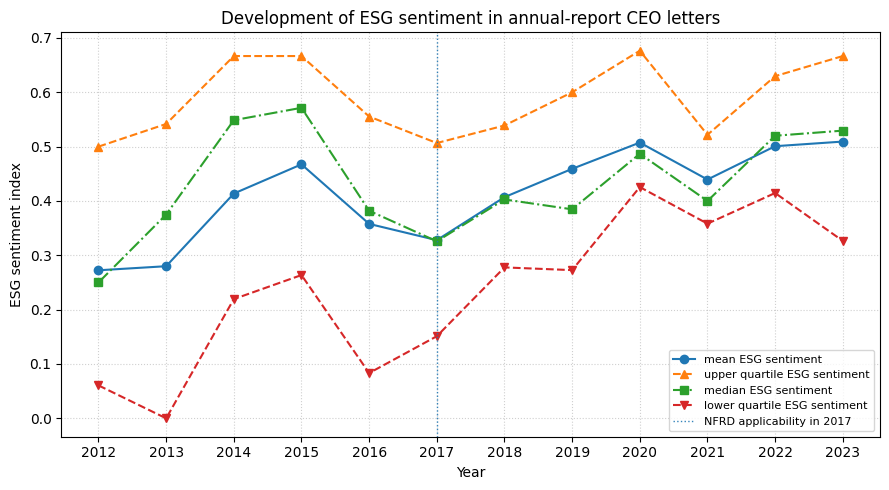

In [ ]:
# ============================================================
# 7.2 Analyze ESG sentiment results
# Firm-year ESG sentiment based on ESG-related CEO-letter sentences
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Load data if df_senti is not already available
# ============================================================

data_dir = Path("/content/drive/MyDrive/phd/Data")
file_path = data_dir / "df_ar_ceo_sentences_finbert_senti.csv"

if "df_senti" not in globals():
    if file_path.exists():
        df_senti = pd.read_csv(file_path)
        print("DataFrame loaded from CSV.")
        print("Shape:", df_senti.shape)
    else:
        raise FileNotFoundError(f"File not found at: {file_path}")
else:
    print("DataFrame already exists in memory.")
    print("Shape:", df_senti.shape)


# ============================================================
# 2. Check required columns
# ============================================================

required_cols = [
    "Company Name",
    "Year",
    "Sentence",
    "env_flag",
    "soc_flag",
    "gov_flag",
    "sent_label",
    "sent_pos",
    "sent_neg",
    "sent_neu"
]

missing_cols = [col for col in required_cols if col not in df_senti.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")


# ============================================================
# 3. Prepare ESG sentence sample
# ============================================================

df_senti = df_senti.copy()

# Make ESG flags numeric and robust to missing values
flag_cols = ["env_flag", "soc_flag", "gov_flag"]

for col in flag_cols:
    df_senti[col] = pd.to_numeric(df_senti[col], errors="coerce").fillna(0).astype(int)

# Make year numeric
df_senti["Year"] = pd.to_numeric(df_senti["Year"], errors="coerce")

# Identify sentences with at least one ESG flag
df_senti["any_esg_flag"] = df_senti[flag_cols].sum(axis=1).gt(0).astype(int)

# Keep ESG-related sentences only
df_esg = df_senti[df_senti["any_esg_flag"] == 1].copy()

if df_esg.empty:
    raise ValueError("No ESG-related sentences found. Please check the ESG flag columns.")

print("Total sentences:", len(df_senti))
print("ESG-related sentences:", len(df_esg))


# ============================================================
# 4. Clean sentiment labels and scores
# ============================================================

df_esg["sent_label"] = (
    df_esg["sent_label"]
    .astype(str)
    .str.lower()
    .str.strip()
)

score_cols = ["sent_pos", "sent_neg", "sent_neu"]

for col in score_cols:
    df_esg[col] = pd.to_numeric(df_esg[col], errors="coerce")

print("\nSentiment label distribution among ESG-related sentences:")
display(df_esg["sent_label"].value_counts(dropna=False))


# ============================================================
# 5. Aggregate ESG sentiment to firm-year level
# ============================================================

group_cols = ["Company Name", "Year"]

df_esg_firmyear_senti = (
    df_esg
    .dropna(subset=["Company Name", "Year"])
    .groupby(group_cols, as_index=False)
    .agg(
        ESG_n_sent=("sent_label", "size"),

        # Hard-label sentiment shares among ESG-related sentences
        ESG_share_pos=("sent_label", lambda x: (x == "positive").mean()),
        ESG_share_neg=("sent_label", lambda x: (x == "negative").mean()),
        ESG_share_neu=("sent_label", lambda x: (x == "neutral").mean()),

        # Average confidence scores across ESG-related sentences
        ESG_pos_mean=("sent_pos", lambda x: x.fillna(0).mean()),
        ESG_neg_mean=("sent_neg", lambda x: x.fillna(0).mean()),
        ESG_neu_mean=("sent_neu", lambda x: x.fillna(0).mean())
    )
)

# Main ESG sentiment index used in the paper:
# positive ESG sentence share minus negative ESG sentence share
df_esg_firmyear_senti["ESG_senti_index"] = (
    df_esg_firmyear_senti["ESG_share_pos"]
    - df_esg_firmyear_senti["ESG_share_neg"]
)

# Alternative score-weighted sentiment index
df_esg_firmyear_senti["ESG_senti_index_score"] = (
    df_esg_firmyear_senti["ESG_pos_mean"]
    - df_esg_firmyear_senti["ESG_neg_mean"]
)

# Optional aliases for compatibility with older code
df_esg_firmyear_senti["ESG_sent_index"] = df_esg_firmyear_senti["ESG_senti_index"]
df_esg_firmyear_senti["ESG_sent_index_label"] = df_esg_firmyear_senti["ESG_senti_index"]
df_esg_firmyear_senti["ESG_sent_index_score"] = df_esg_firmyear_senti["ESG_senti_index_score"]

df_esg_firmyear_senti["Year"] = df_esg_firmyear_senti["Year"].astype(int)

display(df_esg_firmyear_senti.head())


# Save firm-year sentiment file
output_file = data_dir / "df_ar_esg_firmyear_senti.csv"
df_esg_firmyear_senti.to_csv(output_file, index=False)

print(f"Firm-year ESG sentiment file saved to: {output_file}")


# ============================================================
# 6. Table 1 — Descriptive statistics
# ============================================================

vars_tbl1 = [
    "ESG_n_sent",
    "ESG_pos_mean",
    "ESG_neg_mean",
    "ESG_neu_mean",
    "ESG_share_pos",
    "ESG_share_neg",
    "ESG_share_neu",
    "ESG_senti_index",
    "ESG_senti_index_score"
]

vars_tbl1 = [v for v in vars_tbl1 if v in df_esg_firmyear_senti.columns]

def make_desc_table(df, cols):
    desc = df[cols].describe(percentiles=[0.25, 0.50, 0.75]).T

    desc = desc.rename(columns={
        "count": "N",
        "mean": "Mean",
        "std": "Std",
        "min": "Min",
        "25%": "P25",
        "50%": "Median",
        "75%": "P75",
        "max": "Max"
    })

    desc = desc[["N", "Mean", "Std", "Min", "P25", "Median", "P75", "Max"]]

    desc["N"] = desc["N"].astype(int)

    for col in ["Mean", "Std", "Min", "P25", "Median", "P75", "Max"]:
        desc[col] = desc[col].astype(float)

    return desc

table1 = make_desc_table(df_esg_firmyear_senti, vars_tbl1)

print("TABLE 1 — Descriptive statistics: firm-year ESG sentiment")
display(table1)

# Optional export
table1.to_csv(data_dir / "table1_esg_firmyear_sentiment_descriptives.csv")


# ============================================================
# 7. Figure 3 — ESG narrative sentiment over time
# Mean, median, and upper/lower quartiles
# ============================================================

sentiment_col = "ESG_senti_index"

year_stats = (
    df_esg_firmyear_senti
    .dropna(subset=["Year", sentiment_col])
    .groupby("Year")
    .agg(
        mean_esg_sentiment=(sentiment_col, "mean"),
        median_esg_sentiment=(sentiment_col, "median"),
        q1_esg_sentiment=(sentiment_col, lambda x: x.quantile(0.25)),
        q3_esg_sentiment=(sentiment_col, lambda x: x.quantile(0.75)),
        n_firms=("Company Name", "nunique")
    )
    .reset_index()
    .sort_values("Year")
)

year_stats["Year"] = year_stats["Year"].astype(int)

display(year_stats)

# Define the 'years' variable here
years = year_stats["Year"]

# ------------------------------------------------------------
# Plot figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    years,
    year_stats["mean_esg_sentiment"],
    color="#1f77b4",
    marker="o",
    linestyle="-",
    label="mean ESG sentiment"
)

ax.plot(
    years,
    year_stats["q3_esg_sentiment"],
    color="#ff7f0e",
    marker="^",
    linestyle="--",
    label="upper quartile ESG sentiment"
)

ax.plot(
    years,
    year_stats["median_esg_sentiment"],
    color="#2ca02c",
    marker="s",
    linestyle="-.",
    label="median ESG sentiment"
)

ax.plot(
    years,
    year_stats["q1_esg_sentiment"],
    color="#d62728",
    marker="v",
    linestyle="--",
    label="lower quartile ESG sentiment"
)

ax.axvline(
    2017,
    color="#1f77b4",
    linestyle=":",
    linewidth=1,
    alpha=0.9,
    label="NFRD applicability in 2017"
)

ax.set_title("Development of ESG sentiment in annual-report CEO letters")
ax.set_xlabel("Year")
ax.set_ylabel("ESG sentiment index")

ax.set_xticks(years)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Optional export as high-quality figure files
# ------------------------------------------------------------

data_dir = Path("/content/drive/MyDrive/phd/Data")
fig_dir = data_dir / "figures"
fig_dir.mkdir(exist_ok=True)

fig.savefig(
    fig_dir / "figure3_esg_sentiment_over_time.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    fig_dir / "figure3_esg_sentiment_over_time.pdf",
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    fig_dir / "figure3_esg_sentiment_over_time.svg",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [ ]:
# ============================================================
# Compare hard-label and score-weighted ESG sentiment indices
# ============================================================

compare_cols = [
    "Company Name",
    "Year",
    "ESG_share_pos",
    "ESG_share_neg",
    "ESG_pos_mean",
    "ESG_neg_mean",
    "ESG_senti_index",
    "ESG_senti_index_score"
]

display(df_esg_firmyear_senti[compare_cols].head())

print(
    df_esg_firmyear_senti[
        ["ESG_senti_index", "ESG_senti_index_score"]
    ].describe()
)

print(
    "Correlation:",
    df_esg_firmyear_senti[
        ["ESG_senti_index", "ESG_senti_index_score"]
    ].corr()
)

,Company Name,Year,ESG_share_pos,ESG_share_neg,ESG_pos_mean,ESG_neg_mean,ESG_senti_index,ESG_senti_index_score
0,AIG,2012,0.555556,0.222222,0.416316,0.186739,0.333333,0.229577
1,AIG,2013,1.000000,0.000000,0.822703,0.000000,1.000000,0.822703
2,AIG,2014,0.625000,0.000000,0.484779,0.000000,0.625000,0.484779
3,AIG,2015,0.185185,0.037037,0.125427,0.026365,0.148148,0.099062
4,AIG,2016,0.500000,0.125000,0.411677,0.091202,0.375000,0.320475


       ESG_senti_index  ESG_senti_index_score
count       236.000000             236.000000
mean          0.415586               0.324908
std           0.287453               0.238730
min          -0.666667              -0.569408
25%           0.257602               0.190794
50%           0.433036               0.345504
75%           0.625000               0.479958
max           1.000000               0.945626
Correlation:                        ESG_senti_index  ESG_senti_index_score
ESG_senti_index               1.000000               0.991778
ESG_senti_index_score         0.991778               1.000000


In [ ]:
# Identify sentences with at least one ESG flag
df_senti["any_esg_flag"] = (
    (df_senti["env_flag"] + df_senti["soc_flag"] + df_senti["gov_flag"]) > 0
).astype(int)

# ESG sentences only
df_esg = df_senti[df_senti["any_esg_flag"] == 1].copy()

# Normalize sentiment labels
df_esg["sent_label"] = (
    df_esg["sent_label"]
    .astype(str)
    .str.lower()
    .str.strip()
)

group_cols = ["Company Name", "Year"]

def agg_esg_sentiment(sub):

    n = len(sub)

    # Calculate hard-label shares
    share_pos = (sub["sent_label"] == "positive").mean()
    share_neg = (sub["sent_label"] == "negative").mean()
    share_neu = (sub["sent_label"] == "neutral").mean()

    # Calculate the score-weighted version
    # If a class does not appear, treat its score contribution as zero
    pos_score = sub["sent_pos"].fillna(0).sum() / n
    neg_score = sub["sent_neg"].fillna(0).sum() / n
    neu_score = sub["sent_neu"].fillna(0).sum() / n

    return pd.Series({
        "ESG_n_sent": n,

        # Average the score contribution across all ESG sentences
        "ESG_pos_mean": pos_score,
        "ESG_neg_mean": neg_score,
        "ESG_neu_mean": neu_score,

        # Calculate hard-label shares
        "ESG_share_pos": share_pos,
        "ESG_share_neg": share_neg,
        "ESG_share_neu": share_neu,

        # Recommended hard-label sentiment index
        "ESG_sent_index_label": share_pos - share_neg,

        # Alternative confidence-weighted sentiment index
        "ESG_sent_index_score": pos_score - neg_score
    })

df_esg_firmyear_senti = (
    df_esg
    .groupby(group_cols)
    .apply(agg_esg_sentiment)
    .reset_index()
)

display(df_esg_firmyear_senti.head())

/tmp/ipykernel_1906/1790139810.py:57: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,Company Name,Year,ESG_n_sent,ESG_pos_mean,ESG_neg_mean,ESG_neu_mean,ESG_share_pos,ESG_share_neg,ESG_share_neu,ESG_sent_index_label,ESG_sent_index_score
0,AIG,2012,9.0,0.416316,0.186739,0.166095,0.555556,0.222222,0.222222,0.333333,0.229577
1,AIG,2013,6.0,0.822703,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.822703
2,AIG,2014,8.0,0.484779,0.000000,0.297808,0.625000,0.000000,0.375000,0.625000,0.484779
3,AIG,2015,27.0,0.125427,0.026365,0.616128,0.185185,0.037037,0.777778,0.148148,0.099062
4,AIG,2016,8.0,0.411677,0.091202,0.279423,0.500000,0.125000,0.375000,0.375000,0.320475


In [ ]:
df_esg_firmyear_senti.to_csv('/content/drive/MyDrive/phd/Data/df_ar_esg_firmyear_senti.csv', index=False)

In [ ]:
# ============================================================
# TABLE 1 — Descriptive statistics for firm-year ESG sentiment
# ============================================================
import pandas as pd
import numpy as np

# 1) Make sure the keys are consistent
df_tbl = df_esg_firmyear_senti.copy()

# (optional) Rename columns if this table is later merged with other panels
# df_tbl = df_tbl.rename(columns={"Company Name": "Company"})

# 2) Select variables for Table 1
vars_tbl1 = [
    "ESG_n_sent",
    "ESG_pos_mean",
    "ESG_neg_mean",
    "ESG_neu_mean",
    "ESG_share_pos",
    "ESG_share_neg",
    "ESG_share_neu",
    "ESG_sent_index"
]

# Keep only columns that exist so the code remains robust
vars_tbl1 = [v for v in vars_tbl1 if v in df_tbl.columns]

# 3) Define the descriptive-table helper
def make_desc_table(df, cols):
    desc = df[cols].describe(percentiles=[.25, .5, .75]).T
    desc = desc.rename(columns={
        "count": "N",
        "mean": "Mean",
        "std": "Std",
        "min": "Min",
        "25%": "P25",
        "50%": "Median",
        "75%": "P75",
        "max": "Max"
    })[["N", "Mean", "Std", "Min", "P25", "Median", "P75", "Max"]]

    # Apply publication-style formatting if needed
    for c in ["Mean", "Std", "Min", "P25", "Median", "P75", "Max"]:
        desc[c] = desc[c].astype(float)

    desc["N"] = desc["N"].astype(int)
    return desc

table1 = make_desc_table(df_tbl, vars_tbl1)

print("TABLE 1 — Descriptive statistics (firm-year ESG sentiment)")
display(table1)

TABLE 1 — Descriptive statistics (firm-year ESG sentiment)


,N,Mean,Std,Min,P25,Median,P75,Max
ESG_n_sent,236,23.228814,22.521068,1.0,8.000000,16.000000,29.000000,128.000000
ESG_pos_mean,236,0.380930,0.189771,0.0,0.261014,0.387722,0.499905,0.945626
ESG_neg_mean,236,0.056023,0.100555,0.0,0.000000,0.000000,0.072653,0.588761
ESG_neu_mean,236,0.343471,0.176322,0.0,0.233644,0.342423,0.453806,0.898982
ESG_share_pos,236,0.483342,0.228020,0.0,0.333333,0.500000,0.644643,1.000000
ESG_share_neg,236,0.067756,0.115554,0.0,0.000000,0.000000,0.095467,0.666667
ESG_share_neu,236,0.448902,0.219231,0.0,0.333333,0.454545,0.580274,1.000000


# 8. Cluster ESG Ratio × ESG Sentiment


df_senti shape: (22806, 19)


,Company Name,Year,Region,Note,Timestamp,Sentence,word_count,prob_env,prob_soc,prob_gov,env_flag,soc_flag,gov_flag,ESG_multilabel,any_esg_flag,sent_pos,sent_neg,sent_neu,sent_label
0,AIG,2012,N. America,NaN,02/08/2026 23:04:50,OBERT H. BENMOSCHE President and Chief Executi...,46,0.012819,0.847576,0.003518,0,1,0,S,1,NaN,NaN,0.733964,neutral
1,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"When I joined AIG in August 2009, we were sell...",20,0.003059,0.000127,0.001016,0,0,0,NaN,0,NaN,0.530621,NaN,negative
2,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"Everywhere I turned, I found great people who ...",51,0.006075,0.954349,0.012917,0,1,0,S,1,NaN,0.928846,NaN,negative
3,AIG,2012,N. America,NaN,02/08/2026 23:04:50,"It was clear that AIG was too big, too diverse...",15,0.001983,0.999662,0.000886,0,1,0,S,1,NaN,0.751801,NaN,negative
4,AIG,2012,N. America,NaN,02/08/2026 23:04:50,As we identified the insurance businesses that...,51,0.002387,0.000258,0.002312,0,0,0,NaN,0,NaN,NaN,0.807371,neutral


Columns:
['Company Name', 'Year', 'Region', 'Note', 'Timestamp', 'Sentence', 'word_count', 'prob_env', 'prob_soc', 'prob_gov', 'env_flag', 'soc_flag', 'gov_flag', 'ESG_multilabel', 'any_esg_flag', 'sent_pos', 'sent_neg', 'sent_neu', 'sent_label']
Total sentences: 22806
ESG sentences: 5482
Firm-years in sentence-level data: 238


,Company Name,Year,total_sent,esg_sent,esg_ratio
0,AIG,2012,41,9,0.219512
1,AIG,2013,22,6,0.272727
2,AIG,2014,90,8,0.088889
3,AIG,2015,102,27,0.264706
4,AIG,2016,85,8,0.094118


Firm-years with at least one ESG sentence: 236


,Company Name,Year,ESG_n_sent,ESG_share_pos,ESG_share_neg,ESG_share_neu,ESG_sent_index
0,AIG,2012,9,0.555556,0.222222,0.222222,0.333333
1,AIG,2013,6,1.000000,0.000000,0.000000,1.000000
2,AIG,2014,8,0.625000,0.000000,0.375000,0.625000
3,AIG,2015,27,0.185185,0.037037,0.777778,0.148148
4,AIG,2016,8,0.500000,0.125000,0.375000,0.375000


df_cluster rows: 238


,Company Name,Year,total_sent,esg_sent,esg_ratio,ESG_n_sent,ESG_share_pos,ESG_share_neg,ESG_share_neu,ESG_sent_index
0,AIG,2012,41,9,0.219512,9.0,0.555556,0.222222,0.222222,0.333333
1,AIG,2013,22,6,0.272727,6.0,1.000000,0.000000,0.000000,1.000000
2,AIG,2014,90,8,0.088889,8.0,0.625000,0.000000,0.375000,0.625000
3,AIG,2015,102,27,0.264706,27.0,0.185185,0.037037,0.777778,0.148148
4,AIG,2016,85,8,0.094118,8.0,0.500000,0.125000,0.375000,0.375000


Missing esg_ratio: 0
Missing ESG_sent_index: 2
Complete cases for clustering: 236
Incomplete cases: 2


,Company Name,Year,total_sent,esg_sent,esg_ratio,ESG_n_sent,ESG_sent_index
94,MET,2014,87,0,0.0,NaN,NaN
198,Talanx,2018,30,0,0.0,NaN,NaN


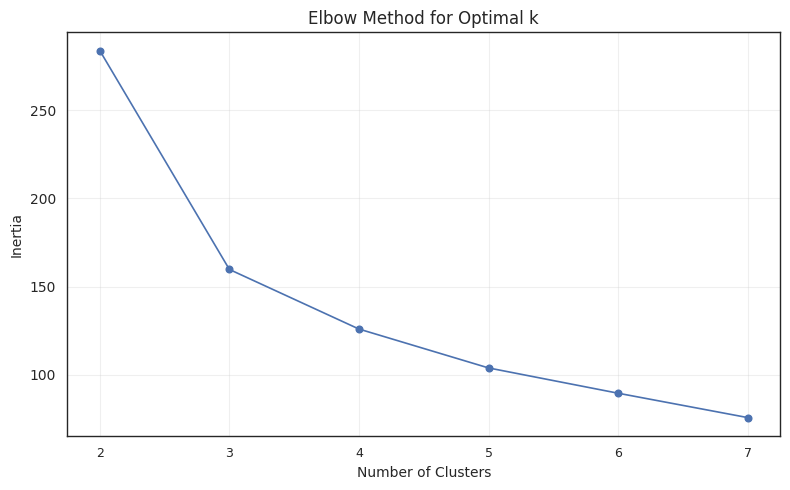

k=2, silhouette=0.380
k=3, silhouette=0.432
k=4, silhouette=0.389
k=5, silhouette=0.354
k=6, silhouette=0.351
k=7, silhouette=0.359
Cluster counts:


,count
cluster,
0,88
1,61
2,87
<NA>,2


Cluster shares:


,proportion
cluster,
0,36.97479
1,25.630252
2,36.554622
<NA>,0.840336


Cluster centers:


...

Cluster summary:


,N,ESG_ratio_mean,ESG_ratio_sd,ESG_sentiment_mean,ESG_sentiment_sd,ESG_n_sent_mean,Share_%
cluster,,,,,,,
0,88,0.385494,0.071912,0.433955,0.166613,35.897727,37.288136
1,61,0.133275,0.065670,0.071571,0.224462,20.754098,25.847458
2,87,0.184693,0.063256,0.638211,0.167716,12.149425,36.864407


Transition matrix (rows = t-1, columns = t):


cluster,0,1,2,Total
cluster_lag,,,,
0,64,5,10,79
1,9,30,17,56
2,11,14,54,79
Total,84,49,81,214


Firms with at least one cluster transition: 18 of 22
Total within-firm transitions observed: 66


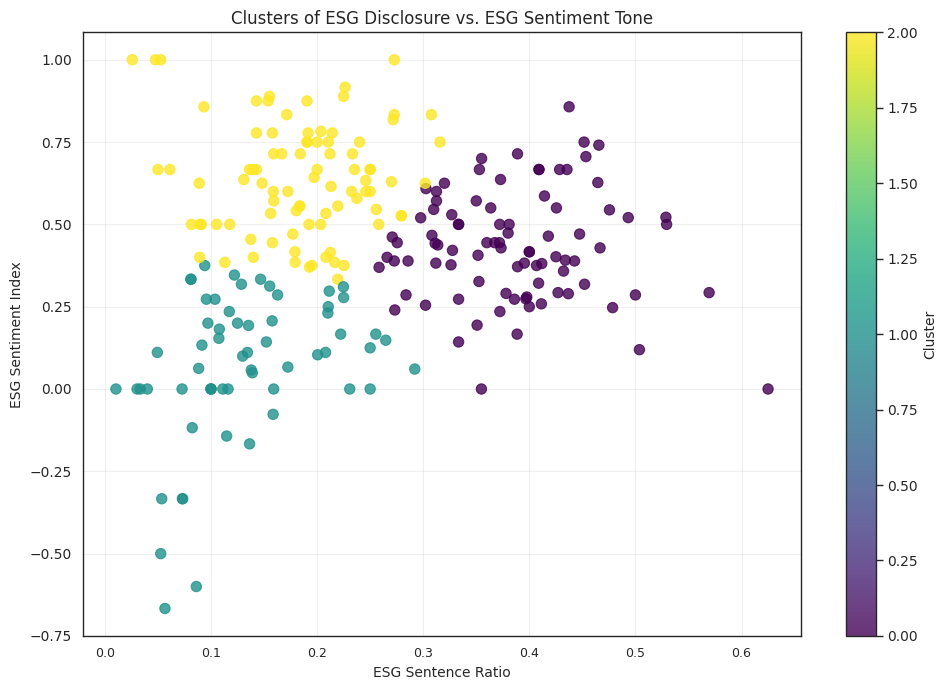

,Company Name,Year,total_sent,esg_sent,esg_ratio,ESG_n_sent,ESG_share_pos,ESG_share_neg,ESG_share_neu,ESG_sent_index,cluster
0,AIG,2012,41,9,0.219512,9.0,0.555556,0.222222,0.222222,0.333333,2
1,AIG,2013,22,6,0.272727,6.0,1.000000,0.000000,0.000000,1.000000,2
2,AIG,2014,90,8,0.088889,8.0,0.625000,0.000000,0.375000,0.625000,2
3,AIG,2015,102,27,0.264706,27.0,0.185185,0.037037,0.777778,0.148148,1
4,AIG,2016,85,8,0.094118,8.0,0.500000,0.125000,0.375000,0.375000,1
...,...,...,...,...,...,...,...,...,...,...,...
233,Zurich,2019,67,28,0.417910,28.0,0.464286,0.000000,0.535714,0.464286,0
234,Zurich,2020,62,28,0.451613,28.0,0.750000,0.000000,0.250000,0.750000,0
235,Zurich,2021,63,24,0.380952,24.0,0.500000,0.000000,0.500000,0.500000,0
236,Zurich,2022,59,22,0.372881,22.0,0.681818,0.045455,0.272727,0.636364,0


Exported to: /content/drive/MyDrive/phd/Data/df_ar_cluster.csv


In [ ]:
# ============================================================
# ESG narrative clusters using ESG intensity × ESG sentiment
# ============================================================
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ============================================================
# 1. Load ESG sentence-level data with FinBERT sentiment
# ============================================================
file_path = "/content/drive/MyDrive/phd/Data/df_ar_ceo_sentences_finbert_senti.csv"

df_senti = pd.read_csv(file_path)

print("df_senti shape:", df_senti.shape)
display(df_senti.head())
print("Columns:")
print(df_senti.columns.tolist())


# ============================================================
# 2. Required-column check
# ============================================================
required_cols = [
    "Company Name",
    "Year",
    "Sentence",
    "env_flag",
    "soc_flag",
    "gov_flag",
    "sent_label"
]

missing_cols = [col for col in required_cols if col not in df_senti.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")


# ============================================================
# 3. ESG sentence flag
# ============================================================
df_senti["any_esg_flag"] = (
    (df_senti["env_flag"] + df_senti["soc_flag"] + df_senti["gov_flag"]) > 0
).astype(int)

print("Total sentences:", len(df_senti))
print("ESG sentences:", df_senti["any_esg_flag"].sum())


# ============================================================
# 4. Firm-year ESG intensity
# ESG ratio = ESG sentences / total sentences
# ============================================================
df_tmp = (
    df_senti
    .groupby(["Company Name", "Year"])
    .agg(
        total_sent=("Sentence", "count"),
        esg_sent=("any_esg_flag", "sum")
    )
    .reset_index()
)

df_tmp["esg_ratio"] = df_tmp["esg_sent"] / df_tmp["total_sent"]

print("Firm-years in sentence-level data:", len(df_tmp))
display(df_tmp.head())


# ============================================================
# 5. Firm-year ESG sentiment
# ============================================================
df_esg = df_senti[df_senti["any_esg_flag"] == 1].copy()

df_esg["sent_label"] = (
    df_esg["sent_label"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df_esg["is_positive"] = (df_esg["sent_label"] == "positive").astype(int)
df_esg["is_negative"] = (df_esg["sent_label"] == "negative").astype(int)
df_esg["is_neutral"] = (df_esg["sent_label"] == "neutral").astype(int)

df_esg_firmyear_senti = (
    df_esg
    .groupby(["Company Name", "Year"])
    .agg(
        ESG_n_sent=("Sentence", "count"),
        ESG_share_pos=("is_positive", "mean"),
        ESG_share_neg=("is_negative", "mean"),
        ESG_share_neu=("is_neutral", "mean")
    )
    .reset_index()
)

# Main sentiment index = positive share minus negative share
df_esg_firmyear_senti["ESG_sent_index"] = (
    df_esg_firmyear_senti["ESG_share_pos"] -
    df_esg_firmyear_senti["ESG_share_neg"]
)

print("Firm-years with at least one ESG sentence:", len(df_esg_firmyear_senti))
display(df_esg_firmyear_senti.head())


# ============================================================
# 6. Merge ESG intensity and ESG sentiment into cluster dataframe
# ============================================================
df_cluster = df_tmp.merge(
    df_esg_firmyear_senti,
    on=["Company Name", "Year"],
    how="left"
)

print("df_cluster rows:", len(df_cluster))
display(df_cluster.head())


# ============================================================
# 7. Missing-value check for clustering inputs
# ============================================================
print("Missing esg_ratio:", df_cluster["esg_ratio"].isna().sum())
print("Missing ESG_sent_index:", df_cluster["ESG_sent_index"].isna().sum())

complete_cases = df_cluster[["esg_ratio", "ESG_sent_index"]].notna().all(axis=1)

print("Complete cases for clustering:", complete_cases.sum())
print("Incomplete cases:", (~complete_cases).sum())

missing_rows = df_cluster.loc[
    ~complete_cases,
    [
        "Company Name",
        "Year",
        "total_sent",
        "esg_sent",
        "esg_ratio",
        "ESG_n_sent",
        "ESG_sent_index"
    ]
]

display(missing_rows)


# ============================================================
# 8. Complete cases only for clustering
# ============================================================
df_cluster_complete = df_cluster.loc[complete_cases].copy()

X = df_cluster_complete[["esg_ratio", "ESG_sent_index"]].copy()

if len(X) < 3:
    raise ValueError("Not enough complete observations for k-means clustering.")


# ============================================================
# 9. Standardize clustering variables
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ============================================================
# 10. Elbow method
# ============================================================
inertia = []
K = range(2, 8)

for k in K:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K), inertia, marker="o")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Silhouette scores
# ============================================================
for k in K:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.3f}")


# ============================================================
# 12. Final KMeans clustering
# ============================================================
k = 3

km = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df_cluster_complete["cluster"] = km.fit_predict(X_scaled)


# ============================================================
# 13. Merge cluster labels back into full dataframe
# ============================================================
df_cluster = df_cluster.merge(
    df_cluster_complete[["Company Name", "Year", "cluster"]],
    on=["Company Name", "Year"],
    how="left"
)

df_cluster["cluster"] = df_cluster["cluster"].astype("Int64")


# ============================================================
# 14. Cluster counts and shares
# ============================================================
cluster_counts = (
    df_cluster["cluster"]
    .value_counts(dropna=False)
    .sort_index()
)

print("Cluster counts:")
display(cluster_counts)

cluster_shares = (
    df_cluster["cluster"]
    .value_counts(normalize=True, dropna=False)
    .sort_index() * 100
)

print("Cluster shares:")
display(cluster_shares)


# ============================================================
# 15. Cluster centers
# ============================================================
centers = scaler.inverse_transform(km.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=["esg_ratio", "ESG_sent_index"]
)

centers_df["cluster"] = range(k)
centers_df = centers_df[["cluster", "esg_ratio", "ESG_sent_index"]]

print("Cluster centers:")
display(centers_df)


# ============================================================
# 16. Cluster summary table
# ============================================================
cluster_table = (
    df_cluster
    .dropna(subset=["cluster"])
    .groupby("cluster")
    .agg(
        N=("Company Name", "count"),
        ESG_ratio_mean=("esg_ratio", "mean"),
        ESG_ratio_sd=("esg_ratio", "std"),
        ESG_sentiment_mean=("ESG_sent_index", "mean"),
        ESG_sentiment_sd=("ESG_sent_index", "std"),
        ESG_n_sent_mean=("ESG_n_sent", "mean")
    )
)

cluster_table["Share_%"] = 100 * cluster_table["N"] / cluster_table["N"].sum()

print("Cluster summary:")
display(cluster_table)

# ============================================================
# 16b. Transition matrix — within-firm cluster switching
# ============================================================
df_trans = (
    df_cluster
    .dropna(subset=["cluster"])
    .sort_values(["Company Name", "Year"])
    .copy()
)

df_trans["cluster_lag"] = df_trans.groupby("Company Name")["cluster"].shift(1)

# Cross-tab: rows = pattern in year t-1, columns = pattern in year t
transition_matrix = pd.crosstab(
    df_trans["cluster_lag"], df_trans["cluster"], margins=True, margins_name="Total"
)
print("Transition matrix (rows = t-1, columns = t):")
display(transition_matrix)

# Firms that ever switch pattern
n_distinct = df_trans.groupby("Company Name")["cluster"].nunique()
n_switchers = (n_distinct > 1).sum()
n_firms = n_distinct.size
print(f"Firms with at least one cluster transition: {n_switchers} of {n_firms}")

# Total number of within-firm transitions (excludes the first year per firm, which has no lag)
has_lag = df_trans["cluster_lag"].notna()
n_transitions = (df_trans.loc[has_lag, "cluster"] != df_trans.loc[has_lag, "cluster_lag"]).sum()
print(f"Total within-firm transitions observed: {n_transitions}")

# Export for the appendix table
transition_matrix.to_csv(
    "/content/drive/MyDrive/phd/Data/cluster_transition_matrix.csv"
)

# ============================================================
# 17. Scatterplot
# ============================================================
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df_cluster_complete["esg_ratio"],
    df_cluster_complete["ESG_sent_index"],
    c=df_cluster_complete["cluster"],
    cmap="viridis",
    s=55,           # larger dots; default is around 20
    alpha=0.8
)

plt.xlabel("ESG Sentence Ratio")
plt.ylabel("ESG Sentiment Index")
plt.title("Clusters of ESG Disclosure vs. ESG Sentiment Tone")
plt.colorbar(scatter, label="Cluster")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 18. Display and export final dataset
# ============================================================
display(df_cluster)

output_path = "/content/drive/MyDrive/phd/Data/df_ar_cluster.csv"
df_cluster.to_csv(output_path, index=False)

print("Exported to:", output_path)

# 9. GPT-assisted robustness checks with OpenAI Batch API

This section replaces the earlier manual GPT validation workflow. It adds three separate robustness checks:

1. **ESG-BERT validation** — checks whether sentences flagged as ESG/non-ESG look plausible under an independent GPT-assisted semantic coding.
2. **FinBERT validation** — checks whether positive/neutral/negative sentiment labels look plausible for CEO-letter sentences.
3. **BERTopic/theme-group validation** — checks whether the higher-order topic groups are semantically recognizable.

The GPT step is used as an auxiliary robustness check, not as ground truth and not as a replacement for ESG-BERT, FinBERT, or BERTopic.


## 9.0 - 9.5 Setup and Helper functions


In [ ]:
# ============================================================
# GPT-assisted robustness check: prepare validation sample
# ============================================================
import os
import textwrap
import pandas as pd
import numpy as np

base_path = "/content/drive/MyDrive/phd/Data/"
output_dir = os.path.join(base_path, "gpt_robustness")
os.makedirs(output_dir, exist_ok=True)

sentiment_path = os.path.join(base_path, "df_ar_ceo_sentences_finbert_senti.csv")
esgbert_path = os.path.join(base_path, "df_ar_ceo_sentences_esgbert_scored.csv")

# Use the in-memory dataframe if available; otherwise reload the latest saved file
if "df_senti" in globals():
    df_gpt = df_senti.copy()
    print("Using df_senti from memory:", df_gpt.shape)
elif os.path.exists(sentiment_path):
    df_gpt = pd.read_csv(sentiment_path)
    print("Loaded FinBERT sentiment file:", df_gpt.shape)
elif os.path.exists(esgbert_path):
    df_gpt = pd.read_csv(esgbert_path)
    print("Loaded ESG-BERT scored file:", df_gpt.shape)
else:
    raise FileNotFoundError("No sentence-level ESG file found for the GPT robustness check.")

required_cols = ["Company Name", "Year", "Sentence"]
missing_cols = [col for col in required_cols if col not in df_gpt.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Keep the text clean and restrict the validation sample to meaningful sentences
df_gpt["Sentence"] = (
    df_gpt["Sentence"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_gpt["word_count"] = df_gpt["Sentence"].str.split().str.len()
df_gpt = df_gpt[df_gpt["word_count"] >= 8].copy()

# ESG sentence flag, where ESG-BERT outputs are available
flag_cols = [col for col in ["env_flag", "soc_flag", "gov_flag"] if col in df_gpt.columns]

if flag_cols:
    for col in flag_cols:
        df_gpt[col] = pd.to_numeric(df_gpt[col], errors="coerce").fillna(0)

    df_gpt["ESG_flag"] = df_gpt[flag_cols].sum(axis=1).gt(0).astype(int)
    df_gpt_esg = df_gpt[df_gpt["ESG_flag"] == 1].copy()
else:
    df_gpt["ESG_flag"] = 1
    df_gpt_esg = df_gpt.copy()

# Period split aligned with the NFRD framing used in the paper
df_gpt_esg["Year"] = pd.to_numeric(df_gpt_esg["Year"], errors="coerce")
df_gpt_esg["period"] = pd.Series(pd.NA, index=df_gpt_esg.index, dtype="string")
df_gpt_esg.loc[df_gpt_esg["Year"].between(2012, 2016), "period"] = "2012-2016"
df_gpt_esg.loc[df_gpt_esg["Year"].between(2017, 2023), "period"] = "2017-2023"
df_gpt_esg = df_gpt_esg.dropna(subset=["Year", "period"]).copy()

# Region is useful for the validation design, but the code also works without it
if "Region" not in df_gpt_esg.columns:
    df_gpt_esg["Region"] = "Not available"

sample_group_cols = ["Region", "period"]
sentences_per_group = 12
random_state = 42

validation_sample = (
    df_gpt_esg
    .groupby(sample_group_cols, group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), sentences_per_group), random_state=random_state))
    .reset_index(drop=True)
)

if validation_sample.empty:
    raise ValueError("The GPT validation sample is empty. Check the ESG flags, year range, and sentence filters.")

validation_sample.insert(0, "validation_id", range(1, len(validation_sample) + 1))

metadata_cols = [
    "validation_id",
    "Company Name",
    "Year",
    "Region",
    "period",
    "Sentence",
    "env_flag",
    "soc_flag",
    "gov_flag",
    "sent_label"
]

metadata_cols = [col for col in metadata_cols if col in validation_sample.columns]
validation_sample = validation_sample[metadata_cols].copy()

sample_path = os.path.join(output_dir, "gpt_validation_sample.csv")
validation_sample.to_csv(sample_path, index=False)

print("Validation sample rows:", len(validation_sample))
print("Exported sample to:", sample_path)
display(validation_sample.head(20))

Using df_senti from memory: (22806, 19)


/tmp/ipykernel_1906/2244402750.py:77: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Validation sample rows: 72
Exported sample to: /content/drive/MyDrive/phd/Data/gpt_robustness/gpt_validation_sample.csv


,validation_id,Company Name,Year,Region,period,Sentence,env_flag,soc_flag,gov_flag,sent_label
0,1,Sompo,2016,Asia,2012-2016,"Furthermore, two of our outside directors are ...",0,1,0,neutral
1,2,Daichi,2013,Asia,2012-2016,MS&AD Insurance Group has set out its mission ...,1,1,0,positive
2,3,Sompo,2015,Asia,2012-2016,"To achieve this goal, all Group employees will...",0,1,0,positive
3,4,Tokio Marine,2014,Asia,2012-2016,We will seek to promote global diversity withi...,0,1,0,positive
4,5,Sompo,2014,Asia,2012-2016,"In financial and other services, we are proact...",0,1,0,positive
5,6,PIC,2015,Asia,2012-2016,The Group received TWPs of RMB18.944 billion f...,1,0,0,positive
6,7,China Life,2014,Asia,2012-2016,"Finally, the Company will operate strictly in ...",1,1,0,positive
7,8,MSAD,2015,Asia,2012-2016,"As for the bottom line (net profit), the balan...",1,0,0,positive
8,9,Tokio Marine,2016,Asia,2012-2016,Aiming “To Be a Good Company” That Earns Trust...,0,1,0,positive
9,10,MSAD,2015,Asia,2012-2016,"In particular, promoting the career developmen...",0,1,0,positive


In [ ]:
!pip -q install openai

In [ ]:
import os

try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
except Exception:
    pass

if not os.environ.get("OPENAI_API_KEY"):
    from getpass import getpass
    os.environ["OPENAI_API_KEY"] = getpass("Paste your OpenAI API key: ")

Paste your OpenAI API key: ··········


In [ ]:
import json
import time
import pandas as pd
from openai import OpenAI

client = OpenAI()

MODEL = "gpt-5.4-mini"

theme_groups = {
    "Business & financial performance": "strategy, financial results, growth, profitability, capital allocation, investment performance, shareholder value",
    "Core insurance operations": "underwriting, claims, pricing, reinsurance, premiums, solvency, distribution, policyholders, insurance products",
    "Risk & resilience": "catastrophes, uncertainty, pandemic, cyber risk, compliance, resilience, risk prevention, risk management",
    "Sustainability & ESG": "climate, emissions, carbon, transition, net zero, ESG, responsible investment, sustainable finance",
    "Transformation & innovation": "digitalisation, technology, data, AI, automation, platforms, modernization, innovation",
    "People & stakeholder responsibility": "employees, customers, communities, diversity, inclusion, culture, wellbeing, social responsibility",
    "Other / unclear": "use only when the sentence is too generic, boilerplate, or cannot be assigned reliably"
}

theme_labels = list(theme_groups.keys())

schema = {
    "type": "object",
    "properties": {
        "classifications": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "validation_id": {"type": "integer"},
                    "theme_group": {
                        "type": "string",
                        "enum": theme_labels
                    },
                    "confidence_0_1": {"type": "number"},
                    "short_reason": {"type": "string"}
                },
                "required": [
                    "validation_id",
                    "theme_group",
                    "confidence_0_1",
                    "short_reason"
                ],
                "additionalProperties": False
            }
        },
        "overall_summary": {"type": "string"},
        "ambiguities_or_mismatches": {"type": "string"}
    },
    "required": [
        "classifications",
        "overall_summary",
        "ambiguities_or_mismatches"
    ],
    "additionalProperties": False
}

In [ ]:
theme_text = "\n".join(
    f"- {theme}: {description}"
    for theme, description in theme_groups.items()
)

system_prompt = f"""
You are helping validate a thematic analysis of CEO letters from insurance companies.

Classify each sentence into exactly one of the following theme groups:

{theme_text}

Rules:
1. Use only the sentence text and metadata provided.
2. Do not use outside knowledge about the companies.
3. If a sentence fits multiple categories, choose the most central theme.
4. Use "Other / unclear" only for generic, boilerplate, or insufficiently informative sentences.
5. Return only the requested structured JSON.
""".strip()


def make_user_prompt(batch_df):
    lines = []

    for _, row in batch_df.iterrows():
        lines.append(
            f"[{int(row['validation_id'])}] "
            f"Region={row.get('Region', 'NA')}; "
            f"Period={row.get('period', 'NA')}; "
            f"Year={int(row['Year'])}; "
            f"Company={row['Company Name']}\n"
            f"Sentence: {row['Sentence']}"
        )

    sample_text = "\n\n".join(lines)

    return f"""
Classify the following CEO-letter sentences.

Sentences:

{sample_text}
""".strip()

In [ ]:
# ============================================================
# Create the ChatGPT validation prompt
# ============================================================
theme_groups = {
    "Business & financial performance": "strategy, financial results, growth, profitability, capital allocation, investment performance, shareholder value",
    "Core insurance operations": "underwriting, claims, pricing, reinsurance, premiums, solvency, distribution, policyholders, insurance products",
    "Risk & resilience": "catastrophes, uncertainty, pandemic, cyber risk, compliance, resilience, risk prevention, risk management",
    "Sustainability & ESG": "climate, emissions, carbon, transition, net zero, ESG, responsible investment, sustainable finance",
    "Transformation & innovation": "digitalisation, technology, data, AI, automation, platforms, modernization, innovation",
    "People & stakeholder responsibility": "employees, customers, communities, diversity, inclusion, culture, wellbeing, social responsibility",
    "Other / unclear": "use only when the sentence is too generic, boilerplate, or cannot be assigned reliably"
}

theme_text = "\n".join(
    f"- {theme}: {description}"
    for theme, description in theme_groups.items()
)

sample_lines = []

for _, row in validation_sample.iterrows():
    sample_lines.append(
        f"[{row['validation_id']}] "
        f"Region={row['Region']}; "
        f"Period={row['period']}; "
        f"Year={int(row['Year'])}; "
        f"Company={row['Company Name']}\n"
        f"Sentence: {row['Sentence']}"
    )

sample_text = "\n".join(sample_lines)

gpt_prompt = f"""
You are helping me validate a thematic analysis of CEO letters from insurance companies.

Context:
- The data consist of sentence-level CEO-letter text from annual reports.
- The main analysis uses ESG-BERT, FinBERT sentiment, and BERTopic-style thematic grouping.
- This validation step should be treated as a qualitative robustness check, not as a replacement for the main model.

Task:
Classify each numbered sentence into exactly one of the following broad thematic groups:

{theme_text}

Instructions:
1. Use only the sentence text and the short metadata provided.
2. Do not use outside knowledge about the companies.
3. If a sentence fits more than one category, choose the most central theme.
4. Use "Other / unclear" for boilerplate, generic, or insufficiently informative sentences.
5. Return a table with these columns:
   validation_id | theme_group | confidence_0_1 | short_reason
6. After the table, briefly summarize whether the classifications broadly support the six-theme structure.
7. Highlight any recurring ambiguity or mismatch that could affect the interpretation of the BERTopic results.

Sentences for validation:

{sample_text}
""".strip()

prompt_path = os.path.join(output_dir, "gpt_validation_prompt.txt")

with open(prompt_path, "w", encoding="utf-8") as f:
    f.write(gpt_prompt)

print("Prompt exported to:", prompt_path)
print("\nPreview of the prompt:\n")
print(gpt_prompt[:2500])

Prompt exported to: /content/drive/MyDrive/phd/Data/gpt_robustness/gpt_validation_prompt.txt

Preview of the prompt:

You are helping me validate a thematic analysis of CEO letters from insurance companies.

Context:
- The data consist of sentence-level CEO-letter text from annual reports.
- The main analysis uses ESG-BERT, FinBERT sentiment, and BERTopic-style thematic grouping.
- This validation step should be treated as a qualitative robustness check, not as a replacement for the main model.

Task:
Classify each numbered sentence into exactly one of the following broad thematic groups:

- Business & financial performance: strategy, financial results, growth, profitability, capital allocation, investment performance, shareholder value
- Core insurance operations: underwriting, claims, pricing, reinsurance, premiums, solvency, distribution, policyholders, insurance products
- Risk & resilience: catastrophes, uncertainty, pandemic, cyber risk, compliance, resilience, risk prevention, r

In [ ]:
# ============================================================
# Create an empty template for recording the GPT output
# ============================================================
validation_template = validation_sample.copy()
validation_template["GPT_theme_group"] = ""
validation_template["GPT_confidence_0_1"] = ""
validation_template["GPT_short_reason"] = ""

# Fill this file after running the prompt in ChatGPT, then save it as the completed file below
template_path = os.path.join(output_dir, "gpt_validation_template.csv")
completed_path = os.path.join(output_dir, "gpt_validation_completed.csv")

validation_template.to_csv(template_path, index=False)

print("Template exported to:", template_path)
print("After coding the sentences with ChatGPT, save the completed file as:", completed_path)
display(validation_template.head())

Template exported to: /content/drive/MyDrive/phd/Data/gpt_robustness/gpt_validation_template.csv
After coding the sentences with ChatGPT, save the completed file as: /content/drive/MyDrive/phd/Data/gpt_robustness/gpt_validation_completed.csv


,validation_id,Company Name,Year,Region,period,Sentence,env_flag,soc_flag,gov_flag,sent_label,GPT_theme_group,GPT_confidence_0_1,GPT_short_reason
0,1,Sompo,2016,Asia,2012-2016,"Furthermore, two of our outside directors are ...",0,1,0,neutral,,,
1,2,Daichi,2013,Asia,2012-2016,MS&AD Insurance Group has set out its mission ...,1,1,0,positive,,,
2,3,Sompo,2015,Asia,2012-2016,"To achieve this goal, all Group employees will...",0,1,0,positive,,,
3,4,Tokio Marine,2014,Asia,2012-2016,We will seek to promote global diversity withi...,0,1,0,positive,,,
4,5,Sompo,2014,Asia,2012-2016,"In financial and other services, we are proact...",0,1,0,positive,,,


In [ ]:
# ============================================================
# Analyze completed GPT validation output
# ============================================================
completed_path = os.path.join(output_dir, "gpt_validation_completed.csv")

if os.path.exists(completed_path):
    gpt_completed = pd.read_csv(completed_path)

    if "GPT_theme_group" not in gpt_completed.columns:
        raise ValueError("The completed validation file needs a 'GPT_theme_group' column.")

    gpt_completed["GPT_theme_group"] = (
        gpt_completed["GPT_theme_group"]
        .astype(str)
        .str.strip()
    )

    # Theme distribution in the validation sample
    gpt_theme_counts = (
        gpt_completed["GPT_theme_group"]
        .value_counts(dropna=False)
        .rename_axis("GPT_theme_group")
        .reset_index(name="n")
    )
    gpt_theme_counts["share"] = gpt_theme_counts["n"] / gpt_theme_counts["n"].sum()

    print("GPT theme distribution:")
    display(gpt_theme_counts)

    # Region-period summary for the robustness section
    region_period_summary = (
        gpt_completed
        .groupby(["Region", "period", "GPT_theme_group"])
        .size()
        .reset_index(name="n")
    )

    region_period_summary["share_within_region_period"] = (
        region_period_summary
        .groupby(["Region", "period"])["n"]
        .transform(lambda x: x / x.sum())
    )

    print("Region-period GPT validation summary:")
    display(region_period_summary)

    # Optional comparison if a BERTopic/group column is included in the completed file
    comparison_cols = [col for col in ["topic_group", "BERTopic_group", "manual_topic_group"] if col in gpt_completed.columns]

    if comparison_cols:
        comparison_col = comparison_cols[0]
        comparison_table = pd.crosstab(
            gpt_completed[comparison_col],
            gpt_completed["GPT_theme_group"],
            normalize="index"
        )
        print(f"Comparison against {comparison_col}:")
        display(comparison_table)
    else:
        print("No BERTopic/manual topic-group column found for direct agreement comparison.")

    summary_path = os.path.join(output_dir, "gpt_validation_summary.csv")
    region_period_summary.to_csv(summary_path, index=False)
    print("Summary exported to:", summary_path)

else:
    print("Completed GPT validation file not found yet.")
    print("Run the exported prompt in ChatGPT, fill the template, and save it as:")
    print(completed_path)

Completed GPT validation file not found yet.
Run the exported prompt in ChatGPT, fill the template, and save it as:
/content/drive/MyDrive/phd/Data/gpt_robustness/gpt_validation_completed.csv


In [ ]:
# ============================================================
# 9.0 Mount Google Drive if running in Google Colab
# ============================================================

import os

try:
    from google.colab import drive

    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
        print("Google Drive mounted.")
    else:
        print("Google Drive is already mounted.")

except ImportError:
    print("Not running in Google Colab. Skipping Google Drive mount.")

Google Drive is already mounted.


In [ ]:
# ============================================================
# 9.1 Global setup for GPT-assisted robustness checks
# ============================================================

import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openai", "scikit-learn"])

import os
import json
import time
from pathlib import Path
from getpass import getpass

import numpy as np
import pandas as pd
from openai import OpenAI
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ------------------------------------------------------------
# Main paths
# ------------------------------------------------------------
base_path = Path("/content/drive/MyDrive/phd/Data")
output_dir = base_path / "gpt_robustness_batch"
output_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Model and sampling settings
# ------------------------------------------------------------
# Safe default because it supports structured outputs.
# If OpenAI project uses another model ID, change only this line.
MODEL = "gpt-5.4-mini" #"gpt-4o-mini"

# Make the model name safe for folder/file paths
MODEL_DIR_NAME = (
    MODEL
    .replace("/", "-")
    .replace(":", "-")
    .replace(".", "-")
)

RANDOM_STATE = 42
BATCH_SIZE = 20

# Sample sizes. Adjust upward if using a stronger validation.
N_ESG_PER_GROUP = 100          # Environmental / Social / Governance / Multiple / Not ESG, if available
N_FINBERT_PER_LABEL = 100      # positive / neutral / negative
N_TOPIC_PER_GROUP = 20        # each topic_group, if topic_group is available
N_TOPIC_PER_TOPIC = 5         # each BERTopic topic, if only Topic is available
MAX_TOPIC_GROUPS = 25         # safety cap if sampling by individual topic IDs

# Switches for optional validation tasks
RUN_TOPIC_VALIDATION = False

# ------------------------------------------------------------
# Main paths
# ------------------------------------------------------------
base_path = Path("/content/drive/MyDrive/phd/Data")

output_dir = base_path / f"gpt_robustness_batch_{MODEL_DIR_NAME}"
output_dir.mkdir(parents=True, exist_ok=True)

print("Output directory:", output_dir)
print("Model:", MODEL)


Output directory: /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini
Model: gpt-5.4-mini


In [ ]:
# ============================================================
# 9.2 Helper functions: loading, cleaning, sampling, and labels
# ============================================================

def first_existing_col(df, candidates):
    """Return the first column name from candidates that exists in df."""
    for col in candidates:
        if col in df.columns:
            return col
    return None


def clean_sentence_text(df, sentence_col="Sentence"):
    """Clean sentence text and remove very short sentences."""
    df = df.copy()

    if sentence_col not in df.columns:
        raise ValueError(f"Required sentence column not found: {sentence_col}")

    df[sentence_col] = (
        df[sentence_col]
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    df["word_count"] = df[sentence_col].str.split().str.len()
    df = df[df["word_count"] >= 8].copy()

    return df


def add_period_column(df):
    """Add the period split used in the paper."""
    df = df.copy()

    if "Year" not in df.columns:
        raise ValueError("The dataframe needs a 'Year' column.")

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df["period"] = pd.Series(pd.NA, index=df.index, dtype="string")
    df.loc[df["Year"].between(2012, 2016), "period"] = "2012-2016"
    df.loc[df["Year"].between(2017, 2023), "period"] = "2017-2023"
    df = df.dropna(subset=["Year", "period"]).copy()

    return df


def load_main_sentence_dataframe():
    """Load the best available sentence-level dataframe for validation."""
    memory_candidates = [
        "df_senti",
        "df_ceo_esg_score",
        "df_sentence",
        "df_sent",
        "df_gpt"
    ]

    for name in memory_candidates:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            df = globals()[name].copy()
            print(f"Using dataframe from memory: {name}, shape={df.shape}")
            return df

    file_candidates = [
        base_path / "df_ar_ceo_sentences_finbert_senti.csv",
        base_path / "df_ar_ceo_sentences_esgbert_scored.csv",
        base_path / "Phdp2_sentence_level_topics.csv",
        base_path / "Phdp2_sentence_level_topics_grouped.csv",
        base_path / "df_ar_ceo_sentences_topics.csv",
    ]

    for path in file_candidates:
        if path.exists():
            df = pd.read_csv(path)
            print(f"Loaded dataframe from file: {path}, shape={df.shape}")
            return df

    raise FileNotFoundError("No suitable sentence-level dataframe found in memory or in base_path.")


def sample_per_group(df, group_cols, n_per_group, random_state=42):
    """Sample up to n_per_group observations from each group."""
    df = df.copy()
    group_cols = [col for col in group_cols if col in df.columns]

    if not group_cols:
        return df.sample(n=min(len(df), n_per_group), random_state=random_state).copy()

    sampled = (
        df.groupby(group_cols, group_keys=False, dropna=False)
        .apply(lambda x: x.sample(n=min(len(x), n_per_group), random_state=random_state))
        .reset_index(drop=True)
    )

    return sampled


def normalize_finbert_label(value):
    """Normalize FinBERT labels to positive/neutral/negative."""
    if pd.isna(value):
        return np.nan

    label = str(value).strip().lower()

    if label in ["pos", "positive", "label_positive"]:
        return "positive"
    if label in ["neg", "negative", "label_negative"]:
        return "negative"
    if label in ["neu", "neutral", "label_neutral"]:
        return "neutral"

    return np.nan


def normalize_theme_label(value):
    """Normalize topic-group labels where possible."""
    if pd.isna(value):
        return np.nan

    label = str(value).strip()
    compact = label.lower().replace("&", "and")

    mapping = {
        "business and financial performance": "Business & financial performance",
        "business financial performance": "Business & financial performance",
        "financial performance": "Business & financial performance",
        "core insurance operations": "Core insurance operations",
        "insurance operations": "Core insurance operations",
        "risk and resilience": "Risk & resilience",
        "risk resilience": "Risk & resilience",
        "sustainability and esg": "Sustainability & ESG",
        "sustainability esg": "Sustainability & ESG",
        "esg": "Sustainability & ESG",
        "transformation and innovation": "Transformation & innovation",
        "transformation innovation": "Transformation & innovation",
        "people and stakeholder responsibility": "People & stakeholder responsibility",
        "people stakeholder responsibility": "People & stakeholder responsibility",
        "people and stakeholders": "People & stakeholder responsibility",
        "other / unclear": "Other / unclear",
        "other": "Other / unclear",
        "unclear": "Other / unclear",
    }

    return mapping.get(compact, label)


# Load and prepare the main dataframe once.
df_main = load_main_sentence_dataframe()
df_main = clean_sentence_text(df_main, sentence_col="Sentence")
df_main = add_period_column(df_main)

if "Region" not in df_main.columns:
    df_main["Region"] = "Not available"


print("Prepared main dataframe:", df_main.shape)
display(df_main.head())


Using dataframe from memory: df_senti, shape=(21432, 19)
Prepared main dataframe: (21432, 20)


,Company Name,Year,Region,Note,Timestamp,Sentence,word_count,prob_env,prob_soc,prob_gov,env_flag,soc_flag,gov_flag,ESG_multilabel,any_esg_flag,sent_pos,sent_neg,sent_neu,sent_label,period
0,AIG,2013,N. America,NaN,12/09/2025 16:13:50,"To Our Shareholders, When we look back on 2013...",35,0.886603,0.958969,0.002579,1,1,0,"E,S",1,0.898190,NaN,NaN,positive,2012-2016
1,AIG,2013,N. America,NaN,12/09/2025 16:13:50,"Last year, we capitalized on strong forward mo...",25,0.003022,0.000257,0.001371,0,0,0,NaN,0,0.953112,NaN,NaN,positive,2012-2016
2,AIG,2013,N. America,NaN,12/09/2025 16:13:50,The actions we took last year positioned us fo...,60,0.002993,0.991032,0.001752,0,1,0,S,1,0.904262,NaN,NaN,positive,2012-2016
3,AIG,2013,N. America,NaN,12/09/2025 16:13:50,Every step we took to improve AIG was designed...,21,0.002046,0.999019,0.001696,0,1,0,S,1,0.743663,NaN,NaN,positive,2012-2016
4,AIG,2013,N. America,NaN,12/09/2025 16:13:50,• Strong growth and profitability in our opera...,24,0.003179,0.000129,0.001114,0,0,0,NaN,0,0.957467,NaN,NaN,positive,2012-2016


In [ ]:
# ============================================================
# 9.3 Prepare validation samples for the three robustness checks
# ============================================================

# ------------------------------------------------------------
# A. ESG-BERT validation sample
# ------------------------------------------------------------
flag_cols = [col for col in ["env_flag", "soc_flag", "gov_flag"] if col in df_main.columns]
prob_map = {
    "Environmental": "prob_env",
    "Social": "prob_soc",
    "Governance": "prob_gov"
}

if flag_cols:
    df_esg_val = df_main.copy()

    for col in flag_cols:
        df_esg_val[col] = pd.to_numeric(df_esg_val[col], errors="coerce").fillna(0).astype(int)

    df_esg_val["ESG_BERT_binary"] = df_esg_val[flag_cols].any(axis=1).astype(int)

    def get_esgbert_dimension(row):
        active = []
        if "env_flag" in row and row.get("env_flag", 0) == 1:
            active.append("Environmental")
        if "soc_flag" in row and row.get("soc_flag", 0) == 1:
            active.append("Social")
        if "gov_flag" in row and row.get("gov_flag", 0) == 1:
            active.append("Governance")

        if not active:
            return "Not ESG"
        if len(active) == 1:
            return active[0]

        # If several flags are active and probabilities are available,
        # I keep the sentence in a separate Multiple category.
        return "Multiple"

    df_esg_val["ESG_BERT_dimension"] = df_esg_val.apply(get_esgbert_dimension, axis=1)

    esg_validation_sample = sample_per_group(
        df_esg_val,
        group_cols=["ESG_BERT_dimension"],
        n_per_group=N_ESG_PER_GROUP,
        random_state=RANDOM_STATE
    )

    esg_keep_cols = [
        "Company Name", "Year", "Region", "period", "Sentence",
        "ESG_BERT_binary", "ESG_BERT_dimension",
        "env_flag", "soc_flag", "gov_flag", "prob_env", "prob_soc", "prob_gov"
    ]
    esg_keep_cols = [col for col in esg_keep_cols if col in esg_validation_sample.columns]
    esg_validation_sample = esg_validation_sample[esg_keep_cols].copy()
    esg_validation_sample.insert(0, "validation_id", range(1, len(esg_validation_sample) + 1))

else:
    esg_validation_sample = pd.DataFrame()
    print("ESG-BERT validation skipped: env_flag/soc_flag/gov_flag not found.")

# ------------------------------------------------------------
# B. FinBERT validation sample
# ------------------------------------------------------------
df_finbert_val = df_main.copy()

sent_label_col = first_existing_col(df_finbert_val, ["sent_label", "FinBERT_label", "finbert_label", "label"])

if sent_label_col:
    df_finbert_val["FinBERT_label"] = df_finbert_val[sent_label_col].apply(normalize_finbert_label)
elif all(col in df_finbert_val.columns for col in ["sent_pos", "sent_neg", "sent_neu"]):
    score_cols = ["sent_pos", "sent_neg", "sent_neu"]
    df_finbert_val[score_cols] = df_finbert_val[score_cols].apply(pd.to_numeric, errors="coerce")
    df_finbert_val["FinBERT_label"] = (
        df_finbert_val[score_cols]
        .idxmax(axis=1)
        .map({"sent_pos": "positive", "sent_neg": "negative", "sent_neu": "neutral"})
    )
else:
    df_finbert_val["FinBERT_label"] = np.nan

# If ESG flags exist, validate sentiment on ESG-related sentences because that is the sentiment use case.
if flag_cols:
    if "ESG_BERT_binary" not in df_finbert_val.columns:
        df_finbert_val["ESG_BERT_binary"] = df_finbert_val[flag_cols].any(axis=1).astype(int)
    df_finbert_val = df_finbert_val[df_finbert_val["ESG_BERT_binary"] == 1].copy()

if df_finbert_val["FinBERT_label"].notna().any():
    finbert_validation_sample = sample_per_group(
        df_finbert_val.dropna(subset=["FinBERT_label"]),
        group_cols=["FinBERT_label"],
        n_per_group=N_FINBERT_PER_LABEL,
        random_state=RANDOM_STATE
    )

    finbert_keep_cols = [
        "Company Name", "Year", "Region", "period", "Sentence", "FinBERT_label",
        "sent_pos", "sent_neg", "sent_neu", "ESG_BERT_binary"
    ]
    finbert_keep_cols = [col for col in finbert_keep_cols if col in finbert_validation_sample.columns]
    finbert_validation_sample = finbert_validation_sample[finbert_keep_cols].copy()
    finbert_validation_sample.insert(0, "validation_id", range(1, len(finbert_validation_sample) + 1))
else:
    finbert_validation_sample = pd.DataFrame()
    print("FinBERT validation skipped: no FinBERT label or sentiment probability columns found.")

# ------------------------------------------------------------
# C. BERTopic / theme-group validation sample
# ------------------------------------------------------------

if RUN_TOPIC_VALIDATION:

    def load_topic_dataframe_fallback():
        """Load a dataframe with BERTopic assignments if available; otherwise use df_main."""
        memory_candidates = [
            "df_sentence_topics", "df_topics", "df_topic_sentences",
            "df_sentence", "df_bertopic", "df_main"
        ]

        for name in memory_candidates:
            if name in globals() and isinstance(globals()[name], pd.DataFrame):
                candidate = globals()[name].copy()
                if "Sentence" in candidate.columns:
                    has_topic_info = any(
                        col in candidate.columns
                        for col in ["topic_group", "BERTopic_group", "manual_topic_group", "Topic", "topic"]
                    )
                    if has_topic_info:
                        print(f"Using topic dataframe from memory: {name}, shape={candidate.shape}")
                        return candidate

        file_candidates = [
            base_path / "Phdp2_sentence_level_topics_grouped.csv",
            base_path / "Phdp2_sentence_level_topics.csv",
            base_path / "df_ar_ceo_sentences_topics.csv",
            base_path / "df_ar_ceo_sentences_bertopic.csv",
            output_dir / "bertopic_sentence_assignments.csv",
        ]

        for path in file_candidates:
            if path.exists():
                candidate = pd.read_csv(path)
                if "Sentence" in candidate.columns:
                    print(f"Loaded topic dataframe from file: {path}, shape={candidate.shape}")
                    return candidate

        if "results" in globals() and isinstance(globals()["results"], dict):
            rows = []

            for key, obj in globals()["results"].items():
                if not isinstance(obj, dict) or "df" not in obj or "topics" not in obj:
                    continue

                temp = obj["df"].copy()
                temp["Topic"] = obj["topics"]

                if isinstance(key, tuple) and len(key) >= 2:
                    temp["Region"] = key[0]
                    temp["period"] = key[1]

                rows.append(temp)

            if rows:
                candidate = pd.concat(rows, ignore_index=True)
                print("Reconstructed topic dataframe from the in-memory results dictionary:", candidate.shape)
                return candidate

        print("No BERTopic assignment dataframe found. The theme validation will use df_main without direct BERTopic comparison.")
        return df_main.copy()


    df_topic_val = load_topic_dataframe_fallback()
    df_topic_val = clean_sentence_text(df_topic_val, sentence_col="Sentence")

    if "period" not in df_topic_val.columns:
        df_topic_val = add_period_column(df_topic_val)

    if "Region" not in df_topic_val.columns:
        df_topic_val["Region"] = "Not available"

    topic_group_col = first_existing_col(
        df_topic_val,
        ["topic_group", "BERTopic_group", "manual_topic_group", "grouped_topic", "Topic group", "theme_group"]
    )

    topic_id_col = first_existing_col(
        df_topic_val,
        ["Topic", "topic", "topic_id", "bertopic_topic"]
    )

    if topic_group_col:
        df_topic_val["BERTopic_theme_group"] = df_topic_val[topic_group_col].apply(normalize_theme_label)
        df_topic_val = df_topic_val.dropna(subset=["BERTopic_theme_group"]).copy()
        df_topic_val = df_topic_val[
            df_topic_val["BERTopic_theme_group"].astype(str).str.lower() != "outlier"
        ].copy()

        topic_validation_sample = sample_per_group(
            df_topic_val,
            group_cols=["BERTopic_theme_group"],
            n_per_group=N_TOPIC_PER_GROUP,
            random_state=RANDOM_STATE
        )

    elif topic_id_col:
        df_topic_val[topic_id_col] = pd.to_numeric(df_topic_val[topic_id_col], errors="coerce")
        df_topic_val = df_topic_val.dropna(subset=[topic_id_col]).copy()
        df_topic_val = df_topic_val[df_topic_val[topic_id_col] != -1].copy()

        top_topics = (
            df_topic_val[topic_id_col]
            .value_counts()
            .head(MAX_TOPIC_GROUPS)
            .index
            .tolist()
        )

        df_topic_val = df_topic_val[df_topic_val[topic_id_col].isin(top_topics)].copy()

        topic_validation_sample = sample_per_group(
            df_topic_val,
            group_cols=[topic_id_col],
            n_per_group=N_TOPIC_PER_TOPIC,
            random_state=RANDOM_STATE
        )

    else:
        topic_validation_sample = sample_per_group(
            df_topic_val,
            group_cols=["Region", "period"],
            n_per_group=12,
            random_state=RANDOM_STATE
        )

    topic_keep_cols = [
        "Company Name", "Year", "Region", "period", "Sentence",
        "BERTopic_theme_group", topic_group_col, topic_id_col,
        "Name", "Representation", "topic_keywords"
    ]

    topic_keep_cols = [
        col for col in topic_keep_cols
        if col is not None and col in topic_validation_sample.columns
    ]

    topic_validation_sample = topic_validation_sample[topic_keep_cols].copy()
    topic_validation_sample.insert(0, "validation_id", range(1, len(topic_validation_sample) + 1))

else:
    topic_validation_sample = pd.DataFrame()
    print("BERTopic/theme-group validation skipped because RUN_TOPIC_VALIDATION = False.")

# ------------------------------------------------------------
# Save the validation samples
# ------------------------------------------------------------
validation_samples = {
    "esgbert": esg_validation_sample,
    "finbert": finbert_validation_sample,
}

if RUN_TOPIC_VALIDATION:
    validation_samples["topics"] = topic_validation_sample

for task_name, sample in validation_samples.items():
    if sample.empty:
        print(f"{task_name}: no validation sample created.")
        continue

    path = output_dir / f"{task_name}_validation_sample.csv"
    sample.to_csv(path, index=False)
    print(f"{task_name}: saved {len(sample)} rows to {path}")
    display(sample.head())


BERTopic/theme-group validation skipped because RUN_TOPIC_VALIDATION = False.
esgbert: saved 500 rows to /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/esgbert_validation_sample.csv


/tmp/ipykernel_567/3923245613.py:92: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), n_per_group), random_state=random_state))
/tmp/ipykernel_567/3923245613.py:92: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), n_per_group), random_state=random_state))


,validation_id,Company Name,Year,Region,period,Sentence,ESG_BERT_binary,ESG_BERT_dimension,env_flag,soc_flag,gov_flag,prob_env,prob_soc,prob_gov
0,1,Zurich,2013,Europe,2012-2016,There were fewer severe catastrophe events com...,1,Environmental,1,0,0,0.955573,0.000139,0.000777
1,2,Travelers,2023,N. America,2017-2023,More than half of that growth has come from ou...,1,Environmental,1,0,0,0.932395,0.000150,0.000863
2,3,Ping An,2022,Asia,2017-2023,Annual Report 2022 ABOUT US Spring is the best...,1,Environmental,1,0,0,0.847540,0.000153,0.001673
3,4,China Life,2019,Asia,2017-2023,The Company also led the investment in the hyd...,1,Environmental,1,0,0,0.980162,0.000217,0.001188
4,5,Travelers,2012,N. America,2012-2016,"By claim volume, Storm Sandy was the largest s...",1,Environmental,1,0,0,0.992762,0.000133,0.000859


finbert: saved 300 rows to /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/finbert_validation_sample.csv


,validation_id,Company Name,Year,Region,period,Sentence,FinBERT_label,sent_pos,sent_neg,sent_neu,ESG_BERT_binary
0,1,MSAD,2012,Asia,2012-2016,The main reason for the revision was a need to...,negative,NaN,0.917050,NaN,1
1,2,Chubb,2021,Europe,2017-2023,We are in the throes of a damaging historical ...,negative,NaN,0.955984,NaN,1
2,3,MSAD,2020,Asia,2017-2023,Buffeted by a succession of major natural disa...,negative,NaN,0.974512,NaN,1
3,4,AXA,2018,Europe,2017-2023,Emerging risks linked to cybersecurity and cli...,negative,NaN,0.861648,NaN,1
4,5,Chubb,2020,Europe,2017-2023,Sizable weather–related loss events are more c...,negative,NaN,0.856524,NaN,1


In [ ]:
# ============================================================
# 9.4 Define prompts and structured-output schemas
# ============================================================

# ------------------------------------------------------------
# A. ESG-BERT validation schema and prompt
# ------------------------------------------------------------

esg_schema = {
    "type": "object",
    "properties": {
        "classifications": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "validation_id": {"type": "integer"},
                    "gpt_esg_related": {
                        "type": "string",
                        "enum": ["Yes", "No"]
                    },
                    "gpt_esg_dimension": {
                        "type": "string",
                        "enum": [
                            "Environmental",
                            "Social",
                            "Governance",
                            "Multiple",
                            "Not ESG"
                        ]
                    },
                    "confidence_0_1": {
                        "type": "number"
                    },
                    "short_reason": {
                        "type": "string"
                    }
                },
                "required": [
                    "validation_id",
                    "gpt_esg_related",
                    "gpt_esg_dimension",
                    "confidence_0_1",
                    "short_reason"
                ],
                "additionalProperties": False
            }
        },
        "batch_summary": {"type": "string"},
        "ambiguities_or_mismatches": {"type": "string"}
    },
    "required": [
        "classifications",
        "batch_summary",
        "ambiguities_or_mismatches"
    ],
    "additionalProperties": False
}


esg_system_prompt = """
You are validating ESG sentence classification in CEO letters from insurance companies.

Classify each sentence as either ESG-related or not ESG-related.

Important rule:
- Do not use "Unclear".
- If the sentence is ambiguous, too generic, incomplete, or does not clearly contain ESG content, classify it as:
  gpt_esg_related = "No"
  gpt_esg_dimension = "Not ESG"

If ESG-related, assign the most relevant dimension:
- Environmental: climate change, emissions, decarbonization, environmental targets, renewable energy, biodiversity, pollution, environmental sustainability, natural catastrophes, weather-related risk, physical climate risk, disaster resilience, adaptation, loss prevention, or environmental risk management.
- Social: employees, customers, communities, diversity, inclusion, health, safety, human rights, financial inclusion, social responsibility, stakeholder welfare, customer protection, access to insurance, or societal resilience.
- Governance: board, management oversight, compliance, regulation, reporting, ethics, transparency, internal controls, risk governance, responsible business conduct, or governance structure.
- Multiple: use only if more than one ESG dimension is clearly central to the sentence.

Insurance-sector interpretation:
- Because the text comes from insurance companies, environmental ESG can include physical risk and catastrophe-risk language when the sentence discusses storms, floods, hurricanes, natural disasters, weather events, disaster models, loss prevention, adaptation, resilience, exposure, or protection against such risks.
- These should be classified as Environmental when they are framed as risk management, risk modelling, resilience, prevention, protection, adaptation, or societal/economic exposure to environmental events.
- However, classify them as Not ESG if the sentence only reports financial performance, claims volume, loss amounts, business growth, rankings, or isolated catastrophe statistics without any substantive environmental, resilience, or risk-management meaning.

Classification rules:
1. Use only the sentence and metadata provided.
2. Do not use outside knowledge about the company.
3. Do not classify a sentence as ESG merely because it is positive, strategic, or uses broad words such as "sustainable", "resilient", "responsible", or "future".
4. Do not classify general business performance, growth, market position, financial results, macroeconomic commentary, geopolitical commentary, or product expansion as ESG unless the ESG link is explicit or clearly related to insurance-sector ESG risk.
5. Sentences about storms, floods, hurricanes, natural catastrophes, weather-related losses, disaster risk models, disaster prevention, resilience, or physical risk may be Environmental if the sentence has substantive environmental-risk or risk-management meaning.
6. Sentences about energy transition, renewable energy, green investment, green industries, climate transition, or decarbonization should usually be Environmental if these concepts are central to the sentence.
7. Sentences about customers, employees, communities, diversity, inclusion, health, safety, financial inclusion, access to insurance, or social protection should usually be Social if these concepts are central to the sentence.
8. Sentences about regulation, compliance, reporting, transparency, ethics, board oversight, risk governance, or internal controls should usually be Governance if these concepts are central to the sentence.
9. Report headings, table-of-contents fragments, slogans, incomplete sentences, author names, page references, and generic annual-report text should usually be classified as Not ESG.
10. If gpt_esg_related = "No", then gpt_esg_dimension must be "Not ESG".
11. If gpt_esg_related = "Yes", then gpt_esg_dimension must be Environmental, Social, Governance, or Multiple.
12. Use lower confidence for borderline cases, but still classify borderline or unclear cases as Not ESG.
13. Return only the requested structured JSON.
""".strip()


def make_esg_user_prompt(batch_df):
    lines = []

    for _, row in batch_df.iterrows():
        lines.append(
            f"[{int(row['validation_id'])}] "
            f"Region={row.get('Region', 'NA')}; "
            f"Period={row.get('period', 'NA')}; "
            f"Year={int(row['Year'])}; "
            f"Company={row.get('Company Name', 'NA')}\n"
            f"Sentence: {row['Sentence']}"
        )

    return (
        "Classify the following CEO-letter sentences for ESG relevance and ESG dimension. "
        "Use the insurance-sector interpretation in the system prompt. "
        "If a sentence is unclear, incomplete, or only generic business language, classify it as Not ESG.\n\n"
        + "\n\n".join(lines)
    )

# ------------------------------------------------------------
# B. FinBERT validation schema and prompt
# ------------------------------------------------------------
finbert_schema = {
    "type": "object",
    "properties": {
        "classifications": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "validation_id": {"type": "integer"},
                    "gpt_financial_risk_tone": {"type": "string", "enum": ["positive", "neutral", "negative", "mixed_or_unclear"]},
                    "confidence_0_1": {"type": "number"},
                    "short_reason": {"type": "string"}
                },
                "required": ["validation_id", "gpt_financial_risk_tone", "confidence_0_1", "short_reason"],
                "additionalProperties": False
            }
        },
        "batch_summary": {"type": "string"},
        "ambiguities_or_mismatches": {"type": "string"}
    },
    "required": ["classifications", "batch_summary", "ambiguities_or_mismatches"],
    "additionalProperties": False
}

finbert_system_prompt = """
You are validating financial-domain sentiment classification in CEO-letter sentences from insurance companies.

The task is not to classify general emotional tone.
Instead, classify the financial-risk tone of each sentence from the perspective of an insurance firm's business performance, risk exposure, claims environment, resilience, profitability, capital strength, or outlook.

Use exactly one of the following labels:

positive:
The sentence suggests improvement, resilience, stronger performance, successful mitigation, effective risk management, growth, opportunity, strategic progress, customer protection, stronger capital position, or favorable financial/risk implications.

neutral:
The sentence is mainly factual, descriptive, procedural, or informational and does not clearly imply better or worse financial/risk conditions.

negative:
The sentence suggests losses, deterioration, risk exposure, uncertainty, pressure, crisis, volatility, weak profitability, adverse claims, catastrophe losses, inflation pressure, climate risk, cyber risk, or other unfavorable financial/risk implications.

mixed_or_unclear:
The sentence contains both favorable and unfavorable financial/risk implications, or the financial-risk tone is ambiguous.

Rules:
1. Use only the sentence and metadata provided.
2. Do not infer sentiment from outside knowledge about the company.
3. Focus on financial-risk tone, not general emotional positivity.
4. In insurance, catastrophe losses, severe weather, adverse claims, volatility, cyber risk, climate risk, weak profitability, or uncertainty should usually be negative unless the sentence mainly emphasizes successful mitigation or resilience.
5. Risk-management actions, prevention measures, improved underwriting, stronger capital, resilience, successful adaptation, or effective customer protection may be positive if the sentence emphasizes an effective response.
6. If a sentence merely names a topic without clear financial/risk implication, classify it as neutral.
7. Use mixed_or_unclear when positive and negative implications are both central.
8. Return only the requested structured JSON.
""".strip()


def make_finbert_user_prompt(batch_df):
    lines = []
    for _, row in batch_df.iterrows():
        lines.append(
            f"[{int(row['validation_id'])}] "
            f"Region={row.get('Region', 'NA')}; Period={row.get('period', 'NA')}; "
            f"Year={int(row['Year'])}; Company={row.get('Company Name', 'NA')}\n"
            f"Sentence: {row['Sentence']}"
        )
    return "Classify the sentiment of the following CEO-letter sentences:\n\n" + "\n\n".join(lines)

# ------------------------------------------------------------
# C. BERTopic/theme validation schema and prompt
# ------------------------------------------------------------
theme_groups = {
    "Business & financial performance": (
        "strategy, financial results, growth, profitability, capital allocation, investment performance, shareholder value"
    ),
    "Core insurance operations": (
        "underwriting, claims, pricing, reinsurance, premiums, solvency, distribution, policyholders, insurance products"
    ),
    "Risk & resilience": (
        "catastrophes, uncertainty, pandemic, cyber risk, compliance, resilience, risk prevention, risk management"
    ),
    "Sustainability & ESG": (
        "climate, emissions, carbon, transition, net zero, ESG, responsible investment, sustainable finance"
    ),
    "Transformation & innovation": (
        "digitalisation, technology, data, AI, automation, platforms, modernization, innovation"
    ),
    "People & stakeholder responsibility": (
        "employees, customers, communities, diversity, inclusion, culture, wellbeing, social responsibility"
    ),
    "Other / unclear": (
        "use only when the sentence is generic, boilerplate, or cannot be assigned reliably"
    )
}

theme_labels = list(theme_groups.keys())
theme_text = "\n".join(f"- {theme}: {desc}" for theme, desc in theme_groups.items())

topic_schema = {
    "type": "object",
    "properties": {
        "classifications": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "validation_id": {"type": "integer"},
                    "gpt_theme_group": {"type": "string", "enum": theme_labels},
                    "confidence_0_1": {"type": "number"},
                    "short_reason": {"type": "string"}
                },
                "required": ["validation_id", "gpt_theme_group", "confidence_0_1", "short_reason"],
                "additionalProperties": False
            }
        },
        "batch_summary": {"type": "string"},
        "ambiguities_or_mismatches": {"type": "string"}
    },
    "required": ["classifications", "batch_summary", "ambiguities_or_mismatches"],
    "additionalProperties": False
}

topic_system_prompt = f"""
You are validating the thematic grouping of CEO-letter sentences from insurance companies.

Classify each sentence into exactly one of the following broad narrative groups:

{theme_text}

Rules:
1. Use only the sentence and metadata provided.
2. Do not use outside knowledge about the companies.
3. If a sentence fits multiple categories, choose the most central theme.
4. Use "Other / unclear" only for generic, boilerplate, or insufficiently informative sentences.
5. Return only the requested structured JSON.
""".strip()


def make_topic_user_prompt(batch_df):
    lines = []
    for _, row in batch_df.iterrows():
        topic_context = ""
        if "Topic" in row.index and pd.notna(row.get("Topic")):
            topic_context += f"; BERTopic_topic={row.get('Topic')}"
        if "BERTopic_theme_group" in row.index and pd.notna(row.get("BERTopic_theme_group")):
            topic_context += f"; Existing_theme_group={row.get('BERTopic_theme_group')}"

        lines.append(
            f"[{int(row['validation_id'])}] "
            f"Region={row.get('Region', 'NA')}; Period={row.get('period', 'NA')}; "
            f"Year={int(row['Year'])}; Company={row.get('Company Name', 'NA')}{topic_context}\n"
            f"Sentence: {row['Sentence']}"
        )
    return "Classify the following CEO-letter sentences into broad narrative theme groups:\n\n" + "\n\n".join(lines)

TASK_CONFIGS = {
    "esgbert": {
        "sample": esg_validation_sample,
        "schema": esg_schema,
        "system_prompt": esg_system_prompt,
        "user_prompt_fn": make_esg_user_prompt,
    },
    "finbert": {
        "sample": finbert_validation_sample,
        "schema": finbert_schema,
        "system_prompt": finbert_system_prompt,
        "user_prompt_fn": make_finbert_user_prompt,
    },
}

if RUN_TOPIC_VALIDATION:
    TASK_CONFIGS["topics"] = {
        "sample": topic_validation_sample,
        "schema": topic_schema,
        "system_prompt": topic_system_prompt,
        "user_prompt_fn": make_topic_user_prompt,
    }

# Create the list of tasks that should actually run
TASK_NAMES = list(TASK_CONFIGS.keys())

print("Task configuration is ready.")
for task_name, cfg in TASK_CONFIGS.items():
    print(task_name, "sample rows:", len(cfg["sample"]) if isinstance(cfg["sample"], pd.DataFrame) else 0)


Task configuration is ready.
esgbert sample rows: 500
finbert sample rows: 300


In [ ]:
# ============================================================
# 9.5 Batch API helper functions
# ============================================================

def write_batch_input_file(task_name, sample_df, schema, system_prompt, user_prompt_fn, batch_size=BATCH_SIZE):
    """Write a Batch API JSONL input file for one robustness task."""
    sample_df = sample_df.copy()

    if sample_df.empty:
        print(f"Skipping {task_name}: empty sample.")
        return None, None

    input_path = output_dir / f"{task_name}_batch_input.jsonl"
    metadata_path = output_dir / f"{task_name}_batch_metadata.csv"

    metadata_rows = []

    with open(input_path, "w", encoding="utf-8") as f:
        for start in range(0, len(sample_df), batch_size):
            batch_df = sample_df.iloc[start:start + batch_size].copy()
            custom_id = f"{task_name}_{start}_{start + len(batch_df) - 1}"

            request = {
                "custom_id": custom_id,
                "method": "POST",
                "url": "/v1/responses",
                "body": {
                    "model": MODEL,
                    "temperature": 0,
                    "top_p": 1,
                    "input": [
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": user_prompt_fn(batch_df)}
                    ],
                    "text": {
                        "format": {
                            "type": "json_schema",
                            "name": f"{task_name}_validation",
                            "schema": schema,
                            "strict": True
                        }
                    }
                }
            }

            f.write(json.dumps(request, ensure_ascii=False) + "\n")

            metadata_rows.append({
                "task_name": task_name,
                "custom_id": custom_id,
                "start_row": start,
                "end_row": start + len(batch_df) - 1,
                "n_sentences": len(batch_df),
                "validation_ids": json.dumps(batch_df["validation_id"].tolist())
            })

    metadata = pd.DataFrame(metadata_rows)
    metadata.to_csv(metadata_path, index=False)

    print(f"{task_name}: wrote {input_path}")
    print(f"{task_name}: wrote {metadata_path}")

    return input_path, metadata_path


def submit_batch_job(task_name, input_path):
    """Upload one JSONL file and create a Batch API job."""
    if input_path is None:
        return None

    uploaded_file = client.files.create(
        file=open(input_path, "rb"),
        purpose="batch"
    )

    batch_job = client.batches.create(
        input_file_id=uploaded_file.id,
        endpoint="/v1/responses",
        completion_window="24h"
    )

    batch_id_path = output_dir / f"{task_name}_batch_id.txt"
    with open(batch_id_path, "w") as f:
        f.write(batch_job.id)

    print(f"{task_name}: created batch job {batch_job.id}, status={batch_job.status}")
    print(f"{task_name}: saved batch ID to {batch_id_path}")

    return batch_job


def retrieve_batch_job(task_name):
    """Retrieve one Batch API job by the saved ID."""
    batch_id_path = output_dir / f"{task_name}_batch_id.txt"

    if not batch_id_path.exists():
        print(f"{task_name}: no saved batch ID found.")
        return None

    with open(batch_id_path, "r") as f:
        batch_id = f.read().strip()

    batch_job = client.batches.retrieve(batch_id)
    return batch_job


def check_all_batch_jobs(task_names=("esgbert", "finbert", "topics")):
    """Check the status of all submitted batch jobs."""
    status_rows = []

    for task_name in task_names:
        batch_job = retrieve_batch_job(task_name)

        if batch_job is None:
            continue

        status_rows.append({
            "task_name": task_name,
            "batch_id": batch_job.id,
            "status": batch_job.status,
            "created_at": batch_job.created_at,
            "completed_at": batch_job.completed_at,
            "output_file_id": batch_job.output_file_id,
            "error_file_id": batch_job.error_file_id,
        })

    status_df = pd.DataFrame(status_rows)

    if not status_df.empty:
        status_path = output_dir / "batch_status_summary.csv"
        status_df.to_csv(status_path, index=False)
        display(status_df)
        print("Saved status summary to:", status_path)
    else:
        print("No batch jobs found.")

    return status_df


def download_batch_output(task_name):
    """Download the output and error files for one completed Batch API job."""
    batch_job = retrieve_batch_job(task_name)

    if batch_job is None:
        return None

    if batch_job.status != "completed":
        print(f"{task_name}: not completed yet. Current status={batch_job.status}")
        return None

    output_path = output_dir / f"{task_name}_batch_output.jsonl"

    if batch_job.output_file_id:
        file_response = client.files.content(batch_job.output_file_id)
        file_response.write_to_file(output_path)
        print(f"{task_name}: saved output to {output_path}")
    else:
        print(f"{task_name}: no output_file_id found.")
        output_path = None

    if batch_job.error_file_id:
        error_path = output_dir / f"{task_name}_batch_errors.jsonl"
        error_response = client.files.content(batch_job.error_file_id)
        error_response.write_to_file(error_path)
        print(f"{task_name}: saved errors to {error_path}")

    return output_path


def extract_output_text(response_body):
    """Extract text from a Responses API response body."""
    if "output_text" in response_body:
        return response_body["output_text"]

    output = response_body.get("output", [])
    text_parts = []

    for item in output:
        for content_item in item.get("content", []):
            if "text" in content_item:
                text_parts.append(content_item["text"])

    return "\n".join(text_parts).strip()


def parse_batch_output(task_name):
    """Parse one Batch API output file into classifications, summaries, errors, and usage."""
    output_path = output_dir / f"{task_name}_batch_output.jsonl"

    if not output_path.exists():
        print(f"{task_name}: output file not found: {output_path}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    all_results = []
    summaries = []
    errors = []
    usage_rows = []

    with open(output_path, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)
            custom_id = item.get("custom_id")

            if item.get("error") is not None:
                errors.append({"custom_id": custom_id, "error": item["error"]})
                continue

            try:
                response_body = item["response"]["body"]
                output_text = extract_output_text(response_body)
                parsed = json.loads(output_text)

                for row in parsed.get("classifications", []):
                    row["custom_id"] = custom_id
                    row["task_name"] = task_name
                    all_results.append(row)

                summaries.append({
                    "custom_id": custom_id,
                    "task_name": task_name,
                    "batch_summary": parsed.get("batch_summary", ""),
                    "ambiguities_or_mismatches": parsed.get("ambiguities_or_mismatches", "")
                })

                usage = response_body.get("usage", {})
                input_tokens = usage.get("input_tokens") or usage.get("prompt_tokens") or 0
                output_tokens = usage.get("output_tokens") or usage.get("completion_tokens") or 0
                total_tokens = usage.get("total_tokens") or input_tokens + output_tokens

                usage_rows.append({
                    "custom_id": custom_id,
                    "task_name": task_name,
                    "input_tokens": input_tokens,
                    "output_tokens": output_tokens,
                    "total_tokens": total_tokens
                })

            except Exception as e:
                errors.append({
                    "custom_id": custom_id,
                    "error": str(e),
                    "raw_item": item
                })

    results_df = pd.DataFrame(all_results)
    summaries_df = pd.DataFrame(summaries)
    errors_df = pd.DataFrame(errors)
    usage_df = pd.DataFrame(usage_rows)

    results_df.to_csv(output_dir / f"{task_name}_gpt_results.csv", index=False)
    summaries_df.to_csv(output_dir / f"{task_name}_gpt_batch_summaries.csv", index=False)
    errors_df.to_csv(output_dir / f"{task_name}_gpt_parse_errors.csv", index=False)
    usage_df.to_csv(output_dir / f"{task_name}_gpt_usage.csv", index=False)

    print(f"{task_name}: parsed classifications={len(results_df)}, summaries={len(summaries_df)}, errors={len(errors_df)}")

    return results_df, summaries_df, errors_df, usage_df


##9.6 Batch API jobs

In [ ]:
# ============================================================
# 9.6 Create and submit the three Batch API jobs
# ============================================================
# Run this cell once. It creates three separate Batch API jobs:
# 1) ESG-BERT validation
# 2) FinBERT validation
# 3) BERTopic/theme-group validation

submitted_jobs = {}

for task_name, cfg in TASK_CONFIGS.items():
    sample = cfg["sample"]

    if not isinstance(sample, pd.DataFrame) or sample.empty:
        print(f"Skipping {task_name}: no sample available.")
        continue

    input_path, metadata_path = write_batch_input_file(
        task_name=task_name,
        sample_df=sample,
        schema=cfg["schema"],
        system_prompt=cfg["system_prompt"],
        user_prompt_fn=cfg["user_prompt_fn"],
        batch_size=BATCH_SIZE
    )

    submitted_jobs[task_name] = submit_batch_job(task_name, input_path)

print("Submitted jobs:", list(submitted_jobs.keys()))


esgbert: wrote /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/esgbert_batch_input.jsonl
esgbert: wrote /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/esgbert_batch_metadata.csv
esgbert: created batch job batch_6a231002136c819091c55cca8c9dd8b3, status=validating
esgbert: saved batch ID to /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/esgbert_batch_id.txt
finbert: wrote /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/finbert_batch_input.jsonl
finbert: wrote /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/finbert_batch_metadata.csv
finbert: created batch job batch_6a2310030e98819086bf760626feca8a, status=validating
finbert: saved batch ID to /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/finbert_batch_id.txt
Submitted jobs: ['esgbert', 'finbert']


##9.7 Check Batch API job status

In [ ]:
# ============================================================
# 9.7 Check Batch API job status with readable timestamps
# ============================================================
# Run this cell whenever you want to check whether the jobs are completed.
# The Batch API is asynchronous, so the next download/parse cells should only be run after status = completed.

import time
import pandas as pd
from datetime import datetime
from zoneinfo import ZoneInfo
from IPython.display import display

BERLIN_TZ = ZoneInfo("Europe/Berlin")


def unix_to_berlin_time(ts):
    """
    Convert a Unix timestamp from the OpenAI Batch API into readable Berlin time.
    Returns None for missing values.
    """
    if ts is None or pd.isna(ts):
        return None

    try:
        return datetime.fromtimestamp(int(ts), BERLIN_TZ).strftime("%Y-%m-%d %H:%M:%S")
    except Exception:
        return None


def format_countdown(seconds):
    """
    Format seconds as HHh MMm SSs.
    """
    if seconds is None or pd.isna(seconds):
        return None

    seconds = int(max(0, seconds))

    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    secs = seconds % 60

    return f"{hours:02d}h {minutes:02d}m {secs:02d}s"


def check_all_batch_jobs_with_readable_time(task_names=("esgbert", "finbert", "topics")):
    """
    Check all Batch API jobs and show status with readable Berlin timestamps.
    """
    status_rows = []
    now_ts = time.time()

    for task_name in task_names:
        batch_job = retrieve_batch_job(task_name)

        if batch_job is None:
            continue

        created_at = getattr(batch_job, "created_at", None)
        completed_at = getattr(batch_job, "completed_at", None)
        expires_at = getattr(batch_job, "expires_at", None)

        # Request counts are useful when the job is still running
        request_counts = getattr(batch_job, "request_counts", None)

        if request_counts is not None:
            total_requests = getattr(request_counts, "total", None)
            completed_requests = getattr(request_counts, "completed", None)
            failed_requests = getattr(request_counts, "failed", None)
        else:
            total_requests = None
            completed_requests = None
            failed_requests = None

        if total_requests and total_requests > 0:
            progress_pct = round(
                ((completed_requests or 0) + (failed_requests or 0)) / total_requests * 100,
                1
            )
        else:
            progress_pct = None

        # Countdown to the 24h batch deadline, not expected completion time
        if expires_at is not None and getattr(batch_job, "status", None) not in ["completed", "failed", "expired", "cancelled"]:
            countdown_to_deadline = format_countdown(expires_at - now_ts)
        else:
            countdown_to_deadline = None

        status_rows.append({
            "task_name": task_name,
            "batch_id": getattr(batch_job, "id", None),
            "status": getattr(batch_job, "status", None),

            # Original Unix timestamps from OpenAI
            "created_at_unix": created_at,
            "completed_at_unix": completed_at,
            "expires_at_unix": expires_at,

            # Readable local timestamps
            "created_at_berlin": unix_to_berlin_time(created_at),
            "completed_at_berlin": unix_to_berlin_time(completed_at),
            "expires_at_berlin": unix_to_berlin_time(expires_at),

            # Progress information
            "progress_pct": progress_pct,
            "requests_total": total_requests,
            "requests_completed": completed_requests,
            "requests_failed": failed_requests,
            "countdown_to_24h_deadline": countdown_to_deadline,

            # Output files
            "output_file_id": getattr(batch_job, "output_file_id", None),
            "error_file_id": getattr(batch_job, "error_file_id", None)
        })

    status_df = pd.DataFrame(status_rows)

    if status_df.empty:
        print("No batch jobs found.")
        return status_df

    # Cleaner display order
    display_cols = [
        "task_name",
        "batch_id",
        "status",
        "created_at_berlin",
        "completed_at_berlin",
        "expires_at_berlin",
        "countdown_to_24h_deadline",
        "progress_pct",
        "requests_total",
        "requests_completed",
        "requests_failed",
        "output_file_id",
        "error_file_id",
        "created_at_unix",
        "completed_at_unix",
        "expires_at_unix"
    ]

    display_cols = [col for col in display_cols if col in status_df.columns]
    status_df = status_df[display_cols]

    status_path = output_dir / "batch_status_summary.csv"
    status_df.to_csv(status_path, index=False)

    display(status_df)

    print("Saved status summary to:", status_path)


    return status_df


status_df = check_all_batch_jobs_with_readable_time(
    task_names=TASK_NAMES
)

,task_name,batch_id,status,created_at_berlin,completed_at_berlin,expires_at_berlin,countdown_to_24h_deadline,progress_pct,requests_total,requests_completed,requests_failed,output_file_id,error_file_id,created_at_unix,completed_at_unix,expires_at_unix
0,esgbert,batch_6a231002136c819091c55cca8c9dd8b3,completed,2026-06-05 20:05:54,2026-06-05 20:08:03,2026-06-06 20:05:54,None,100.0,25,25,0,file-MLfFGUp7zTp6RYmXyfEeTw,None,1780682754,1780682883,1780769154
1,finbert,batch_6a2310030e98819086bf760626feca8a,completed,2026-06-05 20:05:55,2026-06-05 20:07:54,2026-06-06 20:05:55,None,100.0,15,15,0,file-3xBZaSGRCW5r7EwybRt7fR,None,1780682755,1780682874,1780769155


Saved status summary to: /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/batch_status_summary.csv


In [ ]:

# ============================================================
# 9.8 Download and parse completed Batch API outputs
# ============================================================
# Run this cell after the status check shows completed jobs.

all_task_results = {}
all_task_summaries = {}
all_task_errors = {}
all_task_usage = {}

for task_name in TASK_NAMES:
    output_path = download_batch_output(task_name)

    if output_path is None:
        continue

    results_df, summaries_df, errors_df, usage_df = parse_batch_output(task_name)

    all_task_results[task_name] = results_df
    all_task_summaries[task_name] = summaries_df
    all_task_errors[task_name] = errors_df
    all_task_usage[task_name] = usage_df

print("Parsed task outputs:", list(all_task_results.keys()))


esgbert: saved output to /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/esgbert_batch_output.jsonl
esgbert: parsed classifications=500, summaries=25, errors=0
finbert: saved output to /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/finbert_batch_output.jsonl
finbert: parsed classifications=300, summaries=15, errors=0
Parsed task outputs: ['esgbert', 'finbert']


In [ ]:
# ============================================================
# 9.9 Analyze ESG-BERT validation results
# ============================================================

esg_sample_path = output_dir / "esgbert_validation_sample.csv"
esg_results_path = output_dir / "esgbert_gpt_results.csv"

if esg_sample_path.exists() and esg_results_path.exists():
    esg_sample = pd.read_csv(esg_sample_path)
    esg_results = pd.read_csv(esg_results_path)

    esg_results["validation_id"] = pd.to_numeric(esg_results["validation_id"], errors="coerce").astype("Int64")

    esg_completed = esg_sample.merge(
        esg_results,
        on="validation_id",
        how="left"
    )

    esg_completed["GPT_ESG_binary"] = esg_completed["gpt_esg_related"].map({"Yes": 1, "No": 0})

    esg_completed_path = output_dir / "esgbert_validation_completed.csv"
    esg_completed.to_csv(esg_completed_path, index=False)

    print("Saved completed ESG-BERT validation file to:", esg_completed_path)
    display(esg_completed.head())

    # Binary comparison: ESG-BERT vs GPT-assisted coding.
    binary_eval = esg_completed.dropna(subset=["ESG_BERT_binary", "GPT_ESG_binary"]).copy()

    if not binary_eval.empty:
        print("Binary ESG comparison: ESG-BERT vs GPT")
        print("Accuracy:", accuracy_score(binary_eval["ESG_BERT_binary"], binary_eval["GPT_ESG_binary"]))
        print(classification_report(binary_eval["ESG_BERT_binary"], binary_eval["GPT_ESG_binary"], digits=3))

        cm = pd.DataFrame(
            confusion_matrix(binary_eval["ESG_BERT_binary"], binary_eval["GPT_ESG_binary"], labels=[0, 1]),
            index=["ESG-BERT: Not ESG", "ESG-BERT: ESG"],
            columns=["GPT: Not ESG", "GPT: ESG"]
        )
        display(cm)
        cm.to_csv(output_dir / "esgbert_binary_confusion_matrix.csv")

    # Dimension comparison.
    if "ESG_BERT_dimension" in esg_completed.columns:
        dim_table = pd.crosstab(
            esg_completed["ESG_BERT_dimension"],
            esg_completed["gpt_esg_dimension"],
            dropna=False
        )
        print("ESG dimension comparison:")
        display(dim_table)
        dim_table.to_csv(output_dir / "esgbert_dimension_crosstab.csv")

    # Disagreements for manual inspection.
    disagreements = esg_completed[
        esg_completed["ESG_BERT_binary"] != esg_completed["GPT_ESG_binary"]
    ].copy()

    disagreement_cols = [
        "validation_id", "Company Name", "Year", "Region", "period", "Sentence",
        "ESG_BERT_binary", "ESG_BERT_dimension",
        "gpt_esg_related", "gpt_esg_dimension", "confidence_0_1", "short_reason"
    ]
    disagreement_cols = [col for col in disagreement_cols if col in disagreements.columns]

    disagreements.to_csv(output_dir / "esgbert_disagreements.csv", index=False)
    print("ESG-BERT disagreements:", len(disagreements))
    display(disagreements[disagreement_cols].head(30))

else:
    print("ESG-BERT validation files not found. Run the batch creation, status, download, and parse cells first.")


Saved completed ESG-BERT validation file to: /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/esgbert_validation_completed.csv


,validation_id,Company Name,Year,Region,period,Sentence,ESG_BERT_binary,ESG_BERT_dimension,env_flag,soc_flag,...,prob_env,prob_soc,prob_gov,gpt_esg_related,gpt_esg_dimension,confidence_0_1,short_reason,custom_id,task_name,GPT_ESG_binary
0,1,Zurich,2013,Europe,2012-2016,There were fewer severe catastrophe events com...,1,Environmental,1,0,...,0.955573,0.000139,0.000777,Yes,Environmental,0.95,"Refers to severe catastrophe events, which in ...",esgbert_0_19,esgbert,1
1,2,Travelers,2023,N. America,2017-2023,More than half of that growth has come from ou...,1,Environmental,1,0,...,0.932395,0.000150,0.000863,No,Not ESG,0.95,Describes business growth and demand in a sure...,esgbert_0_19,esgbert,0
2,3,Ping An,2022,Asia,2017-2023,Annual Report 2022 ABOUT US Spring is the best...,1,Environmental,1,0,...,0.847540,0.000153,0.001673,No,Not ESG,0.99,Annual report heading/quote with generic motiv...,esgbert_0_19,esgbert,0
3,4,China Life,2019,Asia,2017-2023,The Company also led the investment in the hyd...,1,Environmental,1,0,...,0.980162,0.000217,0.001188,Yes,Environmental,0.88,Mentions hydropower development and green indu...,esgbert_0_19,esgbert,1
4,5,Travelers,2012,N. America,2012-2016,"By claim volume, Storm Sandy was the largest s...",1,Environmental,1,0,...,0.992762,0.000133,0.000859,Yes,Environmental,0.92,Storm Sandy is a natural catastrophe; in insur...,esgbert_0_19,esgbert,1


Binary ESG comparison: ESG-BERT vs GPT
Accuracy: 0.774
              precision    recall  f1-score   support

           0      0.464     0.840     0.598       100
           1      0.950     0.757     0.843       400

    accuracy                          0.774       500
   macro avg      0.707     0.799     0.720       500
weighted avg      0.853     0.774     0.794       500



,GPT: Not ESG,GPT: ESG
ESG-BERT: Not ESG,84,16
ESG-BERT: ESG,97,303


ESG dimension comparison:


gpt_esg_dimension,Environmental,Governance,Multiple,Not ESG,Social
ESG_BERT_dimension,,,,,
Environmental,69,0,0,25,6
Governance,0,84,2,13,1
Multiple,21,15,25,16,23
Not ESG,3,3,0,84,10
Social,0,4,2,44,50


ESG-BERT disagreements: 113


,validation_id,Company Name,Year,Region,period,Sentence,ESG_BERT_binary,ESG_BERT_dimension,gpt_esg_related,gpt_esg_dimension,confidence_0_1,short_reason
1,2,Travelers,2023,N. America,2017-2023,More than half of that growth has come from ou...,1,Environmental,No,Not ESG,0.95,Describes business growth and demand in a sure...
2,3,Ping An,2022,Asia,2017-2023,Annual Report 2022 ABOUT US Spring is the best...,1,Environmental,No,Not ESG,0.99,Annual report heading/quote with generic motiv...
5,6,MSAD,2018,Asia,2017-2023,See the “World Map of Natural Catastrophes” se...,1,Environmental,No,Not ESG,0.98,Table-of-contents/reference text about a secti...
9,10,Swiss RE,2023,Europe,2017-2023,More than a century and a half after we got ou...,1,Environmental,No,Not ESG,0.72,Generic purpose statement about resilience wit...
14,15,Allianz,2018,Europe,2017-2023,OLIVER BÄTE Chairman of the Board of Managemen...,1,Environmental,No,Not ESG,0.99,A board-chair closing statement about an agend...
20,21,Chubb,2022,Europe,2017-2023,"Amid these shifts, energy markets are reorderi...",1,Environmental,No,Not ESG,0.93,General underwriting/business statement; no cl...
23,24,MSAD,2017,Asia,2017-2023,"For example, we started offering project cargo...",1,Environmental,No,Not ESG,0.84,Lists new insurance products and markets; gene...
24,25,Chubb,2023,Europe,2017-2023,"We are the #1 insurer for large corporations, ...",1,Environmental,No,Not ESG,0.98,Pure market-position and ranking statement; no...
25,26,Chubb,2021,Europe,2017-2023,"As I look ahead, I am confident this pattern w...",1,Environmental,No,Not ESG,0.96,Geopolitical commentary about war and external...
27,28,AXA,2022,Europe,2017-2023,"Barely out of the COVID-19 crisis, the world h...",1,Environmental,No,Not ESG,0.95,Macro and geopolitical conditions only; no ESG...


In [ ]:
# ============================================================
# 9.10 Analyze FinBERT validation results
# ============================================================

finbert_sample_path = output_dir / "finbert_validation_sample.csv"
finbert_results_path = output_dir / "finbert_gpt_results.csv"

if finbert_sample_path.exists() and finbert_results_path.exists():
    finbert_sample = pd.read_csv(finbert_sample_path)
    finbert_results = pd.read_csv(finbert_results_path)

    finbert_results["validation_id"] = pd.to_numeric(finbert_results["validation_id"], errors="coerce").astype("Int64")

    finbert_completed = finbert_sample.merge(
        finbert_results,
        on="validation_id",
        how="left"
    )

    finbert_completed_path = output_dir / "finbert_validation_completed.csv"
    finbert_completed.to_csv(finbert_completed_path, index=False)

    print("Saved completed FinBERT validation file to:", finbert_completed_path)
    display(finbert_completed.head())

    # Compare only clear GPT sentiment labels.
    clear_eval = finbert_completed[
        finbert_completed["gpt_financial_risk_tone"].isin(["positive", "neutral", "negative"])
    ].copy()

    if not clear_eval.empty:
        label_order = ["positive", "neutral", "negative"]

        print("FinBERT vs GPT sentiment comparison")
        print("Accuracy:", accuracy_score(clear_eval["FinBERT_label"], clear_eval["gpt_financial_risk_tone"]))
        print(classification_report(clear_eval["FinBERT_label"], clear_eval["gpt_financial_risk_tone"], labels=label_order, digits=3))

        cm = pd.DataFrame(
            confusion_matrix(clear_eval["FinBERT_label"], clear_eval["gpt_financial_risk_tone"], labels=label_order),
            index=[f"FinBERT: {x}" for x in label_order],
            columns=[f"GPT: {x}" for x in label_order]
        )
        display(cm)
        cm.to_csv(output_dir / "finbert_sentiment_confusion_matrix.csv")

    # Disagreements for qualitative review.
    disagreements = finbert_completed[
        finbert_completed["FinBERT_label"] != finbert_completed["gpt_financial_risk_tone"]
    ].copy()

    disagreement_cols = [
        "validation_id", "Company Name", "Year", "Region", "period", "Sentence",
        "FinBERT_label", "gpt_financial_risk_tone", "confidence_0_1", "short_reason",
        "sent_pos", "sent_neg", "sent_neu"
    ]
    disagreement_cols = [col for col in disagreement_cols if col in disagreements.columns]

    disagreements.to_csv(output_dir / "finbert_disagreements.csv", index=False)
    print("FinBERT disagreements:", len(disagreements))
    display(disagreements[disagreement_cols].head(30))

else:
    print("FinBERT validation files not found. Run the batch creation, status, download, and parse cells first.")


Saved completed FinBERT validation file to: /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/finbert_validation_completed.csv


,validation_id,Company Name,Year,Region,period,Sentence,FinBERT_label,sent_pos,sent_neg,sent_neu,ESG_BERT_binary,gpt_financial_risk_tone,confidence_0_1,short_reason,custom_id,task_name
0,1,MSAD,2012,Asia,2012-2016,The main reason for the revision was a need to...,negative,NaN,0.917050,NaN,1,negative,0.98,Lowering profit targets due to natural disaste...,finbert_0_19,finbert
1,2,Chubb,2021,Europe,2017-2023,We are in the throes of a damaging historical ...,negative,NaN,0.955984,NaN,1,negative,0.88,Describes a damaging retreat that will hurt qu...,finbert_0_19,finbert
2,3,MSAD,2020,Asia,2017-2023,Buffeted by a succession of major natural disa...,negative,NaN,0.974512,NaN,1,negative,0.99,Natural disasters drove the combined ratio abo...,finbert_0_19,finbert
3,4,AXA,2018,Europe,2017-2023,Emerging risks linked to cybersecurity and cli...,negative,NaN,0.861648,NaN,1,negative,0.91,"Cybersecurity, climate change, and soaring hea...",finbert_0_19,finbert
4,5,Chubb,2020,Europe,2017-2023,Sizable weather–related loss events are more c...,negative,NaN,0.856524,NaN,1,negative,0.98,More frequent weather-related loss events and ...,finbert_0_19,finbert


FinBERT vs GPT sentiment comparison
Accuracy: 0.6388888888888888
              precision    recall  f1-score   support

    positive      0.567     0.800     0.664        95
     neutral      0.525     0.316     0.395        98
    negative      0.811     0.811     0.811        95

    accuracy                          0.639       288
   macro avg      0.634     0.642     0.623       288
weighted avg      0.633     0.639     0.621       288



,GPT: positive,GPT: neutral,GPT: negative
FinBERT: positive,76,17,2
FinBERT: neutral,51,31,16
FinBERT: negative,7,11,77


FinBERT disagreements: 116


,validation_id,Company Name,Year,Region,period,Sentence,FinBERT_label,gpt_financial_risk_tone,confidence_0_1,short_reason,sent_pos,sent_neg,sent_neu
6,7,Sompo,2022,Asia,2017-2023,We must continue to ask ourselves if we are be...,negative,neutral,0.72,A reflective question about social change and ...,NaN,0.786512,NaN
8,9,Progressive,2018,N. America,2017-2023,While growth was also strong in Property with ...,negative,mixed_or_unclear,0.90,"Strong property growth is positive, but profit...",NaN,0.925175,NaN
12,13,Swiss RE,2022,Europe,2017-2023,Please see our 2022 Sustainability Report for ...,negative,mixed_or_unclear,0.77,The sentence notes a profound market shift aft...,NaN,0.896732,NaN
14,15,MSAD,2018,Asia,2017-2023,If this tendency becomes conspicuous in our lo...,negative,neutral,0.80,This is a comparison about gender representati...,NaN,0.586073,NaN
18,19,Allstate,2020,N. America,2017-2023,"Employee pay, promotions, and operating practi...",negative,neutral,0.95,A statement about annual equity review of pay ...,NaN,0.708269,NaN
23,24,Travelers,2014,N. America,2012-2016,"Since its launch in 2010, the program, now ava...",negative,positive,0.97,Reports substantial reductions in days out of ...,NaN,0.954842,NaN
30,31,Chubb,2020,Europe,2017-2023,Respectable economists now often say “deficits...,negative,neutral,0.72,Comments on a macroeconomic view about deficit...,NaN,0.472262,NaN
36,37,Talanx,2016,Europe,2012-2016,We have fundamentally reached an agreement wit...,negative,neutral,0.86,"Refers to an agreement on cutting jobs, which ...",NaN,0.628053,NaN
45,46,Travelers,2012,N. America,2012-2016,Deployed tree removal and roof tarping teams t...,negative,positive,0.88,Deploying teams to prevent further damage show...,NaN,0.773019,NaN
48,49,Allianz,2014,Europe,2012-2016,The number and scale of severe weather events ...,negative,positive,0.93,Says severe weather events were lower than in ...,NaN,0.947878,NaN


Loaded FinBERT validation file: (300, 16)


,validation_id,Company Name,Year,Region,period,Sentence,FinBERT_label,sent_pos,sent_neg,sent_neu,ESG_BERT_binary,gpt_financial_risk_tone,confidence_0_1,short_reason,custom_id,task_name
0,1,MSAD,2012,Asia,2012-2016,The main reason for the revision was a need to...,negative,NaN,0.917050,NaN,1,negative,0.98,Lowering profit targets due to natural disaste...,finbert_0_19,finbert
1,2,Chubb,2021,Europe,2017-2023,We are in the throes of a damaging historical ...,negative,NaN,0.955984,NaN,1,negative,0.88,Describes a damaging retreat that will hurt qu...,finbert_0_19,finbert
2,3,MSAD,2020,Asia,2017-2023,Buffeted by a succession of major natural disa...,negative,NaN,0.974512,NaN,1,negative,0.99,Natural disasters drove the combined ratio abo...,finbert_0_19,finbert
3,4,AXA,2018,Europe,2017-2023,Emerging risks linked to cybersecurity and cli...,negative,NaN,0.861648,NaN,1,negative,0.91,"Cybersecurity, climate change, and soaring hea...",finbert_0_19,finbert
4,5,Chubb,2020,Europe,2017-2023,Sizable weather–related loss events are more c...,negative,NaN,0.856524,NaN,1,negative,0.98,More frequent weather-related loss events and ...,finbert_0_19,finbert


Rows used for aggregate comparison: 300
Aggregate tone-index comparison:


,Region,period,positive_x,neutral_x,negative_x,FinBERT_n,FinBERT_share_positive,FinBERT_share_neutral,FinBERT_share_negative,FinBERT_tone_index,positive_y,neutral_y,negative_y,GPT_n,GPT_share_positive,GPT_share_neutral,GPT_share_negative,GPT_tone_index,index_difference,abs_index_difference
0,Asia,2012-2016,13,10,4,27,0.481481,0.370370,0.148148,0.333333,16,7,4,27,0.592593,0.259259,0.148148,0.444444,-1.111111e-01,1.111111e-01
1,Asia,2017-2023,16,34,18,68,0.235294,0.500000,0.264706,-0.029412,35,16,17,68,0.514706,0.235294,0.250000,0.264706,-2.941176e-01,2.941176e-01
2,Europe,2012-2016,10,2,18,30,0.333333,0.066667,0.600000,-0.266667,9,7,14,30,0.300000,0.233333,0.466667,-0.166667,-1.000000e-01,1.000000e-01
3,Europe,2017-2023,31,29,39,99,0.313131,0.292929,0.393939,-0.080808,34,23,42,99,0.343434,0.232323,0.424242,-0.080808,5.551115e-17,5.551115e-17
4,N. America,2012-2016,6,3,5,14,0.428571,0.214286,0.357143,0.071429,9,3,2,14,0.642857,0.214286,0.142857,0.500000,-4.285714e-01,4.285714e-01
5,N. America,2017-2023,24,22,16,62,0.387097,0.354839,0.258065,0.129032,31,15,16,62,0.500000,0.241935,0.258065,0.241935,-1.129032e-01,1.129032e-01


Saved aggregate comparison to: /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/finbert_vs_gpt_aggregate_tone_index_comparison.csv
Groups used for correlation: 6
Pearson correlation:  0.820 | p-value: 0.046
Spearman correlation: 0.714 | p-value: 0.111


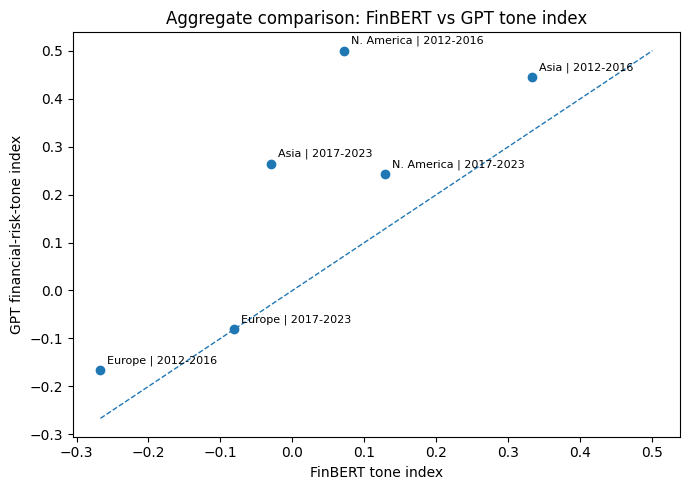

Saved plot to: /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/finbert_vs_gpt_tone_index_scatter.pdf
Saved correlation summary to: /content/drive/MyDrive/phd/Data/gpt_robustness_batch_gpt-5-4-mini/finbert_vs_gpt_tone_index_correlation_summary.csv


,grouping,n_groups,min_group_n,pearson_corr,pearson_p,spearman_corr,spearman_p
0,Region + period,6,5,0.820081,0.045644,0.714286,0.110787


In [ ]:
# ============================================================
# 9.10 Analyze FinBERT validation results part2 ggregate comparison: FinBERT vs GPT financial-risk-tone index
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ------------------------------------------------------------
# 1. Load completed FinBERT validation output
# ------------------------------------------------------------
finbert_completed_path = output_dir / "finbert_validation_completed.csv"

finbert_completed = pd.read_csv(finbert_completed_path)

print("Loaded FinBERT validation file:", finbert_completed.shape)
display(finbert_completed.head())

# ------------------------------------------------------------
# 2. Standardize label columns
# ------------------------------------------------------------
valid_tones = ["positive", "neutral", "negative"]

finbert_completed["FinBERT_label_clean"] = (
    finbert_completed["FinBERT_label"]
    .astype(str)
    .str.lower()
    .str.strip()
)

finbert_completed["GPT_financial_risk_tone_clean"] = (
    finbert_completed["gpt_financial_risk_tone"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Treat mixed_or_unclear as neutral for the aggregate index.
# This keeps ambiguous GPT cases in the denominator, but they do not add positive or negative tone.
finbert_completed["GPT_financial_risk_tone_index_label"] = (
    finbert_completed["GPT_financial_risk_tone_clean"]
    .replace({
        "mixed_or_unclear": "neutral",
        "unclear": "neutral",
        "mixed": "neutral"
    })
)

# Keep only rows with valid FinBERT and GPT index labels
tone_eval = finbert_completed[
    finbert_completed["FinBERT_label_clean"].isin(valid_tones)
    & finbert_completed["GPT_financial_risk_tone_index_label"].isin(valid_tones)
].copy()

print("Rows used for aggregate comparison:", len(tone_eval))

# ------------------------------------------------------------
# 3. Helper function: calculate tone index by group
# ------------------------------------------------------------
def calculate_tone_index(df, group_cols, label_col, prefix):
    """
    Calculate tone shares and tone index by group.

    Tone index = share_positive - share_negative.
    Neutral cases are included in the denominator but do not directly affect the numerator.
    """
    counts = (
        df
        .groupby(group_cols + [label_col])
        .size()
        .unstack(fill_value=0)
    )

    for tone in valid_tones:
        if tone not in counts.columns:
            counts[tone] = 0

    counts = counts[valid_tones].copy()
    counts[f"{prefix}_n"] = counts.sum(axis=1)

    counts[f"{prefix}_share_positive"] = counts["positive"] / counts[f"{prefix}_n"]
    counts[f"{prefix}_share_neutral"] = counts["neutral"] / counts[f"{prefix}_n"]
    counts[f"{prefix}_share_negative"] = counts["negative"] / counts[f"{prefix}_n"]

    counts[f"{prefix}_tone_index"] = (
        counts[f"{prefix}_share_positive"]
        - counts[f"{prefix}_share_negative"]
    )

    return counts.reset_index()

# ------------------------------------------------------------
# 4. Calculate FinBERT and GPT tone indices
# ------------------------------------------------------------
# For the current validation sample, Region × period is safer than Region × Year.
# If your sample is larger and representative by year, you can change this to ["Region", "Year"].
group_cols = ["Region", "period"]

finbert_index = calculate_tone_index(
    df=tone_eval,
    group_cols=group_cols,
    label_col="FinBERT_label_clean",
    prefix="FinBERT"
)

gpt_index = calculate_tone_index(
    df=tone_eval,
    group_cols=group_cols,
    label_col="GPT_financial_risk_tone_index_label",
    prefix="GPT"
)

tone_index_comparison = finbert_index.merge(
    gpt_index,
    on=group_cols,
    how="inner"
)

tone_index_comparison["index_difference"] = (
    tone_index_comparison["FinBERT_tone_index"]
    - tone_index_comparison["GPT_tone_index"]
)

tone_index_comparison["abs_index_difference"] = (
    tone_index_comparison["index_difference"].abs()
)

print("Aggregate tone-index comparison:")
display(tone_index_comparison)

comparison_path = output_dir / "finbert_vs_gpt_aggregate_tone_index_comparison.csv"
tone_index_comparison.to_csv(comparison_path, index=False)
print("Saved aggregate comparison to:", comparison_path)

# ------------------------------------------------------------
# 5. Correlation between aggregate indices
# ------------------------------------------------------------
corr_df = tone_index_comparison.dropna(
    subset=["FinBERT_tone_index", "GPT_tone_index"]
).copy()

# Optional: require minimum group size
min_group_n = 5

corr_df = corr_df[
    (corr_df["FinBERT_n"] >= min_group_n)
    & (corr_df["GPT_n"] >= min_group_n)
].copy()

print("Groups used for correlation:", len(corr_df))

if len(corr_df) >= 3:
    pearson_corr, pearson_p = pearsonr(
        corr_df["FinBERT_tone_index"],
        corr_df["GPT_tone_index"]
    )

    spearman_corr, spearman_p = spearmanr(
        corr_df["FinBERT_tone_index"],
        corr_df["GPT_tone_index"]
    )

    print(f"Pearson correlation:  {pearson_corr:.3f} | p-value: {pearson_p:.3f}")
    print(f"Spearman correlation: {spearman_corr:.3f} | p-value: {spearman_p:.3f}")

else:
    pearson_corr, pearson_p = np.nan, np.nan
    spearman_corr, spearman_p = np.nan, np.nan
    print("Not enough groups for a meaningful correlation.")

# ------------------------------------------------------------
# 6. Scatter plot: FinBERT index vs GPT index
# ------------------------------------------------------------
if len(corr_df) >= 2:
    plt.figure(figsize=(7, 5))

    plt.scatter(
        corr_df["FinBERT_tone_index"],
        corr_df["GPT_tone_index"]
    )

    # Add group labels
    for _, row in corr_df.iterrows():
        label = " | ".join(str(row[col]) for col in group_cols)
        plt.annotate(
            label,
            (
                row["FinBERT_tone_index"],
                row["GPT_tone_index"]
            ),
            fontsize=8,
            xytext=(5, 5),
            textcoords="offset points"
        )

    # Add 45-degree reference line
    min_val = min(
        corr_df["FinBERT_tone_index"].min(),
        corr_df["GPT_tone_index"].min()
    )

    max_val = max(
        corr_df["FinBERT_tone_index"].max(),
        corr_df["GPT_tone_index"].max()
    )

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("FinBERT tone index")
    plt.ylabel("GPT financial-risk-tone index")
    plt.title("Aggregate comparison: FinBERT vs GPT tone index")
    plt.tight_layout()

    plot_path = output_dir / "finbert_vs_gpt_tone_index_scatter.pdf"
    plt.savefig(plot_path, bbox_inches="tight")
    plt.show()

    print("Saved plot to:", plot_path)

# ------------------------------------------------------------
# 7. Export correlation summary
# ------------------------------------------------------------
correlation_summary = pd.DataFrame([{
    "grouping": " + ".join(group_cols),
    "n_groups": len(corr_df),
    "min_group_n": min_group_n,
    "pearson_corr": pearson_corr,
    "pearson_p": pearson_p,
    "spearman_corr": spearman_corr,
    "spearman_p": spearman_p
}])

correlation_path = output_dir / "finbert_vs_gpt_tone_index_correlation_summary.csv"
correlation_summary.to_csv(correlation_path, index=False)

print("Saved correlation summary to:", correlation_path)
display(correlation_summary)

In [ ]:
# ============================================================
# 9.11 Analyze BERTopic/theme-group validation results
# ============================================================

if RUN_TOPIC_VALIDATION:

    topic_sample_path = output_dir / "topics_validation_sample.csv"
    topic_results_path = output_dir / "topics_gpt_results.csv"

    if topic_sample_path.exists() and topic_results_path.exists():
        topic_sample = pd.read_csv(topic_sample_path)
        topic_results = pd.read_csv(topic_results_path)

        topic_results["validation_id"] = pd.to_numeric(
            topic_results["validation_id"],
            errors="coerce"
        ).astype("Int64")

        topic_completed = topic_sample.merge(
            topic_results,
            on="validation_id",
            how="left"
        )

        topic_completed["GPT_theme_group_norm"] = (
            topic_completed["gpt_theme_group"]
            .apply(normalize_theme_label)
        )

        if "BERTopic_theme_group" in topic_completed.columns:
            topic_completed["BERTopic_theme_group_norm"] = (
                topic_completed["BERTopic_theme_group"]
                .apply(normalize_theme_label)
            )

        topic_completed_path = output_dir / "topics_validation_completed.csv"
        topic_completed.to_csv(topic_completed_path, index=False)

        print("Saved completed topic validation file to:", topic_completed_path)
        display(topic_completed.head())

        # ------------------------------------------------------------
        # Overall GPT theme distribution
        # ------------------------------------------------------------
        theme_counts = (
            topic_completed["GPT_theme_group_norm"]
            .value_counts(dropna=False)
            .rename_axis("GPT_theme_group")
            .reset_index(name="n")
        )

        theme_counts["share"] = theme_counts["n"] / theme_counts["n"].sum()

        print("GPT theme distribution:")
        display(theme_counts)

        theme_counts.to_csv(
            output_dir / "topics_gpt_theme_distribution.csv",
            index=False
        )

        # ------------------------------------------------------------
        # Direct agreement if a BERTopic/manual broad group exists
        # ------------------------------------------------------------
        if "BERTopic_theme_group_norm" in topic_completed.columns:
            clear_eval = topic_completed.dropna(
                subset=["BERTopic_theme_group_norm", "GPT_theme_group_norm"]
            ).copy()

            print("BERTopic/manual theme group vs GPT theme group")

            if not clear_eval.empty:
                print(
                    "Exact agreement:",
                    accuracy_score(
                        clear_eval["BERTopic_theme_group_norm"],
                        clear_eval["GPT_theme_group_norm"]
                    )
                )

                cross_tab = pd.crosstab(
                    clear_eval["BERTopic_theme_group_norm"],
                    clear_eval["GPT_theme_group_norm"],
                    dropna=False
                )

                display(cross_tab)

                cross_tab.to_csv(
                    output_dir / "topics_theme_group_crosstab.csv"
                )

                cross_tab_norm = pd.crosstab(
                    clear_eval["BERTopic_theme_group_norm"],
                    clear_eval["GPT_theme_group_norm"],
                    normalize="index",
                    dropna=False
                )

                display(cross_tab_norm)

                cross_tab_norm.to_csv(
                    output_dir / "topics_theme_group_crosstab_normalized.csv"
                )

                disagreements = clear_eval[
                    clear_eval["BERTopic_theme_group_norm"]
                    != clear_eval["GPT_theme_group_norm"]
                ].copy()

                disagreements.to_csv(
                    output_dir / "topics_theme_group_disagreements.csv",
                    index=False
                )

                print("Topic-group disagreements:", len(disagreements))

                disagreement_cols = [
                    "validation_id",
                    "Company Name",
                    "Year",
                    "Region",
                    "period",
                    "Sentence",
                    "BERTopic_theme_group_norm",
                    "GPT_theme_group_norm",
                    "confidence_0_1",
                    "short_reason"
                ]

                disagreement_cols = [
                    col for col in disagreement_cols
                    if col in disagreements.columns
                ]

                display(disagreements[disagreement_cols].head(30))

            else:
                print("No valid rows available for BERTopic/manual vs GPT agreement.")

        # ------------------------------------------------------------
        # If only a numeric topic ID exists, summarize GPT themes by topic ID
        # ------------------------------------------------------------
        elif "Topic" in topic_completed.columns or "topic" in topic_completed.columns:
            topic_id_col = "Topic" if "Topic" in topic_completed.columns else "topic"

            topic_theme_summary = (
                topic_completed
                .groupby([topic_id_col, "GPT_theme_group_norm"])
                .size()
                .reset_index(name="n")
            )

            topic_theme_summary["share_within_topic"] = (
                topic_theme_summary
                .groupby(topic_id_col)["n"]
                .transform(lambda x: x / x.sum())
            )

            print("GPT theme distribution within BERTopic topics:")
            display(topic_theme_summary)

            topic_theme_summary.to_csv(
                output_dir / "topics_gpt_theme_by_topic_id.csv",
                index=False
            )

        # ------------------------------------------------------------
        # Fallback region-period summary
        # ------------------------------------------------------------
        else:
            region_period_summary = (
                topic_completed
                .groupby(["Region", "period", "GPT_theme_group_norm"])
                .size()
                .reset_index(name="n")
            )

            region_period_summary["share_within_region_period"] = (
                region_period_summary
                .groupby(["Region", "period"])["n"]
                .transform(lambda x: x / x.sum())
            )

            print(
                "No BERTopic group or topic ID found. "
                "Showing region-period GPT theme summary instead:"
            )

            display(region_period_summary)

            region_period_summary.to_csv(
                output_dir / "topics_region_period_gpt_summary.csv",
                index=False
            )

    else:
        print(
            "Topic validation files not found. "
            "Run the batch creation, status, download, and parse cells first."
        )

else:
    print("Skipping BERTopic/theme-group validation because RUN_TOPIC_VALIDATION = False.")

Skipping BERTopic/theme-group validation because RUN_TOPIC_VALIDATION = False.


In [ ]:
# ============================================================
# 9.12 Estimate Batch API cost from returned usage
# ============================================================
# Update the prices below based on the exact model you used.
# Because Batch API is discounted, use the batch prices, not the standard synchronous prices.

usage_files = list(output_dir.glob("*_gpt_usage.csv"))

if not usage_files:
    print("No usage files found yet. Parse the Batch API outputs first.")
else:
    usage_all = []
    for path in usage_files:
        temp = pd.read_csv(path)
        usage_all.append(temp)

    usage_all = pd.concat(usage_all, ignore_index=True)
    display(usage_all)

    total_input_tokens = usage_all["input_tokens"].sum()
    total_output_tokens = usage_all["output_tokens"].sum()
    total_tokens = usage_all["total_tokens"].sum()

    print("Total input tokens:", total_input_tokens)
    print("Total output tokens:", total_output_tokens)
    print("Total tokens:", total_tokens)

    # Example placeholder prices for batch mode.
    # Replace these numbers with the current batch prices for your selected model.
    batch_input_price_per_1m = 0.075
    batch_output_price_per_1m = 0.300

    estimated_cost = (
        total_input_tokens / 1_000_000 * batch_input_price_per_1m
        + total_output_tokens / 1_000_000 * batch_output_price_per_1m
    )

    print(f"Estimated Batch API cost for MODEL={MODEL}: USD {estimated_cost:.4f}")

    usage_summary = (
        usage_all
        .groupby("task_name")[["input_tokens", "output_tokens", "total_tokens"]]
        .sum()
        .reset_index()
    )
    display(usage_summary)
    usage_summary.to_csv(output_dir / "gpt_batch_usage_summary.csv", index=False)


,custom_id,task_name,input_tokens,output_tokens,total_tokens
0,esgbert_0_19,esgbert,2168,1122,3290
1,esgbert_20_39,esgbert,2210,1106,3316
2,esgbert_40_59,esgbert,2083,1106,3189
3,esgbert_60_79,esgbert,2189,1112,3301
4,esgbert_80_99,esgbert,2112,1074,3186
5,esgbert_100_119,esgbert,2179,1105,3284
6,esgbert_120_139,esgbert,2190,1067,3257
7,esgbert_140_159,esgbert,2356,1142,3498
8,esgbert_160_179,esgbert,2294,1105,3399
9,esgbert_180_199,esgbert,2047,1063,3110


Total input tokens: 78904
Total output tokens: 44143
Total tokens: 123047
Estimated Batch API cost for MODEL=gpt-5.4-mini: USD 0.0192


,task_name,input_tokens,output_tokens,total_tokens
0,esgbert,53780,28087,81867
1,finbert,25124,16056,41180


## 9.13 Prelim paper wording

Possible insights wording in the robustness section:

> As auxiliary robustness checks, we used GPT-assisted structured classification to validate three stages of the NLP pipeline. First, a stratified sample of ESG-BERT positive and negative cases was classified for ESG relevance and ESG dimension. Second, a balanced sample of FinBERT positive, neutral, and negative sentences was independently classified for sentiment. Third, a balanced sample of topic-assigned sentences was classified into the six higher-order narrative groups used in the thematic analysis. The GPT-assisted classifications were implemented through the OpenAI Batch API and structured JSON outputs. These checks are interpreted as plausibility-oriented validation exercises rather than as replacements for the primary transformer-based and topic-modeling procedures.
